# Geometry — part 4 of 5

This notebook was automatically split from a larger notebook.

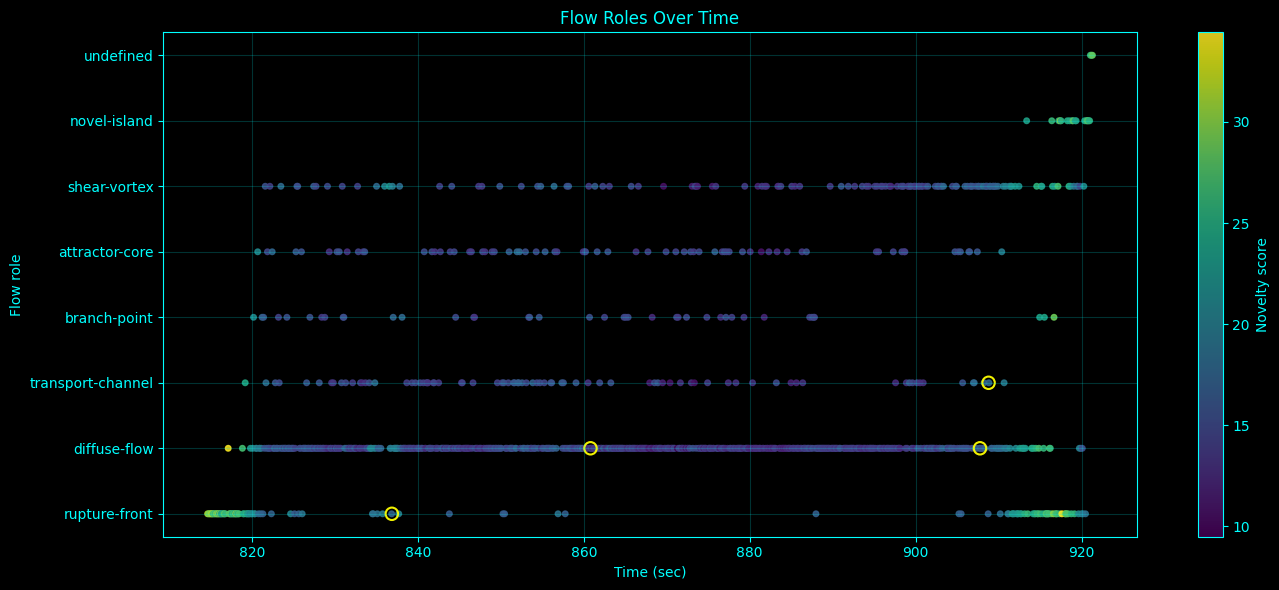

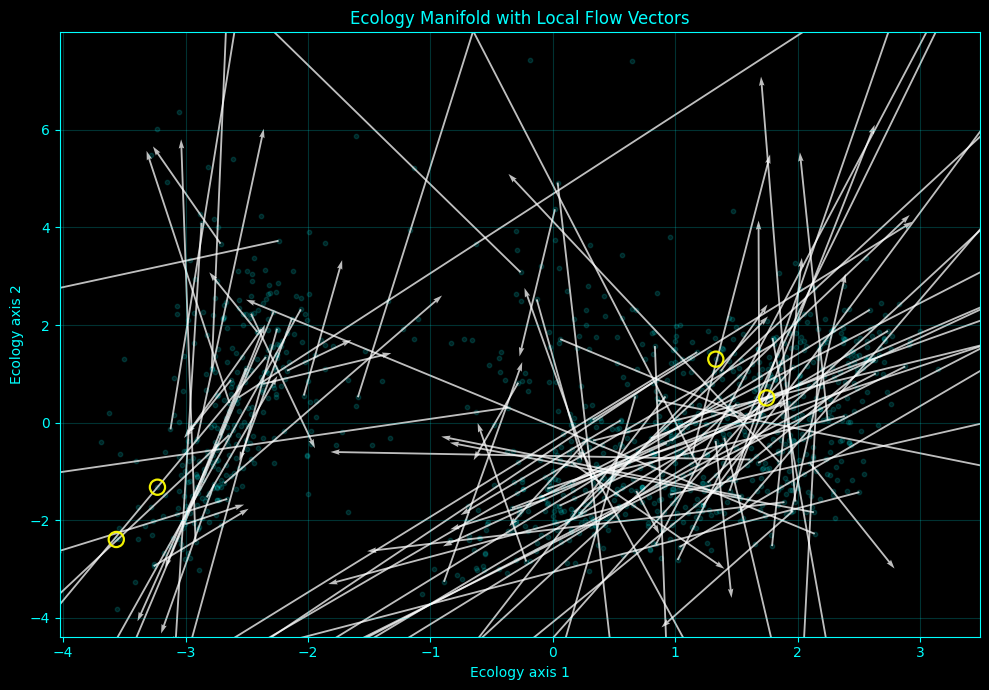

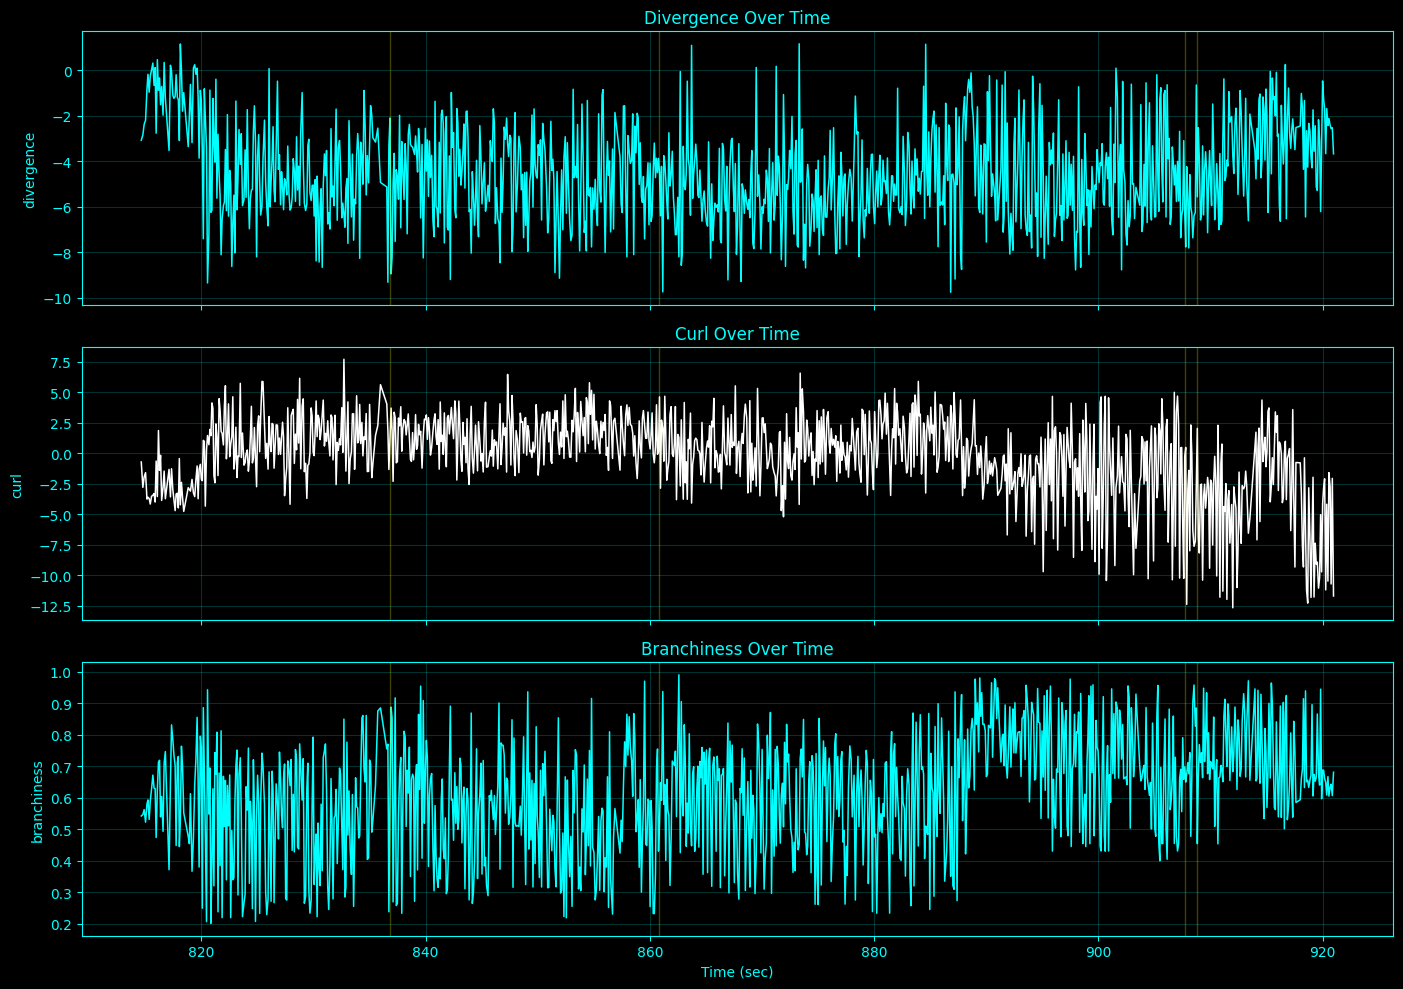

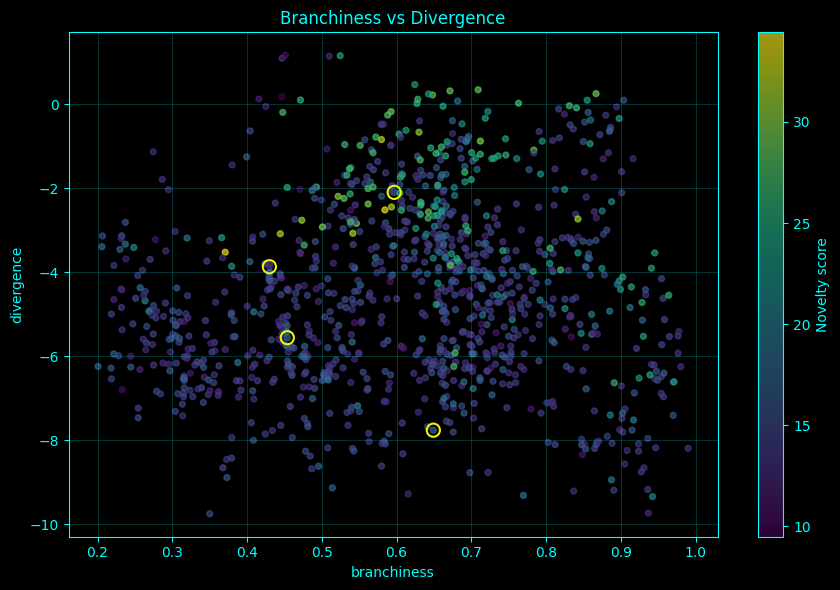

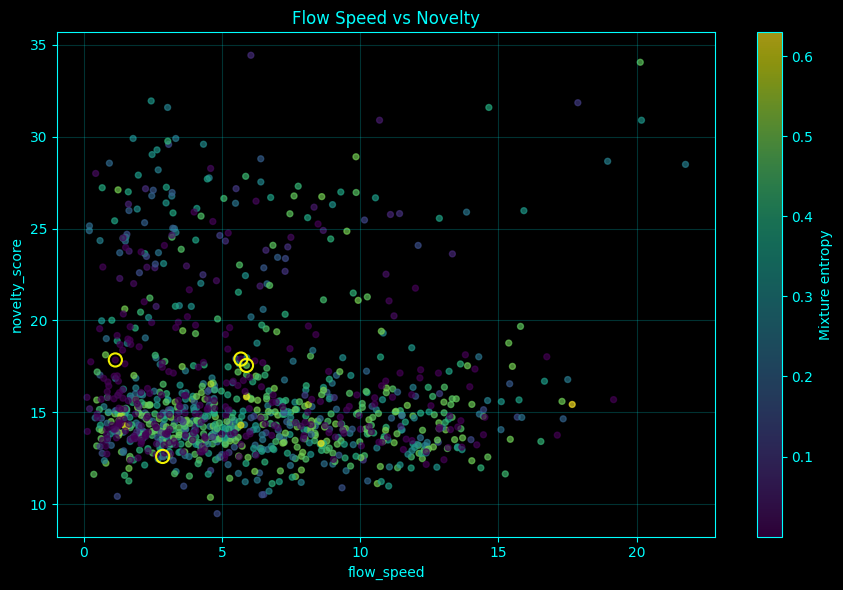


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/ecology_flow_cartography_v1/motif_field_with_flow_roles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/ecology_flow_cartography_v1/flow_role_segments.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/ecology_flow_cartography_v1/near_flat_flow_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/ecology_flow_cartography_v1/ecology_flow_cartography_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/ecology_flow_cartography_v1/plots

Flow-role counts:
flow_role
diffuse-flow         627
shear-vortex         130
rupture-front        111
transport-channel     81
attractor-core        71
branch-point          40
novel-island          17
undefined              3

Top 15 longest flow-role segments:
 segment_id  start_time_sec  end_time_sec  duration_sec  n_windows     flow_role  dominant_motif_mode ecology_name_mode  novelty_mean  entropy_mean  margin_mean  divergence_mean

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

ecology_dir = os.path.join(base_dir, "results", "motif_field_ecology_atlas_v1")
field_csv = os.path.join(ecology_dir, "motif_field_with_ecology_labels.csv")
near_flat_csv = os.path.join(ecology_dir, "near_flat_ecology_context.csv")

out_dir = os.path.join(base_dir, "results", "ecology_flow_cartography_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# local flow controls
flow_lag = 3                 # future displacement in field steps
k_neighbors = 80             # local manifold neighbors for vector-field fit
min_neighbors = 20
quiver_stride = 10

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def angle_of(vx, vy):
    return np.arctan2(vy, vx)

def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def heading_resultant(angles):
    angles = np.asarray(angles, dtype=float)
    angles = angles[np.isfinite(angles)]
    if len(angles) == 0:
        return np.nan
    c = np.mean(np.cos(angles))
    s = np.mean(np.sin(angles))
    return float(np.sqrt(c*c + s*s))

def branchiness_from_angles(angles):
    R = heading_resultant(angles)
    return float(1.0 - R) if np.isfinite(R) else np.nan

def classify_flow_role(row, q):
    novelty = row["novelty_score"]
    entropy = row["mixture_entropy"]
    margin = row["dominance_margin"]
    divv = row["divergence"]
    curl = abs(row["curl"])
    speed = row["flow_speed"]
    branch = row["branchiness"]

    if novelty >= q["novelty90"] and margin >= q["margin75"] and entropy <= q["entropy25"]:
        return "novel-island"
    if branch >= q["branch75"] and entropy >= q["entropy75"]:
        return "branch-point"
    if divv >= q["div75"] and novelty >= q["novelty75"]:
        return "rupture-front"
    if divv <= q["div25"] and speed <= q["speed50"] and branch <= q["branch50"]:
        return "attractor-core"
    if curl >= q["curl75"] and branch >= q["branch50"]:
        return "shear-vortex"
    if branch <= q["branch25"] and speed >= q["speed50"] and entropy <= q["entropy75"]:
        return "transport-channel"
    return "diffuse-flow"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

required_cols = [
    "center_time_sec", "eco_x", "eco_y", "novelty_score",
    "mixture_entropy", "dominance_margin", "dominant_motif",
    "ecology_cluster", "ecology_name"
]
for c in required_cols:
    if c not in field_df.columns:
        raise ValueError(f"Missing required column: {c}")

# -------------------------------------------------------
# TRAJECTORY KINEMATICS
# -------------------------------------------------------
x = field_df["eco_x"].values
y = field_df["eco_y"].values
t = field_df["center_time_sec"].values
n = len(field_df)

vx = np.full(n, np.nan)
vy = np.full(n, np.nan)
flow_speed = np.full(n, np.nan)
heading = np.full(n, np.nan)
turning = np.full(n, np.nan)

for i in range(n - flow_lag):
    dt = t[i + flow_lag] - t[i]
    if dt <= 0:
        continue
    dx = x[i + flow_lag] - x[i]
    dy = y[i + flow_lag] - y[i]

    vx[i] = dx / dt
    vy[i] = dy / dt
    flow_speed[i] = np.sqrt(vx[i]**2 + vy[i]**2)
    heading[i] = angle_of(vx[i], vy[i])

for i in range(n - flow_lag - 1):
    if np.isfinite(heading[i]) and np.isfinite(heading[i + 1]):
        turning[i] = wrap_pi(heading[i + 1] - heading[i])

field_df["vx"] = vx
field_df["vy"] = vy
field_df["flow_speed"] = flow_speed
field_df["heading"] = heading
field_df["turning"] = turning

# -------------------------------------------------------
# LOCAL VECTOR-FIELD FIT: DIVERGENCE / CURL / BRANCHINESS
# -------------------------------------------------------
XY = np.column_stack([x, y])
tree = cKDTree(XY)
_, nbr_idx = tree.query(XY, k=min(k_neighbors + 1, len(XY)))

divergence = np.full(n, np.nan)
curl = np.full(n, np.nan)
branchiness = np.full(n, np.nan)
local_heading_resultant = np.full(n, np.nan)
local_neighbor_radius = np.full(n, np.nan)

for i in range(n):
    idx = np.atleast_1d(nbr_idx[i])
    idx = idx[idx != i]

    # only neighbors with valid local future vectors
    good = idx[np.isfinite(vx[idx]) & np.isfinite(vy[idx])]
    if len(good) < min_neighbors or not (np.isfinite(vx[i]) and np.isfinite(vy[i])):
        continue

    Xi = XY[good] - XY[i]
    Ui = vx[good]
    Vi = vy[good]

    # local linear fit:
    # u ~ a0 + a1*x + a2*y
    # v ~ b0 + b1*x + b2*y
    A = np.column_stack([np.ones(len(Xi)), Xi[:, 0], Xi[:, 1]])

    try:
        coef_u, *_ = np.linalg.lstsq(A, Ui, rcond=None)
        coef_v, *_ = np.linalg.lstsq(A, Vi, rcond=None)
    except np.linalg.LinAlgError:
        continue

    du_dx = coef_u[1]
    du_dy = coef_u[2]
    dv_dx = coef_v[1]
    dv_dy = coef_v[2]

    divergence[i] = du_dx + dv_dy
    curl[i] = dv_dx - du_dy

    angles = np.arctan2(Vi, Ui)
    local_heading_resultant[i] = heading_resultant(angles)
    branchiness[i] = branchiness_from_angles(angles)
    local_neighbor_radius[i] = float(np.mean(np.linalg.norm(Xi, axis=1)))

field_df["divergence"] = divergence
field_df["curl"] = curl
field_df["branchiness"] = branchiness
field_df["local_heading_resultant"] = local_heading_resultant
field_df["local_neighbor_radius"] = local_neighbor_radius

# -------------------------------------------------------
# FLOW ROLE LABELS
# -------------------------------------------------------
valid = field_df[np.isfinite(field_df["divergence"]) & np.isfinite(field_df["branchiness"])].copy()

q = {
    "novelty75": np.quantile(valid["novelty_score"], 0.75),
    "novelty90": np.quantile(valid["novelty_score"], 0.90),
    "entropy25": np.quantile(valid["mixture_entropy"], 0.25),
    "entropy75": np.quantile(valid["mixture_entropy"], 0.75),
    "margin75": np.quantile(valid["dominance_margin"], 0.75),
    "speed50": np.quantile(valid["flow_speed"], 0.50),
    "branch25": np.quantile(valid["branchiness"], 0.25),
    "branch50": np.quantile(valid["branchiness"], 0.50),
    "branch75": np.quantile(valid["branchiness"], 0.75),
    "div25": np.quantile(valid["divergence"], 0.25),
    "div75": np.quantile(valid["divergence"], 0.75),
    "curl75": np.quantile(np.abs(valid["curl"]), 0.75),
}

field_df["flow_role"] = field_df.apply(
    lambda r: classify_flow_role(r, q) if np.isfinite(r["divergence"]) and np.isfinite(r["branchiness"]) else "undefined",
    axis=1
)

# -------------------------------------------------------
# CONTIGUOUS FLOW ROLE SEGMENTS
# -------------------------------------------------------
times = field_df["center_time_sec"].values
roles = field_df["flow_role"].values

segments = []
if len(times) > 0:
    start_i = 0
    for i in range(1, len(times)):
        changed = (roles[i] != roles[i - 1]) or ((times[i] - times[i - 1]) > 0.5)
        if changed:
            segments.append((start_i, i - 1))
            start_i = i
    segments.append((start_i, len(times) - 1))

segment_rows = []
for seg_id, (i0, i1) in enumerate(segments, start=1):
    sub = field_df.iloc[i0:i1 + 1]
    segment_rows.append({
        "segment_id": seg_id,
        "start_time_sec": float(sub["center_time_sec"].iloc[0]),
        "end_time_sec": float(sub["center_time_sec"].iloc[-1]),
        "duration_sec": float(sub["center_time_sec"].iloc[-1] - sub["center_time_sec"].iloc[0]),
        "n_windows": int(len(sub)),
        "flow_role": sub["flow_role"].mode().iloc[0],
        "dominant_motif_mode": int(sub["dominant_motif"].mode().iloc[0]),
        "ecology_name_mode": sub["ecology_name"].mode().iloc[0],
        "novelty_mean": safe_mean(sub["novelty_score"].values),
        "entropy_mean": safe_mean(sub["mixture_entropy"].values),
        "margin_mean": safe_mean(sub["dominance_margin"].values),
        "divergence_mean": safe_mean(sub["divergence"].values),
        "curl_mean": safe_mean(sub["curl"].values),
        "branchiness_mean": safe_mean(sub["branchiness"].values),
        "speed_mean": safe_mean(sub["flow_speed"].values),
    })

segment_df = pd.DataFrame(segment_rows).sort_values("start_time_sec").reset_index(drop=True)

# -------------------------------------------------------
# NEAR-FLAT FLOW CONTEXT
# -------------------------------------------------------
near_flat_flow_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t0)))
        fr = field_df.iloc[idx]

        near_flat_flow_rows.append({
            "time_sec": t0,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "flow_role": fr["flow_role"],
            "ecology_name": fr["ecology_name"],
            "dominant_motif": int(fr["dominant_motif"]),
            "novelty_score": float(fr["novelty_score"]),
            "mixture_entropy": float(fr["mixture_entropy"]),
            "dominance_margin": float(fr["dominance_margin"]),
            "flow_speed": float(fr["flow_speed"]),
            "turning": float(fr["turning"]),
            "divergence": float(fr["divergence"]),
            "curl": float(fr["curl"]),
            "branchiness": float(fr["branchiness"]),
            "eco_x": float(fr["eco_x"]),
            "eco_y": float(fr["eco_y"]),
        })

near_flat_flow_df = pd.DataFrame(near_flat_flow_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_out_csv = os.path.join(out_dir, "motif_field_with_flow_roles.csv")
segment_csv = os.path.join(out_dir, "flow_role_segments.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_flow_context.csv")
summary_txt = os.path.join(out_dir, "ecology_flow_cartography_summary.txt")

field_df.to_csv(field_out_csv, index=False)
segment_df.to_csv(segment_csv, index=False)
near_flat_flow_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Ecology Flow Cartography Summary\n")
    f.write("================================\n\n")

    f.write("Flow-role counts:\n")
    f.write(field_df["flow_role"].value_counts().to_string())
    f.write("\n\n")

    f.write("Top 20 longest flow-role segments:\n")
    f.write(segment_df.sort_values("duration_sec", ascending=False).head(20).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_flow_df) > 0:
        f.write("Near-flat flow context:\n")
        f.write(near_flat_flow_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Flow role timeline
role_names = list(pd.Series(field_df["flow_role"]).dropna().unique())
role_to_y = {r: i for i, r in enumerate(role_names)}

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["center_time_sec"].values,
    [role_to_y[r] for r in field_df["flow_role"].values],
    c=field_df["novelty_score"].values,
    s=16,
    alpha=0.85
)

if len(near_flat_flow_df) > 0:
    ax.scatter(
        near_flat_flow_df["time_sec"].values,
        [role_to_y[r] for r in near_flat_flow_df["flow_role"].values],
        s=80,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_yticks(list(role_to_y.values()))
ax.set_yticklabels(list(role_to_y.keys()))
ax.set_title("Flow Roles Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Flow role")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot1_path = os.path.join(plots_dir, "flow_role_timeline.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Ecology manifold with local flow vectors
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    field_df["eco_x"].values,
    field_df["eco_y"].values,
    s=10,
    alpha=0.14,
    color=ACCENT
)

good_q = np.isfinite(field_df["vx"].values) & np.isfinite(field_df["vy"].values)
idx_q = np.where(good_q)[0][::quiver_stride]

ax.quiver(
    field_df["eco_x"].values[idx_q],
    field_df["eco_y"].values[idx_q],
    field_df["vx"].values[idx_q],
    field_df["vy"].values[idx_q],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="white",
    alpha=0.75,
    width=0.002
)

if len(near_flat_flow_df) > 0:
    ax.scatter(
        near_flat_flow_df["eco_x"].values,
        near_flat_flow_df["eco_y"].values,
        s=120,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95
    )

ax.set_title("Ecology Manifold with Local Flow Vectors")
ax.set_xlabel("Ecology axis 1")
ax.set_ylabel("Ecology axis 2")

plot2_path = os.path.join(plots_dir, "ecology_manifold_with_flow_vectors.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Divergence / curl / branchiness over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor=BG, sharex=True)
ax1, ax2, ax3 = axes
style_ax(ax1); style_ax(ax2); style_ax(ax3)

ax1.plot(field_df["center_time_sec"].values, field_df["divergence"].values, color=ACCENT, linewidth=1.1)
ax1.set_title("Divergence Over Time")
ax1.set_ylabel("divergence")

ax2.plot(field_df["center_time_sec"].values, field_df["curl"].values, color="white", linewidth=1.1)
ax2.set_title("Curl Over Time")
ax2.set_ylabel("curl")

ax3.plot(field_df["center_time_sec"].values, field_df["branchiness"].values, color=ACCENT, linewidth=1.1)
ax3.set_title("Branchiness Over Time")
ax3.set_xlabel("Time (sec)")
ax3.set_ylabel("branchiness")

if len(near_flat_flow_df) > 0:
    for t0 in near_flat_flow_df["time_sec"].values:
        ax1.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax2.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax3.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)

plot3_path = os.path.join(plots_dir, "divergence_curl_branchiness_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Branchiness vs divergence
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["branchiness"].values,
    field_df["divergence"].values,
    c=field_df["novelty_score"].values,
    s=18,
    alpha=0.65
)

if len(near_flat_flow_df) > 0:
    ax.scatter(
        near_flat_flow_df["branchiness"].values,
        near_flat_flow_df["divergence"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Branchiness vs Divergence")
ax.set_xlabel("branchiness")
ax.set_ylabel("divergence")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot4_path = os.path.join(plots_dir, "branchiness_vs_divergence.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Flow speed vs novelty
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["flow_speed"].values,
    field_df["novelty_score"].values,
    c=field_df["mixture_entropy"].values,
    s=18,
    alpha=0.65
)

if len(near_flat_flow_df) > 0:
    ax.scatter(
        near_flat_flow_df["flow_speed"].values,
        near_flat_flow_df["novelty_score"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Flow Speed vs Novelty")
ax.set_xlabel("flow_speed")
ax.set_ylabel("novelty_score")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Mixture entropy")

plot5_path = os.path.join(plots_dir, "flow_speed_vs_novelty.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print("\nSaved:")
print(field_out_csv)
print(segment_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print("\nFlow-role counts:")
print(field_df["flow_role"].value_counts().to_string())

print("\nTop 15 longest flow-role segments:")
print(segment_df.sort_values("duration_sec", ascending=False).head(15).to_string(index=False))

if len(near_flat_flow_df) > 0:
    print("\nNear-flat flow context:")
    print(near_flat_flow_df.to_string(index=False))

Median field dt: 0.090000 sec
Future horizon steps: 17
Path sample steps: [1, 4, 7, 11, 14, 17]


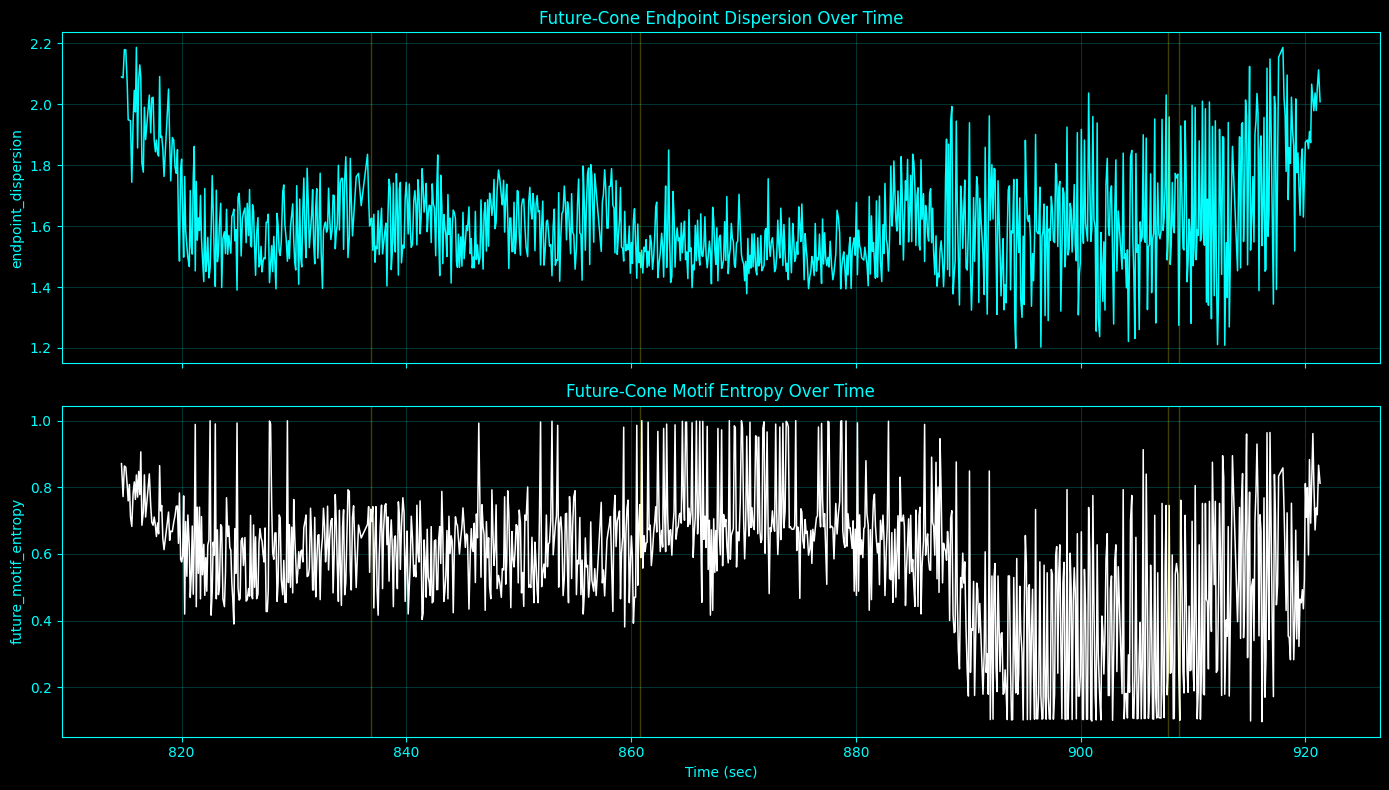

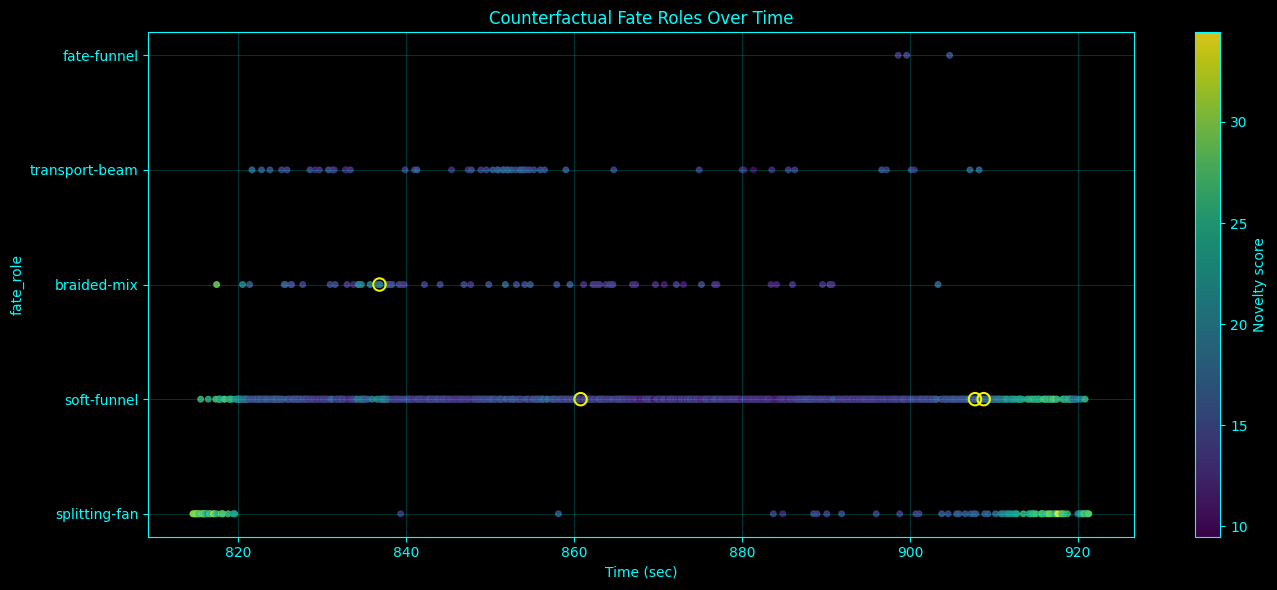

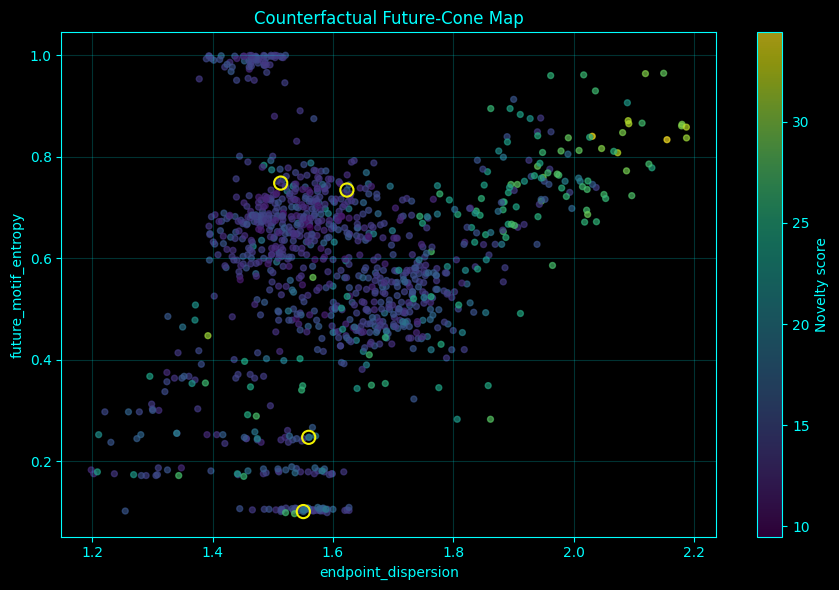

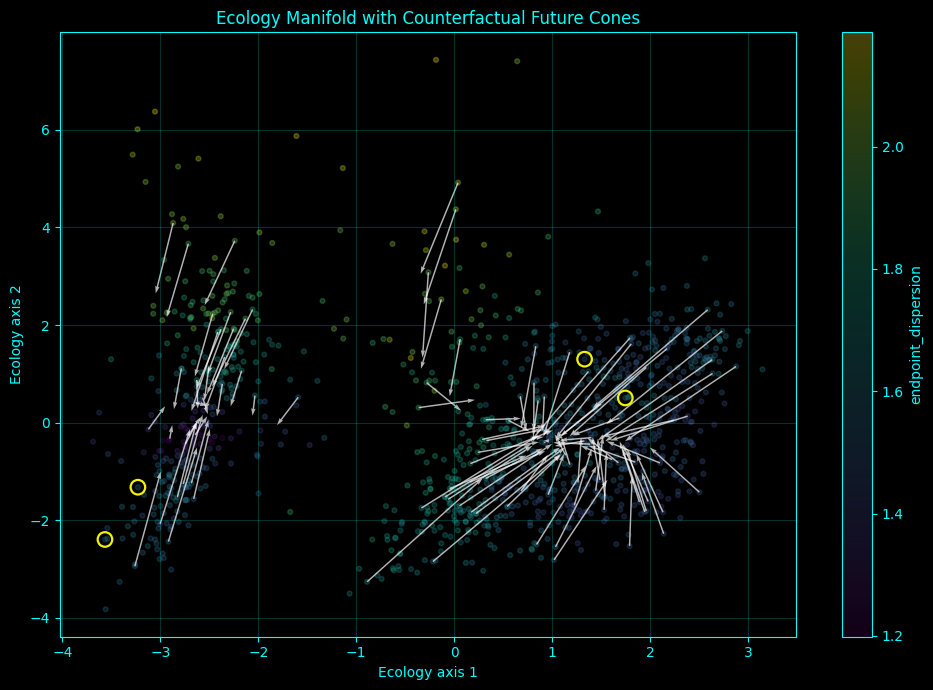

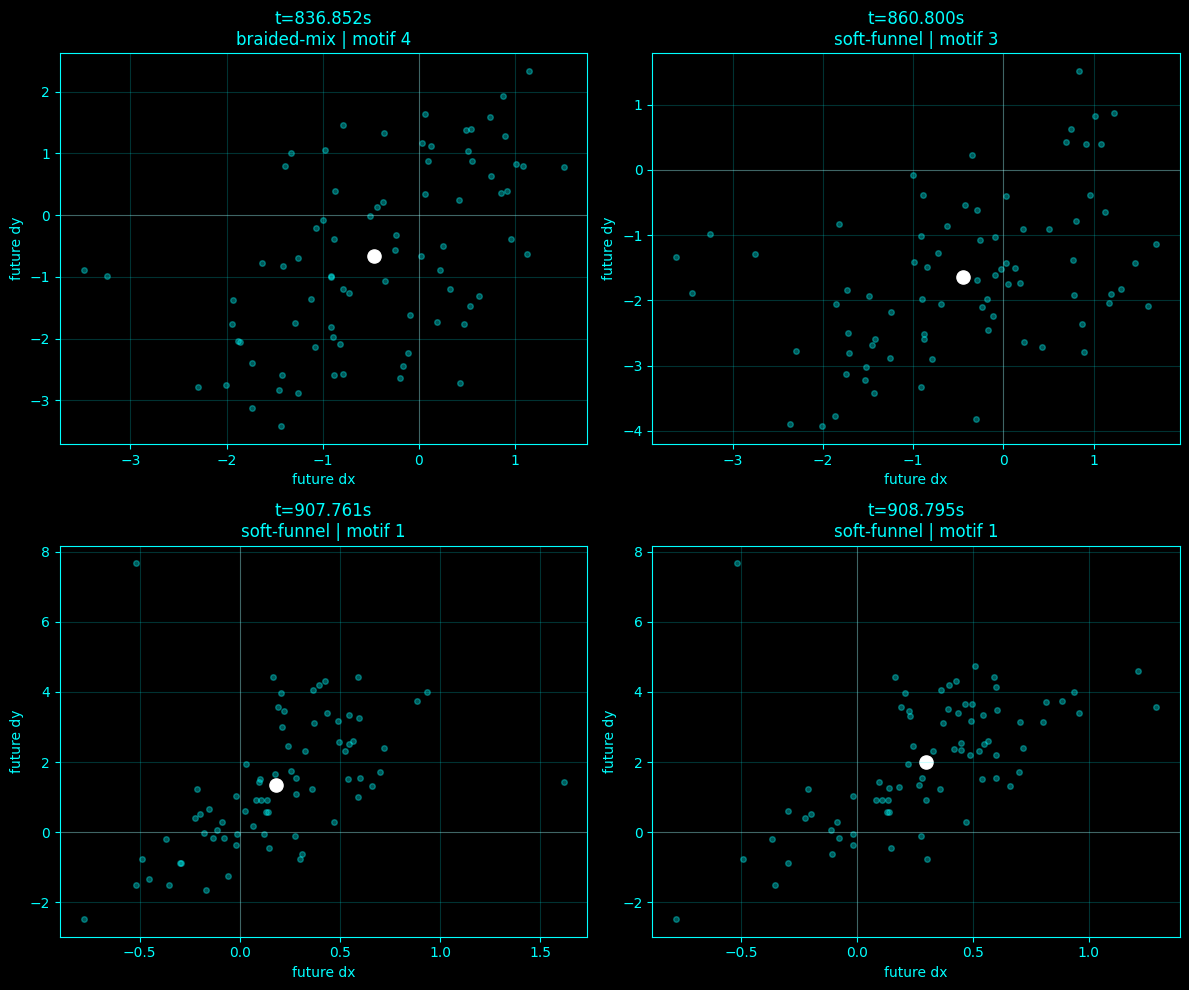


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/counterfactual_future_cones_v1/motif_field_with_future_cones.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/counterfactual_future_cones_v1/future_cone_segments.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/counterfactual_future_cones_v1/near_flat_future_cone_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/counterfactual_future_cones_v1/counterfactual_future_cone_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/counterfactual_future_cones_v1/plots

Fate-role counts:
fate_role
soft-funnel       869
splitting-fan      92
braided-mix        62
transport-beam     54
fate-funnel         3

Top 15 longest fate segments:
 segment_id  start_time_sec  end_time_sec  duration_sec  n_windows   fate_role  dominant_motif_mode  endpoint_dispersion_mean  future_heading_consensus_mean  future_motif_entropy_mean  novelty_mean
        221         891.968       895.907     

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

flow_dir = os.path.join(base_dir, "results", "ecology_flow_cartography_v1")
field_csv = os.path.join(flow_dir, "motif_field_with_flow_roles.csv")
near_flat_csv = os.path.join(flow_dir, "near_flat_flow_context.csv")

out_dir = os.path.join(base_dir, "results", "counterfactual_future_cones_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Counterfactual future-cone controls
fate_horizon_sec = 1.50
temporal_exclusion_sec = 1.00
k_neighbors = 80
min_neighbors = 16

# For path-dispersion sampling inside the cone
n_path_samples = 6

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def heading_resultant(angles):
    angles = np.asarray(angles, dtype=float)
    angles = angles[np.isfinite(angles)]
    if len(angles) == 0:
        return np.nan
    c = np.mean(np.cos(angles))
    s = np.mean(np.sin(angles))
    return float(np.sqrt(c * c + s * s))

def normalized_entropy_from_labels(labels):
    labels = np.asarray(labels)
    if len(labels) == 0:
        return np.nan
    _, counts = np.unique(labels, return_counts=True)
    p = counts / np.sum(counts)
    h = -np.sum(p * np.log(p + eps))
    return float(h / (np.log(len(counts) + eps) + eps))

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def classify_fate_role(row, q):
    spread = row["endpoint_dispersion"]
    entropy = row["future_motif_entropy"]
    consensus = row["future_heading_consensus"]
    novelty = row["novelty_score"]
    speed = row["flow_speed"]
    path_disp = row["path_dispersion"]

    if entropy <= q["entropy25"] and spread <= q["spread25"] and consensus >= q["cons75"]:
        return "fate-funnel"
    if entropy >= q["entropy75"] and spread >= q["spread75"]:
        return "splitting-fan"
    if consensus >= q["cons75"] and spread >= q["spread50"] and path_disp <= q["path50"]:
        return "transport-beam"
    if novelty >= q["novelty75"] and entropy <= q["entropy50"] and speed >= q["speed50"]:
        return "directed-launch"
    if path_disp >= q["path75"] and consensus <= q["cons25"]:
        return "braided-mix"
    return "soft-funnel"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

required_cols = [
    "center_time_sec", "eco_x", "eco_y",
    "dominant_motif", "novelty_score", "flow_speed"
]
for c in required_cols:
    if c not in field_df.columns:
        raise ValueError(f"Missing required column: {c}")

# -------------------------------------------------------
# BASIC GEOMETRY
# -------------------------------------------------------
t = field_df["center_time_sec"].values
x = field_df["eco_x"].values
y = field_df["eco_y"].values
motif = field_df["dominant_motif"].values

dt_med = np.median(np.diff(t))
horizon_steps = max(3, int(np.round(fate_horizon_sec / max(dt_med, eps))))
path_steps = np.unique(np.round(np.linspace(1, horizon_steps, n_path_samples)).astype(int))

print(f"Median field dt: {dt_med:.6f} sec")
print(f"Future horizon steps: {horizon_steps}")
print(f"Path sample steps: {path_steps.tolist()}")

XY = np.column_stack([x, y])
tree = cKDTree(XY)

# -------------------------------------------------------
# COUNTERFACTUAL FUTURE-CONE METRICS
# -------------------------------------------------------
endpoint_dx = np.full(len(field_df), np.nan)
endpoint_dy = np.full(len(field_df), np.nan)
endpoint_dispersion = np.full(len(field_df), np.nan)
path_dispersion = np.full(len(field_df), np.nan)
future_heading_consensus = np.full(len(field_df), np.nan)
future_motif_entropy = np.full(len(field_df), np.nan)
future_motif_count = np.full(len(field_df), np.nan)
neighbor_count_used = np.full(len(field_df), np.nan)

for i in range(len(field_df)):
    idx = np.atleast_1d(tree.query(XY[i], k=min(k_neighbors + 1, len(field_df)))[1])
    idx = idx[idx != i]

    # counterfactual neighbors: nearby in ecology space but not too close in time
    idx = idx[np.abs(t[idx] - t[i]) >= temporal_exclusion_sec]

    valid = []
    for j in idx:
        if j + horizon_steps < len(field_df):
            valid.append(j)
    valid = np.asarray(valid, dtype=int)

    if len(valid) < min_neighbors:
        continue

    endpoints = []
    headings = []
    future_motifs = []
    path_cloud = []

    for j in valid:
        dx = x[j + horizon_steps] - x[j]
        dy = y[j + horizon_steps] - y[j]
        endpoints.append([dx, dy])
        headings.append(np.arctan2(dy, dx))
        future_motifs.append(motif[j + horizon_steps])

        # partial path displacements
        partials = []
        for s in path_steps:
            partials.append([x[j + s] - x[j], y[j + s] - y[j]])
        path_cloud.append(np.asarray(partials, dtype=float))

    endpoints = np.asarray(endpoints, dtype=float)
    path_cloud = np.asarray(path_cloud, dtype=float)
    mean_endpoint = np.mean(endpoints, axis=0)

    endpoint_dx[i] = mean_endpoint[0]
    endpoint_dy[i] = mean_endpoint[1]
    endpoint_dispersion[i] = float(np.mean(np.linalg.norm(endpoints - mean_endpoint[None, :], axis=1)))

    # path dispersion across sampled future times
    per_tau_disp = []
    for k in range(path_cloud.shape[1]):
        pts = path_cloud[:, k, :]
        mu = np.mean(pts, axis=0)
        per_tau_disp.append(np.mean(np.linalg.norm(pts - mu[None, :], axis=1)))
    path_dispersion[i] = float(np.mean(per_tau_disp))

    future_heading_consensus[i] = heading_resultant(headings)
    future_motif_entropy[i] = normalized_entropy_from_labels(future_motifs)
    future_motif_count[i] = float(len(np.unique(future_motifs)))
    neighbor_count_used[i] = float(len(valid))

field_df["future_dx_mean"] = endpoint_dx
field_df["future_dy_mean"] = endpoint_dy
field_df["endpoint_dispersion"] = endpoint_dispersion
field_df["path_dispersion"] = path_dispersion
field_df["future_heading_consensus"] = future_heading_consensus
field_df["future_motif_entropy"] = future_motif_entropy
field_df["future_motif_count"] = future_motif_count
field_df["neighbor_count_used"] = neighbor_count_used

valid_df = field_df[np.isfinite(field_df["endpoint_dispersion"])].copy()

# -------------------------------------------------------
# FATE ROLE LABELS
# -------------------------------------------------------
q = {
    "spread25": np.quantile(valid_df["endpoint_dispersion"], 0.25),
    "spread50": np.quantile(valid_df["endpoint_dispersion"], 0.50),
    "spread75": np.quantile(valid_df["endpoint_dispersion"], 0.75),
    "path50": np.quantile(valid_df["path_dispersion"], 0.50),
    "path75": np.quantile(valid_df["path_dispersion"], 0.75),
    "cons25": np.quantile(valid_df["future_heading_consensus"], 0.25),
    "cons75": np.quantile(valid_df["future_heading_consensus"], 0.75),
    "entropy25": np.quantile(valid_df["future_motif_entropy"], 0.25),
    "entropy50": np.quantile(valid_df["future_motif_entropy"], 0.50),
    "entropy75": np.quantile(valid_df["future_motif_entropy"], 0.75),
    "novelty75": np.quantile(valid_df["novelty_score"], 0.75),
    "speed50": np.quantile(valid_df["flow_speed"], 0.50),
}

field_df["fate_role"] = field_df.apply(
    lambda r: classify_fate_role(r, q) if np.isfinite(r["endpoint_dispersion"]) else "undefined",
    axis=1
)

# -------------------------------------------------------
# CONTIGUOUS FATE SEGMENTS
# -------------------------------------------------------
segments = []
if len(field_df) > 0:
    start_i = 0
    roles = field_df["fate_role"].values
    for i in range(1, len(field_df)):
        changed = (roles[i] != roles[i - 1]) or ((t[i] - t[i - 1]) > 0.5)
        if changed:
            segments.append((start_i, i - 1))
            start_i = i
    segments.append((start_i, len(field_df) - 1))

segment_rows = []
for seg_id, (i0, i1) in enumerate(segments, start=1):
    sub = field_df.iloc[i0:i1 + 1]
    segment_rows.append({
        "segment_id": seg_id,
        "start_time_sec": float(sub["center_time_sec"].iloc[0]),
        "end_time_sec": float(sub["center_time_sec"].iloc[-1]),
        "duration_sec": float(sub["center_time_sec"].iloc[-1] - sub["center_time_sec"].iloc[0]),
        "n_windows": int(len(sub)),
        "fate_role": sub["fate_role"].mode().iloc[0],
        "dominant_motif_mode": int(sub["dominant_motif"].mode().iloc[0]),
        "endpoint_dispersion_mean": safe_mean(sub["endpoint_dispersion"].values),
        "future_heading_consensus_mean": safe_mean(sub["future_heading_consensus"].values),
        "future_motif_entropy_mean": safe_mean(sub["future_motif_entropy"].values),
        "novelty_mean": safe_mean(sub["novelty_score"].values),
    })

segment_df = pd.DataFrame(segment_rows).sort_values("start_time_sec").reset_index(drop=True)

# -------------------------------------------------------
# NEAR-FLAT FUTURE-CONE CONTEXT
# -------------------------------------------------------
near_flat_future_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t0)))
        fr = field_df.iloc[idx]

        near_flat_future_rows.append({
            "time_sec": t0,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "flow_role": fr.get("flow_role", "NA"),
            "fate_role": fr["fate_role"],
            "dominant_motif": int(fr["dominant_motif"]),
            "novelty_score": float(fr["novelty_score"]),
            "flow_speed": float(fr["flow_speed"]),
            "endpoint_dispersion": float(fr["endpoint_dispersion"]),
            "path_dispersion": float(fr["path_dispersion"]),
            "future_heading_consensus": float(fr["future_heading_consensus"]),
            "future_motif_entropy": float(fr["future_motif_entropy"]),
            "future_motif_count": float(fr["future_motif_count"]),
            "eco_x": float(fr["eco_x"]),
            "eco_y": float(fr["eco_y"]),
        })

near_flat_future_df = pd.DataFrame(near_flat_future_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_out_csv = os.path.join(out_dir, "motif_field_with_future_cones.csv")
segment_csv = os.path.join(out_dir, "future_cone_segments.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_future_cone_context.csv")
summary_txt = os.path.join(out_dir, "counterfactual_future_cone_summary.txt")

field_df.to_csv(field_out_csv, index=False)
segment_df.to_csv(segment_csv, index=False)
near_flat_future_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Counterfactual Future-Cone Atlas Summary\n")
    f.write("======================================\n\n")
    f.write(f"fate_horizon_sec = {fate_horizon_sec}\n")
    f.write(f"temporal_exclusion_sec = {temporal_exclusion_sec}\n")
    f.write(f"k_neighbors = {k_neighbors}\n")
    f.write(f"min_neighbors = {min_neighbors}\n")
    f.write(f"horizon_steps = {horizon_steps}\n\n")

    f.write("Fate-role counts:\n")
    f.write(field_df["fate_role"].value_counts().to_string())
    f.write("\n\n")

    f.write("Top 20 longest fate segments:\n")
    f.write(segment_df.sort_values("duration_sec", ascending=False).head(20).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_future_df) > 0:
        f.write("Near-flat future-cone context:\n")
        f.write(near_flat_future_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Endpoint dispersion and future motif entropy over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(field_df["center_time_sec"].values, field_df["endpoint_dispersion"].values, color=ACCENT, linewidth=1.1)
ax1.set_title("Future-Cone Endpoint Dispersion Over Time")
ax1.set_ylabel("endpoint_dispersion")

ax2.plot(field_df["center_time_sec"].values, field_df["future_motif_entropy"].values, color="white", linewidth=1.1)
ax2.set_title("Future-Cone Motif Entropy Over Time")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("future_motif_entropy")

if len(near_flat_future_df) > 0:
    for t0 in near_flat_future_df["time_sec"].values:
        ax1.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax2.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)

plot1_path = os.path.join(plots_dir, "future_cone_dispersion_entropy_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Fate-role timeline
role_names = list(pd.Series(field_df["fate_role"]).dropna().unique())
role_to_y = {r: i for i, r in enumerate(role_names)}

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["center_time_sec"].values,
    [role_to_y[r] for r in field_df["fate_role"].values],
    c=field_df["novelty_score"].values,
    s=16,
    alpha=0.85
)

if len(near_flat_future_df) > 0:
    ax.scatter(
        near_flat_future_df["time_sec"].values,
        [role_to_y[r] for r in near_flat_future_df["fate_role"].values],
        s=80,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_yticks(list(role_to_y.values()))
ax.set_yticklabels(list(role_to_y.keys()))
ax.set_title("Counterfactual Fate Roles Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("fate_role")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot2_path = os.path.join(plots_dir, "fate_role_timeline.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Entropy vs dispersion
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["endpoint_dispersion"].values,
    field_df["future_motif_entropy"].values,
    c=field_df["novelty_score"].values,
    s=18,
    alpha=0.65
)

if len(near_flat_future_df) > 0:
    ax.scatter(
        near_flat_future_df["endpoint_dispersion"].values,
        near_flat_future_df["future_motif_entropy"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Counterfactual Future-Cone Map")
ax.set_xlabel("endpoint_dispersion")
ax.set_ylabel("future_motif_entropy")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot3_path = os.path.join(plots_dir, "future_cone_map.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Ecology manifold colored by endpoint dispersion with future mean vectors
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["eco_x"].values,
    field_df["eco_y"].values,
    c=field_df["endpoint_dispersion"].values,
    s=12,
    alpha=0.28
)

good = np.isfinite(field_df["future_dx_mean"].values) & np.isfinite(field_df["future_dy_mean"].values)
idx = np.where(good)[0][::10]

ax.quiver(
    field_df["eco_x"].values[idx],
    field_df["eco_y"].values[idx],
    field_df["future_dx_mean"].values[idx],
    field_df["future_dy_mean"].values[idx],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="white",
    alpha=0.70,
    width=0.002
)

if len(near_flat_future_df) > 0:
    ax.scatter(
        near_flat_future_df["eco_x"].values,
        near_flat_future_df["eco_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95
    )

ax.set_title("Ecology Manifold with Counterfactual Future Cones")
ax.set_xlabel("Ecology axis 1")
ax.set_ylabel("Ecology axis 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "endpoint_dispersion")

plot4_path = os.path.join(plots_dir, "ecology_manifold_future_cones.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Near-flat local future cones (2x2)
if len(near_flat_future_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor=BG)
    axes = axes.ravel()

    tree = cKDTree(XY)

    for ax, (_, nfrow) in zip(axes, near_flat_future_df.iterrows()):
        style_ax(ax)
        t0 = nfrow["nearest_field_time_sec"]
        i = int(np.argmin(np.abs(field_df["center_time_sec"].values - t0)))

        idx = np.atleast_1d(tree.query(XY[i], k=min(k_neighbors + 1, len(field_df)))[1])
        idx = idx[idx != i]
        idx = idx[np.abs(t[idx] - t[i]) >= temporal_exclusion_sec]
        idx = np.asarray([j for j in idx if j + horizon_steps < len(field_df)], dtype=int)

        # show only valid local future endpoints
        endpoints = []
        for j in idx:
            endpoints.append([x[j + horizon_steps] - x[j], y[j + horizon_steps] - y[j]])
        endpoints = np.asarray(endpoints, dtype=float)

        if len(endpoints) > 0:
            ax.scatter(endpoints[:, 0], endpoints[:, 1], s=16, alpha=0.35, color=ACCENT)
            mu = np.mean(endpoints, axis=0)
            ax.scatter(mu[0], mu[1], s=90, color="white")

        ax.axhline(0.0, color="white", alpha=0.25, linewidth=0.8)
        ax.axvline(0.0, color="white", alpha=0.25, linewidth=0.8)
        ax.set_title(
            f"t={nfrow['time_sec']:.3f}s\n"
            f"{nfrow['fate_role']} | motif {int(nfrow['dominant_motif'])}"
        )
        ax.set_xlabel("future dx")
        ax.set_ylabel("future dy")

    plot5_path = os.path.join(plots_dir, "nearflat_local_future_cones.png")
    plt.tight_layout()
    plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot5_path = None

print("\nSaved:")
print(field_out_csv)
print(segment_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print("\nFate-role counts:")
print(field_df["fate_role"].value_counts().to_string())

print("\nTop 15 longest fate segments:")
print(segment_df.sort_values("duration_sec", ascending=False).head(15).to_string(index=False))

if len(near_flat_future_df) > 0:
    print("\nNear-flat future-cone context:")
    print(near_flat_future_df.to_string(index=False))

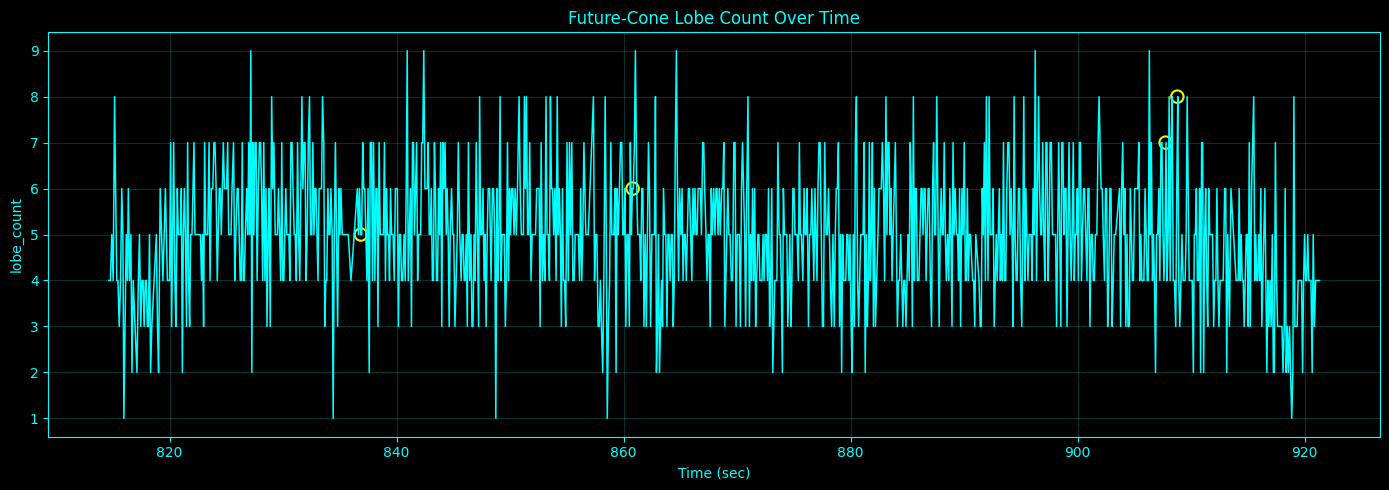

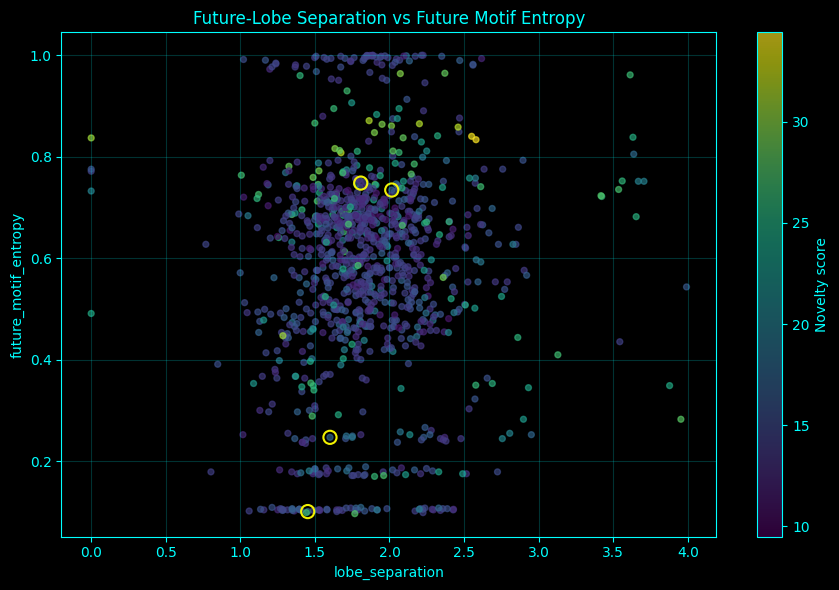

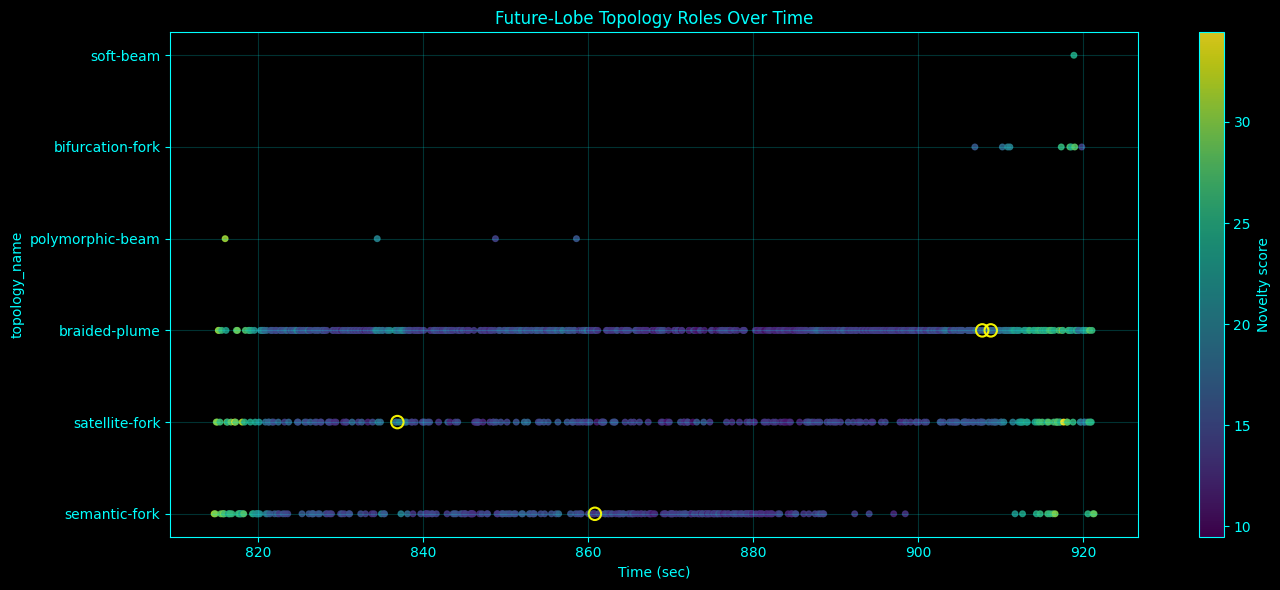

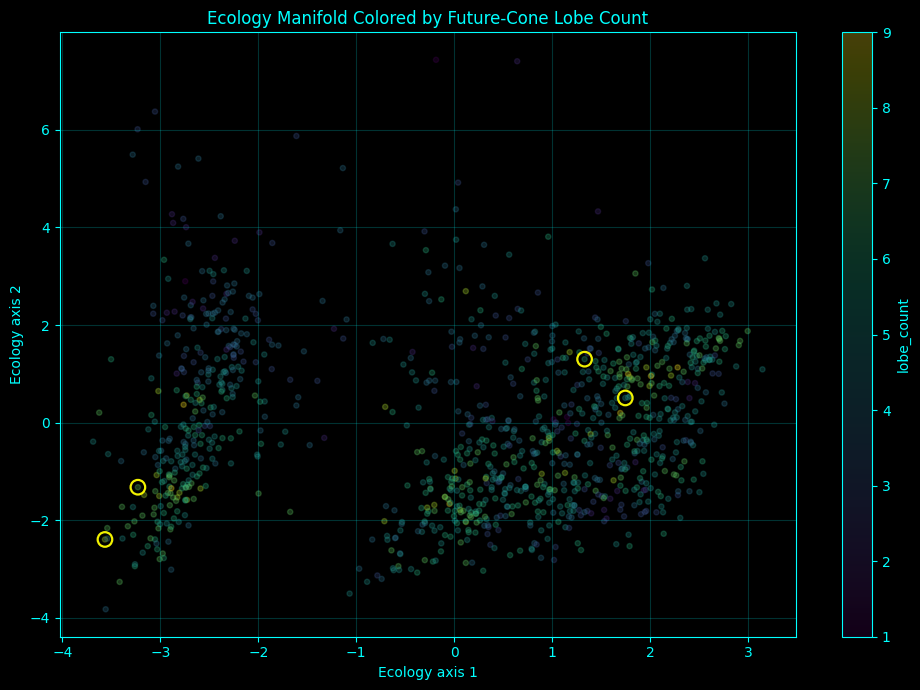

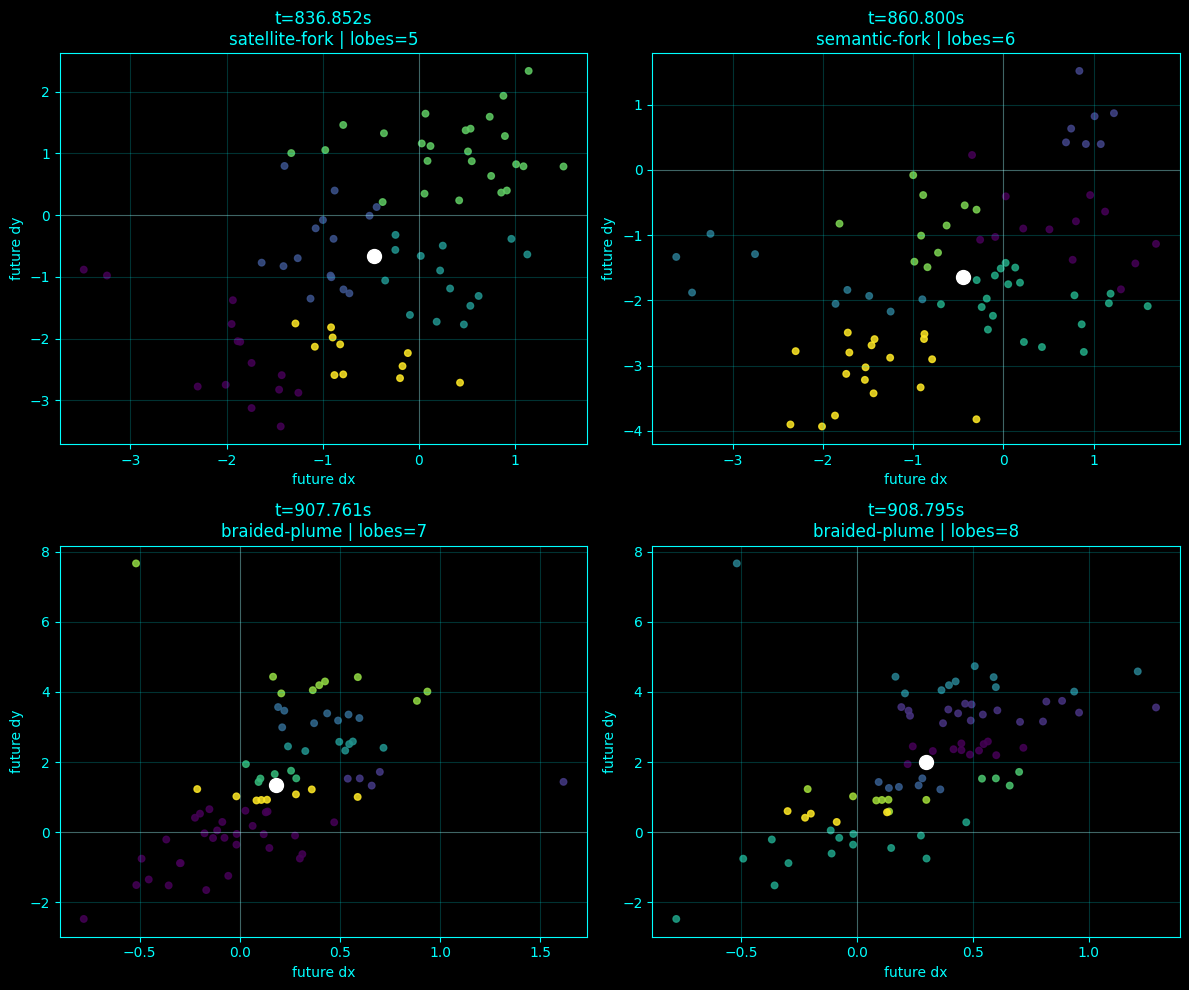


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/future_lobe_topology_atlas_v1/motif_field_with_lobe_topology.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/future_lobe_topology_atlas_v1/future_lobe_topology_segments.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/future_lobe_topology_atlas_v1/near_flat_lobe_topology_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/future_lobe_topology_atlas_v1/future_lobe_topology_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/future_lobe_topology_atlas_v1/plots

Topology counts:
topology_name
braided-plume       580
semantic-fork       249
satellite-fork      237
bifurcation-fork      9
polymorphic-beam      4
soft-beam             1

Top 15 longest topology segments:
 segment_id  start_time_sec  end_time_sec  duration_sec  n_windows  topology_name  dominant_motif_mode  lobe_count_mean  lobe_separation_mean  future_motif_entropy_mean  novelty_mean
        494        

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

future_dir = os.path.join(base_dir, "results", "counterfactual_future_cones_v1")
field_csv = os.path.join(future_dir, "motif_field_with_future_cones.csv")
near_flat_csv = os.path.join(future_dir, "near_flat_future_cone_context.csv")

out_dir = os.path.join(base_dir, "results", "future_lobe_topology_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Rebuild raw future cones
fate_horizon_sec = 1.50
temporal_exclusion_sec = 1.00
k_neighbors = 80
min_neighbors = 16

# Endpoint-cloud topology controls
component_scale = 1.60       # multiplier on median endpoint NN distance
min_component_size = 4

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def normalized_entropy_from_labels(labels):
    labels = np.asarray(labels)
    if len(labels) == 0:
        return np.nan
    _, counts = np.unique(labels, return_counts=True)
    p = counts / np.sum(counts)
    h = -np.sum(p * np.log(p + eps))
    return float(h / (np.log(len(counts) + eps) + eps))

def connected_components_from_distance_matrix(D, thresh):
    n = D.shape[0]
    seen = np.zeros(n, dtype=bool)
    comp_labels = -np.ones(n, dtype=int)
    comp_id = 0

    for i in range(n):
        if seen[i]:
            continue

        stack = [i]
        seen[i] = True
        comp_labels[i] = comp_id

        while stack:
            u = stack.pop()
            nbrs = np.where(D[u] <= thresh)[0]
            for v in nbrs:
                if not seen[v]:
                    seen[v] = True
                    comp_labels[v] = comp_id
                    stack.append(v)

        comp_id += 1

    return comp_labels

def adaptive_component_labels(P, scale=1.6):
    P = np.asarray(P, dtype=float)
    n = len(P)
    if n <= 1:
        return np.zeros(n, dtype=int), np.nan

    D = cdist(P, P)
    np.fill_diagonal(D, np.inf)
    nn = np.min(D, axis=1)
    thresh = scale * np.median(nn[np.isfinite(nn)])
    np.fill_diagonal(D, 0.0)

    labels = connected_components_from_distance_matrix(D, thresh)
    return labels, thresh

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def classify_cone_topology(row, q):
    lobe_count = row["lobe_count"]
    balance = row["lobe_balance"]
    separation = row["lobe_separation"]
    future_entropy = row["future_motif_entropy"]
    lobe_motif_div = row["lobe_motif_diversity"]
    endpoint_disp = row["endpoint_dispersion"]

    if lobe_count == 1 and future_entropy <= q["entropy25"]:
        return "condensate-beam"
    if lobe_count == 1 and future_entropy >= q["entropy75"]:
        return "polymorphic-beam"
    if lobe_count == 2 and balance >= q["balance50"] and separation >= q["sep75"]:
        return "bifurcation-fork"
    if lobe_count >= 2 and balance < q["balance50"] and separation >= q["sep50"]:
        return "satellite-fork"
    if lobe_count >= 2 and lobe_motif_div >= q["motifdiv75"]:
        return "semantic-fork"
    if lobe_count >= 3:
        return "braided-plume"
    if endpoint_disp >= q["disp75"] and future_entropy >= q["entropy50"]:
        return "diffuse-plume"
    return "soft-beam"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

required_cols = [
    "center_time_sec", "eco_x", "eco_y",
    "dominant_motif", "novelty_score",
    "endpoint_dispersion", "future_motif_entropy"
]
for c in required_cols:
    if c not in field_df.columns:
        raise ValueError(f"Missing required column: {c}")

# -------------------------------------------------------
# REBUILD RAW FUTURE ENDPOINT CLOUDS
# -------------------------------------------------------
t = field_df["center_time_sec"].values
x = field_df["eco_x"].values
y = field_df["eco_y"].values
motif = field_df["dominant_motif"].values

dt_med = np.median(np.diff(t))
horizon_steps = max(3, int(np.round(fate_horizon_sec / max(dt_med, eps))))

XY = np.column_stack([x, y])
tree = cKDTree(XY)

topology_rows = []
near_flat_endpoint_clouds = {}

for i in range(len(field_df)):
    idx = np.atleast_1d(tree.query(XY[i], k=min(k_neighbors + 1, len(field_df)))[1])
    idx = idx[idx != i]
    idx = idx[np.abs(t[idx] - t[i]) >= temporal_exclusion_sec]
    idx = np.asarray([j for j in idx if j + horizon_steps < len(field_df)], dtype=int)

    if len(idx) < min_neighbors:
        topology_rows.append({
            "row_index": i,
            "lobe_count": np.nan,
            "lobe_balance": np.nan,
            "lobe_separation": np.nan,
            "largest_lobe_fraction": np.nan,
            "lobe_motif_diversity": np.nan,
            "topology_name": "undefined",
        })
        continue

    endpoints = np.column_stack([
        x[idx + horizon_steps] - x[idx],
        y[idx + horizon_steps] - y[idx]
    ])
    future_motifs = motif[idx + horizon_steps]

    comp_labels, thresh = adaptive_component_labels(endpoints, scale=component_scale)

    # remove tiny components by folding them into "noise" notion
    comp_sizes_raw = pd.Series(comp_labels).value_counts().sort_index()
    keep_components = comp_sizes_raw[comp_sizes_raw >= min_component_size].index.tolist()

    if len(keep_components) == 0:
        # everything tiny -> treat as one diffuse lobe
        comp_labels = np.zeros(len(endpoints), dtype=int)
        keep_components = [0]
    else:
        remap = {}
        next_id = 0
        new_labels = -np.ones(len(comp_labels), dtype=int)

        for c in keep_components:
            m = comp_labels == c
            new_labels[m] = next_id
            remap[c] = next_id
            next_id += 1

        # fold discarded points into nearest kept centroid
        kept_centroids = []
        for c in keep_components:
            kept_centroids.append(np.mean(endpoints[comp_labels == c], axis=0))
        kept_centroids = np.asarray(kept_centroids, dtype=float)

        for j in range(len(new_labels)):
            if new_labels[j] == -1:
                d = np.linalg.norm(kept_centroids - endpoints[j], axis=1)
                new_labels[j] = int(np.argmin(d))

        comp_labels = new_labels

    comps = sorted(np.unique(comp_labels))
    comp_sizes = np.array([(comp_labels == c).sum() for c in comps], dtype=float)
    comp_fracs = comp_sizes / np.sum(comp_sizes)
    lobe_count = len(comps)
    largest_lobe_fraction = float(np.max(comp_fracs))
    lobe_balance = float(np.sort(comp_fracs)[-2] / np.max(comp_fracs)) if lobe_count >= 2 else 0.0

    centroids = np.array([np.mean(endpoints[comp_labels == c], axis=0) for c in comps], dtype=float)
    spreads = np.array([
        np.mean(np.linalg.norm(endpoints[comp_labels == c] - centroids[k], axis=1))
        for k, c in enumerate(comps)
    ], dtype=float)

    if lobe_count >= 2:
        centroid_D = cdist(centroids, centroids)
        centroid_D[centroid_D == 0] = np.inf
        min_centroid_dist = np.min(centroid_D)
        lobe_separation = float(min_centroid_dist / (np.mean(spreads) + eps))
    else:
        lobe_separation = 0.0

    lobe_dominant_motifs = []
    for c in comps:
        lbls = future_motifs[comp_labels == c]
        lobe_dominant_motifs.append(pd.Series(lbls).mode().iloc[0])

    lobe_motif_diversity = float(len(np.unique(lobe_dominant_motifs)) / max(lobe_count, 1))

    topology_rows.append({
        "row_index": i,
        "lobe_count": int(lobe_count),
        "lobe_balance": float(lobe_balance),
        "lobe_separation": float(lobe_separation),
        "largest_lobe_fraction": float(largest_lobe_fraction),
        "lobe_motif_diversity": float(lobe_motif_diversity),
        "component_threshold": float(thresh) if np.isfinite(thresh) else np.nan,
        "topology_name": "pending",
    })

    # keep near-flat clouds for plotting
    if len(near_flat_df) > 0:
        t_nearest = t[i]
        close_nf = np.where(np.abs(near_flat_df["nearest_field_time_sec"].values - t_nearest) < 1e-6)[0]
        if len(close_nf) > 0:
            near_flat_endpoint_clouds[int(close_nf[0])] = {
                "time_sec": float(near_flat_df.iloc[close_nf[0]]["time_sec"]),
                "field_time_sec": float(t_nearest),
                "endpoints": endpoints,
                "labels": comp_labels,
                "future_motifs": future_motifs,
            }

topology_df = pd.DataFrame(topology_rows)
field_df = pd.concat([field_df.reset_index(drop=True), topology_df.drop(columns=["row_index"])], axis=1)

valid = field_df[np.isfinite(field_df["lobe_count"])].copy()

# -------------------------------------------------------
# TOPOLOGY LABELS
# -------------------------------------------------------
multi = valid[valid["lobe_count"] >= 2].copy()

q = {
    "entropy25": np.quantile(valid["future_motif_entropy"], 0.25),
    "entropy50": np.quantile(valid["future_motif_entropy"], 0.50),
    "entropy75": np.quantile(valid["future_motif_entropy"], 0.75),
    "disp75": np.quantile(valid["endpoint_dispersion"], 0.75),
    "balance50": np.quantile(multi["lobe_balance"], 0.50) if len(multi) else 0.5,
    "sep50": np.quantile(multi["lobe_separation"], 0.50) if len(multi) else 1.0,
    "sep75": np.quantile(multi["lobe_separation"], 0.75) if len(multi) else 1.5,
    "motifdiv75": np.quantile(valid["lobe_motif_diversity"], 0.75),
}

field_df["topology_name"] = field_df.apply(
    lambda r: classify_cone_topology(r, q) if np.isfinite(r["lobe_count"]) else "undefined",
    axis=1
)

# -------------------------------------------------------
# CONTIGUOUS TOPOLOGY SEGMENTS
# -------------------------------------------------------
segments = []
if len(field_df) > 0:
    start_i = 0
    labels = field_df["topology_name"].values
    for i in range(1, len(field_df)):
        changed = (labels[i] != labels[i - 1]) or ((t[i] - t[i - 1]) > 0.5)
        if changed:
            segments.append((start_i, i - 1))
            start_i = i
    segments.append((start_i, len(field_df) - 1))

segment_rows = []
for seg_id, (i0, i1) in enumerate(segments, start=1):
    sub = field_df.iloc[i0:i1 + 1]
    segment_rows.append({
        "segment_id": seg_id,
        "start_time_sec": float(sub["center_time_sec"].iloc[0]),
        "end_time_sec": float(sub["center_time_sec"].iloc[-1]),
        "duration_sec": float(sub["center_time_sec"].iloc[-1] - sub["center_time_sec"].iloc[0]),
        "n_windows": int(len(sub)),
        "topology_name": sub["topology_name"].mode().iloc[0],
        "dominant_motif_mode": int(sub["dominant_motif"].mode().iloc[0]),
        "lobe_count_mean": safe_mean(sub["lobe_count"].values),
        "lobe_separation_mean": safe_mean(sub["lobe_separation"].values),
        "future_motif_entropy_mean": safe_mean(sub["future_motif_entropy"].values),
        "novelty_mean": safe_mean(sub["novelty_score"].values),
    })

segment_df = pd.DataFrame(segment_rows).sort_values("start_time_sec").reset_index(drop=True)

# -------------------------------------------------------
# NEAR-FLAT TOPOLOGY CONTEXT
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t0)))
        fr = field_df.iloc[idx]

        near_flat_rows.append({
            "time_sec": t0,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "dominant_motif": int(fr["dominant_motif"]),
            "flow_role": fr.get("flow_role", "NA"),
            "fate_role": fr.get("fate_role", "NA"),
            "topology_name": fr["topology_name"],
            "lobe_count": int(fr["lobe_count"]),
            "lobe_balance": float(fr["lobe_balance"]),
            "lobe_separation": float(fr["lobe_separation"]),
            "largest_lobe_fraction": float(fr["largest_lobe_fraction"]),
            "lobe_motif_diversity": float(fr["lobe_motif_diversity"]),
            "endpoint_dispersion": float(fr["endpoint_dispersion"]),
            "future_motif_entropy": float(fr["future_motif_entropy"]),
            "eco_x": float(fr["eco_x"]),
            "eco_y": float(fr["eco_y"]),
        })

near_flat_topology_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_out_csv = os.path.join(out_dir, "motif_field_with_lobe_topology.csv")
segment_csv = os.path.join(out_dir, "future_lobe_topology_segments.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_lobe_topology_context.csv")
summary_txt = os.path.join(out_dir, "future_lobe_topology_summary.txt")

field_df.to_csv(field_out_csv, index=False)
segment_df.to_csv(segment_csv, index=False)
near_flat_topology_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Future-Lobe Topology Atlas Summary\n")
    f.write("=================================\n\n")
    f.write(f"fate_horizon_sec = {fate_horizon_sec}\n")
    f.write(f"temporal_exclusion_sec = {temporal_exclusion_sec}\n")
    f.write(f"k_neighbors = {k_neighbors}\n")
    f.write(f"component_scale = {component_scale}\n")
    f.write(f"min_component_size = {min_component_size}\n")
    f.write(f"horizon_steps = {horizon_steps}\n\n")

    f.write("Topology counts:\n")
    f.write(field_df["topology_name"].value_counts().to_string())
    f.write("\n\n")

    f.write("Top 20 longest topology segments:\n")
    f.write(segment_df.sort_values("duration_sec", ascending=False).head(20).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_topology_df) > 0:
        f.write("Near-flat topology context:\n")
        f.write(near_flat_topology_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Lobe count over time
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    field_df["center_time_sec"].values,
    field_df["lobe_count"].values,
    color=ACCENT,
    linewidth=1.1
)

if len(near_flat_topology_df) > 0:
    ax.scatter(
        near_flat_topology_df["time_sec"].values,
        near_flat_topology_df["lobe_count"].values,
        s=80,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Future-Cone Lobe Count Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("lobe_count")

plot1_path = os.path.join(plots_dir, "lobe_count_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Lobe separation vs future entropy
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["lobe_separation"].values,
    field_df["future_motif_entropy"].values,
    c=field_df["novelty_score"].values,
    s=18,
    alpha=0.65
)

if len(near_flat_topology_df) > 0:
    ax.scatter(
        near_flat_topology_df["lobe_separation"].values,
        near_flat_topology_df["future_motif_entropy"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Future-Lobe Separation vs Future Motif Entropy")
ax.set_xlabel("lobe_separation")
ax.set_ylabel("future_motif_entropy")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot2_path = os.path.join(plots_dir, "lobe_separation_vs_entropy.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Topology role timeline
role_names = list(pd.Series(field_df["topology_name"]).dropna().unique())
role_to_y = {r: i for i, r in enumerate(role_names)}

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["center_time_sec"].values,
    [role_to_y[r] for r in field_df["topology_name"].values],
    c=field_df["novelty_score"].values,
    s=16,
    alpha=0.85
)

if len(near_flat_topology_df) > 0:
    ax.scatter(
        near_flat_topology_df["time_sec"].values,
        [role_to_y[r] for r in near_flat_topology_df["topology_name"].values],
        s=80,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_yticks(list(role_to_y.values()))
ax.set_yticklabels(list(role_to_y.keys()))
ax.set_title("Future-Lobe Topology Roles Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("topology_name")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot3_path = os.path.join(plots_dir, "topology_role_timeline.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Ecology manifold colored by lobe count
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["eco_x"].values,
    field_df["eco_y"].values,
    c=field_df["lobe_count"].values,
    s=14,
    alpha=0.28
)

if len(near_flat_topology_df) > 0:
    ax.scatter(
        near_flat_topology_df["eco_x"].values,
        near_flat_topology_df["eco_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95
    )

ax.set_title("Ecology Manifold Colored by Future-Cone Lobe Count")
ax.set_xlabel("Ecology axis 1")
ax.set_ylabel("Ecology axis 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "lobe_count")

plot4_path = os.path.join(plots_dir, "ecology_manifold_lobe_count.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Near-flat local endpoint clouds colored by lobe label
if len(near_flat_topology_df) > 0 and len(near_flat_endpoint_clouds) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor=BG)
    axes = axes.ravel()

    for ax, (nf_idx, payload) in zip(axes, near_flat_endpoint_clouds.items()):
        style_ax(ax)

        P = payload["endpoints"]
        L = payload["labels"]
        motifs = payload["future_motifs"]

        sc = ax.scatter(
            P[:, 0],
            P[:, 1],
            c=L,
            s=22,
            alpha=0.85
        )

        mu = np.mean(P, axis=0)
        ax.scatter(mu[0], mu[1], s=100, color="white", zorder=5)

        ax.axhline(0.0, color="white", alpha=0.25, linewidth=0.8)
        ax.axvline(0.0, color="white", alpha=0.25, linewidth=0.8)

        row_nf = near_flat_topology_df.iloc[nf_idx]
        ax.set_title(
            f"t={payload['time_sec']:.3f}s\n"
            f"{row_nf['topology_name']} | lobes={int(row_nf['lobe_count'])}"
        )
        ax.set_xlabel("future dx")
        ax.set_ylabel("future dy")

    plot5_path = os.path.join(plots_dir, "nearflat_endpoint_lobes.png")
    plt.tight_layout()
    plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot5_path = None

print("\nSaved:")
print(field_out_csv)
print(segment_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print("\nTopology counts:")
print(field_df["topology_name"].value_counts().to_string())

print("\nTop 15 longest topology segments:")
print(segment_df.sort_values("duration_sec", ascending=False).head(15).to_string(index=False))

if len(near_flat_topology_df) > 0:
    print("\nNear-flat topology context:")
    print(near_flat_topology_df.to_string(index=False))

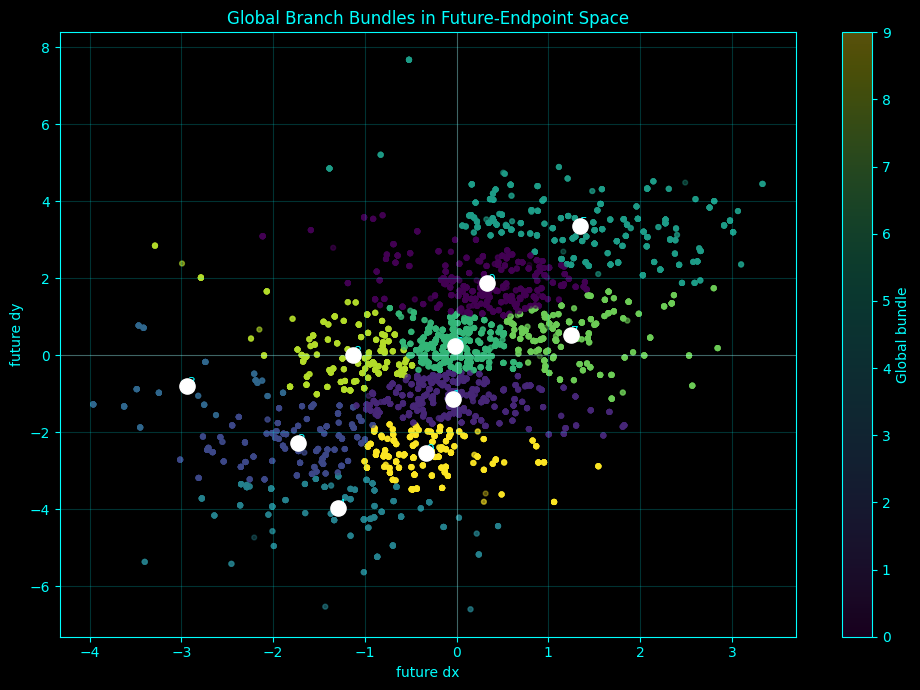

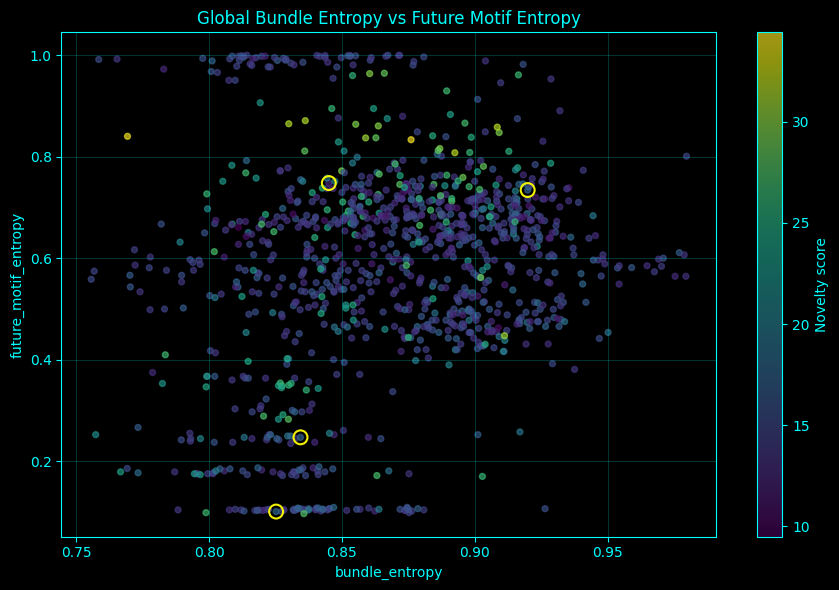

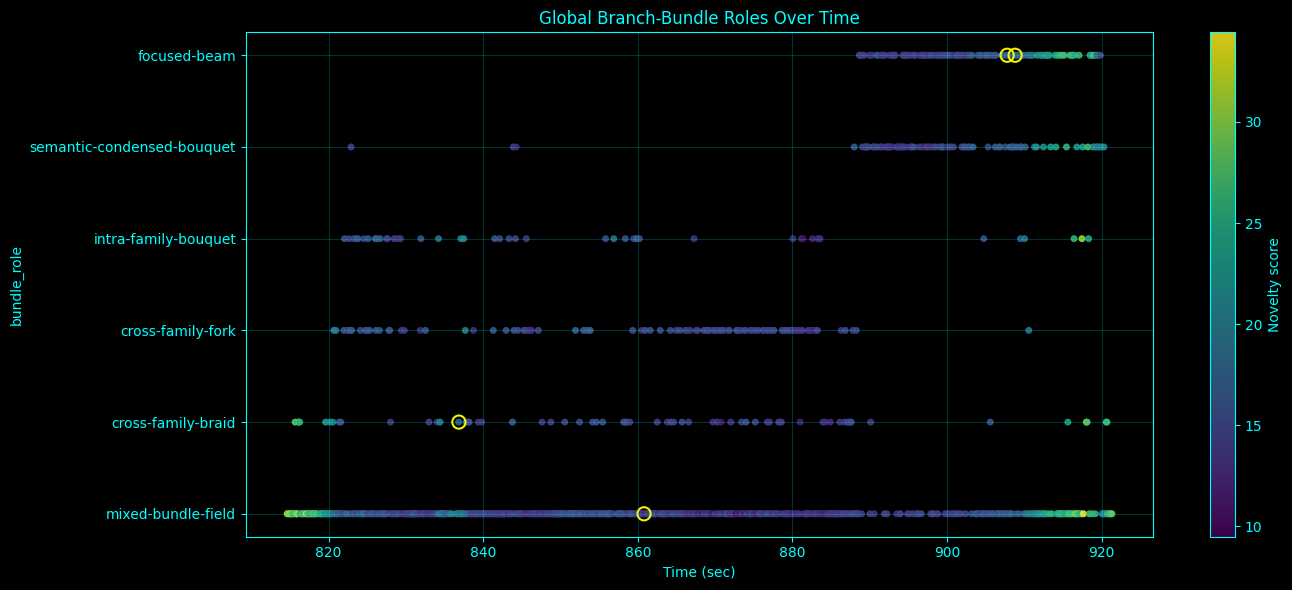

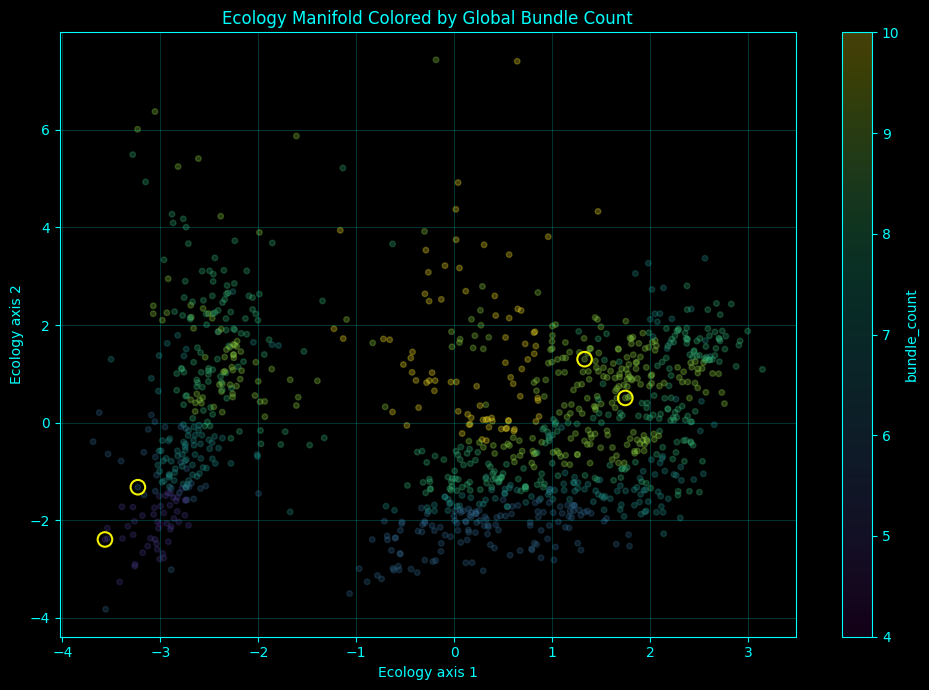

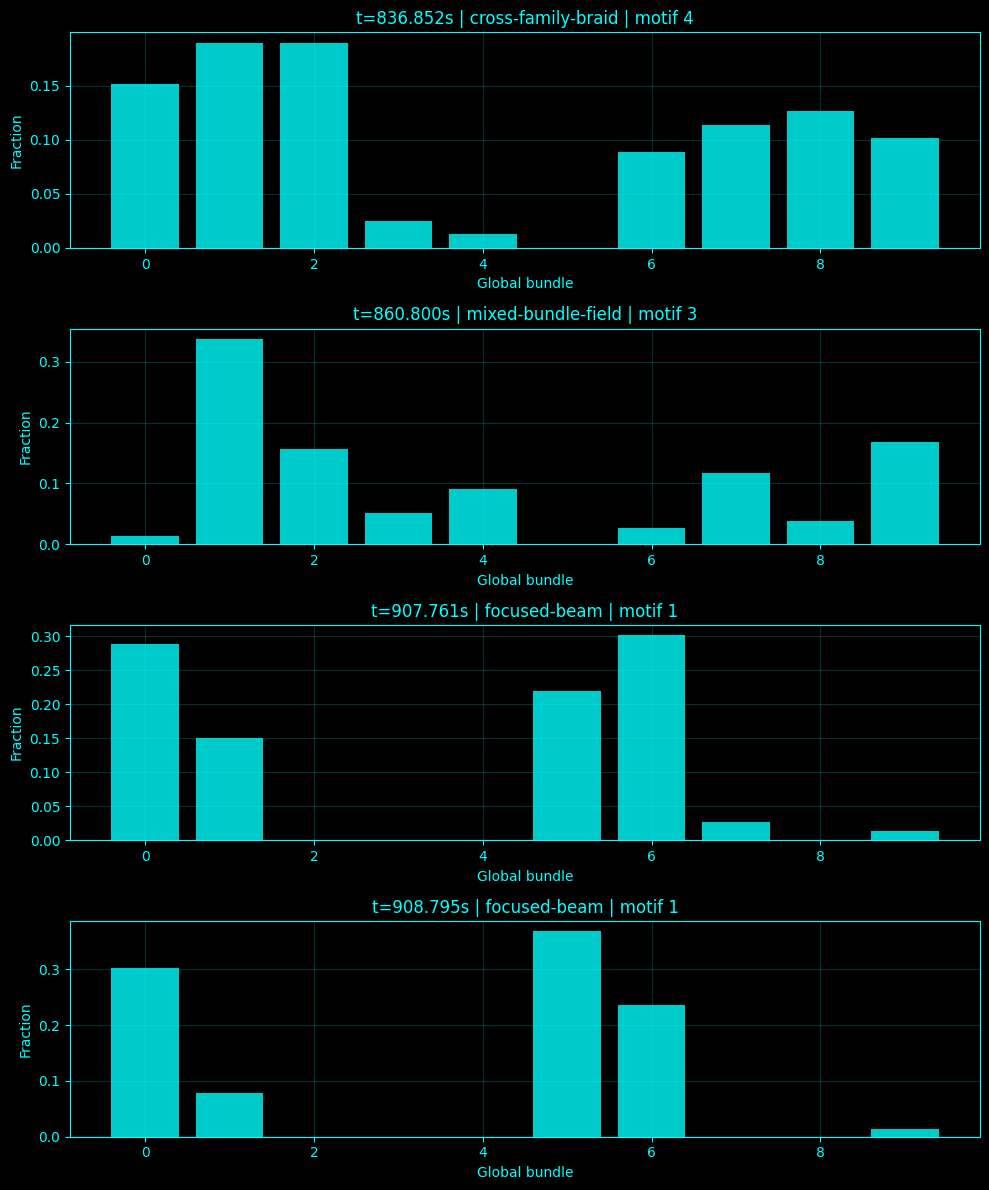


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/global_branch_bundle_atlas_v1/motif_field_with_global_bundles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/global_branch_bundle_atlas_v1/global_branch_bundle_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/global_branch_bundle_atlas_v1/global_branch_bundle_endpoints.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/global_branch_bundle_atlas_v1/global_bundle_role_segments.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/global_branch_bundle_atlas_v1/near_flat_global_bundle_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/global_branch_bundle_atlas_v1/global_branch_bundle_atlas_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/global_branch_bundle_atlas_v1/plots

Global bundle summary:
 global_bundle  count  centroid_dx  centroid_dy  dominant_future_motif  motif_purity  motif_entropy  mean_radius
             0  12919     0.3

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree, distance
from scipy.cluster.vq import kmeans2

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

topo_dir = os.path.join(base_dir, "results", "future_lobe_topology_atlas_v1")
field_csv = os.path.join(topo_dir, "motif_field_with_lobe_topology.csv")
near_flat_csv = os.path.join(topo_dir, "near_flat_lobe_topology_context.csv")

out_dir = os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Rebuild endpoint clouds
fate_horizon_sec = 1.50
temporal_exclusion_sec = 1.00
k_neighbors = 80
min_neighbors = 16

# Global bundle discovery
n_global_bundles = 10
bundle_fit_subsample = 12000
rng_seed = 42

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def normalized_entropy(counts):
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return np.nan
    p = counts / np.sum(counts)
    h = -np.sum(p * np.log(p + eps))
    return float(h / (np.log(len(p) + eps) + eps))

def classify_bundle_role(row, q):
    bundle_entropy = row["bundle_entropy"]
    motif_entropy = row["future_motif_entropy"]
    bundle_count = row["bundle_count"]
    dominant_bundle_fraction = row["dominant_bundle_fraction"]
    bundle_to_motif_ratio = row["bundle_to_motif_ratio"]
    cross_bundle_motif_diversity = row["cross_bundle_motif_diversity"]

    if bundle_entropy >= q["bundle_entropy75"] and motif_entropy >= q["motif_entropy75"]:
        return "cross-family-braid"
    if bundle_entropy >= q["bundle_entropy75"] and motif_entropy <= q["motif_entropy25"]:
        return "intra-family-bouquet"
    if bundle_entropy <= q["bundle_entropy25"] and motif_entropy <= q["motif_entropy25"]:
        return "focused-beam"
    if bundle_to_motif_ratio >= q["ratio75"] and motif_entropy <= q["motif_entropy50"]:
        return "semantic-condensed-bouquet"
    if cross_bundle_motif_diversity >= q["bundle_motif_div75"] and motif_entropy >= q["motif_entropy50"]:
        return "cross-family-fork"
    return "mixed-bundle-field"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

required_cols = [
    "center_time_sec",
    "eco_x",
    "eco_y",
    "dominant_motif",
    "future_motif_entropy",
    "novelty_score"
]
for c in required_cols:
    if c not in field_df.columns:
        raise ValueError(f"Missing required column: {c}")

# -------------------------------------------------------
# REBUILD RAW FUTURE ENDPOINTS
# -------------------------------------------------------
t = field_df["center_time_sec"].values
x = field_df["eco_x"].values
y = field_df["eco_y"].values
motif = field_df["dominant_motif"].values.astype(int)

dt_med = np.median(np.diff(t))
horizon_steps = max(3, int(np.round(fate_horizon_sec / max(dt_med, eps))))

XY = np.column_stack([x, y])
tree = cKDTree(XY)

endpoint_rows = []
window_payload = []

for i in range(len(field_df)):
    idx = np.atleast_1d(tree.query(XY[i], k=min(k_neighbors + 1, len(field_df)))[1])
    idx = idx[idx != i]
    idx = idx[np.abs(t[idx] - t[i]) >= temporal_exclusion_sec]
    idx = np.asarray([j for j in idx if j + horizon_steps < len(field_df)], dtype=int)

    if len(idx) < min_neighbors:
        window_payload.append(None)
        continue

    future_dx = x[idx + horizon_steps] - x[idx]
    future_dy = y[idx + horizon_steps] - y[idx]
    future_motif = motif[idx + horizon_steps]

    payload = {
        "window_index": i,
        "time_sec": float(t[i]),
        "future_dx": future_dx,
        "future_dy": future_dy,
        "future_motif": future_motif,
    }
    window_payload.append(payload)

    for dxv, dyv, mf in zip(future_dx, future_dy, future_motif):
        endpoint_rows.append({
            "window_index": i,
            "time_sec": float(t[i]),
            "future_dx": float(dxv),
            "future_dy": float(dyv),
            "future_motif": int(mf),
        })

endpoint_df = pd.DataFrame(endpoint_rows)
if len(endpoint_df) == 0:
    raise RuntimeError("No future endpoints reconstructed.")

# -------------------------------------------------------
# GLOBAL BRANCH BUNDLE DISCOVERY
# -------------------------------------------------------
rng = np.random.default_rng(rng_seed)
P = endpoint_df[["future_dx", "future_dy"]].values

if len(P) > bundle_fit_subsample:
    fit_idx = rng.choice(len(P), size=bundle_fit_subsample, replace=False)
    P_fit = P[fit_idx]
else:
    P_fit = P.copy()

# kmeans over global endpoint displacement space
centroids, labels_fit = kmeans2(P_fit.astype(float), n_global_bundles, minit="points", iter=30)

# assign every endpoint to nearest global bundle centroid
D = distance.cdist(P, centroids)
bundle_labels = np.argmin(D, axis=1)
endpoint_df["global_bundle"] = bundle_labels.astype(int)

# summarize global bundles
bundle_rows = []
for b in sorted(endpoint_df["global_bundle"].unique()):
    sub = endpoint_df[endpoint_df["global_bundle"] == b]
    motif_counts = sub["future_motif"].value_counts().sort_index()
    dominant_motif = int(motif_counts.idxmax())
    purity = float(motif_counts.max() / motif_counts.sum())

    bundle_rows.append({
        "global_bundle": int(b),
        "count": int(len(sub)),
        "centroid_dx": float(np.mean(sub["future_dx"])),
        "centroid_dy": float(np.mean(sub["future_dy"])),
        "dominant_future_motif": dominant_motif,
        "motif_purity": purity,
        "motif_entropy": normalized_entropy(motif_counts.values),
        "mean_radius": float(np.mean(np.linalg.norm(sub[["future_dx", "future_dy"]].values - np.mean(sub[["future_dx", "future_dy"]].values, axis=0), axis=1))),
    })

bundle_summary_df = pd.DataFrame(bundle_rows).sort_values("global_bundle").reset_index(drop=True)

bundle_to_dom_motif = dict(zip(bundle_summary_df["global_bundle"], bundle_summary_df["dominant_future_motif"]))

# -------------------------------------------------------
# PER-WINDOW BUNDLE SEMANTICS
# -------------------------------------------------------
window_rows = []

for i, payload in enumerate(window_payload):
    if payload is None:
        window_rows.append({
            "bundle_count": np.nan,
            "bundle_entropy": np.nan,
            "dominant_bundle_fraction": np.nan,
            "bundle_to_motif_ratio": np.nan,
            "cross_bundle_motif_diversity": np.nan,
            "bundle_role": "undefined",
        })
        continue

    sub = endpoint_df[endpoint_df["window_index"] == i].copy()
    bundle_counts = sub["global_bundle"].value_counts().sort_index()
    motif_counts = sub["future_motif"].value_counts().sort_index()

    bundle_count = int(len(bundle_counts))
    bundle_entropy = normalized_entropy(bundle_counts.values)
    dominant_bundle_fraction = float(bundle_counts.max() / bundle_counts.sum())

    future_motif_count = max(len(motif_counts), 1)
    bundle_to_motif_ratio = float(bundle_count / future_motif_count)

    present_bundles = bundle_counts.index.tolist()
    dom_motifs = [bundle_to_dom_motif[b] for b in present_bundles]
    cross_bundle_motif_diversity = float(len(np.unique(dom_motifs)) / max(len(present_bundles), 1))

    window_rows.append({
        "bundle_count": bundle_count,
        "bundle_entropy": bundle_entropy,
        "dominant_bundle_fraction": dominant_bundle_fraction,
        "bundle_to_motif_ratio": bundle_to_motif_ratio,
        "cross_bundle_motif_diversity": cross_bundle_motif_diversity,
        "bundle_role": "pending",
    })

window_metrics_df = pd.DataFrame(window_rows)
field_df = pd.concat([field_df.reset_index(drop=True), window_metrics_df], axis=1)

valid = field_df[np.isfinite(field_df["bundle_count"])].copy()

q = {
    "bundle_entropy25": np.quantile(valid["bundle_entropy"], 0.25),
    "bundle_entropy75": np.quantile(valid["bundle_entropy"], 0.75),
    "motif_entropy25": np.quantile(valid["future_motif_entropy"], 0.25),
    "motif_entropy50": np.quantile(valid["future_motif_entropy"], 0.50),
    "motif_entropy75": np.quantile(valid["future_motif_entropy"], 0.75),
    "ratio75": np.quantile(valid["bundle_to_motif_ratio"], 0.75),
    "bundle_motif_div75": np.quantile(valid["cross_bundle_motif_diversity"], 0.75),
}

field_df["bundle_role"] = field_df.apply(
    lambda r: classify_bundle_role(r, q) if np.isfinite(r["bundle_count"]) else "undefined",
    axis=1
)

# -------------------------------------------------------
# CONTIGUOUS BUNDLE-ROLE SEGMENTS
# -------------------------------------------------------
segments = []
if len(field_df) > 0:
    start_i = 0
    labels = field_df["bundle_role"].values
    for i in range(1, len(field_df)):
        changed = (labels[i] != labels[i - 1]) or ((t[i] - t[i - 1]) > 0.5)
        if changed:
            segments.append((start_i, i - 1))
            start_i = i
    segments.append((start_i, len(field_df) - 1))

segment_rows = []
for seg_id, (i0, i1) in enumerate(segments, start=1):
    sub = field_df.iloc[i0:i1 + 1]
    segment_rows.append({
        "segment_id": seg_id,
        "start_time_sec": float(sub["center_time_sec"].iloc[0]),
        "end_time_sec": float(sub["center_time_sec"].iloc[-1]),
        "duration_sec": float(sub["center_time_sec"].iloc[-1] - sub["center_time_sec"].iloc[0]),
        "n_windows": int(len(sub)),
        "bundle_role": sub["bundle_role"].mode().iloc[0],
        "dominant_motif_mode": int(sub["dominant_motif"].mode().iloc[0]),
        "bundle_count_mean": safe_mean(sub["bundle_count"].values),
        "bundle_entropy_mean": safe_mean(sub["bundle_entropy"].values),
        "future_motif_entropy_mean": safe_mean(sub["future_motif_entropy"].values),
        "novelty_mean": safe_mean(sub["novelty_score"].values),
    })

segment_df = pd.DataFrame(segment_rows).sort_values("start_time_sec").reset_index(drop=True)

# -------------------------------------------------------
# NEAR-FLAT BUNDLE CONTEXT
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t0)))
        fr = field_df.iloc[idx]

        sub = endpoint_df[endpoint_df["window_index"] == idx]
        bundle_counts = sub["global_bundle"].value_counts(normalize=True).sort_index()

        out = {
            "time_sec": t0,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "dominant_motif": int(fr["dominant_motif"]),
            "topology_name": fr.get("topology_name", "NA"),
            "bundle_role": fr["bundle_role"],
            "bundle_count": int(fr["bundle_count"]),
            "bundle_entropy": float(fr["bundle_entropy"]),
            "future_motif_entropy": float(fr["future_motif_entropy"]),
            "bundle_to_motif_ratio": float(fr["bundle_to_motif_ratio"]),
            "cross_bundle_motif_diversity": float(fr["cross_bundle_motif_diversity"]),
            "eco_x": float(fr["eco_x"]),
            "eco_y": float(fr["eco_y"]),
        }

        for b in range(n_global_bundles):
            out[f"bundle_{b}_fraction"] = float(bundle_counts.get(b, 0.0))

        near_flat_rows.append(out)

near_flat_bundle_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_out_csv = os.path.join(out_dir, "motif_field_with_global_bundles.csv")
bundle_summary_csv = os.path.join(out_dir, "global_branch_bundle_summary.csv")
endpoint_csv = os.path.join(out_dir, "global_branch_bundle_endpoints.csv")
segment_csv = os.path.join(out_dir, "global_bundle_role_segments.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_global_bundle_context.csv")
summary_txt = os.path.join(out_dir, "global_branch_bundle_atlas_summary.txt")

field_df.to_csv(field_out_csv, index=False)
bundle_summary_df.to_csv(bundle_summary_csv, index=False)
endpoint_df.to_csv(endpoint_csv, index=False)
segment_df.to_csv(segment_csv, index=False)
near_flat_bundle_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Global Branch-Bundle Atlas Summary\n")
    f.write("=================================\n\n")
    f.write(f"n_global_bundles = {n_global_bundles}\n")
    f.write(f"fate_horizon_sec = {fate_horizon_sec}\n")
    f.write(f"temporal_exclusion_sec = {temporal_exclusion_sec}\n")
    f.write(f"k_neighbors = {k_neighbors}\n")
    f.write(f"horizon_steps = {horizon_steps}\n\n")

    f.write("Global bundle summary:\n")
    f.write(bundle_summary_df.to_string(index=False))
    f.write("\n\n")

    f.write("Bundle-role counts:\n")
    f.write(field_df["bundle_role"].value_counts().to_string())
    f.write("\n\n")

    f.write("Top 20 longest bundle-role segments:\n")
    f.write(segment_df.sort_values("duration_sec", ascending=False).head(20).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_bundle_df) > 0:
        f.write("Near-flat global bundle context:\n")
        f.write(near_flat_bundle_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Global branch bundle map in endpoint space
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sub_plot = endpoint_df.sample(min(len(endpoint_df), 15000), random_state=rng_seed)
sc = ax.scatter(
    sub_plot["future_dx"].values,
    sub_plot["future_dy"].values,
    c=sub_plot["global_bundle"].values,
    s=12,
    alpha=0.35
)

ax.scatter(
    bundle_summary_df["centroid_dx"].values,
    bundle_summary_df["centroid_dy"].values,
    s=120,
    color="white",
    zorder=5
)

for _, row in bundle_summary_df.iterrows():
    ax.text(row["centroid_dx"], row["centroid_dy"], str(int(row["global_bundle"])), fontsize=9)

ax.axhline(0.0, color="white", alpha=0.25, linewidth=0.8)
ax.axvline(0.0, color="white", alpha=0.25, linewidth=0.8)
ax.set_title("Global Branch Bundles in Future-Endpoint Space")
ax.set_xlabel("future dx")
ax.set_ylabel("future dy")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Global bundle")

plot1_path = os.path.join(plots_dir, "global_branch_bundle_map.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Bundle entropy vs future motif entropy
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["bundle_entropy"].values,
    field_df["future_motif_entropy"].values,
    c=field_df["novelty_score"].values,
    s=18,
    alpha=0.65
)

if len(near_flat_bundle_df) > 0:
    ax.scatter(
        near_flat_bundle_df["bundle_entropy"].values,
        near_flat_bundle_df["future_motif_entropy"].values,
        s=100,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Global Bundle Entropy vs Future Motif Entropy")
ax.set_xlabel("bundle_entropy")
ax.set_ylabel("future_motif_entropy")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot2_path = os.path.join(plots_dir, "bundle_entropy_vs_motif_entropy.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Bundle role timeline
role_names = list(pd.Series(field_df["bundle_role"]).dropna().unique())
role_to_y = {r: i for i, r in enumerate(role_names)}

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["center_time_sec"].values,
    [role_to_y[r] for r in field_df["bundle_role"].values],
    c=field_df["novelty_score"].values,
    s=16,
    alpha=0.85
)

if len(near_flat_bundle_df) > 0:
    ax.scatter(
        near_flat_bundle_df["time_sec"].values,
        [role_to_y[r] for r in near_flat_bundle_df["bundle_role"].values],
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_yticks(list(role_to_y.values()))
ax.set_yticklabels(list(role_to_y.keys()))
ax.set_title("Global Branch-Bundle Roles Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("bundle_role")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot3_path = os.path.join(plots_dir, "bundle_role_timeline.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Ecology manifold colored by bundle count
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["eco_x"].values,
    field_df["eco_y"].values,
    c=field_df["bundle_count"].values,
    s=16,
    alpha=0.28
)

if len(near_flat_bundle_df) > 0:
    ax.scatter(
        near_flat_bundle_df["eco_x"].values,
        near_flat_bundle_df["eco_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Ecology Manifold Colored by Global Bundle Count")
ax.set_xlabel("Ecology axis 1")
ax.set_ylabel("Ecology axis 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "bundle_count")

plot4_path = os.path.join(plots_dir, "ecology_manifold_bundle_count.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Near-flat bundle occupancy bars
if len(near_flat_bundle_df) > 0:
    fig, axes = plt.subplots(len(near_flat_bundle_df), 1, figsize=(10, 3 * len(near_flat_bundle_df)), facecolor=BG)
    if len(near_flat_bundle_df) == 1:
        axes = [axes]

    bundle_cols = [f"bundle_{b}_fraction" for b in range(n_global_bundles)]

    for ax, (_, row) in zip(axes, near_flat_bundle_df.iterrows()):
        style_ax(ax)
        vals = row[bundle_cols].values.astype(float)
        ax.bar(np.arange(n_global_bundles), vals, color=ACCENT, alpha=0.8)
        ax.set_title(
            f"t={row['time_sec']:.3f}s | {row['bundle_role']} | motif {int(row['dominant_motif'])}"
        )
        ax.set_xlabel("Global bundle")
        ax.set_ylabel("Fraction")

    plot5_path = os.path.join(plots_dir, "nearflat_bundle_occupancy.png")
    plt.tight_layout()
    plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot5_path = None

print("\nSaved:")
print(field_out_csv)
print(bundle_summary_csv)
print(endpoint_csv)
print(segment_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print("\nGlobal bundle summary:")
print(bundle_summary_df.to_string(index=False))

print("\nBundle-role counts:")
print(field_df["bundle_role"].value_counts().to_string())

print("\nTop 15 longest bundle-role segments:")
print(segment_df.sort_values("duration_sec", ascending=False).head(15).to_string(index=False))

if len(near_flat_bundle_df) > 0:
    print("\nNear-flat global bundle context:")
    print(near_flat_bundle_df.to_string(index=False))

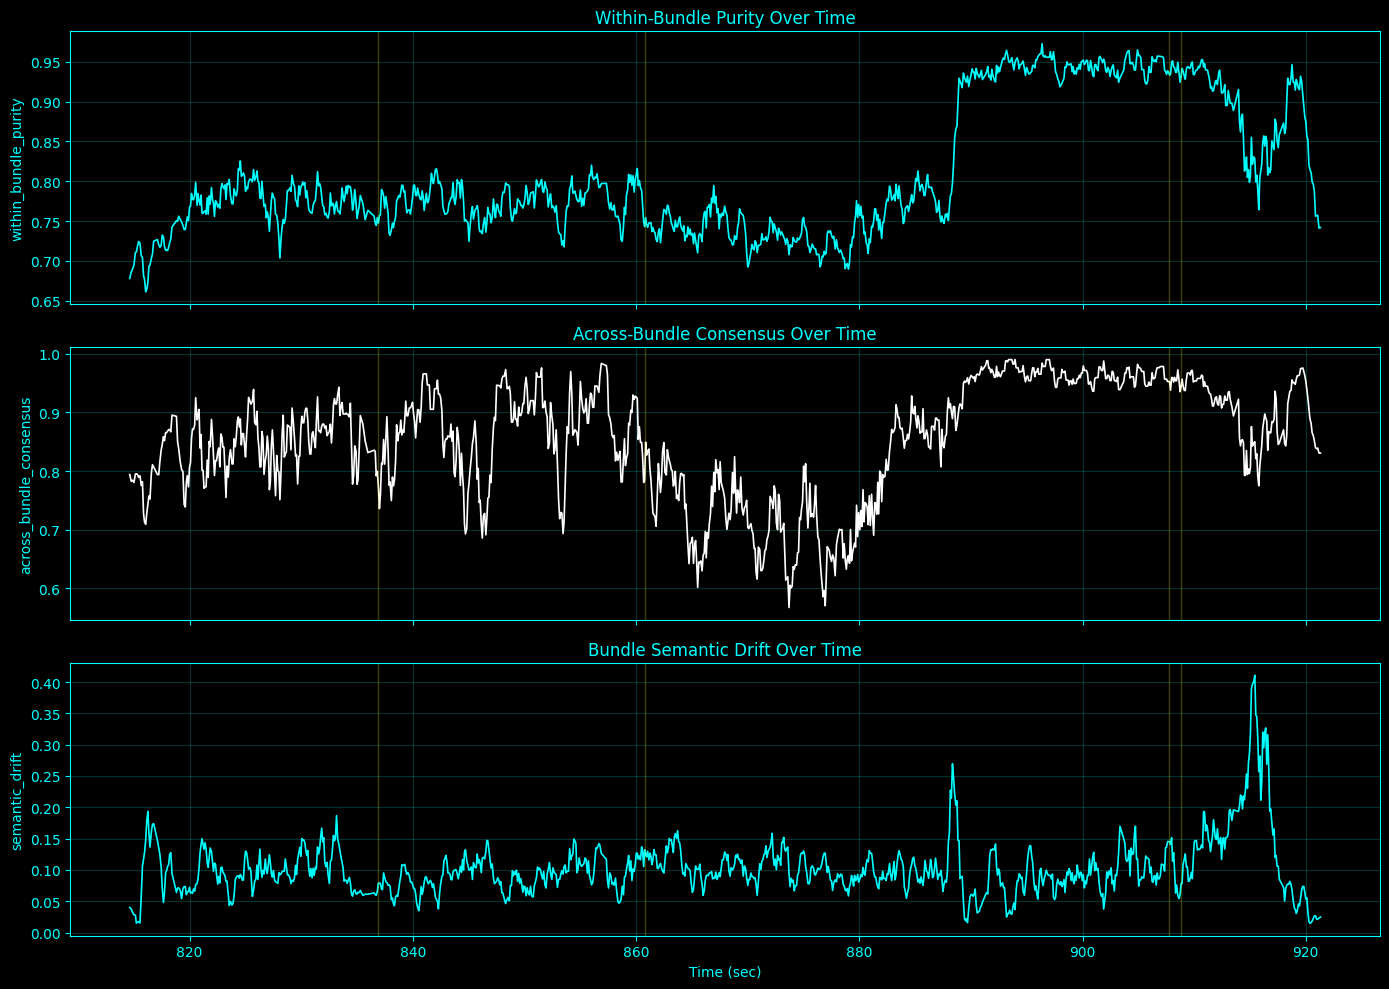

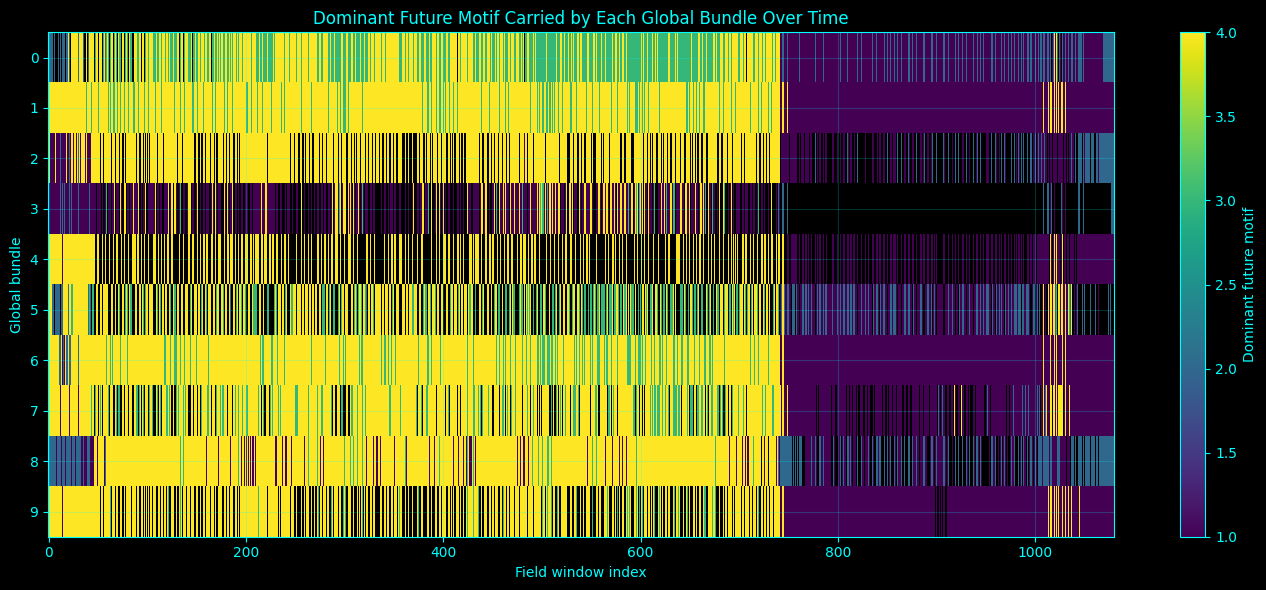

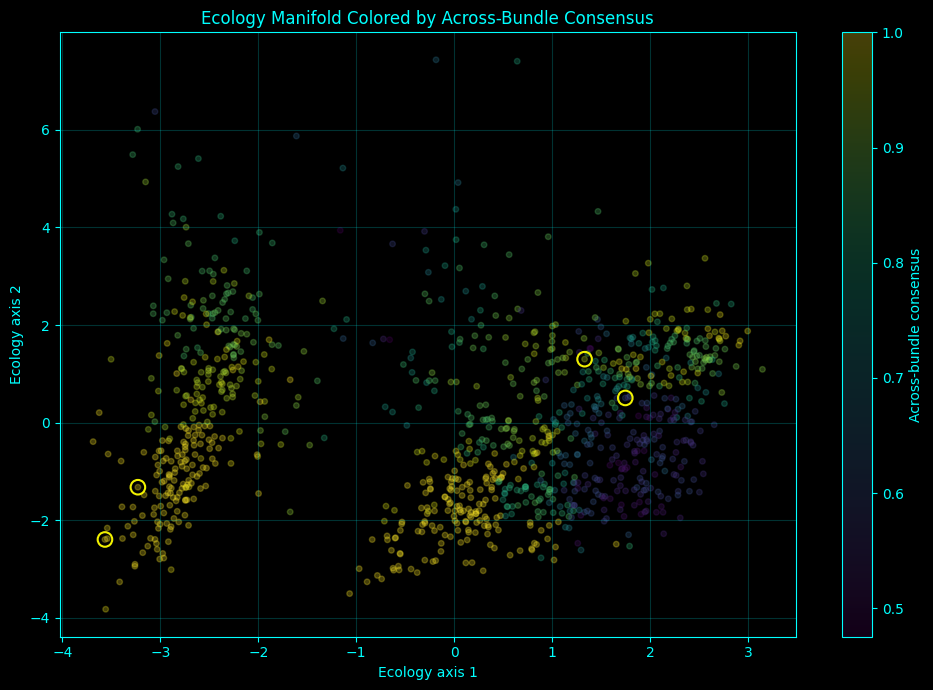

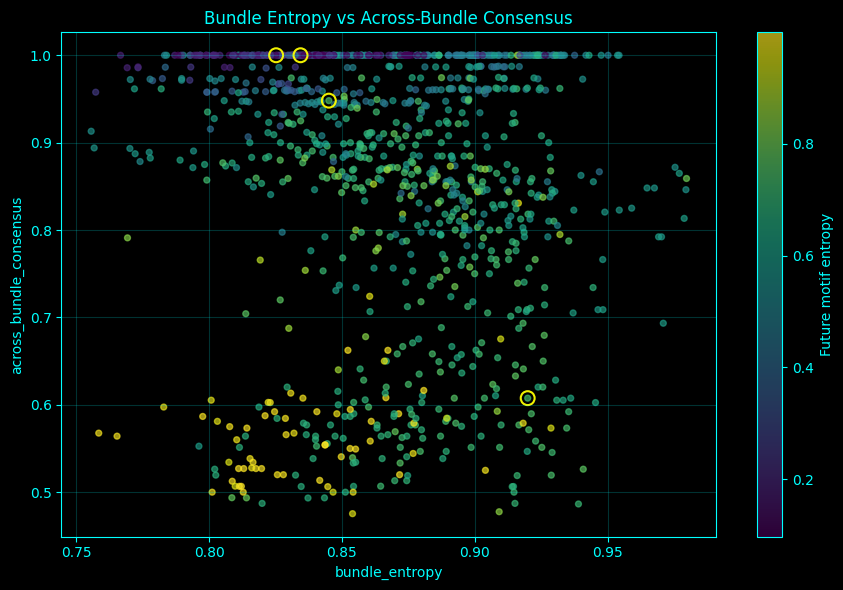

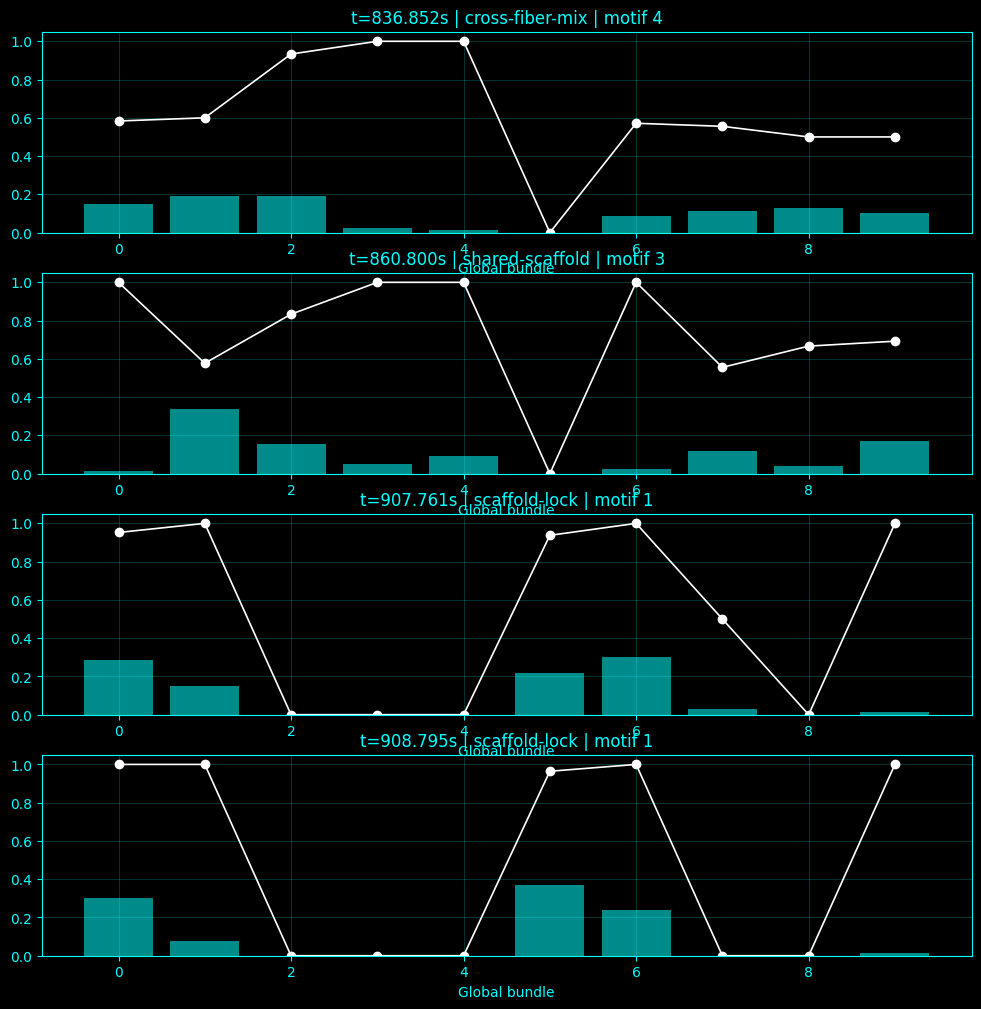

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

bundle_dir = os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1")
field_csv = os.path.join(bundle_dir, "motif_field_with_global_bundles.csv")
endpoint_csv = os.path.join(bundle_dir, "global_branch_bundle_endpoints.csv")
bundle_summary_csv = os.path.join(bundle_dir, "global_branch_bundle_summary.csv")
near_flat_csv = os.path.join(bundle_dir, "near_flat_global_bundle_context.csv")

out_dir = os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# smoothing / alignment
roll_w = 7
eps = 1e-12

ACCENT = "cyan"
BG = "black"

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def normalized_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    if len(p) == 0:
        return np.nan
    p = p / (np.sum(p) + eps)
    h = -np.sum(p * np.log(p + eps))
    return float(h / (np.log(len(p) + eps) + eps))

def js_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / (np.sum(p) + eps)
    q = q / (np.sum(q) + eps)
    m = 0.5 * (p + q)

    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log((a[mask] + eps) / (b[mask] + eps)))

    return float(0.5 * kl(p, m) + 0.5 * kl(q, m))

def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    s = pd.Series(x)
    return s.rolling(window=w, center=True, min_periods=1).mean().values

def classify_fiber_role(row, q):
    bundle_entropy = row["bundle_entropy"]
    future_motif_entropy = row["future_motif_entropy"]
    within_bundle_purity = row["within_bundle_purity"]
    across_bundle_consensus = row["across_bundle_consensus"]
    semantic_drift = row["bundle_semantic_drift"]
    active_bundle_count = row["active_bundle_count"]

    if across_bundle_consensus >= q["cons75"] and future_motif_entropy <= q["motif25"]:
        return "scaffold-lock"
    if semantic_drift >= q["drift75"] and across_bundle_consensus <= q["cons25"]:
        return "semantic-retuning"
    if within_bundle_purity >= q["purity75"] and across_bundle_consensus <= q["cons50"]:
        return "bundle-disagreement"
    if bundle_entropy >= q["bundle75"] and future_motif_entropy >= q["motif75"]:
        return "cross-fiber-mix"
    if active_bundle_count <= q["count25"] and across_bundle_consensus >= q["cons50"]:
        return "compact-routing"
    return "shared-scaffold"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)
endpoint_df = pd.read_csv(endpoint_csv)
bundle_summary_df = pd.read_csv(bundle_summary_csv).sort_values("global_bundle").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

n_bundles = int(bundle_summary_df["global_bundle"].max()) + 1
motifs = sorted(endpoint_df["future_motif"].unique().tolist())

# -------------------------------------------------------
# BUILD WINDOW x BUNDLE x MOTIF TENSOR
# -------------------------------------------------------
window_index_values = np.arange(len(field_df))
time_vals = field_df["center_time_sec"].values

bundle_count_mat = np.zeros((len(field_df), n_bundles), dtype=float)
bundle_motif_tensor = np.zeros((len(field_df), n_bundles, len(motifs)), dtype=float)

motif_to_idx = {m: i for i, m in enumerate(motifs)}

grp = endpoint_df.groupby(["window_index", "global_bundle", "future_motif"]).size().reset_index(name="count")

for _, row in grp.iterrows():
    wi = int(row["window_index"])
    b = int(row["global_bundle"])
    m = motif_to_idx[int(row["future_motif"])]
    c = float(row["count"])
    bundle_motif_tensor[wi, b, m] += c
    bundle_count_mat[wi, b] += c

# normalize per bundle to motif probabilities
bundle_prob_tensor = np.zeros_like(bundle_motif_tensor)
for wi in range(len(field_df)):
    for b in range(n_bundles):
        s = np.sum(bundle_motif_tensor[wi, b])
        if s > 0:
            bundle_prob_tensor[wi, b] = bundle_motif_tensor[wi, b] / s

# bundle fractions inside each window
bundle_fraction_mat = np.zeros_like(bundle_count_mat)
for wi in range(len(field_df)):
    s = np.sum(bundle_count_mat[wi])
    if s > 0:
        bundle_fraction_mat[wi] = bundle_count_mat[wi] / s

# -------------------------------------------------------
# PER-WINDOW FIBER METRICS
# -------------------------------------------------------
within_bundle_purity = np.full(len(field_df), np.nan)
across_bundle_consensus = np.full(len(field_df), np.nan)
bundle_semantic_drift = np.full(len(field_df), np.nan)
active_bundle_count = np.full(len(field_df), np.nan)

# dominant motif per bundle per window
bundle_dom_motif = np.full((len(field_df), n_bundles), np.nan)
bundle_purity = np.full((len(field_df), n_bundles), np.nan)
bundle_entropy_mat = np.full((len(field_df), n_bundles), np.nan)

for wi in range(len(field_df)):
    active = np.where(bundle_fraction_mat[wi] > 0)[0]
    active_bundle_count[wi] = len(active)

    if len(active) == 0:
        continue

    # per active bundle
    purity_vals = []
    dom_motifs = []
    dom_weights = []

    for b in active:
        p = bundle_prob_tensor[wi, b]
        bundle_entropy_mat[wi, b] = normalized_entropy(p)
        if np.sum(p) > 0:
            dom = int(motifs[np.argmax(p)])
            pur = float(np.max(p))
            bundle_dom_motif[wi, b] = dom
            bundle_purity[wi, b] = pur

            purity_vals.append(bundle_fraction_mat[wi, b] * pur)
            dom_motifs.append(dom)
            dom_weights.append(bundle_fraction_mat[wi, b])

    within_bundle_purity[wi] = np.sum(purity_vals)

    # across-bundle semantic consensus
    if len(dom_motifs) > 0:
        dom_motifs = np.asarray(dom_motifs, dtype=int)
        dom_weights = np.asarray(dom_weights, dtype=float)

        motif_weight_sum = {}
        for m, w in zip(dom_motifs, dom_weights):
            motif_weight_sum[m] = motif_weight_sum.get(m, 0.0) + w

        across_bundle_consensus[wi] = max(motif_weight_sum.values())

# bundle semantic drift: how much bundle meanings change from previous window
for wi in range(1, len(field_df)):
    js_vals = []
    active_now = np.where(bundle_fraction_mat[wi] > 0)[0]
    active_prev = np.where(bundle_fraction_mat[wi - 1] > 0)[0]
    common = np.intersect1d(active_now, active_prev)

    for b in common:
        p_prev = bundle_prob_tensor[wi - 1, b]
        p_now = bundle_prob_tensor[wi, b]
        if np.sum(p_prev) > 0 and np.sum(p_now) > 0:
            js_vals.append(js_divergence(p_prev, p_now))

    bundle_semantic_drift[wi] = safe_mean(js_vals)

field_df["within_bundle_purity"] = within_bundle_purity
field_df["across_bundle_consensus"] = across_bundle_consensus
field_df["bundle_semantic_drift"] = bundle_semantic_drift
field_df["active_bundle_count"] = active_bundle_count

# smoothed versions for plotting
field_df["within_bundle_purity_smooth"] = rolling_mean(field_df["within_bundle_purity"].values, roll_w)
field_df["across_bundle_consensus_smooth"] = rolling_mean(field_df["across_bundle_consensus"].values, roll_w)
field_df["bundle_semantic_drift_smooth"] = rolling_mean(field_df["bundle_semantic_drift"].values, roll_w)

# -------------------------------------------------------
# CLASSIFY FIBER ROLES
# -------------------------------------------------------
valid = field_df[
    np.isfinite(field_df["within_bundle_purity"]) &
    np.isfinite(field_df["across_bundle_consensus"])
].copy()

q = {
    "purity75": np.quantile(valid["within_bundle_purity"], 0.75),
    "cons25": np.quantile(valid["across_bundle_consensus"], 0.25),
    "cons50": np.quantile(valid["across_bundle_consensus"], 0.50),
    "cons75": np.quantile(valid["across_bundle_consensus"], 0.75),
    "drift75": np.quantile(valid["bundle_semantic_drift"].dropna(), 0.75),
    "bundle75": np.quantile(valid["bundle_entropy"], 0.75),
    "motif25": np.quantile(valid["future_motif_entropy"], 0.25),
    "motif75": np.quantile(valid["future_motif_entropy"], 0.75),
    "count25": np.quantile(valid["active_bundle_count"], 0.25),
}

field_df["fiber_role"] = field_df.apply(
    lambda r: classify_fiber_role(r, q) if (
        np.isfinite(r["within_bundle_purity"]) and
        np.isfinite(r["across_bundle_consensus"])
    ) else "undefined",
    axis=1
)

# -------------------------------------------------------
# BUNDLE DOMINANT-MOTIF HEATMAP TABLE
# -------------------------------------------------------
bundle_dom_df = pd.DataFrame({
    "center_time_sec": time_vals
})
for b in range(n_bundles):
    bundle_dom_df[f"bundle_{b}_dom_motif"] = bundle_dom_motif[:, b]
    bundle_dom_df[f"bundle_{b}_purity"] = bundle_purity[:, b]
    bundle_dom_df[f"bundle_{b}_entropy"] = bundle_entropy_mat[:, b]

# -------------------------------------------------------
# NEAR-FLAT FIBER CONTEXT
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        wi = int(np.argmin(np.abs(field_df["center_time_sec"].values - t0)))

        out = {
            "time_sec": t0,
            "nearest_field_time_sec": float(field_df.loc[wi, "center_time_sec"]),
            "dominant_motif": int(field_df.loc[wi, "dominant_motif"]),
            "bundle_role": row.get("bundle_role", "NA"),
            "fiber_role": field_df.loc[wi, "fiber_role"],
            "active_bundle_count": int(field_df.loc[wi, "active_bundle_count"]),
            "bundle_entropy": float(field_df.loc[wi, "bundle_entropy"]),
            "future_motif_entropy": float(field_df.loc[wi, "future_motif_entropy"]),
            "within_bundle_purity": float(field_df.loc[wi, "within_bundle_purity"]),
            "across_bundle_consensus": float(field_df.loc[wi, "across_bundle_consensus"]),
            "bundle_semantic_drift": float(field_df.loc[wi, "bundle_semantic_drift"]),
            "eco_x": float(field_df.loc[wi, "eco_x"]),
            "eco_y": float(field_df.loc[wi, "eco_y"]),
        }

        for b in range(n_bundles):
            out[f"bundle_{b}_fraction"] = float(bundle_fraction_mat[wi, b])
            out[f"bundle_{b}_dom_motif"] = (
                int(bundle_dom_motif[wi, b]) if np.isfinite(bundle_dom_motif[wi, b]) else np.nan
            )
            out[f"bundle_{b}_purity"] = float(bundle_purity[wi, b]) if np.isfinite(bundle_purity[wi, b]) else np.nan

        near_flat_rows.append(out)

near_flat_fiber_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_out_csv = os.path.join(out_dir, "motif_field_with_bundle_semantic_fibers.csv")
bundle_dom_csv = os.path.join(out_dir, "bundle_dominant_motif_over_time.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_bundle_fiber_context.csv")
summary_txt = os.path.join(out_dir, "bundle_semantic_drift_summary.txt")

field_df.to_csv(field_out_csv, index=False)
bundle_dom_df.to_csv(bundle_dom_csv, index=False)
near_flat_fiber_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Bundle-Semantic Drift Atlas Summary\n")
    f.write("==================================\n\n")
    f.write("Fiber-role counts:\n")
    f.write(field_df["fiber_role"].value_counts().to_string())
    f.write("\n\n")

    f.write("Global bundle summary:\n")
    f.write(bundle_summary_df.to_string(index=False))
    f.write("\n\n")

    f.write("Near-flat fiber context:\n")
    if len(near_flat_fiber_df) > 0:
        f.write(near_flat_fiber_df.to_string(index=False))
    else:
        f.write("None")
    f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Across-bundle consensus and semantic drift over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor=BG, sharex=True)
ax1, ax2, ax3 = axes
style_ax(ax1); style_ax(ax2); style_ax(ax3)

ax1.plot(
    field_df["center_time_sec"].values,
    field_df["within_bundle_purity_smooth"].values,
    color=ACCENT,
    linewidth=1.2
)
ax1.set_title("Within-Bundle Purity Over Time")
ax1.set_ylabel("within_bundle_purity")

ax2.plot(
    field_df["center_time_sec"].values,
    field_df["across_bundle_consensus_smooth"].values,
    color="white",
    linewidth=1.2
)
ax2.set_title("Across-Bundle Consensus Over Time")
ax2.set_ylabel("across_bundle_consensus")

ax3.plot(
    field_df["center_time_sec"].values,
    field_df["bundle_semantic_drift_smooth"].values,
    color=ACCENT,
    linewidth=1.2
)
ax3.set_title("Bundle Semantic Drift Over Time")
ax3.set_xlabel("Time (sec)")
ax3.set_ylabel("semantic_drift")

if len(near_flat_fiber_df) > 0:
    for t0 in near_flat_fiber_df["time_sec"].values:
        ax1.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax2.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax3.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)

plot1_path = os.path.join(plots_dir, "fiber_consensus_drift_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Heatmap: dominant future motif carried by each bundle over time
dom_matrix = np.full((n_bundles, len(field_df)), np.nan)
for b in range(n_bundles):
    dom_matrix[b] = bundle_dom_motif[:, b]

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(dom_matrix, aspect="auto", interpolation="nearest")
ax.set_title("Dominant Future Motif Carried by Each Global Bundle Over Time")
ax.set_xlabel("Field window index")
ax.set_ylabel("Global bundle")
ax.set_yticks(np.arange(n_bundles))
ax.set_yticklabels(np.arange(n_bundles))

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Dominant future motif")

plot2_path = os.path.join(plots_dir, "bundle_dominant_motif_heatmap.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Ecology manifold colored by across-bundle consensus
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["eco_x"].values,
    field_df["eco_y"].values,
    c=field_df["across_bundle_consensus"].values,
    s=16,
    alpha=0.28
)

if len(near_flat_fiber_df) > 0:
    ax.scatter(
        near_flat_fiber_df["eco_x"].values,
        near_flat_fiber_df["eco_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Ecology Manifold Colored by Across-Bundle Consensus")
ax.set_xlabel("Ecology axis 1")
ax.set_ylabel("Ecology axis 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Across-bundle consensus")

plot3_path = os.path.join(plots_dir, "ecology_manifold_bundle_consensus.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Bundle entropy vs across-bundle consensus
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["bundle_entropy"].values,
    field_df["across_bundle_consensus"].values,
    c=field_df["future_motif_entropy"].values,
    s=18,
    alpha=0.65
)

if len(near_flat_fiber_df) > 0:
    ax.scatter(
        near_flat_fiber_df["bundle_entropy"].values,
        near_flat_fiber_df["across_bundle_consensus"].values,
        s=100,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Bundle Entropy vs Across-Bundle Consensus")
ax.set_xlabel("bundle_entropy")
ax.set_ylabel("across_bundle_consensus")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Future motif entropy")

plot4_path = os.path.join(plots_dir, "bundle_entropy_vs_consensus.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Near-flat per-bundle dominant motif/purity profile
if len(near_flat_fiber_df) > 0:
    fig, axes = plt.subplots(len(near_flat_fiber_df), 1, figsize=(12, 3 * len(near_flat_fiber_df)), facecolor=BG)
    if len(near_flat_fiber_df) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, near_flat_fiber_df.iterrows()):
        style_ax(ax)

        bundle_fracs = np.array([row[f"bundle_{b}_fraction"] for b in range(n_bundles)], dtype=float)
        purity_vals = np.array([
            row[f"bundle_{b}_purity"] if pd.notna(row[f"bundle_{b}_purity"]) else 0.0
            for b in range(n_bundles)
        ], dtype=float)

        ax.bar(np.arange(n_bundles), bundle_fracs, color=ACCENT, alpha=0.55, label="Bundle fraction")
        ax.plot(np.arange(n_bundles), purity_vals, color="white", marker="o", linewidth=1.2, label="Bundle purity")

        ax.set_title(
            f"t={row['time_sec']:.3f}s | {row['fiber_role']} | motif {int(row['dominant_motif'])}"
        )
        ax.set_xlabel("Global bundle")
        ax.set

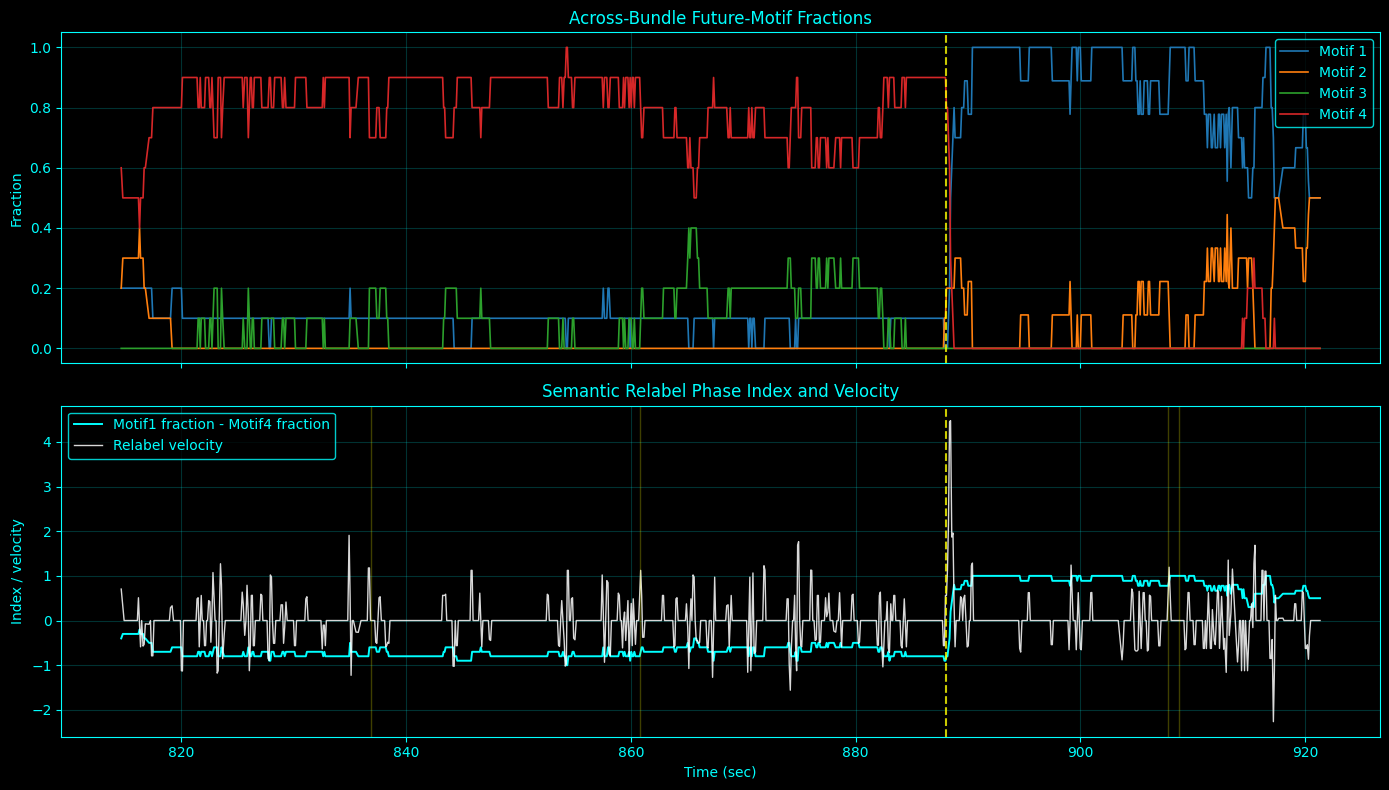

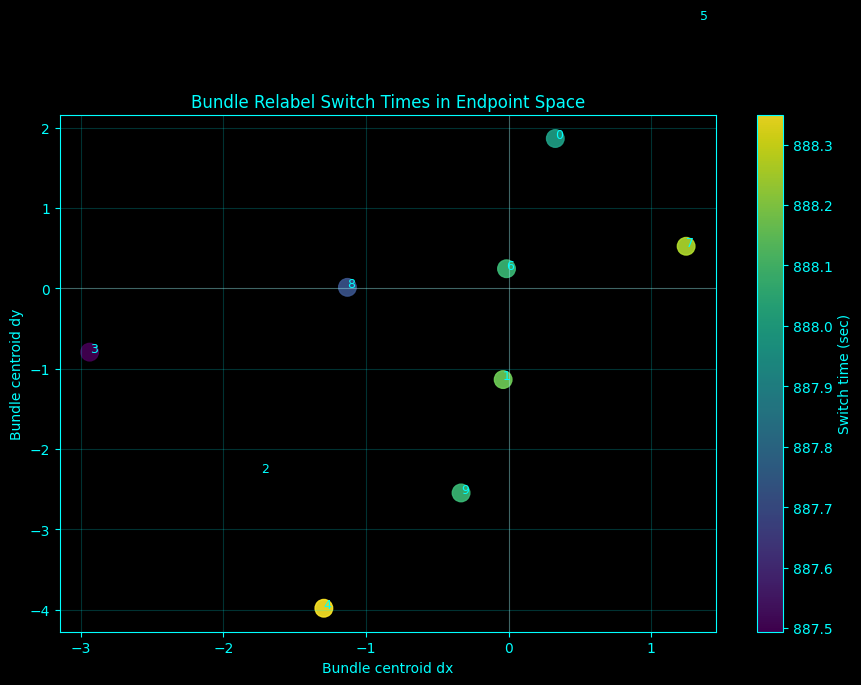

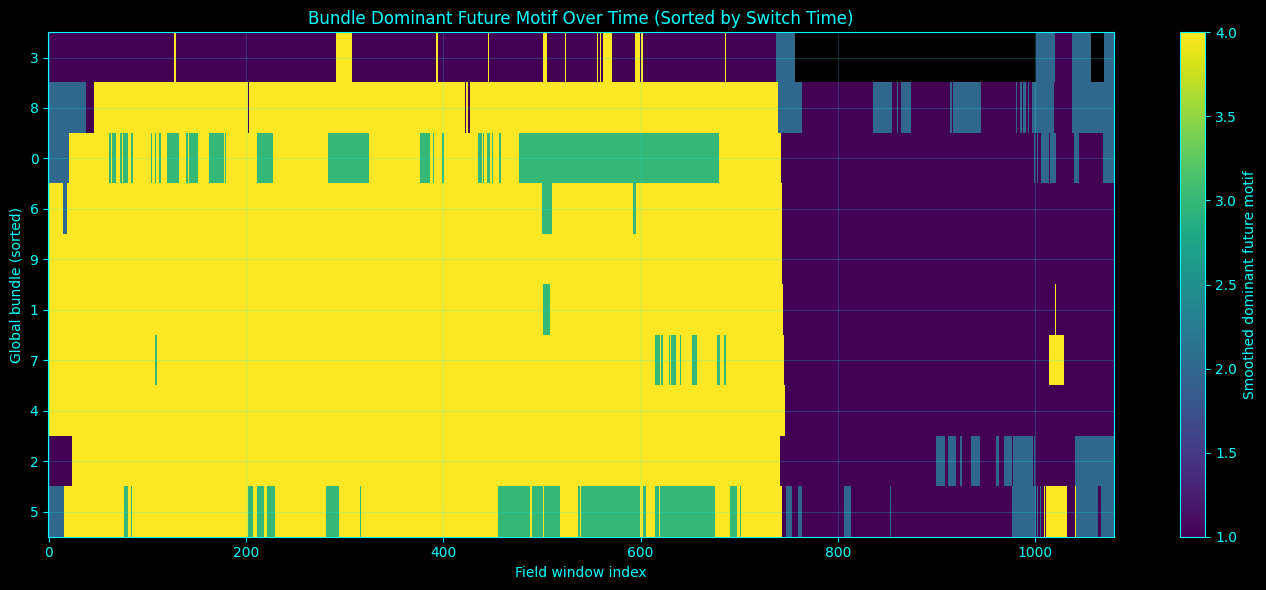

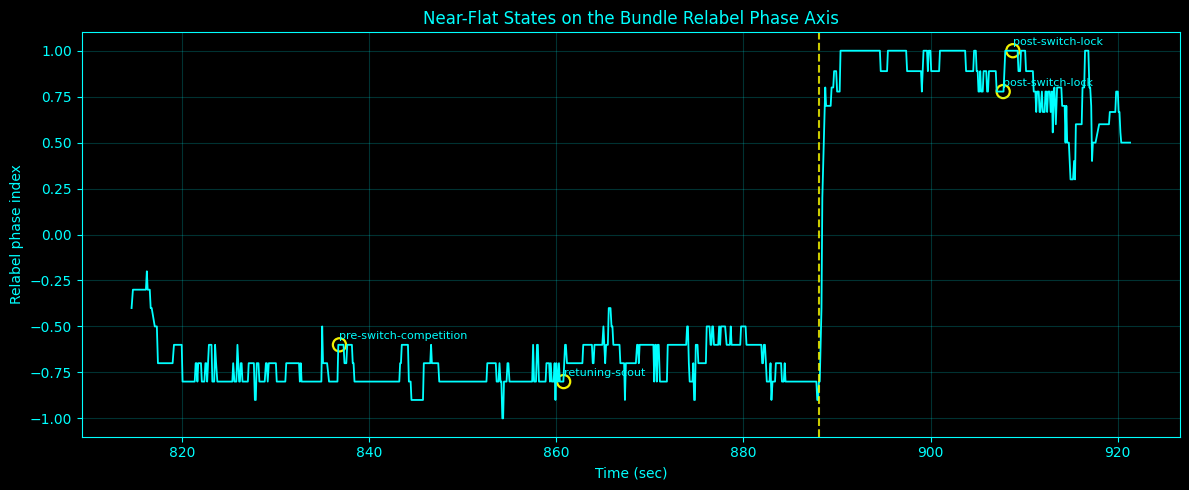

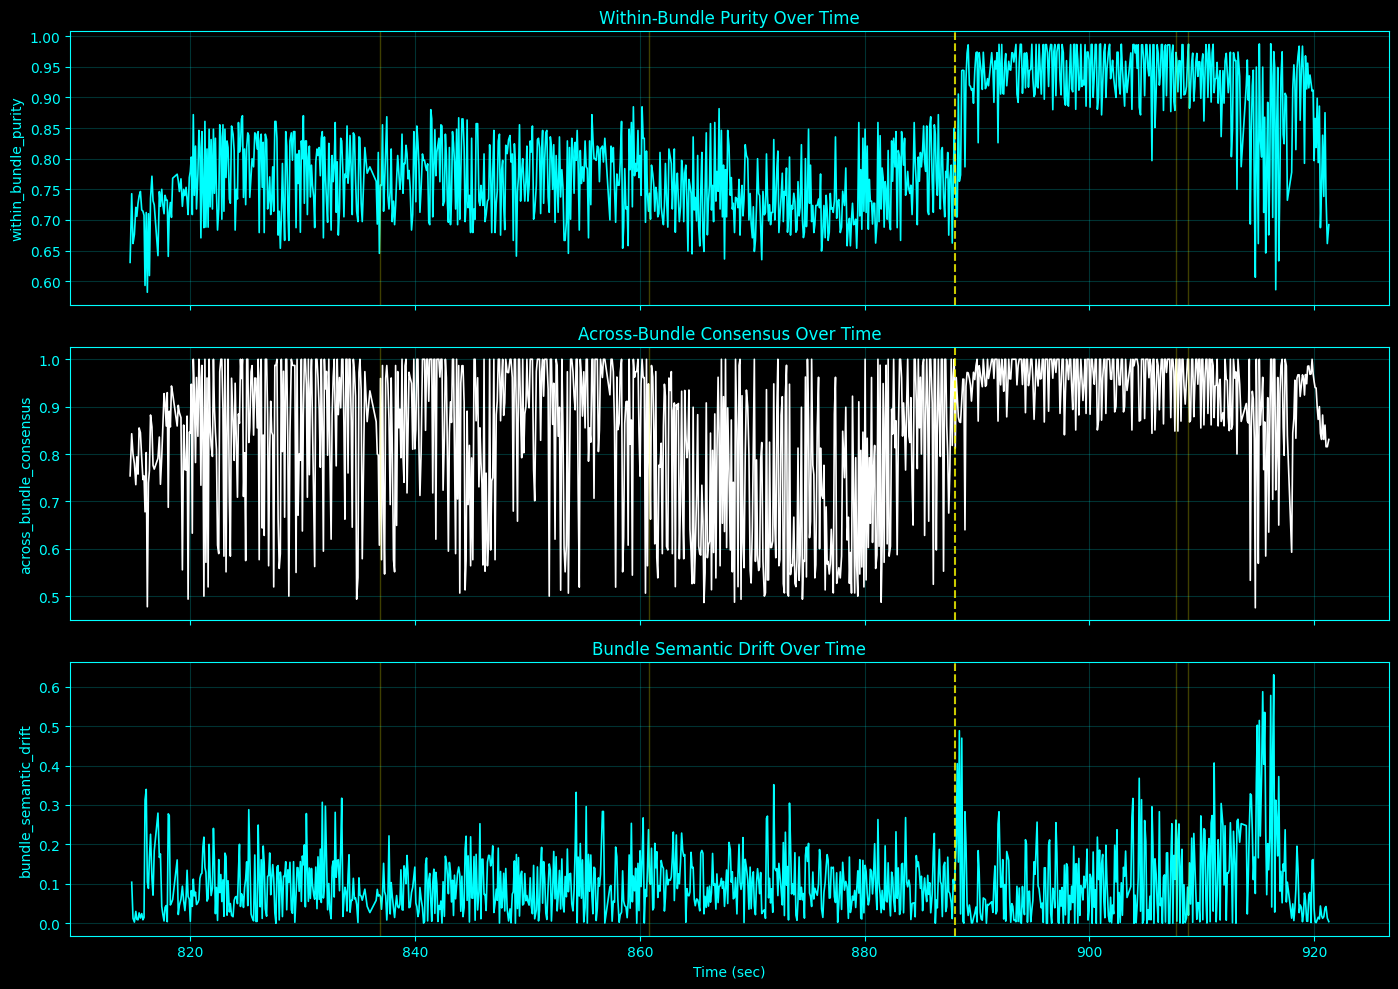


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_relabel_wave_atlas_v1/bundle_relabel_phase_index.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_relabel_wave_atlas_v1/bundle_switch_times.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_relabel_wave_atlas_v1/near_flat_relabel_stage_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_relabel_wave_atlas_v1/bundle_relabel_wave_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_relabel_wave_atlas_v1/plots

Bundle switch table:
 global_bundle  early_motif  late_motif  changed_label  switch_time_sec  switch_index  pre_purity  post_purity  centroid_dx  centroid_dy  global_motif_purity  global_motif_entropy
             0            4           1              1          887.984         739.0         NaN          NaN     0.327697     1.863675             0.353201              0.894321
             1            4           1            

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

drift_dir = os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1")
bundle_dir = os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1")

field_csv = os.path.join(drift_dir, "motif_field_with_bundle_semantic_fibers.csv")
bundle_summary_csv = os.path.join(bundle_dir, "global_branch_bundle_summary.csv")
near_flat_csv = os.path.join(drift_dir, "near_flat_bundle_fiber_context.csv")

# optional fallback
bundle_motif_time_csv = os.path.join(drift_dir, "bundle_dominant_motif_over_time.csv")

out_dir = os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# rolling / switch detection
smooth_window = 15          # odd integer recommended
stability_window = 18       # how long the new label should persist
phase_quantile = 0.20       # first/last 20% for early/late motif definition
near_flat_front_window_sec = 1.0

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def rolling_mode_int(x, window):
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan)

    half = window // 2
    for i in range(len(x)):
        a = max(0, i - half)
        b = min(len(x), i + half + 1)
        vals = x[a:b]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        vals = vals.astype(int)
        uniq, counts = np.unique(vals, return_counts=True)
        out[i] = uniq[np.argmax(counts)]
    return out

def discover_bundle_cols(df, suffix):
    pat = re.compile(rf"^bundle_(\d+)_{suffix}$")
    out = {}
    for c in df.columns:
        m = pat.match(c)
        if m:
            out[int(m.group(1))] = c
    return dict(sorted(out.items()))

def first_stable_switch_time(times, labels, from_label, to_label, dwell=18):
    """
    Earliest time where labels switch from from_label to to_label
    and remain mostly in to_label for the next dwell windows.
    """
    labels = np.asarray(labels, dtype=float)
    n = len(labels)

    if from_label == to_label or n < dwell + 2:
        return np.nan, np.nan

    for i in range(1, n - dwell):
        prev_ok = np.nanmean(labels[max(0, i - dwell):i] == from_label)
        next_ok = np.nanmean(labels[i:i + dwell] == to_label)

        if prev_ok >= 0.60 and next_ok >= 0.75:
            return float(times[i]), int(i)

    return np.nan, np.nan

def classify_near_flat_stage(row, global_phase_idx, switch_center_time, front_window_sec=1.0):
    t = row["time_sec"]
    phase_val = row["relabel_phase_index"]
    drift = row["bundle_semantic_drift"]
    consensus = row["across_bundle_consensus"]

    if np.isfinite(switch_center_time) and abs(t - switch_center_time) <= front_window_sec:
        return "switch-front"

    if phase_val < -0.25 and consensus < 0.85:
        return "pre-switch-competition"

    if phase_val < -0.25 and consensus >= 0.85:
        return "retuning-scout"

    if phase_val > 0.25 and consensus >= 0.95 and drift < 0.05:
        return "post-switch-lock"

    if phase_val > 0.25 and drift >= 0.05:
        return "late-redisturbance"

    return "transitional"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)
bundle_summary_df = pd.read_csv(bundle_summary_csv).sort_values("global_bundle").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

if "center_time_sec" not in field_df.columns:
    raise ValueError("field_df must contain center_time_sec")

time_sec = field_df["center_time_sec"].values
n_windows = len(field_df)

# -------------------------------------------------------
# DISCOVER BUNDLE DOM-MOTIF / PURITY COLUMNS
# -------------------------------------------------------
dom_cols = discover_bundle_cols(field_df, "dom_motif")
purity_cols = discover_bundle_cols(field_df, "purity")

# fallback: if dom motif columns are missing, try external matrix
if len(dom_cols) == 0 and os.path.exists(bundle_motif_time_csv):
    tmp = pd.read_csv(bundle_motif_time_csv)

    if "center_time_sec" not in tmp.columns and "time_sec" in tmp.columns:
        tmp = tmp.rename(columns={"time_sec": "center_time_sec"})

    tmp = tmp.sort_values("center_time_sec").reset_index(drop=True)
    dom_cols = discover_bundle_cols(tmp, "dom_motif")
    if len(dom_cols) == 0:
        # looser fallback: columns like bundle_0, bundle_1, ...
        loose = {}
        pat = re.compile(r"^bundle_(\d+)$")
        for c in tmp.columns:
            m = pat.match(c)
            if m:
                loose[int(m.group(1))] = c
        dom_cols = dict(sorted(loose.items()))

    merge_cols = ["center_time_sec"] + list(dom_cols.values())
    field_df = field_df.merge(tmp[merge_cols], on="center_time_sec", how="left", suffixes=("", "_tmp"))
    dom_cols = discover_bundle_cols(field_df, "dom_motif")
    if len(dom_cols) == 0:
        # handle loose naming after merge
        dom_cols = {}
        pat = re.compile(r"^bundle_(\d+)$")
        for c in field_df.columns:
            m = pat.match(c)
            if m:
                dom_cols[int(m.group(1))] = c
        dom_cols = dict(sorted(dom_cols.items()))

if len(dom_cols) == 0:
    raise ValueError("Could not find bundle dominant-motif columns in drift outputs.")

bundle_ids = sorted(dom_cols.keys())

# purity columns may or may not exist for every bundle
bundle_purity_available = len(purity_cols) > 0

# -------------------------------------------------------
# BUILD BUNDLE DOMINANT-MOTIF MATRIX
# -------------------------------------------------------
dom_matrix = pd.DataFrame(index=np.arange(n_windows))
dom_matrix["center_time_sec"] = field_df["center_time_sec"].values

for b in bundle_ids:
    col = dom_cols[b]
    dom_matrix[f"bundle_{b}"] = field_df[col].values

# smooth each bundle's motif timeline
smooth_df = pd.DataFrame(index=dom_matrix.index)
smooth_df["center_time_sec"] = dom_matrix["center_time_sec"].values

for b in bundle_ids:
    x = dom_matrix[f"bundle_{b}"].values
    smooth_df[f"bundle_{b}"] = rolling_mode_int(x, smooth_window)

# -------------------------------------------------------
# PER-BUNDLE RELABEL METRICS
# -------------------------------------------------------
phase_n = max(10, int(np.floor(phase_quantile * n_windows)))
bundle_rows = []

for b in bundle_ids:
    raw = dom_matrix[f"bundle_{b}"].values
    sm = smooth_df[f"bundle_{b}"].values

    early = raw[:phase_n]
    late = raw[-phase_n:]

    early = early[np.isfinite(early)].astype(int)
    late = late[np.isfinite(late)].astype(int)

    if len(early) == 0 or len(late) == 0:
        early_motif = np.nan
        late_motif = np.nan
    else:
        early_motif = int(pd.Series(early).mode().iloc[0])
        late_motif = int(pd.Series(late).mode().iloc[0])

    switch_time, switch_idx = first_stable_switch_time(
        time_sec,
        sm,
        early_motif,
        late_motif,
        dwell=stability_window,
    )

    if bundle_purity_available and b in purity_cols:
        purity_series = field_df[purity_cols[b]].values.astype(float)
        pre_purity = safe_mean(purity_series[:phase_n])
        post_purity = safe_mean(purity_series[-phase_n:])
    else:
        pre_purity = np.nan
        post_purity = np.nan

    changed = int(np.isfinite(switch_time) and early_motif != late_motif)

    bundle_rows.append({
        "global_bundle": int(b),
        "early_motif": early_motif,
        "late_motif": late_motif,
        "changed_label": changed,
        "switch_time_sec": switch_time,
        "switch_index": switch_idx,
        "pre_purity": pre_purity,
        "post_purity": post_purity,
        "centroid_dx": float(bundle_summary_df.loc[bundle_summary_df["global_bundle"] == b, "centroid_dx"].iloc[0]),
        "centroid_dy": float(bundle_summary_df.loc[bundle_summary_df["global_bundle"] == b, "centroid_dy"].iloc[0]),
        "global_motif_purity": float(bundle_summary_df.loc[bundle_summary_df["global_bundle"] == b, "motif_purity"].iloc[0]),
        "global_motif_entropy": float(bundle_summary_df.loc[bundle_summary_df["global_bundle"] == b, "motif_entropy"].iloc[0]),
    })

bundle_switch_df = pd.DataFrame(bundle_rows).sort_values("global_bundle").reset_index(drop=True)

# -------------------------------------------------------
# GLOBAL RELABEL PHASE INDEX
# -------------------------------------------------------
phase_rows = []

for i in range(n_windows):
    vals = []
    for b in bundle_ids:
        v = smooth_df.loc[i, f"bundle_{b}"]
        if np.isfinite(v):
            vals.append(int(v))

    if len(vals) == 0:
        phase_rows.append({
            "center_time_sec": time_sec[i],
            "motif_1_fraction": np.nan,
            "motif_2_fraction": np.nan,
            "motif_3_fraction": np.nan,
            "motif_4_fraction": np.nan,
            "relabel_phase_index": np.nan,
        })
        continue

    vals = np.asarray(vals, dtype=int)
    frac = {m: np.mean(vals == m) for m in [1, 2, 3, 4]}

    # phase index: late motif-1 occupancy minus motif-4 occupancy
    phase_rows.append({
        "center_time_sec": time_sec[i],
        "motif_1_fraction": float(frac[1]),
        "motif_2_fraction": float(frac[2]),
        "motif_3_fraction": float(frac[3]),
        "motif_4_fraction": float(frac[4]),
        "relabel_phase_index": float(frac[1] - frac[4]),
    })

phase_df = pd.DataFrame(phase_rows)
phase_df["relabel_velocity"] = np.gradient(phase_df["relabel_phase_index"].values, phase_df["center_time_sec"].values)

# bundle switch center
switch_times = bundle_switch_df["switch_time_sec"].values
switch_times = switch_times[np.isfinite(switch_times)]
switch_center_time = float(np.median(switch_times)) if len(switch_times) else np.nan

# -------------------------------------------------------
# WAVEFRONT DIRECTION IN ENDPOINT SPACE
# Fit switch_time ~ a * centroid_dx + b * centroid_dy + c
# -------------------------------------------------------
switch_fit_df = bundle_switch_df[np.isfinite(bundle_switch_df["switch_time_sec"])].copy()

if len(switch_fit_df) >= 3:
    A = np.column_stack([
        switch_fit_df["centroid_dx"].values,
        switch_fit_df["centroid_dy"].values,
        np.ones(len(switch_fit_df))
    ])
    y = switch_fit_df["switch_time_sec"].values
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    wave_a, wave_b, wave_c = coef
else:
    wave_a, wave_b, wave_c = np.nan, np.nan, np.nan

# -------------------------------------------------------
# NEAR-FLAT RELABEL STAGES
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(phase_df["center_time_sec"].values - t0)))
        ph = phase_df.iloc[idx]

        stage = classify_near_flat_stage(
            {
                "time_sec": t0,
                "relabel_phase_index": ph["relabel_phase_index"],
                "bundle_semantic_drift": row["bundle_semantic_drift"],
                "across_bundle_consensus": row["across_bundle_consensus"],
            },
            global_phase_idx=phase_df["relabel_phase_index"].values,
            switch_center_time=switch_center_time,
            front_window_sec=near_flat_front_window_sec
        )

        near_flat_rows.append({
            "time_sec": t0,
            "nearest_phase_time_sec": float(ph["center_time_sec"]),
            "dominant_motif": int(row["dominant_motif"]),
            "bundle_role": row["bundle_role"],
            "fiber_role": row["fiber_role"],
            "relabel_phase_index": float(ph["relabel_phase_index"]),
            "relabel_velocity": float(ph["relabel_velocity"]),
            "within_bundle_purity": float(row["within_bundle_purity"]),
            "across_bundle_consensus": float(row["across_bundle_consensus"]),
            "bundle_semantic_drift": float(row["bundle_semantic_drift"]),
            "stage_label": stage,
            "eco_x": float(row["eco_x"]),
            "eco_y": float(row["eco_y"]),
        })

near_flat_stage_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
phase_csv = os.path.join(out_dir, "bundle_relabel_phase_index.csv")
bundle_switch_csv = os.path.join(out_dir, "bundle_switch_times.csv")
near_flat_stage_csv = os.path.join(out_dir, "near_flat_relabel_stage_context.csv")
summary_txt = os.path.join(out_dir, "bundle_relabel_wave_summary.txt")

phase_df.to_csv(phase_csv, index=False)
bundle_switch_df.to_csv(bundle_switch_csv, index=False)
near_flat_stage_df.to_csv(near_flat_stage_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Bundle Relabeling Wave Atlas Summary\n")
    f.write("===================================\n\n")
    f.write(f"smooth_window = {smooth_window}\n")
    f.write(f"stability_window = {stability_window}\n")
    f.write(f"phase_quantile = {phase_quantile}\n")
    f.write(f"bundle_count = {len(bundle_ids)}\n\n")

    f.write("Bundle switch table:\n")
    f.write(bundle_switch_df.to_string(index=False))
    f.write("\n\n")

    f.write("Global relabel center time:\n")
    f.write(f"  switch_center_time = {switch_center_time}\n\n")

    f.write("Wavefront fit in endpoint space:\n")
    f.write(f"  switch_time ≈ {wave_a:.6f} * centroid_dx + {wave_b:.6f} * centroid_dy + {wave_c:.6f}\n\n")

    if len(near_flat_stage_df) > 0:
        f.write("Near-flat stage context:\n")
        f.write(near_flat_stage_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Motif fractions + relabel phase index
fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

for m, lab in zip([1, 2, 3, 4], ["Motif 1", "Motif 2", "Motif 3", "Motif 4"]):
    ax1.plot(
        phase_df["center_time_sec"].values,
        phase_df[f"motif_{m}_fraction"].values,
        linewidth=1.2,
        label=lab
    )

if np.isfinite(switch_center_time):
    ax1.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)

ax1.set_title("Across-Bundle Future-Motif Fractions")
ax1.set_ylabel("Fraction")
ax1.legend()

ax2.plot(
    phase_df["center_time_sec"].values,
    phase_df["relabel_phase_index"].values,
    color=ACCENT,
    linewidth=1.4,
    label="Motif1 fraction - Motif4 fraction"
)
ax2.plot(
    phase_df["center_time_sec"].values,
    phase_df["relabel_velocity"].values,
    color="white",
    linewidth=1.0,
    alpha=0.85,
    label="Relabel velocity"
)

if np.isfinite(switch_center_time):
    ax2.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)

if len(near_flat_stage_df) > 0:
    for t0 in near_flat_stage_df["time_sec"].values:
        ax2.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)

ax2.set_title("Semantic Relabel Phase Index and Velocity")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Index / velocity")
ax2.legend()

plot1_path = os.path.join(plots_dir, "bundle_relabel_phase_index.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Bundle switch times in endpoint space
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

valid_sw = bundle_switch_df[np.isfinite(bundle_switch_df["switch_time_sec"])].copy()

sc = ax.scatter(
    bundle_switch_df["centroid_dx"].values,
    bundle_switch_df["centroid_dy"].values,
    c=bundle_switch_df["switch_time_sec"].values,
    s=160,
    alpha=0.9
)

for _, row in bundle_switch_df.iterrows():
    ax.text(row["centroid_dx"], row["centroid_dy"], str(int(row["global_bundle"])), fontsize=9)

ax.axhline(0.0, color="white", alpha=0.25, linewidth=0.8)
ax.axvline(0.0, color="white", alpha=0.25, linewidth=0.8)
ax.set_title("Bundle Relabel Switch Times in Endpoint Space")
ax.set_xlabel("Bundle centroid dx")
ax.set_ylabel("Bundle centroid dy")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Switch time (sec)")

plot2_path = os.path.join(plots_dir, "bundle_switch_times_endpoint_space.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Heatmap sorted by switch time
sort_df = bundle_switch_df.copy()
sort_df["sort_key"] = sort_df["switch_time_sec"].fillna(np.inf)
sort_df = sort_df.sort_values(["sort_key", "global_bundle"]).reset_index(drop=True)

heat = []
yticks = []
for _, row in sort_df.iterrows():
    b = int(row["global_bundle"])
    heat.append(smooth_df[f"bundle_{b}"].values)
    yticks.append(str(b))

heat = np.array(heat, dtype=float)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest"
)
ax.set_title("Bundle Dominant Future Motif Over Time (Sorted by Switch Time)")
ax.set_xlabel("Field window index")
ax.set_ylabel("Global bundle (sorted)")

ax.set_yticks(np.arange(len(yticks)))
ax.set_yticklabels(yticks)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Smoothed dominant future motif")

plot3_path = os.path.join(plots_dir, "bundle_switch_heatmap_sorted.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Near-flat stage context on phase plot
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    phase_df["center_time_sec"].values,
    phase_df["relabel_phase_index"].values,
    color=ACCENT,
    linewidth=1.3
)

if len(near_flat_stage_df) > 0:
    ax.scatter(
        near_flat_stage_df["time_sec"].values,
        near_flat_stage_df["relabel_phase_index"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95
    )
    for _, row in near_flat_stage_df.iterrows():
        ax.text(
            row["time_sec"],
            row["relabel_phase_index"] + 0.03,
            row["stage_label"],
            fontsize=8
        )

if np.isfinite(switch_center_time):
    ax.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)

ax.set_title("Near-Flat States on the Bundle Relabel Phase Axis")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Relabel phase index")

plot4_path = os.path.join(plots_dir, "nearflat_on_relabel_phase_axis.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Purity / consensus / drift over time (reuse existing columns)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor=BG, sharex=True)
ax1, ax2, ax3 = axes
style_ax(ax1); style_ax(ax2); style_ax(ax3)

if "within_bundle_purity" in field_df.columns:
    ax1.plot(field_df["center_time_sec"].values, field_df["within_bundle_purity"].values, color=ACCENT, linewidth=1.2)
    ax1.set_title("Within-Bundle Purity Over Time")
    ax1.set_ylabel("within_bundle_purity")

if "across_bundle_consensus" in field_df.columns:
    ax2.plot(field_df["center_time_sec"].values, field_df["across_bundle_consensus"].values, color="white", linewidth=1.2)
    ax2.set_title("Across-Bundle Consensus Over Time")
    ax2.set_ylabel("across_bundle_consensus")

if "bundle_semantic_drift" in field_df.columns:
    ax3.plot(field_df["center_time_sec"].values, field_df["bundle_semantic_drift"].values, color=ACCENT, linewidth=1.2)
    ax3.set_title("Bundle Semantic Drift Over Time")
    ax3.set_xlabel("Time (sec)")
    ax3.set_ylabel("bundle_semantic_drift")

if len(near_flat_stage_df) > 0:
    for t0 in near_flat_stage_df["time_sec"].values:
        ax1.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax2.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax3.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)

if np.isfinite(switch_center_time):
    ax1.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)
    ax2.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)
    ax3.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)

plot5_path = os.path.join(plots_dir, "purity_consensus_drift_with_switch_center.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nSaved:")
print(phase_csv)
print(bundle_switch_csv)
print(near_flat_stage_csv)
print(summary_txt)
print(plots_dir)

print("\nBundle switch table:")
print(bundle_switch_df.to_string(index=False))

print("\nGlobal switch center time:")
print(switch_center_time)

print("\nWavefront fit:")
print(f"switch_time ≈ {wave_a:.6f} * centroid_dx + {wave_b:.6f} * centroid_dy + {wave_c:.6f}")

if len(near_flat_stage_df) > 0:
    print("\nNear-flat stage context:")
    print(near_flat_stage_df.to_string(index=False))

Using bundle timeline CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_semantic_drift_atlas_v1/bundle_dominant_motif_over_time.csv


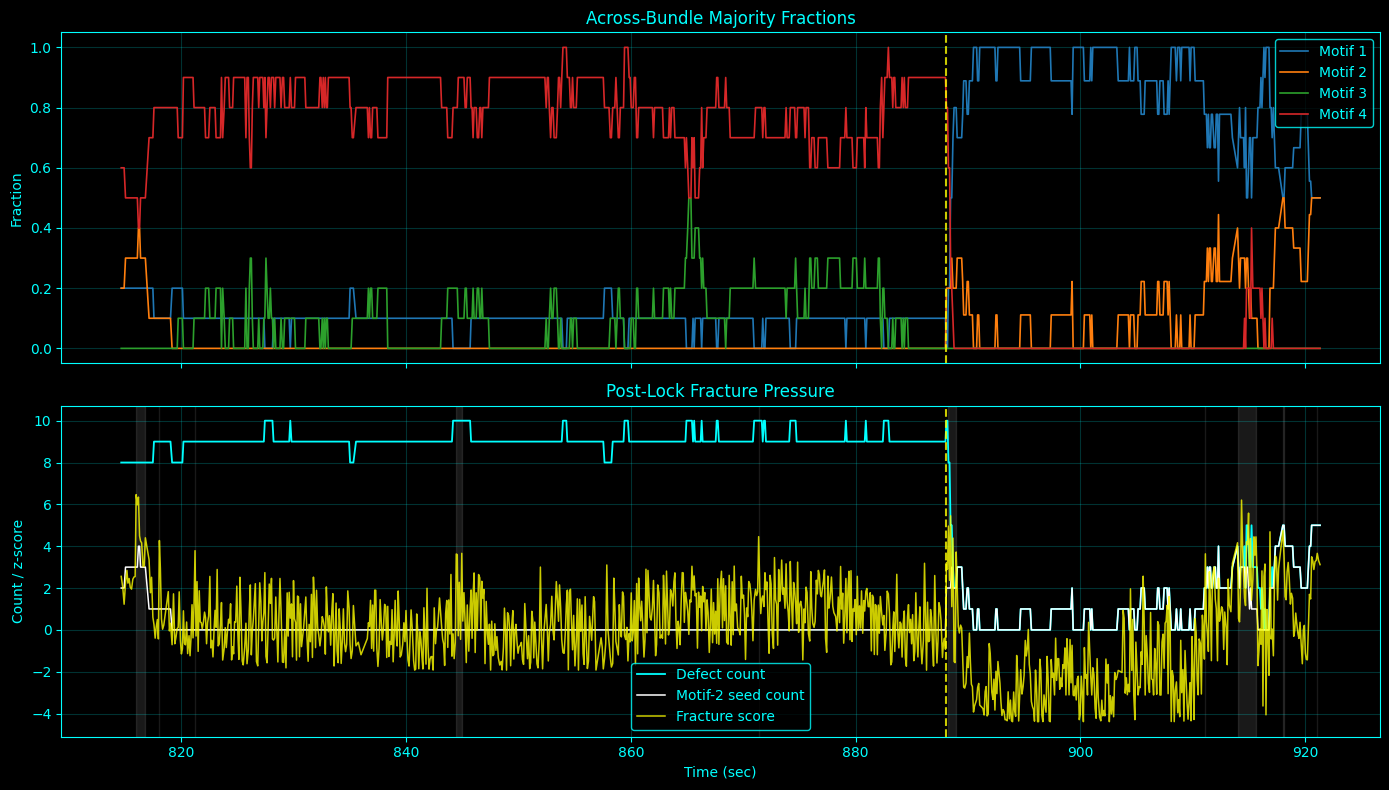

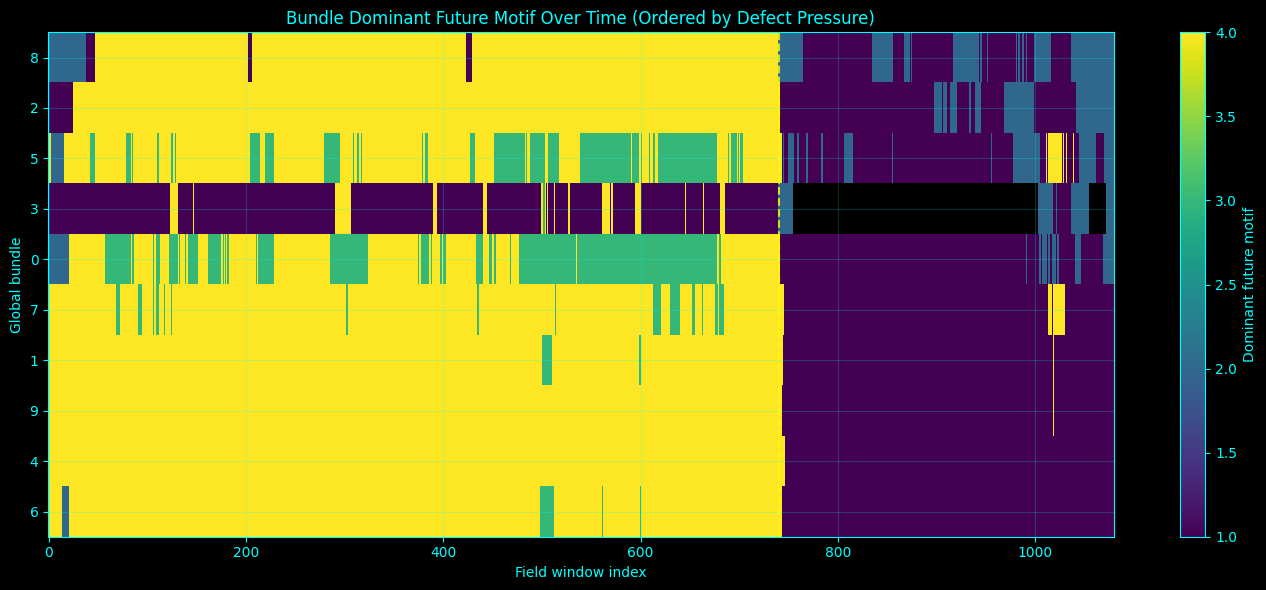

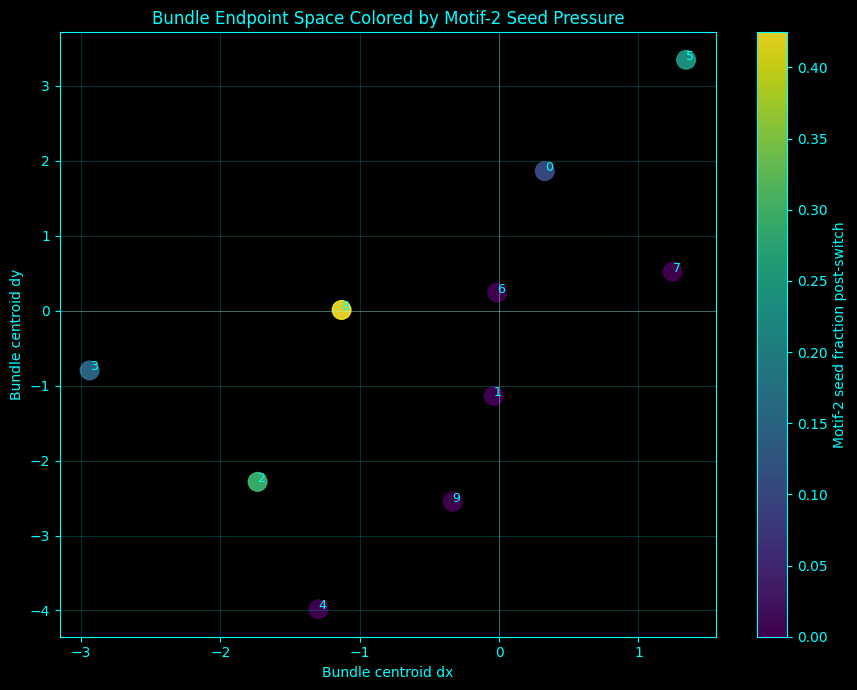

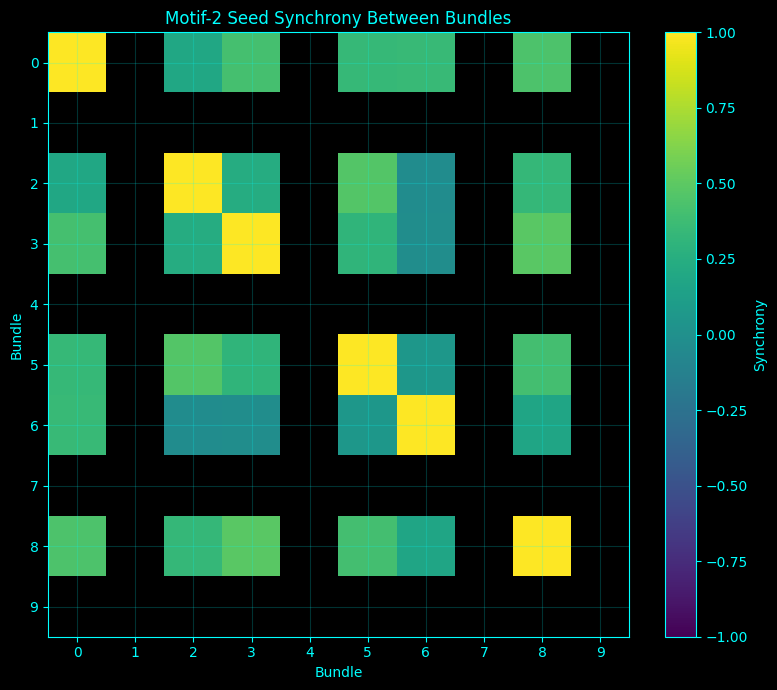

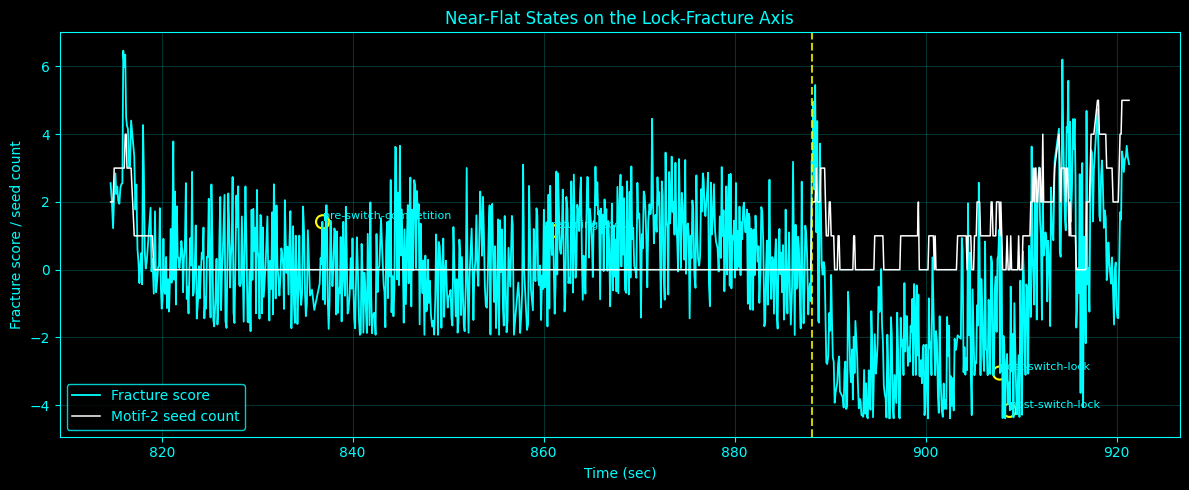


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/lock_fracture_atlas_v1/bundle_defect_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/lock_fracture_atlas_v1/time_resolved_fracture_pressure.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/lock_fracture_atlas_v1/proto_defect_episodes.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/lock_fracture_atlas_v1/motif2_seed_synchrony.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/lock_fracture_atlas_v1/near_flat_defect_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/lock_fracture_atlas_v1/lock_fracture_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/lock_fracture_atlas_v1/plots

Per-bundle defect summary:
 global_bundle  early_motif  late_motif  changed_label  switch_time_sec  centroid_dx  centroid_dy  global_motif_purity  global_motif_entropy  defect_fraction_pre  defect_fraction_post  motif2_seed_fraction_post  motif2_seed_fract

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

drift_dir = os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1")
wave_dir = os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1")
bundle_dir = os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1")

field_csv = os.path.join(drift_dir, "motif_field_with_bundle_semantic_fibers.csv")
switch_csv = os.path.join(wave_dir, "bundle_switch_times.csv")
phase_csv = os.path.join(wave_dir, "bundle_relabel_phase_index.csv")
near_flat_csv = os.path.join(wave_dir, "near_flat_relabel_stage_context.csv")
bundle_summary_csv = os.path.join(bundle_dir, "global_branch_bundle_summary.csv")

out_dir = os.path.join(base_dir, "results", "lock_fracture_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# post-switch fracture controls
smooth_window = 11
post_switch_guard_sec = 0.75
late_window_sec = 14.0
stable_run_min = 8
fracture_score_quantile = 0.97
episode_gap_sec = 0.50

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for t in cbar.ax.get_yticklabels():
        t.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

def finite_quantile(x, q, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return default
    return float(np.quantile(x, q))

def zscore_nan(x):
    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    out = np.zeros(len(x), dtype=float)

    if np.sum(finite) < 2:
        return out

    mu = np.mean(x[finite])
    sd = np.std(x[finite])

    if (not np.isfinite(sd)) or (sd < eps):
        out[finite] = 0.0
        return out

    out[finite] = (x[finite] - mu) / sd
    out[~finite] = 0.0
    return out

def rolling_mode_int(x, window):
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan)
    half = window // 2
    for i in range(len(x)):
        a = max(0, i - half)
        b = min(len(x), i + half + 1)
        vals = x[a:b]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        vals = vals.astype(int)
        uniq, counts = np.unique(vals, return_counts=True)
        out[i] = uniq[np.argmax(counts)]
    return out

def discover_dom_cols(cols):
    """
    Accept either:
      bundle_0_dom_motif, bundle_1_dom_motif, ...
    or looser:
      bundle_0, bundle_1, ...
    """
    dom = {}
    loose = {}

    pat_dom = re.compile(r"^bundle_(\d+)_dom_motif$")
    pat_loose = re.compile(r"^bundle_(\d+)$")

    for c in cols:
        m = pat_dom.match(c)
        if m:
            dom[int(m.group(1))] = c
            continue
        m = pat_loose.match(c)
        if m:
            loose[int(m.group(1))] = c

    if len(dom):
        return dict(sorted(dom.items())), "dom"
    if len(loose):
        return dict(sorted(loose.items())), "loose"
    return {}, None

def find_bundle_timeline_csv(search_roots):
    """
    Search recursively for a CSV with bundle dominant-motif timelines.
    """
    candidates = []

    for root in search_roots:
        if not os.path.exists(root):
            continue

        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if not fn.lower().endswith(".csv"):
                    continue

                path = os.path.join(dirpath, fn)
                try:
                    head = pd.read_csv(path, nrows=2)
                except Exception:
                    continue

                dom_cols, mode = discover_dom_cols(head.columns)
                if len(dom_cols) == 0:
                    continue

                score = 0
                name = fn.lower()

                if "dominant" in name:
                    score += 3
                if "motif" in name:
                    score += 3
                if "bundle" in name:
                    score += 2
                if "time" in name:
                    score += 1
                if "phase" in name:
                    score += 1
                if "center_time_sec" in head.columns:
                    score += 3
                if "time_sec" in head.columns:
                    score += 2

                candidates.append((score, path, mode, sorted(dom_cols.keys())))

    if len(candidates) == 0:
        raise FileNotFoundError("Could not find any CSV containing bundle dominant-motif timelines.")

    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0]

def longest_true_run_sec(mask, time_sec):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) == 0:
        return 0.0

    best = 0.0
    start = None
    for i, m in enumerate(mask):
        if m and start is None:
            start = i
        if (not m or i == len(mask) - 1) and start is not None:
            end = i if (m and i == len(mask) - 1) else i - 1
            best = max(best, float(time_sec[end] - time_sec[start]))
            start = None
    return best

def first_stable_label_time(time_sec, labels, target_label, dwell=8, frac=0.70):
    labels = np.asarray(labels, dtype=float)
    for i in range(0, len(labels) - dwell):
        block = labels[i:i + dwell]
        ok = np.mean(block == target_label)
        if ok >= frac:
            return float(time_sec[i]), int(i)
    return np.nan, np.nan

def build_time_clusters(times, gap_sec=0.5):
    times = np.sort(np.asarray(times, dtype=float))
    if len(times) == 0:
        return []

    clusters = []
    start = times[0]
    prev = times[0]
    count = 1

    for t in times[1:]:
        if (t - prev) <= gap_sec:
            count += 1
            prev = t
        else:
            clusters.append((start, prev, count))
            start = t
            prev = t
            count = 1

    clusters.append((start, prev, count))
    return clusters

def binary_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    good = np.isfinite(a) & np.isfinite(b)
    if np.sum(good) < 3:
        return np.nan
    a = a[good]
    b = b[good]
    if np.std(a) < eps or np.std(b) < eps:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def classify_bundle_fracture_role(row, q):
    seed2 = row["motif2_seed_fraction_post"]
    defect = row["defect_fraction_post"]
    run2 = row["longest_motif2_seed_run_sec"]
    late_motif = row["late_motif"]
    changed = row["changed_label"]

    if late_motif == 2 and seed2 >= q["seed75"]:
        return "motif2-seed"
    if seed2 >= q["seed50"] and run2 >= q["run75"]:
        return "motif2-coalition"
    if defect >= q["defect75"] and late_motif == 1:
        return "lock-fringe"
    if changed == 1 and late_motif == 1 and defect < q["defect50"]:
        return "core-locker"
    if changed == 0 and late_motif == 1:
        return "ambiguous-locker"
    return "mixed-defector"

def align_extra_col(col_name, time_sec, timeline_df=None, phase_df=None, extra_source_df=None):
    base = pd.DataFrame({"center_time_sec": time_sec})

    if timeline_df is not None and col_name in timeline_df.columns:
        tmp = pd.merge_asof(
            base,
            timeline_df[["center_time_sec", col_name]].sort_values("center_time_sec"),
            on="center_time_sec",
            direction="nearest"
        )
        return tmp[col_name].values.astype(float)

    if extra_source_df is not None and col_name in extra_source_df.columns:
        tmp = pd.merge_asof(
            base,
            extra_source_df[["center_time_sec", col_name]].sort_values("center_time_sec"),
            on="center_time_sec",
            direction="nearest"
        )
        return tmp[col_name].values.astype(float)

    if phase_df is not None and col_name in phase_df.columns:
        tmp = pd.merge_asof(
            base,
            phase_df[["center_time_sec", col_name]].sort_values("center_time_sec"),
            on="center_time_sec",
            direction="nearest"
        )
        return tmp[col_name].values.astype(float)

    return np.zeros(len(time_sec), dtype=float)

# -------------------------------------------------------
# LOAD INPUTS
# -------------------------------------------------------
switch_df = pd.read_csv(switch_csv).sort_values("global_bundle").reset_index(drop=True)
phase_df = pd.read_csv(phase_csv).sort_values("center_time_sec").reset_index(drop=True)
bundle_summary_df = pd.read_csv(bundle_summary_csv).sort_values("global_bundle").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

extra_source_df = None
if os.path.exists(field_csv):
    try:
        extra_source_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)
    except Exception:
        extra_source_df = None

best_score, timeline_csv, timeline_mode, bundle_ids = find_bundle_timeline_csv(
    [drift_dir, wave_dir, bundle_dir]
)
print(f"Using bundle timeline CSV: {timeline_csv}")

timeline_df = pd.read_csv(timeline_csv)

if "center_time_sec" not in timeline_df.columns:
    if "time_sec" in timeline_df.columns:
        timeline_df = timeline_df.rename(columns={"time_sec": "center_time_sec"})
    else:
        raise ValueError("Timeline CSV needs center_time_sec or time_sec.")

timeline_df = timeline_df.sort_values("center_time_sec").reset_index(drop=True)
time_sec = timeline_df["center_time_sec"].values

dom_cols, mode_now = discover_dom_cols(timeline_df.columns)
if len(dom_cols) == 0:
    raise ValueError("Timeline CSV found, but no bundle dominant-motif columns were detected.")

bundle_ids = sorted(dom_cols.keys())

# -------------------------------------------------------
# SMOOTH DOMINANT MOTIF TIMELINES
# -------------------------------------------------------
smooth_df = pd.DataFrame({"center_time_sec": time_sec})
for b in bundle_ids:
    x = timeline_df[dom_cols[b]].values.astype(float)
    smooth_df[f"bundle_{b}_dom_motif"] = rolling_mode_int(x, smooth_window)

# -------------------------------------------------------
# GLOBAL SWITCH CENTER
# -------------------------------------------------------
switch_times = switch_df["switch_time_sec"].values
switch_times = switch_times[np.isfinite(switch_times)]
switch_center_time = float(np.median(switch_times)) if len(switch_times) else np.nan

post_mask = time_sec >= (switch_center_time + post_switch_guard_sec)
late_mask = time_sec >= (np.max(time_sec) - late_window_sec)

# -------------------------------------------------------
# MAJORITY MOTIF FRACTIONS / DEFECT COUNTS
# -------------------------------------------------------
majority_label = np.full(len(time_sec), np.nan)
motif1_fraction = np.full(len(time_sec), np.nan)
motif2_fraction = np.full(len(time_sec), np.nan)
motif3_fraction = np.full(len(time_sec), np.nan)
motif4_fraction = np.full(len(time_sec), np.nan)

for i in range(len(time_sec)):
    vals = []
    for b in bundle_ids:
        v = smooth_df.loc[i, f"bundle_{b}_dom_motif"]
        if np.isfinite(v):
            vals.append(int(v))

    if len(vals) == 0:
        continue

    vals = np.asarray(vals, dtype=int)
    uniq, counts = np.unique(vals, return_counts=True)
    majority_label[i] = uniq[np.argmax(counts)]

    motif1_fraction[i] = np.mean(vals == 1)
    motif2_fraction[i] = np.mean(vals == 2)
    motif3_fraction[i] = np.mean(vals == 3)
    motif4_fraction[i] = np.mean(vals == 4)

phase_index = motif1_fraction - motif4_fraction

# -------------------------------------------------------
# OPTIONAL DRIFT/PURITY/CONSENSUS SIGNALS
# -------------------------------------------------------
extra_cols = {
    "within_bundle_purity": align_extra_col(
        "within_bundle_purity",
        time_sec,
        timeline_df=timeline_df,
        phase_df=phase_df,
        extra_source_df=extra_source_df
    ),
    "across_bundle_consensus": align_extra_col(
        "across_bundle_consensus",
        time_sec,
        timeline_df=timeline_df,
        phase_df=phase_df,
        extra_source_df=extra_source_df
    ),
    "bundle_semantic_drift": align_extra_col(
        "bundle_semantic_drift",
        time_sec,
        timeline_df=timeline_df,
        phase_df=phase_df,
        extra_source_df=extra_source_df
    ),
}

# -------------------------------------------------------
# PER-BUNDLE FRACTURE SUMMARY
# -------------------------------------------------------
bundle_rows = []

for _, sw in switch_df.iterrows():
    b = int(sw["global_bundle"])
    col = f"bundle_{b}_dom_motif"
    if col not in smooth_df.columns:
        continue

    x = smooth_df[col].values.astype(float)

    defect = np.isfinite(x) & (x != 1)  # post-lock reference is motif 1
    seed2 = np.isfinite(x) & (x == 2)

    defect_fraction_pre = safe_mean(defect[~post_mask])
    defect_fraction_post = safe_mean(defect[post_mask])
    motif2_seed_fraction_post = safe_mean(seed2[post_mask])
    motif2_seed_fraction_late = safe_mean(seed2[late_mask])

    first_motif2_time, first_motif2_idx = (
        first_stable_label_time(
            time_sec[post_mask],
            x[post_mask],
            target_label=2,
            dwell=stable_run_min,
            frac=0.70
        )
        if np.any(post_mask) else (np.nan, np.nan)
    )

    longest_seed_run = (
        longest_true_run_sec(seed2[post_mask], time_sec[post_mask])
        if np.any(post_mask) else np.nan
    )

    bundle_rows.append({
        "global_bundle": b,
        "early_motif": sw["early_motif"],
        "late_motif": sw["late_motif"],
        "changed_label": sw["changed_label"],
        "switch_time_sec": sw["switch_time_sec"],
        "centroid_dx": sw["centroid_dx"],
        "centroid_dy": sw["centroid_dy"],
        "global_motif_purity": sw["global_motif_purity"],
        "global_motif_entropy": sw["global_motif_entropy"],
        "defect_fraction_pre": defect_fraction_pre,
        "defect_fraction_post": defect_fraction_post,
        "motif2_seed_fraction_post": motif2_seed_fraction_post,
        "motif2_seed_fraction_late": motif2_seed_fraction_late,
        "first_stable_motif2_time_sec": first_motif2_time,
        "longest_motif2_seed_run_sec": longest_seed_run,
    })

bundle_defect_df = pd.DataFrame(bundle_rows).sort_values("global_bundle").reset_index(drop=True)

q = {
    "seed50": finite_quantile(bundle_defect_df["motif2_seed_fraction_post"], 0.50, default=0.0),
    "seed75": finite_quantile(bundle_defect_df["motif2_seed_fraction_post"], 0.75, default=0.0),
    "run75": finite_quantile(bundle_defect_df["longest_motif2_seed_run_sec"], 0.75, default=0.0),
    "defect50": finite_quantile(bundle_defect_df["defect_fraction_post"], 0.50, default=0.0),
    "defect75": finite_quantile(bundle_defect_df["defect_fraction_post"], 0.75, default=0.0),
}
bundle_defect_df["fracture_role"] = bundle_defect_df.apply(lambda r: classify_bundle_fracture_role(r, q), axis=1)

# -------------------------------------------------------
# TIME-RESOLVED DEFECT PRESSURE
# -------------------------------------------------------
seed2_mat = []
defect_mat = []

for b in bundle_ids:
    col = f"bundle_{b}_dom_motif"
    if col not in smooth_df.columns:
        continue
    x = smooth_df[col].values.astype(float)
    seed2_mat.append((np.isfinite(x) & (x == 2)).astype(float))
    defect_mat.append((np.isfinite(x) & (x != 1)).astype(float))

seed2_mat = np.vstack(seed2_mat)
defect_mat = np.vstack(defect_mat)

seed2_count = np.sum(seed2_mat, axis=0)
defect_count = np.sum(defect_mat, axis=0)

fracture_score = (
    zscore_nan(seed2_count) +
    zscore_nan(defect_count) +
    zscore_nan(extra_cols["bundle_semantic_drift"]) -
    zscore_nan(extra_cols["across_bundle_consensus"])
)

finite_fracture = fracture_score[np.isfinite(fracture_score)]
if len(finite_fracture) == 0:
    proto_thresh = np.nan
    proto_times = np.array([], dtype=float)
else:
    proto_thresh = np.quantile(finite_fracture, fracture_score_quantile)
    proto_times = time_sec[np.isfinite(fracture_score) & (fracture_score >= proto_thresh)]

proto_clusters = build_time_clusters(proto_times, gap_sec=episode_gap_sec)

proto_rows = []
for i, (t0, t1, n) in enumerate(proto_clusters, start=1):
    m = (time_sec >= t0) & (time_sec <= t1)
    proto_rows.append({
        "proto_episode_id": i,
        "start_time_sec": float(t0),
        "end_time_sec": float(t1),
        "duration_sec": float(t1 - t0),
        "n_windows": int(n),
        "mean_fracture_score": safe_mean(fracture_score[m]),
        "mean_seed2_count": safe_mean(seed2_count[m]),
        "mean_defect_count": safe_mean(defect_count[m]),
        "mean_consensus": safe_mean(extra_cols["across_bundle_consensus"][m]),
        "mean_drift": safe_mean(extra_cols["bundle_semantic_drift"][m]),
    })

if len(proto_rows) == 0:
    proto_df = pd.DataFrame(columns=[
        "proto_episode_id",
        "start_time_sec",
        "end_time_sec",
        "duration_sec",
        "n_windows",
        "mean_fracture_score",
        "mean_seed2_count",
        "mean_defect_count",
        "mean_consensus",
        "mean_drift",
    ])
else:
    proto_df = pd.DataFrame(proto_rows).sort_values(
        ["mean_fracture_score", "duration_sec"],
        ascending=[False, False]
    ).reset_index(drop=True)

# -------------------------------------------------------
# BUNDLE COALITION SYNCHRONY
# -------------------------------------------------------
sync = np.full((len(bundle_ids), len(bundle_ids)), np.nan)
for i, bi in enumerate(bundle_ids):
    for j, bj in enumerate(bundle_ids):
        if (f"bundle_{bi}_dom_motif" not in smooth_df.columns) or (f"bundle_{bj}_dom_motif" not in smooth_df.columns):
            continue
        sync[i, j] = binary_corr(seed2_mat[i], seed2_mat[j])

sync_df = pd.DataFrame(sync, index=bundle_ids, columns=bundle_ids)

# -------------------------------------------------------
# NEAR-FLAT DEFECT CONTEXT
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(time_sec - t0)))

        near_flat_rows.append({
            "time_sec": t0,
            "nearest_time_sec": float(time_sec[idx]),
            "stage_label": row["stage_label"] if "stage_label" in row.index else "NA",
            "dominant_motif": int(row["dominant_motif"]) if "dominant_motif" in row.index else np.nan,
            "phase_index": float(phase_index[idx]),
            "motif2_fraction": float(motif2_fraction[idx]),
            "seed2_count": float(seed2_count[idx]),
            "defect_count": float(defect_count[idx]),
            "across_bundle_consensus": float(extra_cols["across_bundle_consensus"][idx]),
            "bundle_semantic_drift": float(extra_cols["bundle_semantic_drift"][idx]),
            "fracture_score": float(fracture_score[idx]),
        })

near_flat_defect_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
bundle_defect_csv = os.path.join(out_dir, "bundle_defect_summary.csv")
time_csv = os.path.join(out_dir, "time_resolved_fracture_pressure.csv")
proto_csv = os.path.join(out_dir, "proto_defect_episodes.csv")
sync_csv = os.path.join(out_dir, "motif2_seed_synchrony.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_defect_context.csv")
summary_txt = os.path.join(out_dir, "lock_fracture_summary.txt")

bundle_defect_df.to_csv(bundle_defect_csv, index=False)

time_df = pd.DataFrame({
    "center_time_sec": time_sec,
    "majority_label": majority_label,
    "motif1_fraction": motif1_fraction,
    "motif2_fraction": motif2_fraction,
    "motif3_fraction": motif3_fraction,
    "motif4_fraction": motif4_fraction,
    "phase_index": phase_index,
    "defect_count": defect_count,
    "motif2_seed_count": seed2_count,
    "within_bundle_purity": extra_cols["within_bundle_purity"],
    "across_bundle_consensus": extra_cols["across_bundle_consensus"],
    "bundle_semantic_drift": extra_cols["bundle_semantic_drift"],
    "fracture_score": fracture_score,
})
time_df.to_csv(time_csv, index=False)

proto_df.to_csv(proto_csv, index=False)
sync_df.to_csv(sync_csv)
near_flat_defect_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Lock Fracture Atlas Summary\n")
    f.write("==========================\n\n")
    f.write(f"Timeline CSV used: {timeline_csv}\n")
    f.write(f"switch_center_time = {switch_center_time:.6f}\n")
    f.write(f"smooth_window = {smooth_window}\n")
    f.write(f"post_switch_guard_sec = {post_switch_guard_sec}\n")
    f.write(f"late_window_sec = {late_window_sec}\n\n")

    f.write("Per-bundle defect summary:\n")
    f.write(bundle_defect_df.to_string(index=False))
    f.write("\n\n")

    f.write("Top proto-defect episodes:\n")
    if len(proto_df):
        f.write(proto_df.head(20).to_string(index=False))
    else:
        f.write("None detected")
    f.write("\n\n")

    if len(near_flat_defect_df):
        f.write("Near-flat defect context:\n")
        f.write(near_flat_defect_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) majority fractions + defect pressure
fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(time_sec, motif1_fraction, linewidth=1.2, label="Motif 1")
ax1.plot(time_sec, motif2_fraction, linewidth=1.2, label="Motif 2")
ax1.plot(time_sec, motif3_fraction, linewidth=1.2, label="Motif 3")
ax1.plot(time_sec, motif4_fraction, linewidth=1.2, label="Motif 4")
ax1.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)
ax1.set_title("Across-Bundle Majority Fractions")
ax1.set_ylabel("Fraction")
ax1.legend()

ax2.plot(time_sec, defect_count, color=ACCENT, linewidth=1.3, label="Defect count")
ax2.plot(time_sec, seed2_count, color="white", linewidth=1.1, label="Motif-2 seed count")
ax2.plot(time_sec, fracture_score, color="yellow", linewidth=1.1, alpha=0.8, label="Fracture score")
ax2.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)

for _, r in proto_df.head(10).iterrows():
    ax2.axvspan(r["start_time_sec"], r["end_time_sec"], color="white", alpha=0.10)

ax2.set_title("Post-Lock Fracture Pressure")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Count / z-score")
ax2.legend()

plot1_path = os.path.join(plots_dir, "fracture_pressure_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) bundles ordered by motif-2 seed pressure
order_df = bundle_defect_df.sort_values(
    ["motif2_seed_fraction_post", "defect_fraction_post"],
    ascending=False
).reset_index(drop=True)

heat = []
yticks = []
for _, r in order_df.iterrows():
    b = int(r["global_bundle"])
    col = f"bundle_{b}_dom_motif"
    if col in smooth_df.columns:
        heat.append(smooth_df[col].values)
        yticks.append(str(b))

heat = np.asarray(heat, dtype=float)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(heat, aspect="auto", interpolation="nearest")
ax.axvline(np.argmin(np.abs(time_sec - switch_center_time)), color="yellow", linestyle="--", alpha=0.8)
ax.set_title("Bundle Dominant Future Motif Over Time (Ordered by Defect Pressure)")
ax.set_xlabel("Field window index")
ax.set_ylabel("Global bundle")
ax.set_yticks(np.arange(len(yticks)))
ax.set_yticklabels(yticks)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Dominant future motif")

plot2_path = os.path.join(plots_dir, "bundle_heatmap_ordered_by_defect_pressure.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) endpoint-space map of motif-2 seed bundles
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    bundle_defect_df["centroid_dx"].values,
    bundle_defect_df["centroid_dy"].values,
    c=bundle_defect_df["motif2_seed_fraction_post"].values,
    s=180,
    alpha=0.9
)

for _, r in bundle_defect_df.iterrows():
    ax.text(r["centroid_dx"], r["centroid_dy"], str(int(r["global_bundle"])), fontsize=9)

ax.axhline(0.0, color="white", alpha=0.25, linewidth=0.8)
ax.axvline(0.0, color="white", alpha=0.25, linewidth=0.8)
ax.set_title("Bundle Endpoint Space Colored by Motif-2 Seed Pressure")
ax.set_xlabel("Bundle centroid dx")
ax.set_ylabel("Bundle centroid dy")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Motif-2 seed fraction post-switch")

plot3_path = os.path.join(plots_dir, "bundle_endpoint_space_seed_pressure.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) motif-2 synchrony heatmap
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(sync, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
ax.set_title("Motif-2 Seed Synchrony Between Bundles")
ax.set_xlabel("Bundle")
ax.set_ylabel("Bundle")
ax.set_xticks(np.arange(len(bundle_ids)))
ax.set_yticks(np.arange(len(bundle_ids)))
ax.set_xticklabels(bundle_ids)
ax.set_yticklabels(bundle_ids)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Synchrony")

plot4_path = os.path.join(plots_dir, "motif2_seed_synchrony_heatmap.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) near-flat states on the fracture axis
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(time_sec, fracture_score, color=ACCENT, linewidth=1.3, label="Fracture score")
ax.plot(time_sec, seed2_count, color="white", linewidth=1.1, label="Motif-2 seed count")
ax.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)

if len(near_flat_defect_df):
    ax.scatter(
        near_flat_defect_df["time_sec"].values,
        near_flat_defect_df["fracture_score"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5
    )
    for _, r in near_flat_defect_df.iterrows():
        ax.text(r["time_sec"], r["fracture_score"] + 0.08, r["stage_label"], fontsize=8)

ax.set_title("Near-Flat States on the Lock-Fracture Axis")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Fracture score / seed count")
ax.legend()

plot5_path = os.path.join(plots_dir, "nearflat_on_fracture_axis.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nSaved:")
print(bundle_defect_csv)
print(time_csv)
print(proto_csv)
print(sync_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print("\nPer-bundle defect summary:")
print(bundle_defect_df.to_string(index=False))

if len(proto_df):
    print("\nTop proto-defect episodes:")
    print(proto_df.head(15).to_string(index=False))
else:
    print("\nTop proto-defect episodes:")
    print("None detected")

if len(near_flat_defect_df):
    print("\nNear-flat defect context:")
    print(near_flat_defect_df.to_string(index=False))

Using bundle timeline CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_semantic_drift_atlas_v1/bundle_dominant_motif_over_time.csv
Switch center time: 888.073000
Pre-switch windows: 719
Lock-core windows: 70
Late windows: 142


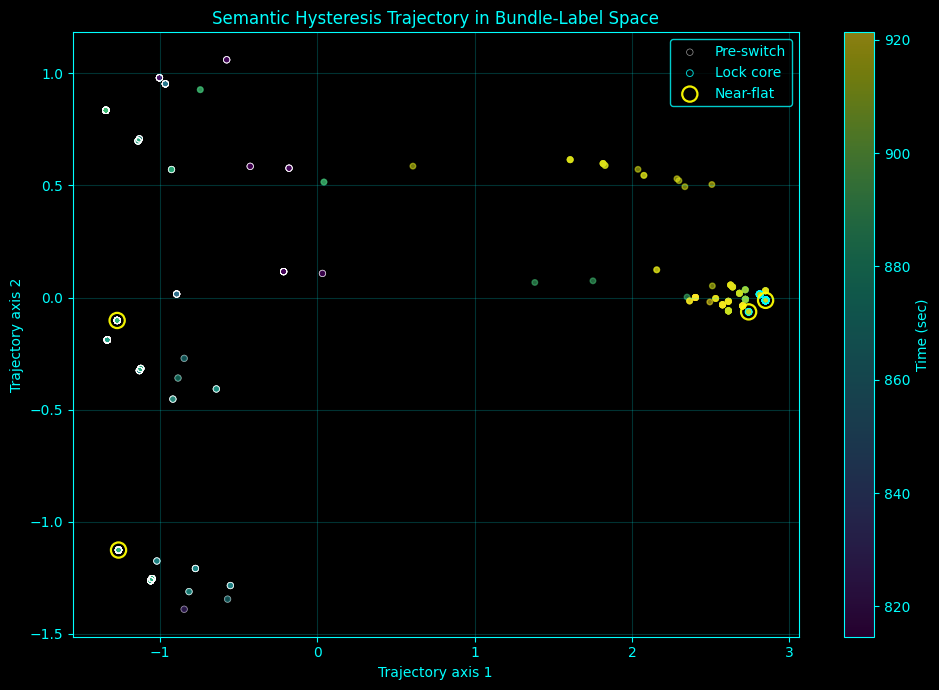

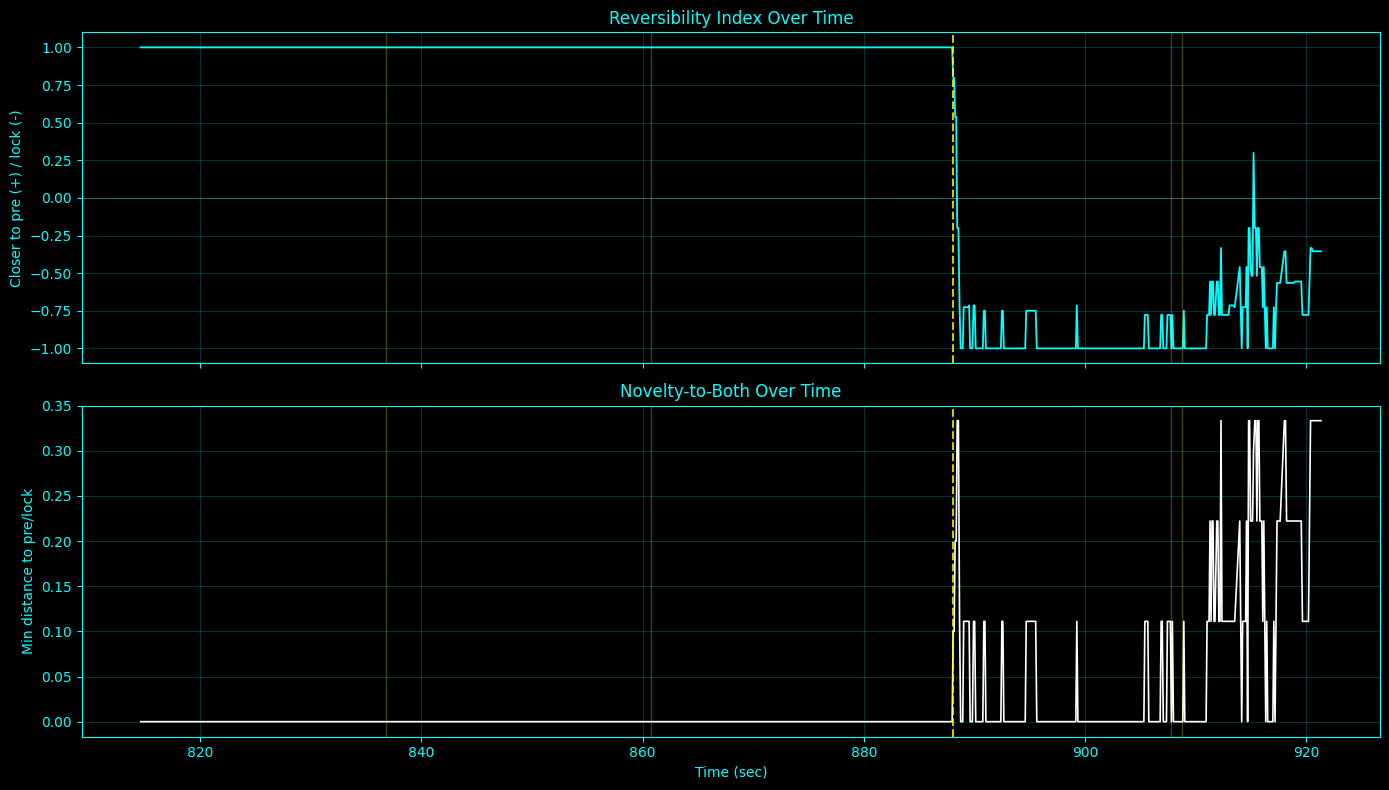

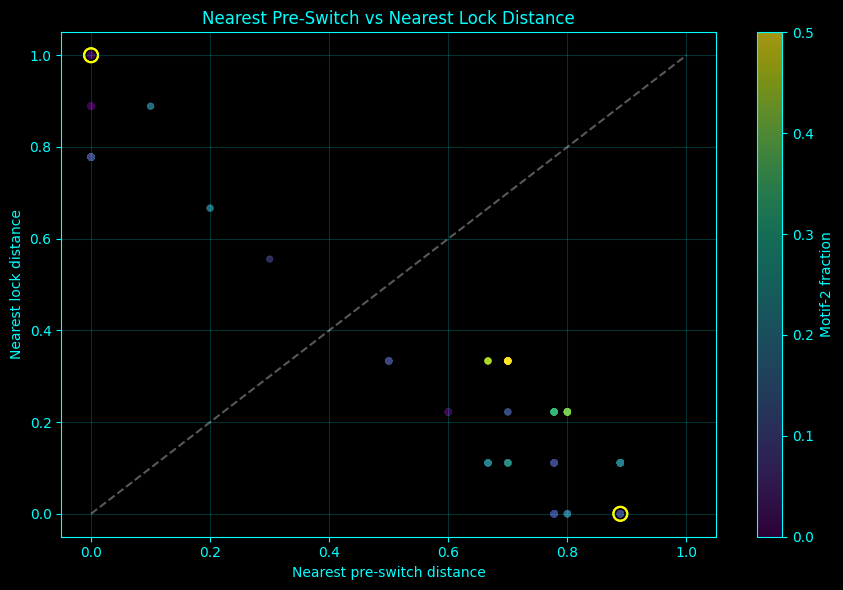

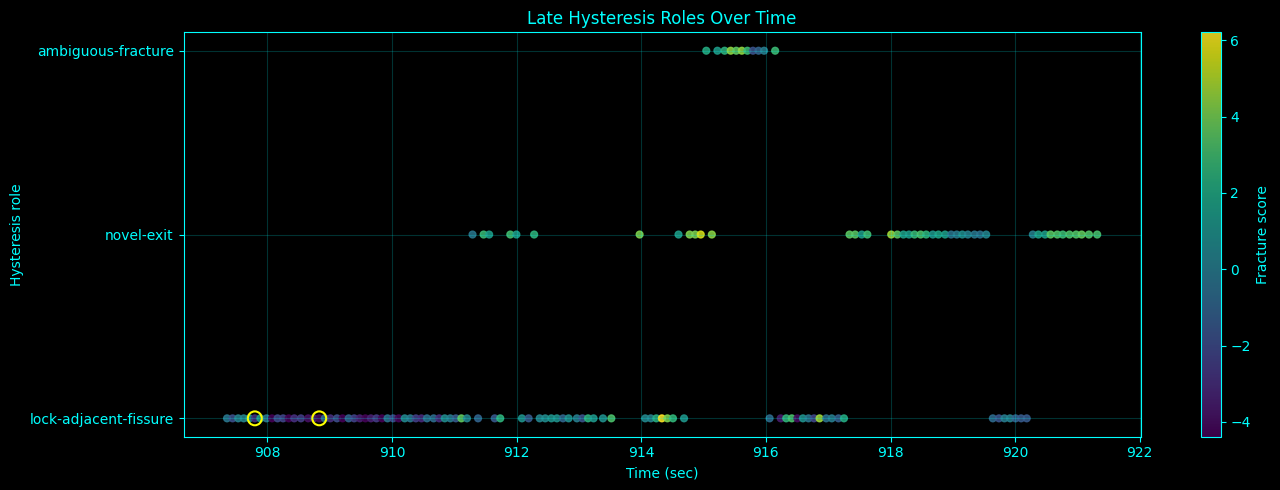

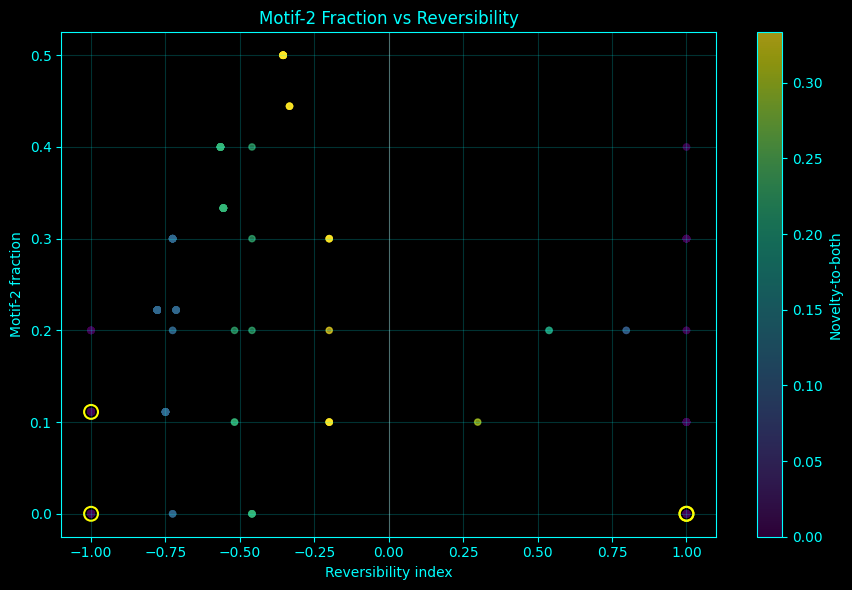


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/semantic_hysteresis_atlas_v1/window_hysteresis_metrics.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/semantic_hysteresis_atlas_v1/late_hysteresis_episodes.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/semantic_hysteresis_atlas_v1/near_flat_hysteresis_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/semantic_hysteresis_atlas_v1/semantic_hysteresis_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/semantic_hysteresis_atlas_v1/plots

Late hysteresis role counts:
hysteresis_role
lock-adjacent-fissure    87
novel-exit               44
ambiguous-fracture       11

Top late hysteresis episodes:
 episode_id  start_time_sec  end_time_sec  duration_sec  n_windows       hysteresis_role  mean_reversibility_index  mean_novelty_to_both  mean_motif2_fraction  mean_seed2_count  mean_fracture_score
         14         914.776       914.954         0.178          3       

In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

drift_dir = os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1")
wave_dir = os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1")
fracture_dir = os.path.join(base_dir, "results", "lock_fracture_atlas_v1")

time_csv = os.path.join(fracture_dir, "time_resolved_fracture_pressure.csv")
near_flat_csv = os.path.join(fracture_dir, "near_flat_defect_context.csv")
bundle_defect_csv = os.path.join(fracture_dir, "bundle_defect_summary.csv")
switch_csv = os.path.join(wave_dir, "bundle_switch_times.csv")

out_dir = os.path.join(base_dir, "results", "semantic_hysteresis_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# phase controls
smooth_window = 11
pre_buffer_sec = 2.0
post_guard_sec = 0.75
late_window_sec = 14.0

# lock-core selection
lock_motif1_min = 0.80
lock_fracture_quantile = 0.25

# hysteresis classification
replay_margin = 0.12
novel_quantile = 0.80
close_quantile = 0.55
episode_gap_sec = 0.50

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def finite_quantile(x, q, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return default
    return float(np.quantile(x, q))

def rolling_mode_int(x, window):
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan)
    half = window // 2
    for i in range(len(x)):
        a = max(0, i - half)
        b = min(len(x), i + half + 1)
        vals = x[a:b]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        vals = vals.astype(int)
        uniq, counts = np.unique(vals, return_counts=True)
        out[i] = uniq[np.argmax(counts)]
    return out

def discover_dom_cols(cols):
    """
    Accept either:
      bundle_0_dom_motif, ...
    or looser:
      bundle_0, ...
    """
    dom = {}
    loose = {}

    pat_dom = re.compile(r"^bundle_(\d+)_dom_motif$")
    pat_loose = re.compile(r"^bundle_(\d+)$")

    for c in cols:
        m = pat_dom.match(c)
        if m:
            dom[int(m.group(1))] = c
            continue
        m = pat_loose.match(c)
        if m:
            loose[int(m.group(1))] = c

    if len(dom):
        return dict(sorted(dom.items())), "dom"
    if len(loose):
        return dict(sorted(loose.items())), "loose"
    return {}, None

def find_bundle_timeline_csv(search_roots):
    candidates = []

    for root in search_roots:
        if not os.path.exists(root):
            continue

        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if not fn.lower().endswith(".csv"):
                    continue

                path = os.path.join(dirpath, fn)
                try:
                    head = pd.read_csv(path, nrows=2)
                except Exception:
                    continue

                dom_cols, mode = discover_dom_cols(head.columns)
                if len(dom_cols) == 0:
                    continue

                score = 0
                name = fn.lower()
                if "bundle" in name:
                    score += 2
                if "motif" in name:
                    score += 2
                if "dominant" in name:
                    score += 2
                if "time" in name:
                    score += 1
                if "center_time_sec" in head.columns:
                    score += 3
                if "time_sec" in head.columns:
                    score += 2

                candidates.append((score, path))

    if len(candidates) == 0:
        raise FileNotFoundError("No bundle dominant-motif timeline CSV found.")

    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][1]

def onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4)):
    """
    label_matrix: n x b, integer labels or nan
    returns n x (b * len(motif_values))
    """
    label_matrix = np.asarray(label_matrix, dtype=float)
    n, b = label_matrix.shape
    out = np.zeros((n, b * len(motif_values)), dtype=float)

    for j in range(b):
        for k, mv in enumerate(motif_values):
            out[:, j * len(motif_values) + k] = (label_matrix[:, j] == mv).astype(float)

    return out

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def build_time_clusters(rows_df, gap_sec=0.5):
    """
    rows_df must already be sorted by time and contain:
      center_time_sec, hysteresis_role
    """
    if len(rows_df) == 0:
        return []

    clusters = []
    start_i = 0

    times = rows_df["center_time_sec"].values
    roles = rows_df["hysteresis_role"].values

    for i in range(1, len(rows_df)):
        changed = (roles[i] != roles[i - 1]) or ((times[i] - times[i - 1]) > gap_sec)
        if changed:
            clusters.append((start_i, i - 1))
            start_i = i

    clusters.append((start_i, len(rows_df) - 1))
    return clusters

def pairwise_min_hamming(label_matrix, ref_idx):
    """
    label_matrix: n x b, integer or nan
    ref_idx: indices of reference set

    Returns:
      min_dist: length n
      argmin_ref_global_idx: length n
    """
    M = np.asarray(label_matrix, dtype=float)
    R = M[ref_idx]

    if len(R) == 0:
        return np.full(len(M), np.nan), np.full(len(M), -1, dtype=int)

    valid = np.isfinite(M[:, None, :]) & np.isfinite(R[None, :, :])
    diff = (M[:, None, :] != R[None, :, :]) & valid

    denom = np.sum(valid, axis=2)
    denom = np.maximum(denom, 1)

    dist = np.sum(diff, axis=2) / denom
    argmin_local = np.argmin(dist, axis=1)
    min_dist = dist[np.arange(len(M)), argmin_local]
    argmin_global = np.asarray(ref_idx, dtype=int)[argmin_local]

    return min_dist, argmin_global

def classify_hysteresis_role(row, replay_margin, close_thresh, novel_thresh):
    d_pre = row["nearest_pre_dist"]
    d_lock = row["nearest_lock_dist"]
    rev = row["reversibility_index"]
    novelty = row["novelty_to_both"]
    motif2_frac = row["motif2_fraction"]

    if not np.isfinite(d_pre) or not np.isfinite(d_lock):
        return "undefined"

    if novelty >= novel_thresh and motif2_frac >= 0.20:
        return "novel-exit"

    if rev >= replay_margin and novelty <= close_thresh:
        return "pre-switch-replay"

    if rev <= -replay_margin and novelty <= close_thresh:
        return "lock-adjacent-fissure"

    if motif2_frac >= 0.20 and rev > 0:
        return "partial-replay"

    return "ambiguous-fracture"

# -------------------------------------------------------
# LOAD INPUTS
# -------------------------------------------------------
time_df = pd.read_csv(time_csv).sort_values("center_time_sec").reset_index(drop=True)
switch_df = pd.read_csv(switch_csv).sort_values("global_bundle").reset_index(drop=True)
bundle_defect_df = pd.read_csv(bundle_defect_csv).sort_values("global_bundle").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

timeline_csv = find_bundle_timeline_csv([drift_dir, wave_dir, fracture_dir])
print(f"Using bundle timeline CSV: {timeline_csv}")

timeline_df = pd.read_csv(timeline_csv)
if "center_time_sec" not in timeline_df.columns:
    if "time_sec" in timeline_df.columns:
        timeline_df = timeline_df.rename(columns={"time_sec": "center_time_sec"})
    else:
        raise ValueError("Timeline CSV needs center_time_sec or time_sec.")

timeline_df = timeline_df.sort_values("center_time_sec").reset_index(drop=True)

# align time_df to timeline grid if needed
if not np.array_equal(
    np.round(time_df["center_time_sec"].values, 6),
    np.round(timeline_df["center_time_sec"].values, 6)
):
    aligned = pd.merge_asof(
        timeline_df[["center_time_sec"]],
        time_df.sort_values("center_time_sec"),
        on="center_time_sec",
        direction="nearest"
    )
    time_df = aligned.copy()

time_sec = timeline_df["center_time_sec"].values

dom_cols, mode = discover_dom_cols(timeline_df.columns)
if len(dom_cols) == 0:
    raise ValueError("No bundle dominant-motif columns found in timeline CSV.")

bundle_ids = sorted(dom_cols.keys())

# -------------------------------------------------------
# SMOOTH BUNDLE LABEL MATRIX
# -------------------------------------------------------
smooth_df = pd.DataFrame({"center_time_sec": time_sec})

for b in bundle_ids:
    x = timeline_df[dom_cols[b]].values.astype(float)
    smooth_df[f"bundle_{b}"] = rolling_mode_int(x, smooth_window)

label_matrix = np.column_stack([smooth_df[f"bundle_{b}"].values for b in bundle_ids])

# -------------------------------------------------------
# SWITCH CENTER / PHASE MASKS
# -------------------------------------------------------
switch_times = switch_df["switch_time_sec"].values
switch_times = switch_times[np.isfinite(switch_times)]
switch_center_time = float(np.median(switch_times)) if len(switch_times) else np.nan

pre_mask = time_sec <= (switch_center_time - pre_buffer_sec)
post_mask = time_sec >= (switch_center_time + post_guard_sec)
late_mask = time_sec >= (np.max(time_sec) - late_window_sec)

post_fracture = time_df.loc[post_mask, "fracture_score"].values
lock_thresh = finite_quantile(post_fracture, lock_fracture_quantile, default=0.0)

lock_core_mask = (
    post_mask &
    (~late_mask) &
    (time_df["motif1_fraction"].values >= lock_motif1_min) &
    (time_df["fracture_score"].values <= lock_thresh)
)

# fallbacks
if np.sum(pre_mask) < 10:
    pre_mask = time_sec <= np.quantile(time_sec, 0.30)

if np.sum(lock_core_mask) < 10:
    lock_core_mask = post_mask & (time_df["motif1_fraction"].values >= lock_motif1_min)

pre_idx = np.where(pre_mask)[0]
lock_idx = np.where(lock_core_mask)[0]
late_idx = np.where(late_mask)[0]

print(f"Switch center time: {switch_center_time:.6f}")
print(f"Pre-switch windows: {len(pre_idx)}")
print(f"Lock-core windows: {len(lock_idx)}")
print(f"Late windows: {len(late_idx)}")

# -------------------------------------------------------
# DISTANCE TO PRE-SWITCH AND LOCK ENSEMBLES
# -------------------------------------------------------
nearest_pre_dist, nearest_pre_idx = pairwise_min_hamming(label_matrix, pre_idx)
nearest_lock_dist, nearest_lock_idx = pairwise_min_hamming(label_matrix, lock_idx)

novelty_to_both = np.minimum(nearest_pre_dist, nearest_lock_dist)
reversibility_index = (nearest_lock_dist - nearest_pre_dist) / (
    nearest_lock_dist + nearest_pre_dist + eps
)

hyst_df = pd.DataFrame({
    "center_time_sec": time_sec,
    "nearest_pre_dist": nearest_pre_dist,
    "nearest_lock_dist": nearest_lock_dist,
    "nearest_pre_time_sec": time_sec[np.clip(nearest_pre_idx, 0, len(time_sec) - 1)],
    "nearest_lock_time_sec": time_sec[np.clip(nearest_lock_idx, 0, len(time_sec) - 1)],
    "novelty_to_both": novelty_to_both,
    "reversibility_index": reversibility_index,
    "motif1_fraction": time_df["motif1_fraction"].values,
    "motif2_fraction": time_df["motif2_fraction"].values,
    "motif3_fraction": time_df["motif3_fraction"].values,
    "motif4_fraction": time_df["motif4_fraction"].values,
    "fracture_score": time_df["fracture_score"].values,
    "defect_count": time_df["defect_count"].values,
    "motif2_seed_count": time_df["motif2_seed_count"].values,
    "phase_index": time_df["phase_index"].values,
})

# -------------------------------------------------------
# CLASSIFY LATE HYSTERESIS WINDOWS
# -------------------------------------------------------
late_novel_thresh = finite_quantile(hyst_df.loc[late_mask, "novelty_to_both"].values, novel_quantile, default=0.30)
late_close_thresh = finite_quantile(hyst_df.loc[late_mask, "novelty_to_both"].values, close_quantile, default=0.20)

hyst_roles = []
for i, row in hyst_df.iterrows():
    if not late_mask[i]:
        hyst_roles.append("outside-late-window")
        continue
    hyst_roles.append(
        classify_hysteresis_role(
            row,
            replay_margin=replay_margin,
            close_thresh=late_close_thresh,
            novel_thresh=late_novel_thresh
        )
    )

hyst_df["hysteresis_role"] = hyst_roles

# -------------------------------------------------------
# BUILD LATE EPISODES
# -------------------------------------------------------
late_hyst_df = hyst_df.loc[late_mask].copy().reset_index(drop=True)
episode_bounds = build_time_clusters(late_hyst_df, gap_sec=episode_gap_sec)

episode_rows = []
for ep_id, (i0, i1) in enumerate(episode_bounds, start=1):
    sub = late_hyst_df.iloc[i0:i1 + 1]
    role = sub["hysteresis_role"].mode().iloc[0]

    episode_rows.append({
        "episode_id": ep_id,
        "start_time_sec": float(sub["center_time_sec"].iloc[0]),
        "end_time_sec": float(sub["center_time_sec"].iloc[-1]),
        "duration_sec": float(sub["center_time_sec"].iloc[-1] - sub["center_time_sec"].iloc[0]),
        "n_windows": int(len(sub)),
        "hysteresis_role": role,
        "mean_reversibility_index": safe_mean(sub["reversibility_index"].values),
        "mean_novelty_to_both": safe_mean(sub["novelty_to_both"].values),
        "mean_motif2_fraction": safe_mean(sub["motif2_fraction"].values),
        "mean_seed2_count": safe_mean(sub["motif2_seed_count"].values),
        "mean_fracture_score": safe_mean(sub["fracture_score"].values),
    })

episode_df = pd.DataFrame(episode_rows).sort_values(
    ["mean_fracture_score", "duration_sec"],
    ascending=[False, False]
).reset_index(drop=True)

# -------------------------------------------------------
# NEAR-FLAT HYSTERESIS CONTEXT
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(hyst_df["center_time_sec"].values - t0)))
        hr = hyst_df.iloc[idx]

        near_flat_rows.append({
            "time_sec": t0,
            "nearest_time_sec": float(hr["center_time_sec"]),
            "stage_label": row["stage_label"] if "stage_label" in row.index else "NA",
            "nearest_pre_dist": float(hr["nearest_pre_dist"]),
            "nearest_lock_dist": float(hr["nearest_lock_dist"]),
            "novelty_to_both": float(hr["novelty_to_both"]),
            "reversibility_index": float(hr["reversibility_index"]),
            "motif2_fraction": float(hr["motif2_fraction"]),
            "fracture_score": float(hr["fracture_score"]),
            "hysteresis_role": hr["hysteresis_role"],
        })

near_flat_hyst_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# LOW-DIMENSIONAL TRAJECTORY
# -------------------------------------------------------
X = onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4))
traj_xy, traj_eigs, traj_vecs = pca_2d(X)

traj_df = pd.DataFrame({
    "center_time_sec": time_sec,
    "traj_x": traj_xy[:, 0],
    "traj_y": traj_xy[:, 1],
    "motif2_fraction": time_df["motif2_fraction"].values,
    "phase_index": time_df["phase_index"].values,
    "fracture_score": time_df["fracture_score"].values,
    "hysteresis_role": hyst_df["hysteresis_role"].values,
})

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
window_csv = os.path.join(out_dir, "window_hysteresis_metrics.csv")
episode_csv = os.path.join(out_dir, "late_hysteresis_episodes.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_hysteresis_context.csv")
summary_txt = os.path.join(out_dir, "semantic_hysteresis_summary.txt")

hyst_df.to_csv(window_csv, index=False)
episode_df.to_csv(episode_csv, index=False)
near_flat_hyst_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Semantic Hysteresis Atlas Summary\n")
    f.write("================================\n\n")
    f.write(f"timeline_csv = {timeline_csv}\n")
    f.write(f"switch_center_time = {switch_center_time:.6f}\n")
    f.write(f"pre_buffer_sec = {pre_buffer_sec}\n")
    f.write(f"post_guard_sec = {post_guard_sec}\n")
    f.write(f"late_window_sec = {late_window_sec}\n")
    f.write(f"lock_motif1_min = {lock_motif1_min}\n")
    f.write(f"lock_fracture_quantile = {lock_fracture_quantile}\n\n")

    f.write(f"pre_window_count = {len(pre_idx)}\n")
    f.write(f"lock_core_count = {len(lock_idx)}\n")
    f.write(f"late_window_count = {len(late_idx)}\n\n")

    f.write("Hysteresis role counts within late window:\n")
    f.write(late_hyst_df["hysteresis_role"].value_counts().to_string())
    f.write("\n\n")

    f.write("Top late hysteresis episodes:\n")
    f.write(episode_df.head(20).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_hyst_df):
        f.write("Near-flat hysteresis context:\n")
        f.write(near_flat_hyst_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Bundle-trajectory hysteresis map
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    traj_df["traj_x"].values,
    traj_df["traj_y"].values,
    c=traj_df["center_time_sec"].values,
    s=16,
    alpha=0.55
)

ax.scatter(
    traj_df.loc[pre_mask, "traj_x"].values,
    traj_df.loc[pre_mask, "traj_y"].values,
    s=22,
    facecolors="none",
    edgecolors="white",
    linewidths=0.5,
    alpha=0.60,
    label="Pre-switch"
)

ax.scatter(
    traj_df.loc[lock_core_mask, "traj_x"].values,
    traj_df.loc[lock_core_mask, "traj_y"].values,
    s=24,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=0.7,
    alpha=0.80,
    label="Lock core"
)

if len(near_flat_hyst_df):
    nf_plot = []
    for _, row in near_flat_hyst_df.iterrows():
        idx = int(np.argmin(np.abs(traj_df["center_time_sec"].values - row["time_sec"])))
        nf_plot.append(idx)
    nf_plot = np.asarray(nf_plot, dtype=int)

    ax.scatter(
        traj_df["traj_x"].values[nf_plot],
        traj_df["traj_y"].values[nf_plot],
        s=120,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95,
        label="Near-flat"
    )

ax.set_title("Semantic Hysteresis Trajectory in Bundle-Label Space")
ax.set_xlabel("Trajectory axis 1")
ax.set_ylabel("Trajectory axis 2")
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Time (sec)")

plot1_path = os.path.join(plots_dir, "semantic_hysteresis_trajectory.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Reversibility / novelty over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(hyst_df["center_time_sec"].values, hyst_df["reversibility_index"].values, color=ACCENT, linewidth=1.3)
ax1.axhline(0.0, color="white", alpha=0.25, linewidth=0.8)
ax1.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)
ax1.set_title("Reversibility Index Over Time")
ax1.set_ylabel("Closer to pre (+) / lock (-)")

ax2.plot(hyst_df["center_time_sec"].values, hyst_df["novelty_to_both"].values, color="white", linewidth=1.2)
ax2.axvline(switch_center_time, color="yellow", linestyle="--", alpha=0.8)
ax2.set_title("Novelty-to-Both Over Time")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Min distance to pre/lock")

if len(near_flat_hyst_df):
    for t0 in near_flat_hyst_df["time_sec"].values:
        ax1.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)
        ax2.axvline(t0, color="yellow", alpha=0.25, linewidth=1.0)

plot2_path = os.path.join(plots_dir, "reversibility_novelty_over_time.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Pre vs lock distance map
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    hyst_df["nearest_pre_dist"].values,
    hyst_df["nearest_lock_dist"].values,
    c=hyst_df["motif2_fraction"].values,
    s=18,
    alpha=0.65
)

if len(near_flat_hyst_df):
    ax.scatter(
        near_flat_hyst_df["nearest_pre_dist"].values,
        near_flat_hyst_df["nearest_lock_dist"].values,
        s=100,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5
    )

ax.plot([0, 1], [0, 1], linestyle="--", alpha=0.35, color="white")
ax.set_title("Nearest Pre-Switch vs Nearest Lock Distance")
ax.set_xlabel("Nearest pre-switch distance")
ax.set_ylabel("Nearest lock distance")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Motif-2 fraction")

plot3_path = os.path.join(plots_dir, "pre_vs_lock_distance_map.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Late-window hysteresis role timeline
role_names = list(pd.Series(late_hyst_df["hysteresis_role"]).dropna().unique())
role_to_y = {r: i for i, r in enumerate(role_names)}

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    late_hyst_df["center_time_sec"].values,
    [role_to_y[r] for r in late_hyst_df["hysteresis_role"].values],
    c=late_hyst_df["fracture_score"].values,
    s=24,
    alpha=0.85
)

if len(near_flat_hyst_df):
    nf_late = near_flat_hyst_df[
        near_flat_hyst_df["nearest_time_sec"] >= np.min(late_hyst_df["center_time_sec"].values)
    ]
    if len(nf_late):
        ax.scatter(
            nf_late["nearest_time_sec"].values,
            [role_to_y.get(r, 0) for r in nf_late["hysteresis_role"].values],
            s=100,
            facecolors="none",
            edgecolors="yellow",
            linewidths=1.5
        )

ax.set_yticks(list(role_to_y.values()))
ax.set_yticklabels(list(role_to_y.keys()))
ax.set_title("Late Hysteresis Roles Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Hysteresis role")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Fracture score")

plot4_path = os.path.join(plots_dir, "late_hysteresis_role_timeline.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Motif-2 fraction vs reversibility
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    hyst_df["reversibility_index"].values,
    hyst_df["motif2_fraction"].values,
    c=hyst_df["novelty_to_both"].values,
    s=20,
    alpha=0.65
)

if len(near_flat_hyst_df):
    ax.scatter(
        near_flat_hyst_df["reversibility_index"].values,
        near_flat_hyst_df["motif2_fraction"].values,
        s=100,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5
    )

ax.axvline(0.0, color="white", alpha=0.30, linewidth=0.8)
ax.set_title("Motif-2 Fraction vs Reversibility")
ax.set_xlabel("Reversibility index")
ax.set_ylabel("Motif-2 fraction")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty-to-both")

plot5_path = os.path.join(plots_dir, "motif2_vs_reversibility.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nSaved:")
print(window_csv)
print(episode_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print("\nLate hysteresis role counts:")
print(late_hyst_df["hysteresis_role"].value_counts().to_string())

print("\nTop late hysteresis episodes:")
print(episode_df.head(15).to_string(index=False))

if len(near_flat_hyst_df):
    print("\nNear-flat hysteresis context:")
    print(near_flat_hyst_df.to_string(index=False))

Using bundle timeline CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_semantic_drift_atlas_v1/bundle_dominant_motif_over_time.csv


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


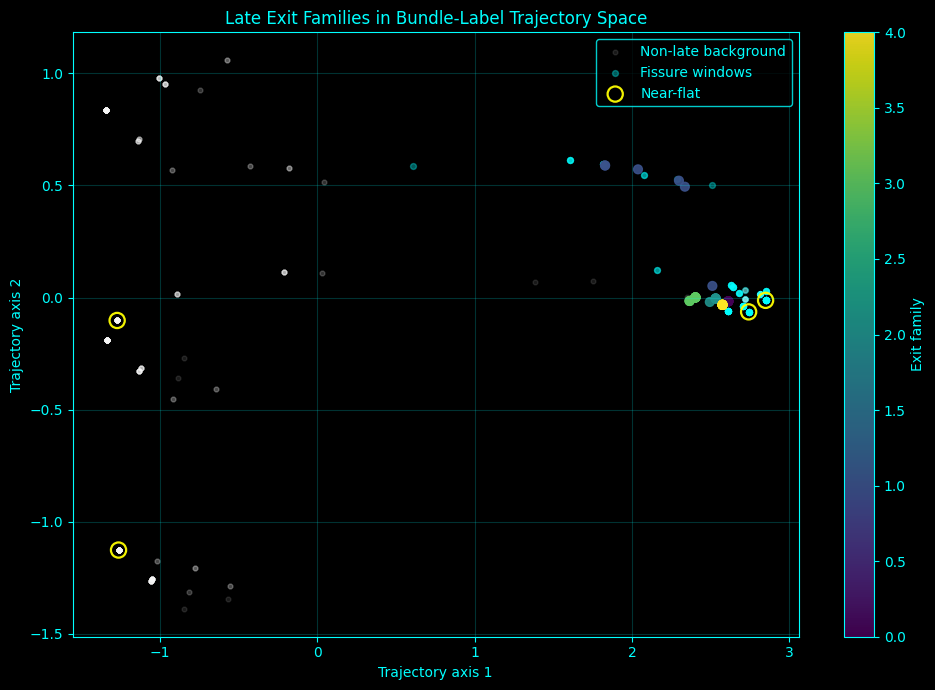

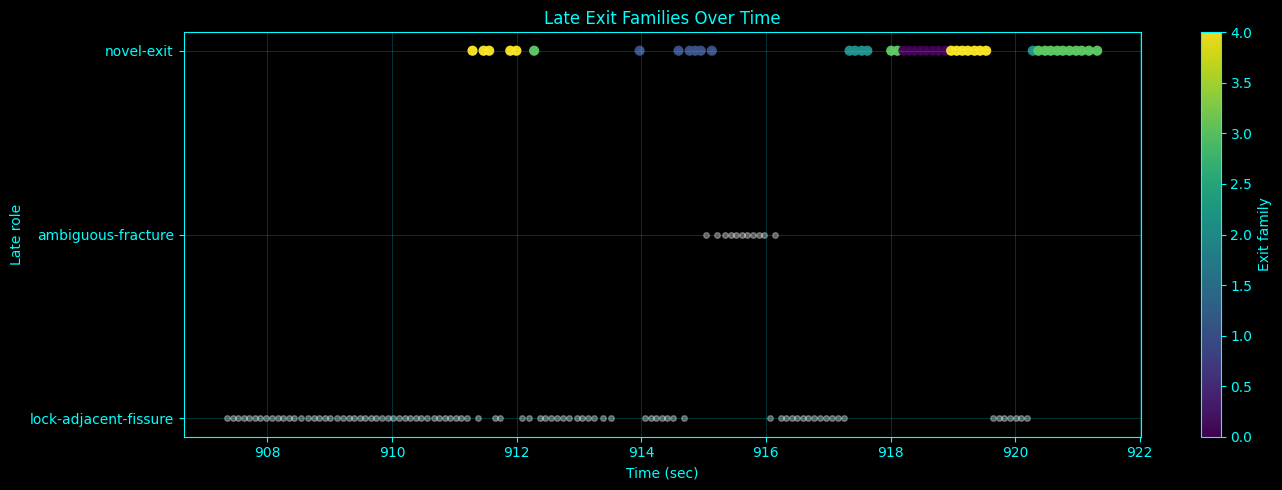

/tmp/ipykernel_639765/1270755338.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(f) for f in fams])


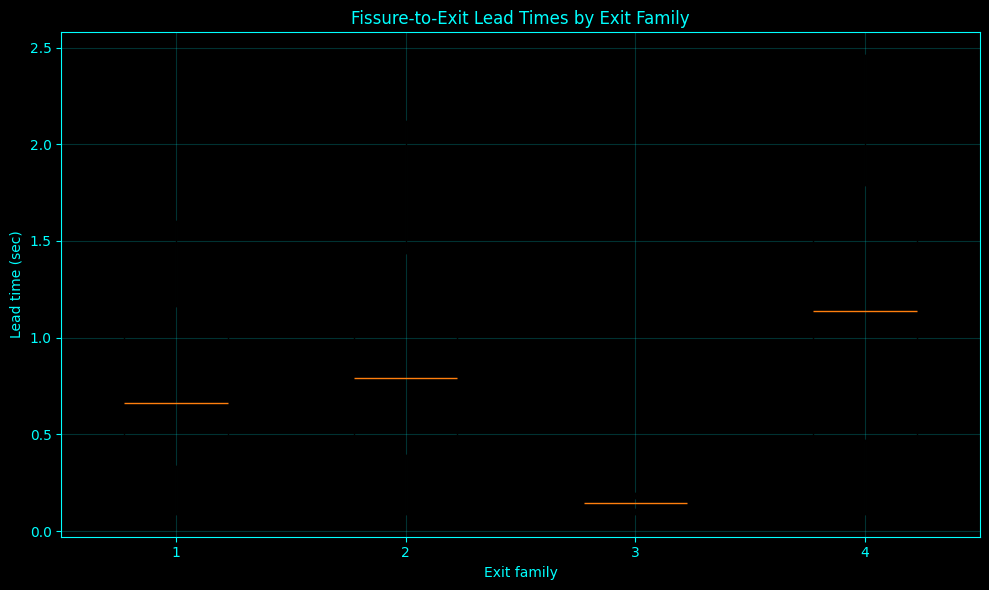

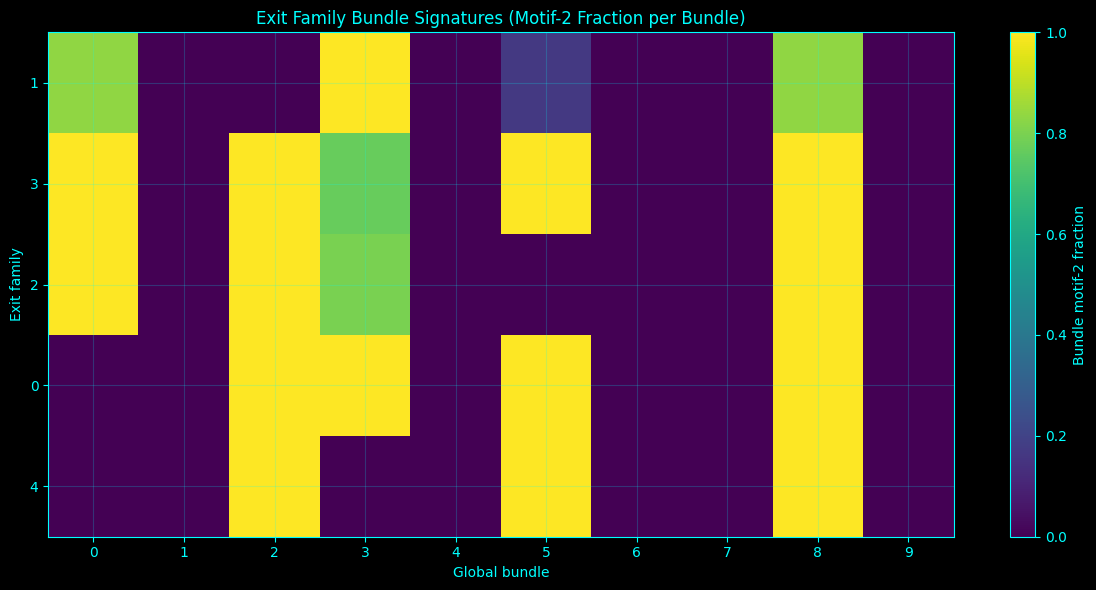

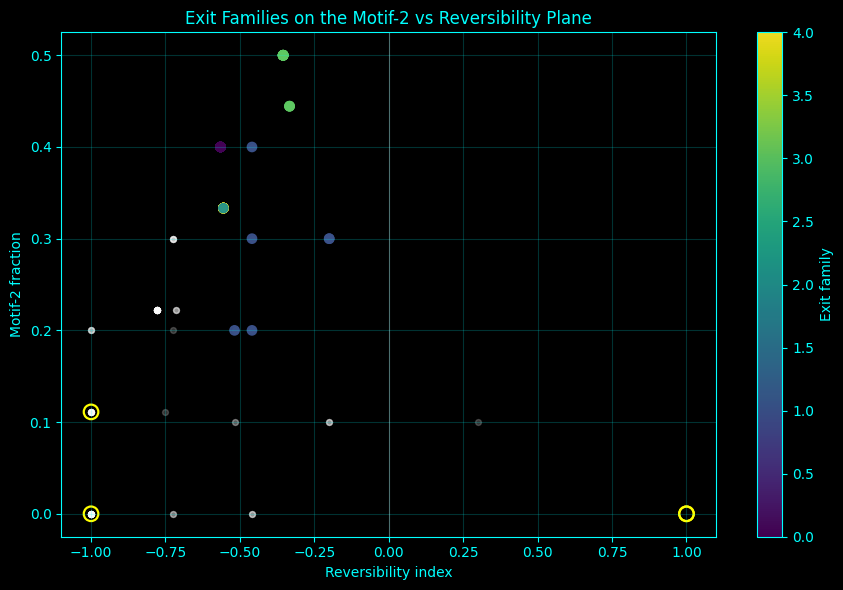


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exit_family_atlas_v1/late_exit_family_per_window.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/exit_family_atlas_v1/fissure_to_exit_family_links.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/exit_family_atlas_v1/exit_family_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/exit_family_atlas_v1/near_flat_exit_family_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/exit_family_atlas_v1/exit_family_atlas_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/exit_family_atlas_v1/plots

Chosen k for exit families: 5

Exit family summary:
 exit_family  n_windows  start_time_sec  end_time_sec  duration_sec  mean_motif2_fraction  mean_reversibility_index  mean_novelty_to_both  mean_fracture_score  mean_seed2_count  precursor_count  precursor_mean_lead_sec  bundle_0_motif1_frac  bundle_0_motif2_frac  bundle_0_motif3_frac  bundle_0_motif4_frac  bund

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2
from scipy.spatial.distance import cdist

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

drift_dir = os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1")
wave_dir = os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1")
fracture_dir = os.path.join(base_dir, "results", "lock_fracture_atlas_v1")
hyst_dir = os.path.join(base_dir, "results", "semantic_hysteresis_atlas_v1")

window_csv = os.path.join(hyst_dir, "window_hysteresis_metrics.csv")
episode_csv = os.path.join(hyst_dir, "late_hysteresis_episodes.csv")
near_flat_csv = os.path.join(hyst_dir, "near_flat_hysteresis_context.csv")
time_csv = os.path.join(fracture_dir, "time_resolved_fracture_pressure.csv")

out_dir = os.path.join(base_dir, "results", "exit_family_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# family discovery
smooth_window = 11
max_k = 5
k_restarts = 12
precursor_max_lead_sec = 2.5
precursor_roles = {"lock-adjacent-fissure", "ambiguous-fracture"}

ACCENT = "cyan"
BG = "black"
eps = 1e-12
rng_seed = 42

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def finite_quantile(x, q, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return default
    return float(np.quantile(x, q))

def rolling_mode_int(x, window):
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan)
    half = window // 2
    for i in range(len(x)):
        a = max(0, i - half)
        b = min(len(x), i + half + 1)
        vals = x[a:b]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        vals = vals.astype(int)
        uniq, counts = np.unique(vals, return_counts=True)
        out[i] = uniq[np.argmax(counts)]
    return out

def discover_dom_cols(cols):
    dom = {}
    loose = {}

    pat_dom = re.compile(r"^bundle_(\d+)_dom_motif$")
    pat_loose = re.compile(r"^bundle_(\d+)$")

    for c in cols:
        m = pat_dom.match(c)
        if m:
            dom[int(m.group(1))] = c
            continue
        m = pat_loose.match(c)
        if m:
            loose[int(m.group(1))] = c

    if len(dom):
        return dict(sorted(dom.items())), "dom"
    if len(loose):
        return dict(sorted(loose.items())), "loose"
    return {}, None

def find_bundle_timeline_csv(search_roots):
    candidates = []

    for root in search_roots:
        if not os.path.exists(root):
            continue

        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if not fn.lower().endswith(".csv"):
                    continue

                path = os.path.join(dirpath, fn)
                try:
                    head = pd.read_csv(path, nrows=2)
                except Exception:
                    continue

                dom_cols, mode = discover_dom_cols(head.columns)
                if len(dom_cols) == 0:
                    continue

                score = 0
                name = fn.lower()
                if "bundle" in name:
                    score += 2
                if "motif" in name:
                    score += 2
                if "dominant" in name:
                    score += 2
                if "time" in name:
                    score += 1
                if "center_time_sec" in head.columns:
                    score += 3
                if "time_sec" in head.columns:
                    score += 2

                candidates.append((score, path))

    if len(candidates) == 0:
        raise FileNotFoundError("No bundle dominant-motif timeline CSV found.")

    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][1]

def onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4)):
    label_matrix = np.asarray(label_matrix, dtype=float)
    n, b = label_matrix.shape
    out = np.zeros((n, b * len(motif_values)), dtype=float)

    for j in range(b):
        for k, mv in enumerate(motif_values):
            out[:, j * len(motif_values) + k] = (label_matrix[:, j] == mv).astype(float)

    return out

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def silhouette_score_manual(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels, dtype=int)

    uniq = np.unique(labels)
    if len(uniq) < 2:
        return -1.0

    D = cdist(X, X)
    s_vals = []

    for i in range(len(X)):
        own = labels == labels[i]
        other_groups = [labels == u for u in uniq if u != labels[i]]

        if np.sum(own) <= 1:
            s_vals.append(0.0)
            continue

        a = np.mean(D[i, own & (np.arange(len(X)) != i)])

        b = np.inf
        for og in other_groups:
            if np.sum(og) == 0:
                continue
            b = min(b, np.mean(D[i, og]))

        s = (b - a) / max(a, b, eps)
        s_vals.append(s)

    return float(np.mean(s_vals))

def choose_k_by_silhouette(X, max_k=5, restarts=10, rng_seed=42):
    n = len(X)
    if n < 6:
        return 1, np.zeros(n, dtype=int), np.mean(X, axis=0, keepdims=True)

    rng = np.random.default_rng(rng_seed)
    best_global = None

    k_hi = min(max_k, max(2, n // 6))
    k_hi = max(2, k_hi)

    for k in range(2, k_hi + 1):
        best_k = None

        for r in range(restarts):
            seed = int(rng.integers(0, 1_000_000))
            np.random.seed(seed)
            try:
                centroids, labels = kmeans2(X, k, minit="points", iter=40)
            except Exception:
                continue

            # reject collapsed solutions
            if len(np.unique(labels)) < 2:
                continue

            sil = silhouette_score_manual(X, labels)

            score = (sil, -k)  # prefer larger silhouette, smaller k if tied

            if best_k is None or score > best_k["score"]:
                best_k = {
                    "k": k,
                    "labels": labels.copy(),
                    "centroids": centroids.copy(),
                    "score": score,
                    "silhouette": sil,
                }

        if best_k is not None:
            if best_global is None or best_k["score"] > best_global["score"]:
                best_global = best_k

    if best_global is None:
        return 1, np.zeros(n, dtype=int), np.mean(X, axis=0, keepdims=True)

    return best_global["k"], best_global["labels"], best_global["centroids"]

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
hyst_df = pd.read_csv(window_csv).sort_values("center_time_sec").reset_index(drop=True)
time_df = pd.read_csv(time_csv).sort_values("center_time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

timeline_csv = find_bundle_timeline_csv([drift_dir, wave_dir, fracture_dir])
print(f"Using bundle timeline CSV: {timeline_csv}")

timeline_df = pd.read_csv(timeline_csv)
if "center_time_sec" not in timeline_df.columns:
    if "time_sec" in timeline_df.columns:
        timeline_df = timeline_df.rename(columns={"time_sec": "center_time_sec"})
    else:
        raise ValueError("Timeline CSV needs center_time_sec or time_sec.")

timeline_df = timeline_df.sort_values("center_time_sec").reset_index(drop=True)

# align time_df and hyst_df to timeline grid if needed
if not np.array_equal(np.round(hyst_df["center_time_sec"].values, 6), np.round(timeline_df["center_time_sec"].values, 6)):
    hyst_df = pd.merge_asof(
        timeline_df[["center_time_sec"]],
        hyst_df.sort_values("center_time_sec"),
        on="center_time_sec",
        direction="nearest"
    )

if not np.array_equal(np.round(time_df["center_time_sec"].values, 6), np.round(timeline_df["center_time_sec"].values, 6)):
    time_df = pd.merge_asof(
        timeline_df[["center_time_sec"]],
        time_df.sort_values("center_time_sec"),
        on="center_time_sec",
        direction="nearest"
    )

time_sec = timeline_df["center_time_sec"].values

dom_cols, mode = discover_dom_cols(timeline_df.columns)
if len(dom_cols) == 0:
    raise ValueError("No bundle dominant-motif columns found in timeline CSV.")

bundle_ids = sorted(dom_cols.keys())

# -------------------------------------------------------
# SMOOTH LABEL MATRIX
# -------------------------------------------------------
smooth_df = pd.DataFrame({"center_time_sec": time_sec})

for b in bundle_ids:
    x = timeline_df[dom_cols[b]].values.astype(float)
    smooth_df[f"bundle_{b}"] = rolling_mode_int(x, smooth_window)

label_matrix = np.column_stack([smooth_df[f"bundle_{b}"].values for b in bundle_ids])
X_all = onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4))

traj_xy, traj_eigs, traj_vecs = pca_2d(X_all)

traj_df = pd.DataFrame({
    "center_time_sec": time_sec,
    "traj_x": traj_xy[:, 0],
    "traj_y": traj_xy[:, 1],
})

# -------------------------------------------------------
# LATE WINDOW / EXIT FAMILY DISCOVERY
# -------------------------------------------------------
late_roles = {"novel-exit", "lock-adjacent-fissure", "ambiguous-fracture"}
late_mask = hyst_df["hysteresis_role"].isin(late_roles).values
novel_mask = hyst_df["hysteresis_role"].values == "novel-exit"
fissure_mask = hyst_df["hysteresis_role"].isin(precursor_roles).values

novel_idx = np.where(novel_mask)[0]
fissure_idx = np.where(fissure_mask)[0]

X_novel = X_all[novel_idx]

k_family, novel_labels, novel_centroids = choose_k_by_silhouette(
    X_novel,
    max_k=max_k,
    restarts=k_restarts,
    rng_seed=rng_seed
)

family_id = np.full(len(hyst_df), -1, dtype=int)
if len(novel_idx) > 0:
    family_id[novel_idx] = novel_labels

hyst_df["exit_family"] = family_id
traj_df["exit_family"] = family_id

# -------------------------------------------------------
# PRECURSOR -> EXIT FAMILY ATTRIBUTION
# -------------------------------------------------------
precursor_rows = []

for i in fissure_idx:
    t0 = time_sec[i]

    future_novel = novel_idx[(time_sec[novel_idx] > t0) & ((time_sec[novel_idx] - t0) <= precursor_max_lead_sec)]
    if len(future_novel) == 0:
        precursor_rows.append({
            "fissure_time_sec": float(t0),
            "target_exit_time_sec": np.nan,
            "lead_time_sec": np.nan,
            "target_family": -1,
            "fissure_role": hyst_df.loc[i, "hysteresis_role"],
            "fissure_fracture_score": hyst_df.loc[i, "fracture_score"],
            "fissure_motif2_fraction": hyst_df.loc[i, "motif2_fraction"],
        })
        continue

    j = future_novel[0]
    precursor_rows.append({
        "fissure_time_sec": float(t0),
        "target_exit_time_sec": float(time_sec[j]),
        "lead_time_sec": float(time_sec[j] - t0),
        "target_family": int(family_id[j]),
        "fissure_role": hyst_df.loc[i, "hysteresis_role"],
        "fissure_fracture_score": hyst_df.loc[i, "fracture_score"],
        "fissure_motif2_fraction": hyst_df.loc[i, "motif2_fraction"],
    })

precursor_df = pd.DataFrame(precursor_rows)

# -------------------------------------------------------
# FAMILY SIGNATURES
# -------------------------------------------------------
family_rows = []

for fam in sorted([f for f in np.unique(family_id) if f >= 0]):
    idx = np.where(family_id == fam)[0]
    sub = hyst_df.iloc[idx]

    # precursor context
    sub_prec = precursor_df[precursor_df["target_family"] == fam].copy()

    # bundle-wise motif frequencies in this family
    bundle_sig = {}
    for b in bundle_ids:
        vals = label_matrix[idx, bundle_ids.index(b)]
        bundle_sig[f"bundle_{b}_motif1_frac"] = float(np.mean(vals == 1))
        bundle_sig[f"bundle_{b}_motif2_frac"] = float(np.mean(vals == 2))
        bundle_sig[f"bundle_{b}_motif3_frac"] = float(np.mean(vals == 3))
        bundle_sig[f"bundle_{b}_motif4_frac"] = float(np.mean(vals == 4))

    family_rows.append({
        "exit_family": int(fam),
        "n_windows": int(len(idx)),
        "start_time_sec": float(sub["center_time_sec"].min()),
        "end_time_sec": float(sub["center_time_sec"].max()),
        "duration_sec": float(sub["center_time_sec"].max() - sub["center_time_sec"].min()),
        "mean_motif2_fraction": safe_mean(sub["motif2_fraction"].values),
        "mean_reversibility_index": safe_mean(sub["reversibility_index"].values),
        "mean_novelty_to_both": safe_mean(sub["novelty_to_both"].values),
        "mean_fracture_score": safe_mean(sub["fracture_score"].values),
        "mean_seed2_count": safe_mean(sub["motif2_seed_count"].values),
        "precursor_count": int(len(sub_prec)),
        "precursor_mean_lead_sec": safe_mean(sub_prec["lead_time_sec"].values) if len(sub_prec) else np.nan,
        **bundle_sig
    })

family_df = pd.DataFrame(family_rows).sort_values(
    ["mean_fracture_score", "mean_motif2_fraction"],
    ascending=False
).reset_index(drop=True)

# -------------------------------------------------------
# FAMILY-LEVEL BUNDLE SIGNATURE MATRIX
# -------------------------------------------------------
sig_cols_m2 = [f"bundle_{b}_motif2_frac" for b in bundle_ids]
family_sig_m2 = family_df[sig_cols_m2].values if len(family_df) else np.zeros((0, len(bundle_ids)))

# -------------------------------------------------------
# NEAR-FLAT CONTEXT
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(time_sec - t0)))
        hr = hyst_df.iloc[idx]

        near_flat_rows.append({
            "time_sec": t0,
            "nearest_time_sec": float(time_sec[idx]),
            "stage_label": row["stage_label"] if "stage_label" in row.index else "NA",
            "hysteresis_role": hr["hysteresis_role"],
            "exit_family": int(hr["exit_family"]),
            "motif2_fraction": float(hr["motif2_fraction"]),
            "reversibility_index": float(hr["reversibility_index"]),
            "novelty_to_both": float(hr["novelty_to_both"]),
            "fracture_score": float(hr["fracture_score"]),
            "traj_x": float(traj_df.iloc[idx]["traj_x"]),
            "traj_y": float(traj_df.iloc[idx]["traj_y"]),
        })

near_flat_exit_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
window_out_csv = os.path.join(out_dir, "late_exit_family_per_window.csv")
precursor_csv = os.path.join(out_dir, "fissure_to_exit_family_links.csv")
family_csv = os.path.join(out_dir, "exit_family_summary.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_exit_family_context.csv")
summary_txt = os.path.join(out_dir, "exit_family_atlas_summary.txt")

hyst_df.to_csv(window_out_csv, index=False)
precursor_df.to_csv(precursor_csv, index=False)
family_df.to_csv(family_csv, index=False)
near_flat_exit_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Exit Family Atlas Summary\n")
    f.write("========================\n\n")
    f.write(f"timeline_csv = {timeline_csv}\n")
    f.write(f"smooth_window = {smooth_window}\n")
    f.write(f"precursor_max_lead_sec = {precursor_max_lead_sec}\n")
    f.write(f"chosen_k_exit_families = {k_family}\n\n")

    f.write("Exit family summary:\n")
    if len(family_df):
        f.write(family_df.to_string(index=False))
    else:
        f.write("No novel-exit windows detected.")
    f.write("\n\n")

    f.write("Precursor targeting counts:\n")
    if len(precursor_df):
        f.write(precursor_df["target_family"].value_counts(dropna=False).to_string())
    else:
        f.write("No precursor rows.")
    f.write("\n\n")

    if len(near_flat_exit_df):
        f.write("Near-flat exit-family context:\n")
        f.write(near_flat_exit_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Trajectory map with exit families
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

# non-late background
ax.scatter(
    traj_df.loc[~late_mask, "traj_x"].values,
    traj_df.loc[~late_mask, "traj_y"].values,
    s=12,
    alpha=0.10,
    color="white",
    label="Non-late background"
)

# fissures
ax.scatter(
    traj_df.loc[fissure_mask, "traj_x"].values,
    traj_df.loc[fissure_mask, "traj_y"].values,
    s=18,
    alpha=0.35,
    color=ACCENT,
    label="Fissure windows"
)

# novel exits by family
if len(novel_idx) > 0:
    sc = ax.scatter(
        traj_df.loc[novel_mask, "traj_x"].values,
        traj_df.loc[novel_mask, "traj_y"].values,
        c=hyst_df.loc[novel_mask, "exit_family"].values,
        s=40,
        alpha=0.90
    )
    cbar = plt.colorbar(sc, ax=ax)
    style_cbar(cbar, "Exit family")
else:
    sc = None

if len(near_flat_exit_df):
    ax.scatter(
        near_flat_exit_df["traj_x"].values,
        near_flat_exit_df["traj_y"].values,
        s=120,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95,
        label="Near-flat"
    )

ax.set_title("Late Exit Families in Bundle-Label Trajectory Space")
ax.set_xlabel("Trajectory axis 1")
ax.set_ylabel("Trajectory axis 2")
ax.legend()

plot1_path = os.path.join(plots_dir, "exit_family_trajectory_map.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Exit family timeline
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

role_to_y = {"lock-adjacent-fissure": 0, "ambiguous-fracture": 1, "novel-exit": 2}

ax.scatter(
    hyst_df.loc[late_mask, "center_time_sec"].values,
    [role_to_y[r] for r in hyst_df.loc[late_mask, "hysteresis_role"].values],
    s=16,
    alpha=0.35,
    color="white",
    label="Late windows"
)

if len(novel_idx) > 0:
    sc = ax.scatter(
        hyst_df.loc[novel_mask, "center_time_sec"].values,
        [role_to_y["novel-exit"]] * np.sum(novel_mask),
        c=hyst_df.loc[novel_mask, "exit_family"].values,
        s=40,
        alpha=0.95
    )
    cbar = plt.colorbar(sc, ax=ax)
    style_cbar(cbar, "Exit family")

ax.set_yticks(list(role_to_y.values()))
ax.set_yticklabels(list(role_to_y.keys()))
ax.set_title("Late Exit Families Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Late role")

plot2_path = os.path.join(plots_dir, "exit_family_timeline.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Precursor lead-times by family
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

if len(precursor_df):
    good_prec = precursor_df[np.isfinite(precursor_df["lead_time_sec"]) & (precursor_df["target_family"] >= 0)]
    if len(good_prec):
        fams = sorted(good_prec["target_family"].unique())
        data = [good_prec.loc[good_prec["target_family"] == f, "lead_time_sec"].values for f in fams]
        ax.boxplot(data, labels=[str(f) for f in fams])
        ax.set_title("Fissure-to-Exit Lead Times by Exit Family")
        ax.set_xlabel("Exit family")
        ax.set_ylabel("Lead time (sec)")
    else:
        ax.text(0.5, 0.5, "No precursor links detected", ha="center", va="center", transform=ax.transAxes)

plot3_path = os.path.join(plots_dir, "precursor_lead_times_by_family.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Exit family bundle motif-2 signature heatmap
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

if len(family_df):
    im = ax.imshow(family_sig_m2, aspect="auto", interpolation="nearest")
    ax.set_title("Exit Family Bundle Signatures (Motif-2 Fraction per Bundle)")
    ax.set_xlabel("Global bundle")
    ax.set_ylabel("Exit family")
    ax.set_xticks(np.arange(len(bundle_ids)))
    ax.set_xticklabels(bundle_ids)
    ax.set_yticks(np.arange(len(family_df)))
    ax.set_yticklabels(family_df["exit_family"].values)

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Bundle motif-2 fraction")
else:
    ax.text(0.5, 0.5, "No exit families detected", ha="center", va="center", transform=ax.transAxes)

plot4_path = os.path.join(plots_dir, "exit_family_bundle_signature_heatmap.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Motif-2 fraction vs reversibility, colored by exit family
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

# all late windows background
ax.scatter(
    hyst_df.loc[late_mask, "reversibility_index"].values,
    hyst_df.loc[late_mask, "motif2_fraction"].values,
    s=18,
    alpha=0.20,
    color="white"
)

if len(novel_idx) > 0:
    sc = ax.scatter(
        hyst_df.loc[novel_mask, "reversibility_index"].values,
        hyst_df.loc[novel_mask, "motif2_fraction"].values,
        c=hyst_df.loc[novel_mask, "exit_family"].values,
        s=45,
        alpha=0.95
    )
    cbar = plt.colorbar(sc, ax=ax)
    style_cbar(cbar, "Exit family")

if len(near_flat_exit_df):
    ax.scatter(
        near_flat_exit_df["reversibility_index"].values,
        near_flat_exit_df["motif2_fraction"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6
    )

ax.axvline(0.0, color="white", alpha=0.30, linewidth=0.8)
ax.set_title("Exit Families on the Motif-2 vs Reversibility Plane")
ax.set_xlabel("Reversibility index")
ax.set_ylabel("Motif-2 fraction")

plot5_path = os.path.join(plots_dir, "exit_family_motif2_vs_reversibility.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nSaved:")
print(window_out_csv)
print(precursor_csv)
print(family_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print(f"\nChosen k for exit families: {k_family}")

print("\nExit family summary:")
if len(family_df):
    print(family_df.to_string(index=False))
else:
    print("No novel-exit windows detected.")

print("\nPrecursor targeting counts:")
if len(precursor_df):
    print(precursor_df["target_family"].value_counts(dropna=False).to_string())
else:
    print("No precursor rows.")

if len(near_flat_exit_df):
    print("\nNear-flat exit-family context:")
    print(near_flat_exit_df.to_string(index=False))

Using bundle timeline CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_semantic_drift_atlas_v1/bundle_dominant_motif_over_time.csv


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


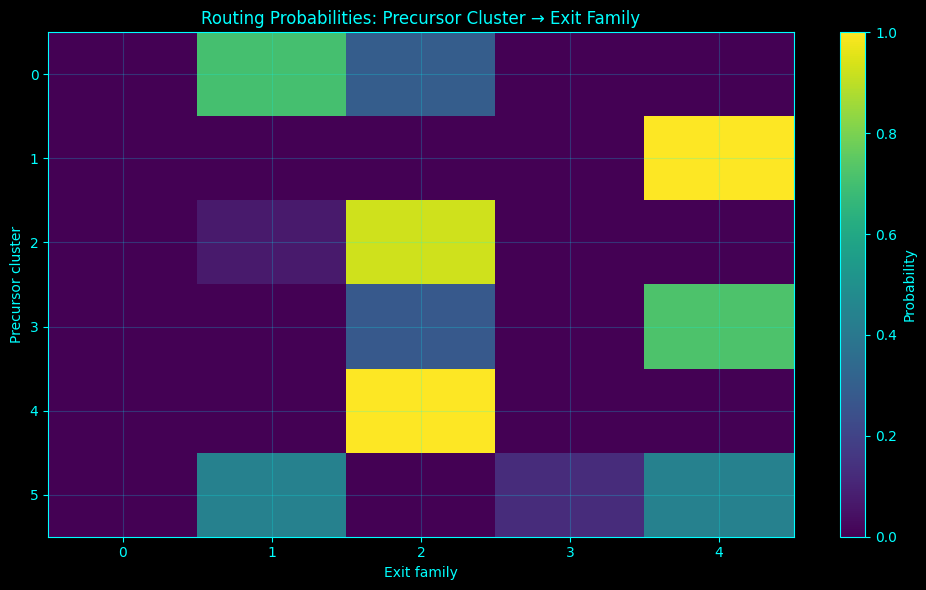

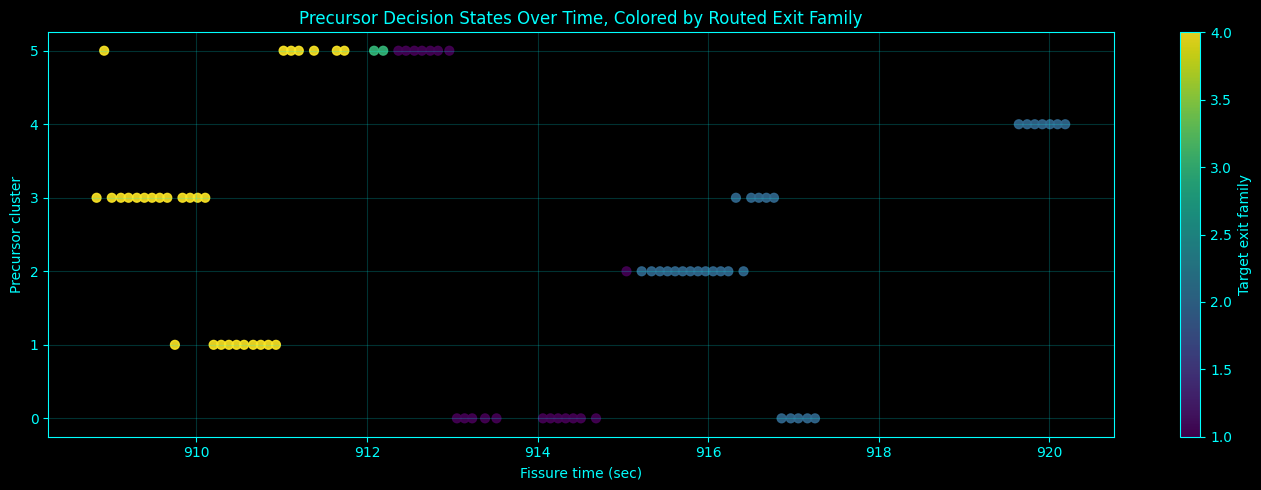

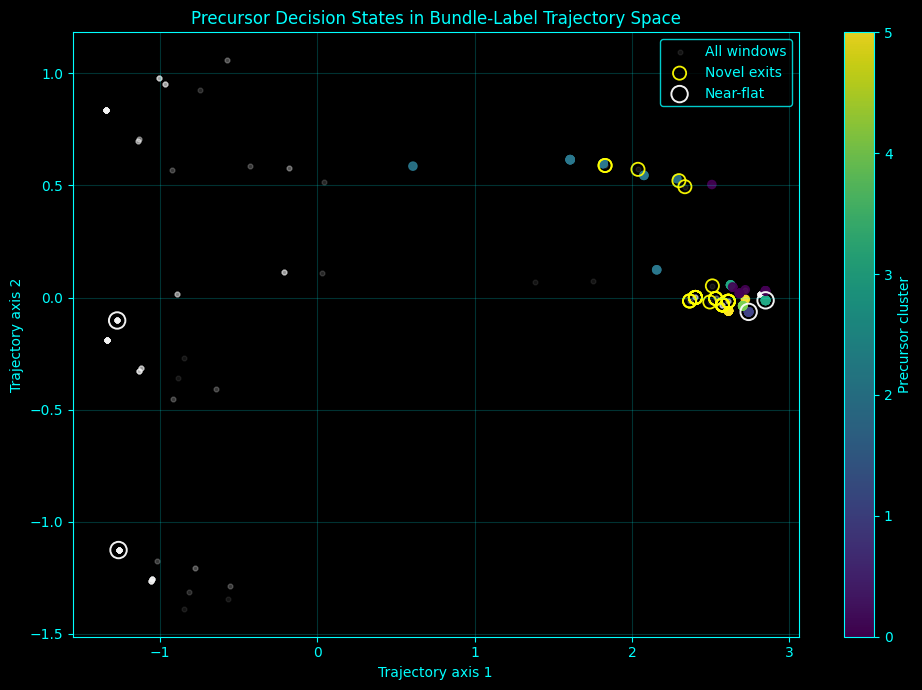

/tmp/ipykernel_27859/3981431048.py:670: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


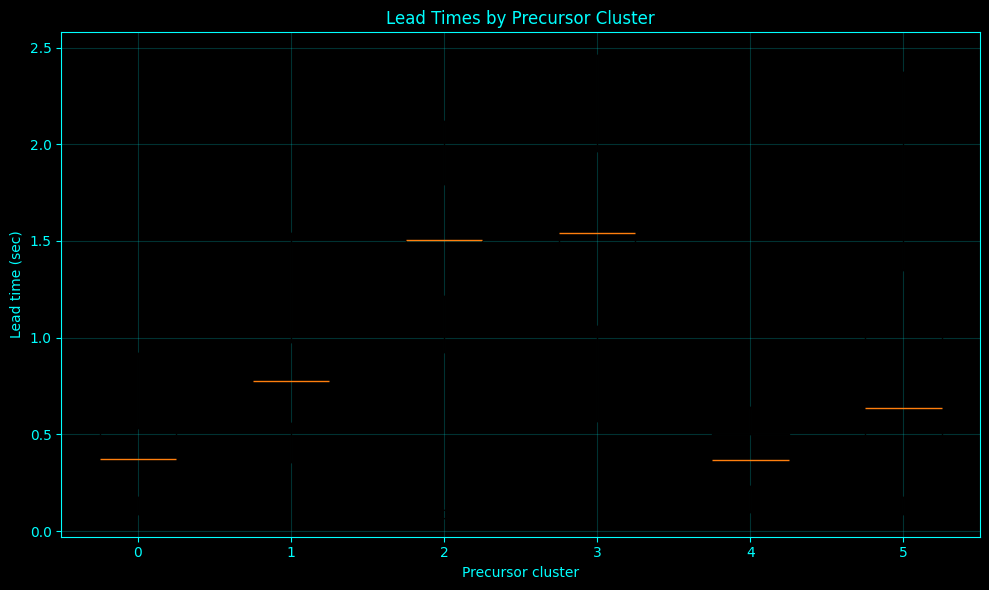

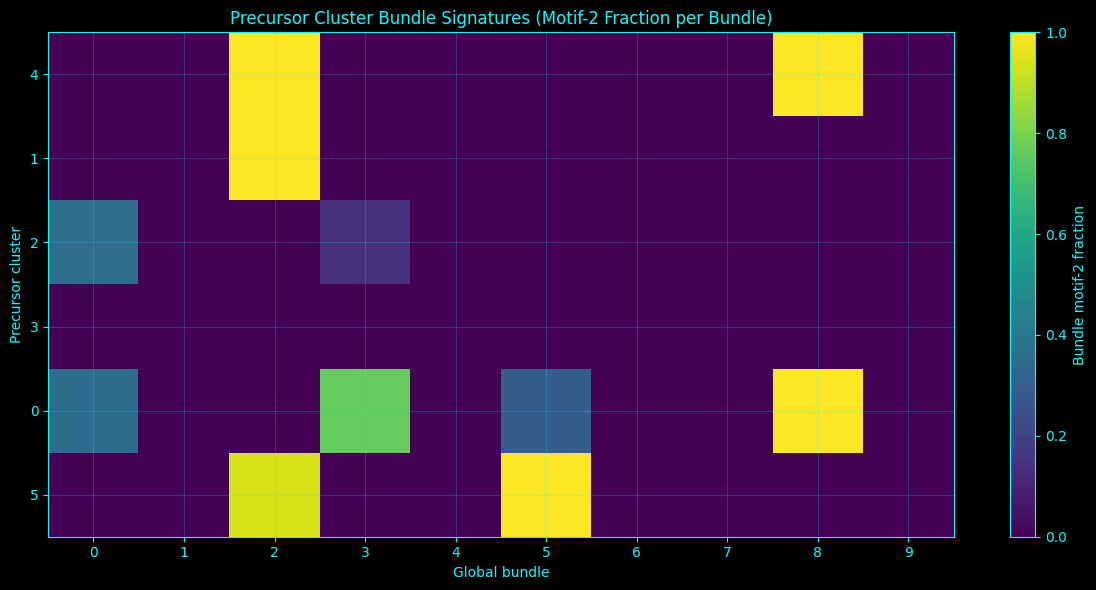


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/fissure_router_atlas_v1/precursor_cluster_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/fissure_router_atlas_v1/routing_probability_matrix.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/fissure_router_atlas_v1/labeled_precursor_windows.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/fissure_router_atlas_v1/near_flat_router_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/fissure_router_atlas_v1/fissure_router_atlas_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/fissure_router_atlas_v1/plots

Chosen k for precursor clusters: 6

Precursor cluster summary:
 precursor_cluster  n_windows  start_time_sec  end_time_sec  duration_sec  dominant_exit_family  dominant_family_prob  routing_entropy  mean_lead_time_sec  median_lead_time_sec  mean_fissure_fracture_score  mean_fissure_motif2_fraction  bundle_0_motif2_frac  bundle_1_motif2_frac  bu

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2
from scipy.spatial.distance import cdist

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

drift_dir = os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1")
exit_dir = os.path.join(base_dir, "results", "exit_family_atlas_v1")

precursor_csv = os.path.join(exit_dir, "fissure_to_exit_family_links.csv")
family_csv = os.path.join(exit_dir, "exit_family_summary.csv")
window_csv = os.path.join(exit_dir, "late_exit_family_per_window.csv")
near_flat_csv = os.path.join(exit_dir, "near_flat_exit_family_context.csv")

out_dir = os.path.join(base_dir, "results", "fissure_router_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# clustering / routing controls
smooth_window = 11
max_k = 6
k_restarts = 16
rng_seed = 42
min_cluster_size = 3

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def finite_quantile(x, q, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return default
    return float(np.quantile(x, q))

def rolling_mode_int(x, window):
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan)
    half = window // 2
    for i in range(len(x)):
        a = max(0, i - half)
        b = min(len(x), i + half + 1)
        vals = x[a:b]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        vals = vals.astype(int)
        uniq, counts = np.unique(vals, return_counts=True)
        out[i] = uniq[np.argmax(counts)]
    return out

def discover_dom_cols(cols):
    dom = {}
    loose = {}

    pat_dom = re.compile(r"^bundle_(\d+)_dom_motif$")
    pat_loose = re.compile(r"^bundle_(\d+)$")

    for c in cols:
        m = pat_dom.match(c)
        if m:
            dom[int(m.group(1))] = c
            continue
        m = pat_loose.match(c)
        if m:
            loose[int(m.group(1))] = c

    if len(dom):
        return dict(sorted(dom.items())), "dom"
    if len(loose):
        return dict(sorted(loose.items())), "loose"
    return {}, None

def find_bundle_timeline_csv(search_roots):
    candidates = []

    for root in search_roots:
        if not os.path.exists(root):
            continue

        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if not fn.lower().endswith(".csv"):
                    continue

                path = os.path.join(dirpath, fn)
                try:
                    head = pd.read_csv(path, nrows=2)
                except Exception:
                    continue

                dom_cols, _ = discover_dom_cols(head.columns)
                if len(dom_cols) == 0:
                    continue

                score = 0
                name = fn.lower()

                if "bundle" in name:
                    score += 2
                if "motif" in name:
                    score += 2
                if "dominant" in name:
                    score += 2
                if "time" in name:
                    score += 1
                if "center_time_sec" in head.columns:
                    score += 3
                if "time_sec" in head.columns:
                    score += 2

                candidates.append((score, path))

    if len(candidates) == 0:
        raise FileNotFoundError("No bundle dominant-motif timeline CSV found.")

    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][1]

def onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4)):
    label_matrix = np.asarray(label_matrix, dtype=float)
    n, b = label_matrix.shape
    out = np.zeros((n, b * len(motif_values)), dtype=float)

    for j in range(b):
        for k, mv in enumerate(motif_values):
            out[:, j * len(motif_values) + k] = (label_matrix[:, j] == mv).astype(float)

    return out

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def silhouette_score_manual(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels, dtype=int)
    uniq = np.unique(labels)

    if len(uniq) < 2:
        return -1.0

    D = cdist(X, X)
    s_vals = []

    for i in range(len(X)):
        own = labels == labels[i]
        others = [labels == u for u in uniq if u != labels[i]]

        if np.sum(own) <= 1:
            s_vals.append(0.0)
            continue

        a = np.mean(D[i, own & (np.arange(len(X)) != i)])

        b = np.inf
        for og in others:
            if np.sum(og) == 0:
                continue
            b = min(b, np.mean(D[i, og]))

        s = (b - a) / max(a, b, eps)
        s_vals.append(s)

    return float(np.mean(s_vals))

def choose_k_by_silhouette(X, max_k=6, restarts=10, rng_seed=42):
    n = len(X)
    if n < 6:
        return 1, np.zeros(n, dtype=int), np.mean(X, axis=0, keepdims=True)

    rng = np.random.default_rng(rng_seed)
    best_global = None

    k_hi = min(max_k, max(2, n // 5))
    k_hi = max(2, k_hi)

    for k in range(2, k_hi + 1):
        best_k = None

        for _ in range(restarts):
            seed = int(rng.integers(0, 1_000_000))
            np.random.seed(seed)

            try:
                centroids, labels = kmeans2(X, k, minit="points", iter=50)
            except Exception:
                continue

            if len(np.unique(labels)) < 2:
                continue

            sil = silhouette_score_manual(X, labels)
            score = (sil, -k)

            if best_k is None or score > best_k["score"]:
                best_k = {
                    "k": k,
                    "labels": labels.copy(),
                    "centroids": centroids.copy(),
                    "score": score,
                    "silhouette": sil,
                }

        if best_k is not None:
            if best_global is None or best_k["score"] > best_global["score"]:
                best_global = best_k

    if best_global is None:
        return 1, np.zeros(n, dtype=int), np.mean(X, axis=0, keepdims=True)

    return best_global["k"], best_global["labels"], best_global["centroids"]

def normalized_entropy(probs):
    probs = np.asarray(probs, dtype=float)
    probs = probs[probs > 0]
    if len(probs) <= 1:
        return 0.0
    H = -np.sum(probs * np.log(probs + eps))
    return float(H / (np.log(len(probs)) + eps))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
precursor_df = pd.read_csv(precursor_csv)
family_df = pd.read_csv(family_csv)
window_df = pd.read_csv(window_csv).sort_values("center_time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

timeline_csv = find_bundle_timeline_csv([drift_dir, exit_dir])
print(f"Using bundle timeline CSV: {timeline_csv}")

timeline_df = pd.read_csv(timeline_csv)
if "center_time_sec" not in timeline_df.columns:
    if "time_sec" in timeline_df.columns:
        timeline_df = timeline_df.rename(columns={"time_sec": "center_time_sec"})
    else:
        raise ValueError("Timeline CSV needs center_time_sec or time_sec.")

timeline_df = timeline_df.sort_values("center_time_sec").reset_index(drop=True)
time_sec = timeline_df["center_time_sec"].values

dom_cols, _ = discover_dom_cols(timeline_df.columns)
if len(dom_cols) == 0:
    raise ValueError("No bundle dominant-motif columns found in timeline CSV.")

bundle_ids = sorted(dom_cols.keys())

# -------------------------------------------------------
# SMOOTH LABEL MATRIX + TRAJECTORY
# -------------------------------------------------------
smooth_df = pd.DataFrame({"center_time_sec": time_sec})
for b in bundle_ids:
    x = timeline_df[dom_cols[b]].values.astype(float)
    smooth_df[f"bundle_{b}"] = rolling_mode_int(x, smooth_window)

label_matrix = np.column_stack([smooth_df[f"bundle_{b}"].values for b in bundle_ids])
X_all = onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4))

traj_xy, traj_eigs, traj_vecs = pca_2d(X_all)
traj_df = pd.DataFrame({
    "center_time_sec": time_sec,
    "traj_x": traj_xy[:, 0],
    "traj_y": traj_xy[:, 1],
})

# -------------------------------------------------------
# PRECURSOR WINDOWS THAT ACTUALLY TARGET AN EXIT FAMILY
# -------------------------------------------------------
good_prec = precursor_df[
    np.isfinite(precursor_df["lead_time_sec"].values) &
    (precursor_df["target_family"].values >= 0)
].copy()

if len(good_prec) == 0:
    raise ValueError("No valid precursor-to-exit links found.")

# map precursor times to timeline indices
prec_idx = []
for t in good_prec["fissure_time_sec"].values:
    idx = int(np.argmin(np.abs(time_sec - t)))
    prec_idx.append(idx)
prec_idx = np.asarray(prec_idx, dtype=int)

good_prec["timeline_index"] = prec_idx

# use bundle-label onehot state at precursor times
X_prec = X_all[prec_idx]

# -------------------------------------------------------
# CLUSTER PRECURSOR DECISION STATES
# -------------------------------------------------------
k_prec, prec_labels, prec_centroids = choose_k_by_silhouette(
    X_prec,
    max_k=max_k,
    restarts=k_restarts,
    rng_seed=rng_seed
)

good_prec["precursor_cluster"] = prec_labels

# collapse tiny clusters into nearest larger cluster if needed
cluster_sizes = good_prec["precursor_cluster"].value_counts().to_dict()
small_clusters = [c for c, n in cluster_sizes.items() if n < min_cluster_size]

if len(small_clusters) > 0 and k_prec > 1:
    centroids = {}
    for c in sorted(good_prec["precursor_cluster"].unique()):
        rows = good_prec["precursor_cluster"] == c
        centroids[c] = np.mean(X_prec[rows.values], axis=0)

    large_clusters = [c for c, n in cluster_sizes.items() if n >= min_cluster_size]

    new_labels = good_prec["precursor_cluster"].values.copy()
    for sc in small_clusters:
        rows_sc = np.where(good_prec["precursor_cluster"].values == sc)[0]
        if len(large_clusters) == 0:
            continue
        dists = []
        for lc in large_clusters:
            d = np.linalg.norm(centroids[sc] - centroids[lc])
            dists.append((d, lc))
        dists.sort()
        new_c = dists[0][1]
        new_labels[rows_sc] = new_c

    # relabel to consecutive ints
    uniq = sorted(np.unique(new_labels))
    remap = {u: i for i, u in enumerate(uniq)}
    good_prec["precursor_cluster"] = np.array([remap[x] for x in new_labels], dtype=int)
    k_prec = len(uniq)

# -------------------------------------------------------
# ROUTING MATRIX: precursor cluster -> exit family
# -------------------------------------------------------
exit_families = sorted([int(x) for x in family_df["exit_family"].unique()])
cluster_ids = sorted([int(x) for x in good_prec["precursor_cluster"].unique()])

route_count = np.zeros((len(cluster_ids), len(exit_families)), dtype=float)

for i, c in enumerate(cluster_ids):
    sub = good_prec[good_prec["precursor_cluster"] == c]
    vc = sub["target_family"].value_counts().to_dict()
    for j, f in enumerate(exit_families):
        route_count[i, j] = vc.get(f, 0)

route_prob = route_count / np.maximum(route_count.sum(axis=1, keepdims=True), 1.0)

# -------------------------------------------------------
# CLUSTER SUMMARIES
# -------------------------------------------------------
cluster_rows = []

for i, c in enumerate(cluster_ids):
    sub = good_prec[good_prec["precursor_cluster"] == c].copy()
    idx = sub["timeline_index"].values.astype(int)

    # bundle motif-2 signature at precursor stage
    sig = {}
    for b in bundle_ids:
        vals = label_matrix[idx, bundle_ids.index(b)]
        sig[f"bundle_{b}_motif2_frac"] = float(np.mean(vals == 2))

    # routing
    probs = route_prob[i]
    dom_family = exit_families[int(np.argmax(probs))]
    dom_prob = float(np.max(probs))
    ent = normalized_entropy(probs)

    cluster_rows.append({
        "precursor_cluster": int(c),
        "n_windows": int(len(sub)),
        "start_time_sec": float(sub["fissure_time_sec"].min()),
        "end_time_sec": float(sub["fissure_time_sec"].max()),
        "duration_sec": float(sub["fissure_time_sec"].max() - sub["fissure_time_sec"].min()),
        "dominant_exit_family": int(dom_family),
        "dominant_family_prob": dom_prob,
        "routing_entropy": ent,
        "mean_lead_time_sec": safe_mean(sub["lead_time_sec"].values),
        "median_lead_time_sec": safe_median(sub["lead_time_sec"].values),
        "mean_fissure_fracture_score": safe_mean(sub["fissure_fracture_score"].values),
        "mean_fissure_motif2_fraction": safe_mean(sub["fissure_motif2_fraction"].values),
        **sig
    })

cluster_df = pd.DataFrame(cluster_rows).sort_values(
    ["dominant_family_prob", "mean_fissure_fracture_score"],
    ascending=[False, False]
).reset_index(drop=True)

# -------------------------------------------------------
# ATTACH PRECURSOR CLUSTERS TO TRAJECTORY
# -------------------------------------------------------
traj_df["precursor_cluster"] = -1
for _, row in good_prec.iterrows():
    traj_df.loc[int(row["timeline_index"]), "precursor_cluster"] = int(row["precursor_cluster"])

# map exit families for novel-exit windows
traj_df["exit_family"] = -1
if "exit_family" in window_df.columns:
    for _, row in window_df.iterrows():
        t = float(row["center_time_sec"])
        idx = int(np.argmin(np.abs(time_sec - t)))
        if row["hysteresis_role"] == "novel-exit" and int(row["exit_family"]) >= 0:
            traj_df.loc[idx, "exit_family"] = int(row["exit_family"])

# -------------------------------------------------------
# NEAR-FLAT CONTEXT
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_df) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(time_sec - t0)))

        # distance from this near-flat point to precursor cluster centroids
        x0 = X_all[idx:idx+1]
        cluster_dist = []
        for c in cluster_ids:
            prec_cluster_idx = good_prec.loc[good_prec["precursor_cluster"] == c, "timeline_index"].values.astype(int)
            if len(prec_cluster_idx) == 0:
                continue
            center = np.mean(X_all[prec_cluster_idx], axis=0, keepdims=True)
            d = float(cdist(x0, center)[0, 0])
            cluster_dist.append((d, c))
        cluster_dist.sort()

        nearest_cluster = cluster_dist[0][1] if len(cluster_dist) else -1
        nearest_dist = cluster_dist[0][0] if len(cluster_dist) else np.nan

        near_flat_rows.append({
            "time_sec": t0,
            "nearest_time_sec": float(time_sec[idx]),
            "stage_label": row["stage_label"] if "stage_label" in row.index else "NA",
            "hysteresis_role": row["hysteresis_role"] if "hysteresis_role" in row.index else "NA",
            "exit_family": int(row["exit_family"]) if "exit_family" in row.index else -1,
            "nearest_precursor_cluster": int(nearest_cluster),
            "nearest_precursor_cluster_dist": float(nearest_dist),
            "traj_x": float(traj_df.loc[idx, "traj_x"]),
            "traj_y": float(traj_df.loc[idx, "traj_y"]),
        })

near_flat_router_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
cluster_csv = os.path.join(out_dir, "precursor_cluster_summary.csv")
route_prob_csv = os.path.join(out_dir, "routing_probability_matrix.csv")
precursor_labeled_csv = os.path.join(out_dir, "labeled_precursor_windows.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_router_context.csv")
summary_txt = os.path.join(out_dir, "fissure_router_atlas_summary.txt")

cluster_df.to_csv(cluster_csv, index=False)
pd.DataFrame(route_prob, index=cluster_ids, columns=exit_families).to_csv(route_prob_csv)
good_prec.to_csv(precursor_labeled_csv, index=False)
near_flat_router_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Fissure Router Atlas Summary\n")
    f.write("===========================\n\n")
    f.write(f"timeline_csv = {timeline_csv}\n")
    f.write(f"smooth_window = {smooth_window}\n")
    f.write(f"chosen_k_precursor_clusters = {k_prec}\n")
    f.write(f"min_cluster_size = {min_cluster_size}\n\n")

    f.write("Precursor cluster summary:\n")
    f.write(cluster_df.to_string(index=False))
    f.write("\n\n")

    f.write("Routing probabilities (cluster -> exit family):\n")
    f.write(pd.DataFrame(route_prob, index=cluster_ids, columns=exit_families).to_string())
    f.write("\n\n")

    if len(near_flat_router_df):
        f.write("Near-flat router context:\n")
        f.write(near_flat_router_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Routing probability heatmap
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(route_prob, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
ax.set_title("Routing Probabilities: Precursor Cluster → Exit Family")
ax.set_xlabel("Exit family")
ax.set_ylabel("Precursor cluster")
ax.set_xticks(np.arange(len(exit_families)))
ax.set_xticklabels(exit_families)
ax.set_yticks(np.arange(len(cluster_ids)))
ax.set_yticklabels(cluster_ids)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Probability")

plot1_path = os.path.join(plots_dir, "routing_probability_heatmap.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Precursor cluster timeline colored by routed exit family
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    good_prec["fissure_time_sec"].values,
    good_prec["precursor_cluster"].values,
    c=good_prec["target_family"].values,
    s=40,
    alpha=0.9
)

ax.set_title("Precursor Decision States Over Time, Colored by Routed Exit Family")
ax.set_xlabel("Fissure time (sec)")
ax.set_ylabel("Precursor cluster")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Target exit family")

plot2_path = os.path.join(plots_dir, "precursor_cluster_timeline.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Precursor cluster trajectory map
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

# background
ax.scatter(
    traj_df["traj_x"].values,
    traj_df["traj_y"].values,
    s=12,
    alpha=0.08,
    color="white",
    label="All windows"
)

# precursor clusters
sc1 = ax.scatter(
    traj_df.loc[traj_df["precursor_cluster"] >= 0, "traj_x"].values,
    traj_df.loc[traj_df["precursor_cluster"] >= 0, "traj_y"].values,
    c=traj_df.loc[traj_df["precursor_cluster"] >= 0, "precursor_cluster"].values,
    s=35,
    alpha=0.90
)

# exit windows as hollow circles
exit_idx = traj_df["exit_family"] >= 0
ax.scatter(
    traj_df.loc[exit_idx, "traj_x"].values,
    traj_df.loc[exit_idx, "traj_y"].values,
    s=90,
    facecolors="none",
    edgecolors="yellow",
    linewidths=1.3,
    alpha=0.95,
    label="Novel exits"
)

if len(near_flat_router_df):
    ax.scatter(
        near_flat_router_df["traj_x"].values,
        near_flat_router_df["traj_y"].values,
        s=140,
        facecolors="none",
        edgecolors="white",
        linewidths=1.4,
        alpha=0.95,
        label="Near-flat"
    )

ax.set_title("Precursor Decision States in Bundle-Label Trajectory Space")
ax.set_xlabel("Trajectory axis 1")
ax.set_ylabel("Trajectory axis 2")
ax.legend()

cbar = plt.colorbar(sc1, ax=ax)
style_cbar(cbar, "Precursor cluster")

plot3_path = os.path.join(plots_dir, "precursor_cluster_trajectory_map.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Lead times by precursor cluster
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

data = []
labels = []
for c in cluster_ids:
    vals = good_prec.loc[good_prec["precursor_cluster"] == c, "lead_time_sec"].values
    if len(vals):
        data.append(vals)
        labels.append(str(c))

if len(data):
    ax.boxplot(data, labels=labels)
    ax.set_title("Lead Times by Precursor Cluster")
    ax.set_xlabel("Precursor cluster")
    ax.set_ylabel("Lead time (sec)")
else:
    ax.text(0.5, 0.5, "No precursor lead-time data", ha="center", va="center", transform=ax.transAxes)

plot4_path = os.path.join(plots_dir, "lead_times_by_precursor_cluster.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Precursor bundle motif-2 signature heatmap
sig_cols = [f"bundle_{b}_motif2_frac" for b in bundle_ids]
sig_mat = cluster_df[sig_cols].values if len(cluster_df) else np.zeros((0, len(bundle_ids)))

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

if len(cluster_df):
    im = ax.imshow(sig_mat, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
    ax.set_title("Precursor Cluster Bundle Signatures (Motif-2 Fraction per Bundle)")
    ax.set_xlabel("Global bundle")
    ax.set_ylabel("Precursor cluster")
    ax.set_xticks(np.arange(len(bundle_ids)))
    ax.set_xticklabels(bundle_ids)
    ax.set_yticks(np.arange(len(cluster_df)))
    ax.set_yticklabels(cluster_df["precursor_cluster"].values)

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Bundle motif-2 fraction")
else:
    ax.text(0.5, 0.5, "No precursor clusters detected", ha="center", va="center", transform=ax.transAxes)

plot5_path = os.path.join(plots_dir, "precursor_bundle_signature_heatmap.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nSaved:")
print(cluster_csv)
print(route_prob_csv)
print(precursor_labeled_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print(f"\nChosen k for precursor clusters: {k_prec}")

print("\nPrecursor cluster summary:")
print(cluster_df.to_string(index=False))

print("\nRouting probability matrix:")
print(pd.DataFrame(route_prob, index=cluster_ids, columns=exit_families).to_string())

if len(near_flat_router_df):
    print("\nNear-flat router context:")
    print(near_flat_router_df.to_string(index=False))

Using bundle timeline CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/bundle_semantic_drift_atlas_v1/bundle_dominant_motif_over_time.csv


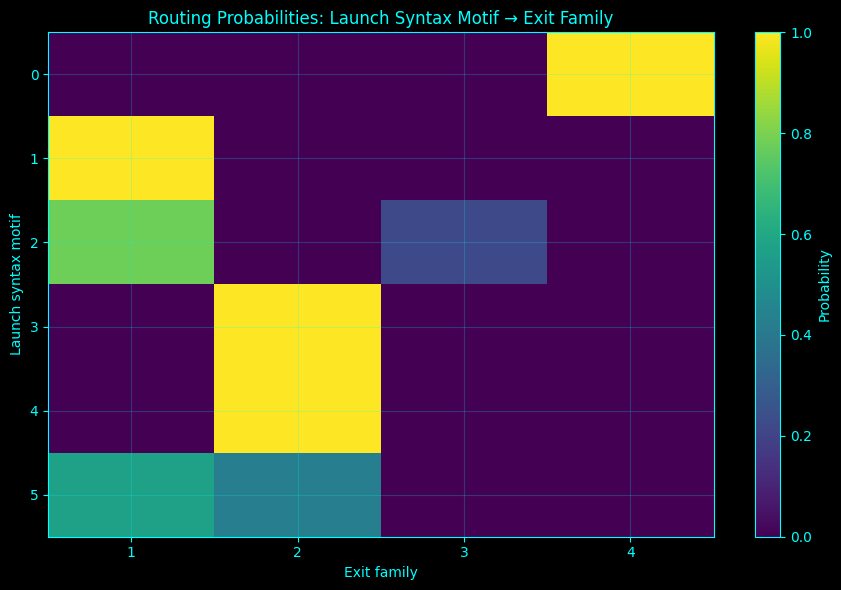

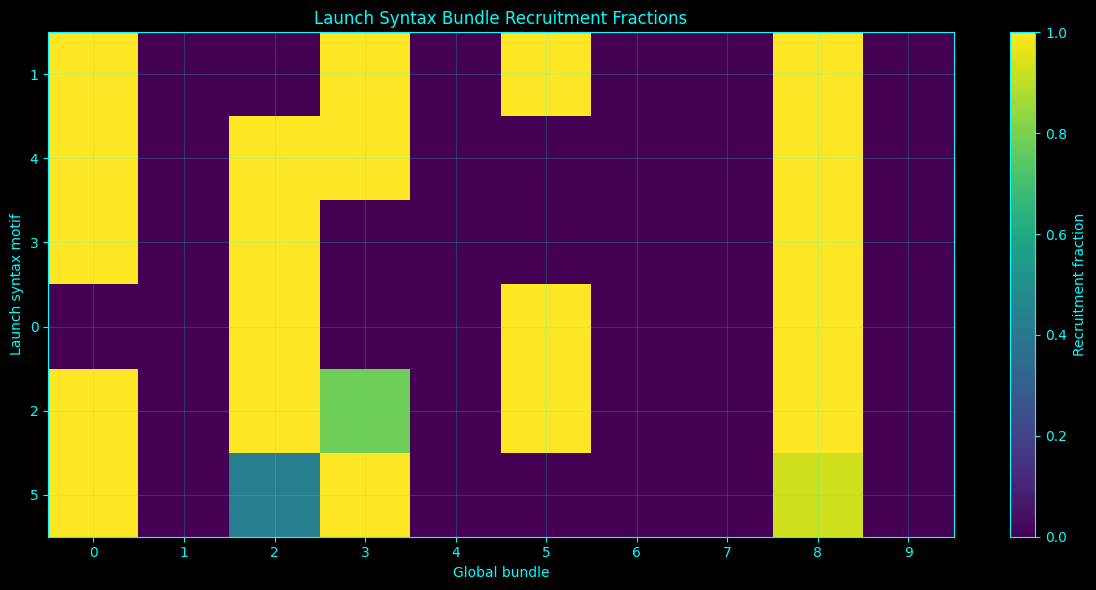

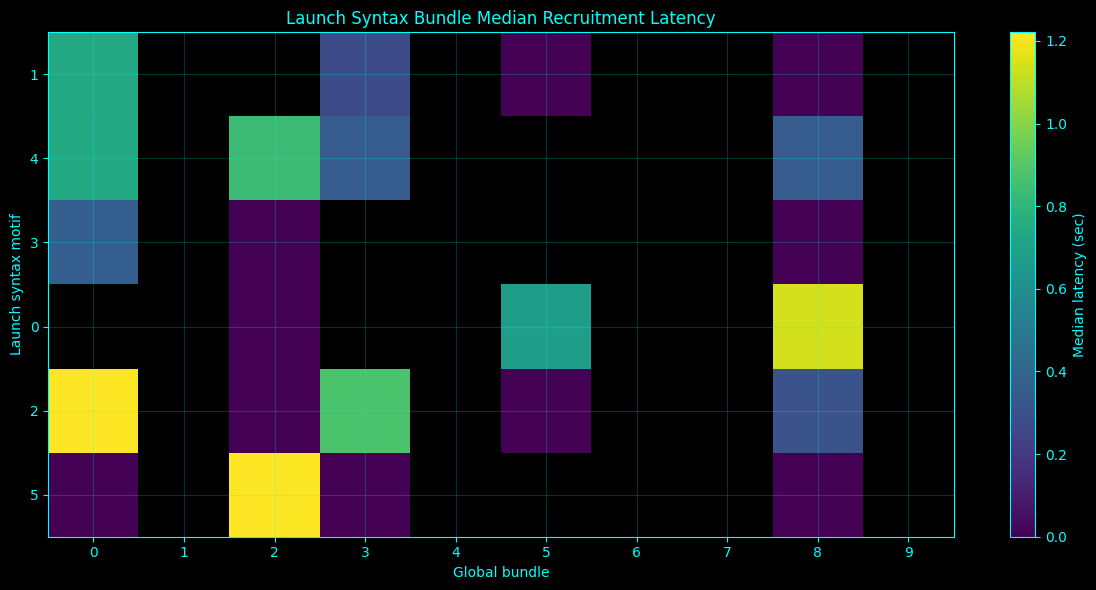

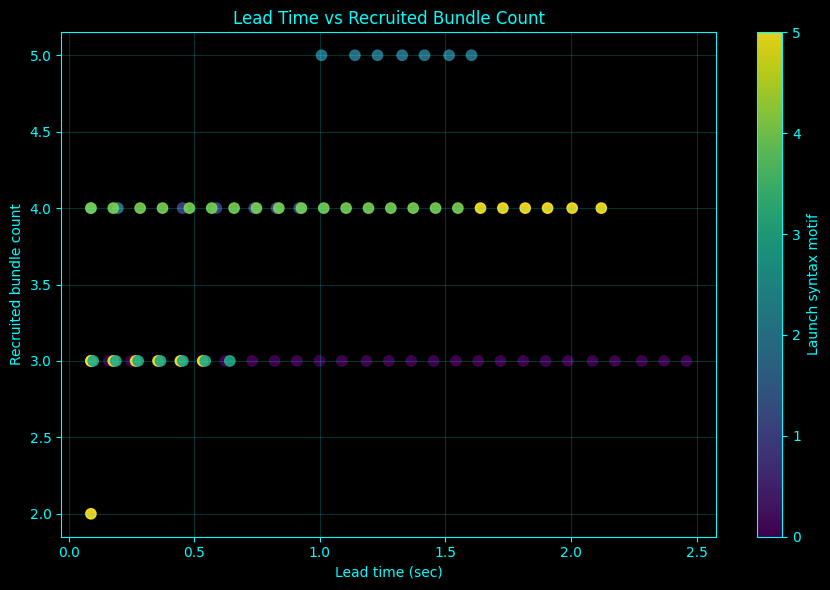

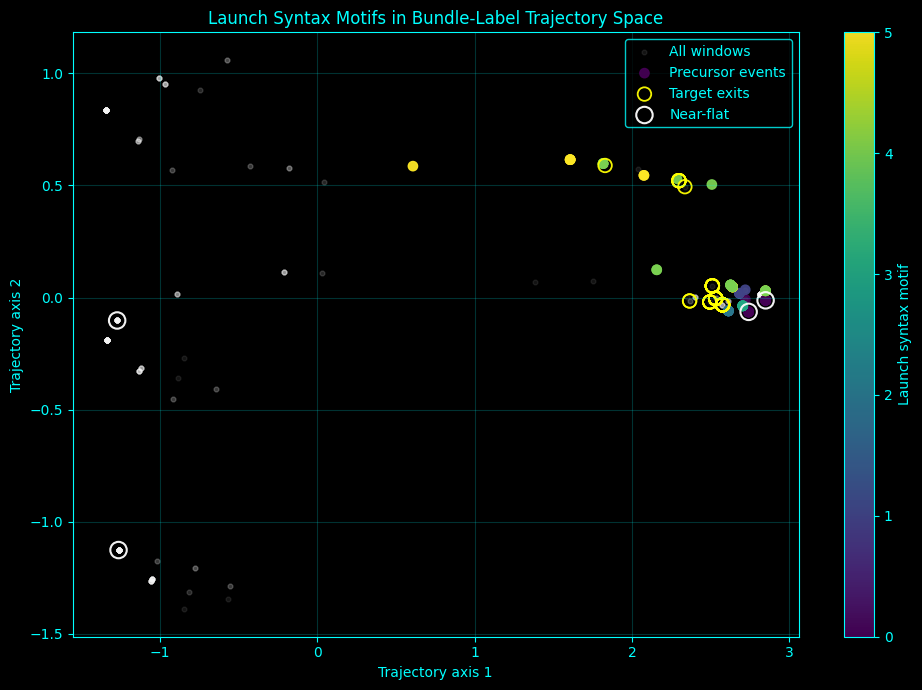


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/launch_syntax_atlas_v2/launch_syntax_per_event.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/launch_syntax_atlas_v2/launch_syntax_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/launch_syntax_atlas_v2/launch_syntax_routing_matrix.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/launch_syntax_atlas_v2/near_flat_launch_syntax_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/launch_syntax_atlas_v2/launch_syntax_atlas_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/launch_syntax_atlas_v2/plots

Chosen k for launch syntax motifs: 6

Launch syntax summary:
 syntax_motif  n_events  dominant_exit_family  dominant_family_prob  routing_entropy  mean_lead_time_sec  median_lead_time_sec  mean_recruited_count  mean_latency_spread  mean_fissure_fracture_score  mean_fissure_motif2_fraction  bundle_0_recruit_frac  bundle_0_median_latency  bundle_1_re

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2
from scipy.spatial.distance import cdist

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

drift_dir = os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1")
router_dir = os.path.join(base_dir, "results", "fissure_router_atlas_v1")
exit_dir = os.path.join(base_dir, "results", "exit_family_atlas_v1")

precursor_csv = os.path.join(router_dir, "labeled_precursor_windows.csv")
window_csv = os.path.join(exit_dir, "late_exit_family_per_window.csv")
near_flat_csv = os.path.join(router_dir, "near_flat_router_context.csv")

out_dir = os.path.join(base_dir, "results", "launch_syntax_atlas_v2")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

smooth_window = 11
max_k = 6
k_restarts = 20
rng_seed = 42

# non-hit fill is max observed lead plus margin
nonhit_margin_sec = 0.15

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def finite_quantile(x, q, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return default
    return float(np.quantile(x, q))

def normalized_entropy(probs):
    probs = np.asarray(probs, dtype=float)
    probs = probs[probs > 0]
    if len(probs) <= 1:
        return 0.0
    H = -np.sum(probs * np.log(probs + eps))
    return float(H / (np.log(len(probs)) + eps))

def rolling_mode_int(x, window):
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan)
    half = window // 2
    for i in range(len(x)):
        a = max(0, i - half)
        b = min(len(x), i + half + 1)
        vals = x[a:b]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        vals = vals.astype(int)
        uniq, counts = np.unique(vals, return_counts=True)
        out[i] = uniq[np.argmax(counts)]
    return out

def discover_dom_cols(cols):
    dom = {}
    loose = {}

    pat_dom = re.compile(r"^bundle_(\d+)_dom_motif$")
    pat_loose = re.compile(r"^bundle_(\d+)$")

    for c in cols:
        m = pat_dom.match(c)
        if m:
            dom[int(m.group(1))] = c
            continue
        m = pat_loose.match(c)
        if m:
            loose[int(m.group(1))] = c

    if len(dom):
        return dict(sorted(dom.items())), "dom"
    if len(loose):
        return dict(sorted(loose.items())), "loose"
    return {}, None

def find_bundle_timeline_csv(search_roots):
    candidates = []

    for root in search_roots:
        if not os.path.exists(root):
            continue

        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                if not fn.lower().endswith(".csv"):
                    continue

                path = os.path.join(dirpath, fn)
                try:
                    head = pd.read_csv(path, nrows=2)
                except Exception:
                    continue

                dom_cols, _ = discover_dom_cols(head.columns)
                if len(dom_cols) == 0:
                    continue

                score = 0
                name = fn.lower()
                if "bundle" in name:
                    score += 2
                if "motif" in name:
                    score += 2
                if "dominant" in name:
                    score += 2
                if "time" in name:
                    score += 1
                if "center_time_sec" in head.columns:
                    score += 3
                if "time_sec" in head.columns:
                    score += 2

                candidates.append((score, path))

    if len(candidates) == 0:
        raise FileNotFoundError("No bundle dominant-motif timeline CSV found.")

    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][1]

def onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4)):
    label_matrix = np.asarray(label_matrix, dtype=float)
    n, b = label_matrix.shape
    out = np.zeros((n, b * len(motif_values)), dtype=float)

    for j in range(b):
        for k, mv in enumerate(motif_values):
            out[:, j * len(motif_values) + k] = (label_matrix[:, j] == mv).astype(float)

    return out

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def silhouette_score_manual(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels, dtype=int)
    uniq = np.unique(labels)

    if len(uniq) < 2:
        return -1.0

    D = cdist(X, X)
    s_vals = []

    for i in range(len(X)):
        own = labels == labels[i]
        others = [labels == u for u in uniq if u != labels[i]]

        if np.sum(own) <= 1:
            s_vals.append(0.0)
            continue

        a = np.mean(D[i, own & (np.arange(len(X)) != i)])

        b = np.inf
        for og in others:
            if np.sum(og) == 0:
                continue
            b = min(b, np.mean(D[i, og]))

        s = (b - a) / max(a, b, eps)
        s_vals.append(s)

    return float(np.mean(s_vals))

def choose_k_by_silhouette(X, max_k=6, restarts=12, rng_seed=42):
    n = len(X)
    if n < 6:
        return 1, np.zeros(n, dtype=int), np.mean(X, axis=0, keepdims=True)

    rng = np.random.default_rng(rng_seed)
    best_global = None

    k_hi = min(max_k, max(2, n // 5))
    k_hi = max(2, k_hi)

    for k in range(2, k_hi + 1):
        best_k = None

        for _ in range(restarts):
            seed = int(rng.integers(0, 1_000_000))
            np.random.seed(seed)

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    centroids, labels = kmeans2(X, k, minit="points", iter=60)
            except Exception:
                continue

            if len(np.unique(labels)) < 2:
                continue

            sil = silhouette_score_manual(X, labels)
            score = (sil, -k)

            if best_k is None or score > best_k["score"]:
                best_k = {
                    "k": k,
                    "labels": labels.copy(),
                    "centroids": centroids.copy(),
                    "score": score,
                    "silhouette": sil,
                }

        if best_k is not None:
            if best_global is None or best_k["score"] > best_global["score"]:
                best_global = best_k

    if best_global is None:
        return 1, np.zeros(n, dtype=int), np.mean(X, axis=0, keepdims=True)

    return best_global["k"], best_global["labels"], best_global["centroids"]

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
precursor_df = pd.read_csv(precursor_csv)
window_df = pd.read_csv(window_csv).sort_values("center_time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = pd.DataFrame()

timeline_csv = find_bundle_timeline_csv([drift_dir, router_dir, exit_dir])
print(f"Using bundle timeline CSV: {timeline_csv}")

timeline_df = pd.read_csv(timeline_csv)
if "center_time_sec" not in timeline_df.columns:
    if "time_sec" in timeline_df.columns:
        timeline_df = timeline_df.rename(columns={"time_sec": "center_time_sec"})
    else:
        raise ValueError("Timeline CSV needs center_time_sec or time_sec.")

timeline_df = timeline_df.sort_values("center_time_sec").reset_index(drop=True)
time_sec = timeline_df["center_time_sec"].values

dom_cols, _ = discover_dom_cols(timeline_df.columns)
if len(dom_cols) == 0:
    raise ValueError("No bundle dominant-motif columns found in timeline CSV.")

bundle_ids = sorted(dom_cols.keys())

# -------------------------------------------------------
# SMOOTH BUNDLE LABELS + TRAJECTORY
# -------------------------------------------------------
smooth_df = pd.DataFrame({"center_time_sec": time_sec})
for b in bundle_ids:
    x = timeline_df[dom_cols[b]].values.astype(float)
    smooth_df[f"bundle_{b}"] = rolling_mode_int(x, smooth_window)

label_matrix = np.column_stack([smooth_df[f"bundle_{b}"].values for b in bundle_ids])
X_all = onehot_from_labels(label_matrix, motif_values=(1, 2, 3, 4))
traj_xy, traj_eigs, traj_vecs = pca_2d(X_all)

traj_df = pd.DataFrame({
    "center_time_sec": time_sec,
    "traj_x": traj_xy[:, 0],
    "traj_y": traj_xy[:, 1],
})

# -------------------------------------------------------
# KEEP ONLY PRECURSOR EVENTS THAT ROUTE TO AN EXIT
# -------------------------------------------------------
good_prec = precursor_df[
    np.isfinite(precursor_df["lead_time_sec"].values) &
    (precursor_df["target_family"].values >= 0)
].copy().reset_index(drop=True)

if len(good_prec) == 0:
    raise ValueError("No valid precursor-to-exit links found.")

fix_idx = []
exit_idx = []

for _, row in good_prec.iterrows():
    t0 = float(row["fissure_time_sec"])
    t1 = float(row["target_exit_time_sec"])

    i0 = int(np.argmin(np.abs(time_sec - t0)))
    i1 = int(np.argmin(np.abs(time_sec - t1)))

    if i1 < i0:
        i0, i1 = i1, i0

    fix_idx.append(i0)
    exit_idx.append(i1)

good_prec["fissure_idx"] = np.array(fix_idx, dtype=int)
good_prec["exit_idx"] = np.array(exit_idx, dtype=int)

# -------------------------------------------------------
# BUNDLE RECRUITMENT LATENCIES
# -------------------------------------------------------
rows = []
latency_mat = []

max_lead = float(np.nanmax(good_prec["lead_time_sec"].values))
fill_value = max_lead + nonhit_margin_sec

for _, row in good_prec.iterrows():
    i0 = int(row["fissure_idx"])
    i1 = int(row["exit_idx"])
    t0 = float(row["fissure_time_sec"])

    latencies = []
    recruited_flags = []

    for b in bundle_ids:
        seq = smooth_df[f"bundle_{b}"].values[i0:i1 + 1]
        hits = np.where(seq == 2)[0]

        if len(hits) == 0:
            latencies.append(np.nan)
            recruited_flags.append(0)
        else:
            k = i0 + int(hits[0])
            latencies.append(float(time_sec[k] - t0))
            recruited_flags.append(1)

    latencies = np.asarray(latencies, dtype=float)
    recruited_flags = np.asarray(recruited_flags, dtype=int)

    finite_lat = latencies[np.isfinite(latencies)]
    recruited_count = int(np.sum(recruited_flags))
    latency_spread = float(np.std(finite_lat)) if len(finite_lat) > 1 else 0.0
    first_latency = float(np.min(finite_lat)) if len(finite_lat) else np.nan
    last_latency = float(np.max(finite_lat)) if len(finite_lat) else np.nan

    rows.append({
        "fissure_time_sec": float(row["fissure_time_sec"]),
        "target_exit_time_sec": float(row["target_exit_time_sec"]),
        "lead_time_sec": float(row["lead_time_sec"]),
        "target_family": int(row["target_family"]),
        "precursor_cluster": int(row["precursor_cluster"]),
        "recruited_count": recruited_count,
        "latency_spread": latency_spread,
        "first_latency_sec": first_latency,
        "last_latency_sec": last_latency,
        "fissure_fracture_score": float(row["fissure_fracture_score"]),
        "fissure_motif2_fraction": float(row["fissure_motif2_fraction"]),
    })

    latency_mat.append(latencies)

syntax_df = pd.DataFrame(rows)
latency_mat = np.asarray(latency_mat, dtype=float)

# feature matrix for clustering
X_syntax = latency_mat.copy()
X_syntax[~np.isfinite(X_syntax)] = fill_value
X_syntax = X_syntax / (fill_value + eps)

# -------------------------------------------------------
# CLUSTER LAUNCH SYNTAX MOTIFS
# -------------------------------------------------------
k_syntax, syntax_labels, syntax_centroids = choose_k_by_silhouette(
    X_syntax,
    max_k=max_k,
    restarts=k_restarts,
    rng_seed=rng_seed
)

syntax_df["syntax_motif"] = syntax_labels

# -------------------------------------------------------
# ROUTING MATRIX: syntax motif -> exit family
# -------------------------------------------------------
syntax_ids = sorted(syntax_df["syntax_motif"].unique())
family_ids = sorted(syntax_df["target_family"].unique())

route_count = np.zeros((len(syntax_ids), len(family_ids)), dtype=float)

for i, s in enumerate(syntax_ids):
    sub = syntax_df[syntax_df["syntax_motif"] == s]
    vc = sub["target_family"].value_counts().to_dict()
    for j, f in enumerate(family_ids):
        route_count[i, j] = vc.get(f, 0)

route_prob = route_count / np.maximum(route_count.sum(axis=1, keepdims=True), 1.0)

# -------------------------------------------------------
# SYNTAX MOTIF SUMMARIES
# -------------------------------------------------------
syntax_rows = []

for i, s in enumerate(syntax_ids):
    sub = syntax_df[syntax_df["syntax_motif"] == s].copy()
    sub_lat = latency_mat[sub.index.values]

    dominant_family = int(family_ids[np.argmax(route_prob[i])])
    dominant_prob = float(np.max(route_prob[i]))
    routing_ent = normalized_entropy(route_prob[i])

    row = {
        "syntax_motif": int(s),
        "n_events": int(len(sub)),
        "dominant_exit_family": dominant_family,
        "dominant_family_prob": dominant_prob,
        "routing_entropy": routing_ent,
        "mean_lead_time_sec": safe_mean(sub["lead_time_sec"].values),
        "median_lead_time_sec": safe_median(sub["lead_time_sec"].values),
        "mean_recruited_count": safe_mean(sub["recruited_count"].values),
        "mean_latency_spread": safe_mean(sub["latency_spread"].values),
        "mean_fissure_fracture_score": safe_mean(sub["fissure_fracture_score"].values),
        "mean_fissure_motif2_fraction": safe_mean(sub["fissure_motif2_fraction"].values),
    }

    for bi, b in enumerate(bundle_ids):
        vals = sub_lat[:, bi]
        row[f"bundle_{b}_recruit_frac"] = float(np.mean(np.isfinite(vals)))
        row[f"bundle_{b}_median_latency"] = safe_median(vals)

    syntax_rows.append(row)

syntax_summary_df = pd.DataFrame(syntax_rows).sort_values(
    ["dominant_family_prob", "mean_recruited_count", "mean_fissure_fracture_score"],
    ascending=[False, False, False]
).reset_index(drop=True)

# -------------------------------------------------------
# BUNDLE SIGNATURE MATRICES
# -------------------------------------------------------
recruit_cols = [f"bundle_{b}_recruit_frac" for b in bundle_ids]
latency_cols = [f"bundle_{b}_median_latency" for b in bundle_ids]

recruit_mat = syntax_summary_df[recruit_cols].values if len(syntax_summary_df) else np.zeros((0, len(bundle_ids)))
latency_sig_mat = syntax_summary_df[latency_cols].values if len(syntax_summary_df) else np.zeros((0, len(bundle_ids)))

# -------------------------------------------------------
# ATTACH TRAJECTORY POSITIONS
# -------------------------------------------------------
syntax_df["traj_x"] = np.nan
syntax_df["traj_y"] = np.nan

for i, row in syntax_df.iterrows():
    idx = int(np.argmin(np.abs(time_sec - row["fissure_time_sec"])))
    syntax_df.loc[i, "traj_x"] = traj_df.loc[idx, "traj_x"]
    syntax_df.loc[i, "traj_y"] = traj_df.loc[idx, "traj_y"]

exit_xy_rows = []
for _, row in syntax_df.iterrows():
    idx = int(np.argmin(np.abs(time_sec - row["target_exit_time_sec"])))
    exit_xy_rows.append({
        "target_family": int(row["target_family"]),
        "syntax_motif": int(row["syntax_motif"]),
        "traj_x": float(traj_df.loc[idx, "traj_x"]),
        "traj_y": float(traj_df.loc[idx, "traj_y"]),
    })

exit_xy_df = pd.DataFrame(exit_xy_rows)

# -------------------------------------------------------
# NEAR-FLAT CONTEXT (FIXED)
# Compare near-flat points to fissure-state vectors, not latency vectors
# -------------------------------------------------------
near_flat_rows = []

event_fissure_idx = syntax_df["fissure_time_sec"].apply(
    lambda t: int(np.argmin(np.abs(time_sec - float(t))))
).values.astype(int)
event_fissure_states = X_all[event_fissure_idx]

if len(near_flat_df) > 0 and len(event_fissure_states) > 0:
    for _, row in near_flat_df.iterrows():
        t0 = float(row["time_sec"])
        idx = int(np.argmin(np.abs(time_sec - t0)))

        d = cdist(
            X_all[idx:idx + 1],
            event_fissure_states
        )[0]

        nearest_event = int(np.argmin(d))

        near_flat_rows.append({
            "time_sec": t0,
            "stage_label": row["stage_label"] if "stage_label" in row.index else "NA",
            "hysteresis_role": row["hysteresis_role"] if "hysteresis_role" in row.index else "NA",
            "nearest_syntax_event_index": nearest_event,
            "nearest_syntax_motif": int(syntax_df.iloc[nearest_event]["syntax_motif"]),
            "nearest_syntax_distance": float(d[nearest_event]),
            "nearest_event_target_family": int(syntax_df.iloc[nearest_event]["target_family"]),
            "traj_x": float(traj_df.loc[idx, "traj_x"]),
            "traj_y": float(traj_df.loc[idx, "traj_y"]),
        })

near_flat_syntax_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
events_csv = os.path.join(out_dir, "launch_syntax_per_event.csv")
summary_csv = os.path.join(out_dir, "launch_syntax_summary.csv")
routing_csv = os.path.join(out_dir, "launch_syntax_routing_matrix.csv")
near_flat_out_csv = os.path.join(out_dir, "near_flat_launch_syntax_context.csv")
summary_txt = os.path.join(out_dir, "launch_syntax_atlas_summary.txt")

syntax_df.to_csv(events_csv, index=False)
syntax_summary_df.to_csv(summary_csv, index=False)
pd.DataFrame(route_prob, index=syntax_ids, columns=family_ids).to_csv(routing_csv)
near_flat_syntax_df.to_csv(near_flat_out_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Launch Syntax Atlas Summary\n")
    f.write("==========================\n\n")
    f.write(f"timeline_csv = {timeline_csv}\n")
    f.write(f"chosen_k_syntax = {k_syntax}\n")
    f.write(f"fill_value_sec = {fill_value:.6f}\n\n")

    f.write("Launch syntax summary:\n")
    if len(syntax_summary_df):
        f.write(syntax_summary_df.to_string(index=False))
    else:
        f.write("No syntax motifs detected.")
    f.write("\n\n")

    f.write("Routing probabilities (syntax motif -> exit family):\n")
    f.write(pd.DataFrame(route_prob, index=syntax_ids, columns=family_ids).to_string())
    f.write("\n\n")

    if len(near_flat_syntax_df):
        f.write("Near-flat launch syntax context:\n")
        f.write(near_flat_syntax_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) syntax routing heatmap
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(route_prob, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
ax.set_title("Routing Probabilities: Launch Syntax Motif → Exit Family")
ax.set_xlabel("Exit family")
ax.set_ylabel("Launch syntax motif")
ax.set_xticks(np.arange(len(family_ids)))
ax.set_xticklabels(family_ids)
ax.set_yticks(np.arange(len(syntax_ids)))
ax.set_yticklabels(syntax_ids)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Probability")

plot1_path = os.path.join(plots_dir, "launch_syntax_routing_heatmap.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) bundle recruitment fraction heatmap
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

if len(syntax_summary_df):
    im = ax.imshow(recruit_mat, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
    ax.set_title("Launch Syntax Bundle Recruitment Fractions")
    ax.set_xlabel("Global bundle")
    ax.set_ylabel("Launch syntax motif")
    ax.set_xticks(np.arange(len(bundle_ids)))
    ax.set_xticklabels(bundle_ids)
    ax.set_yticks(np.arange(len(syntax_summary_df)))
    ax.set_yticklabels(syntax_summary_df["syntax_motif"].values)

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Recruitment fraction")

plot2_path = os.path.join(plots_dir, "launch_syntax_bundle_recruitment_heatmap.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) bundle median latency heatmap
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

if len(syntax_summary_df):
    mat = latency_sig_mat.copy()
    vmax = finite_quantile(mat.ravel(), 0.95, default=np.nanmax(mat) if np.size(mat) else 1.0)
    im = ax.imshow(mat, aspect="auto", interpolation="nearest", vmin=0, vmax=vmax if np.isfinite(vmax) else None)
    ax.set_title("Launch Syntax Bundle Median Recruitment Latency")
    ax.set_xlabel("Global bundle")
    ax.set_ylabel("Launch syntax motif")
    ax.set_xticks(np.arange(len(bundle_ids)))
    ax.set_xticklabels(bundle_ids)
    ax.set_yticks(np.arange(len(syntax_summary_df)))
    ax.set_yticklabels(syntax_summary_df["syntax_motif"].values)

    cbar = plt.colorbar(im, ax=ax)
    style_cbar(cbar, "Median latency (sec)")

plot3_path = os.path.join(plots_dir, "launch_syntax_bundle_latency_heatmap.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) lead time vs recruited count
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    syntax_df["lead_time_sec"].values,
    syntax_df["recruited_count"].values,
    c=syntax_df["syntax_motif"].values,
    s=55,
    alpha=0.90
)

ax.set_title("Lead Time vs Recruited Bundle Count")
ax.set_xlabel("Lead time (sec)")
ax.set_ylabel("Recruited bundle count")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Launch syntax motif")

plot4_path = os.path.join(plots_dir, "leadtime_vs_recruitedcount_by_syntax.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) trajectory map of precursor syntax and exits
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    traj_df["traj_x"].values,
    traj_df["traj_y"].values,
    s=12,
    alpha=0.08,
    color="white",
    label="All windows"
)

sc = ax.scatter(
    syntax_df["traj_x"].values,
    syntax_df["traj_y"].values,
    c=syntax_df["syntax_motif"].values,
    s=45,
    alpha=0.95,
    label="Precursor events"
)

ax.scatter(
    exit_xy_df["traj_x"].values,
    exit_xy_df["traj_y"].values,
    s=95,
    facecolors="none",
    edgecolors="yellow",
    linewidths=1.3,
    alpha=0.95,
    label="Target exits"
)

if len(near_flat_syntax_df):
    ax.scatter(
        near_flat_syntax_df["traj_x"].values,
        near_flat_syntax_df["traj_y"].values,
        s=140,
        facecolors="none",
        edgecolors="white",
        linewidths=1.5,
        alpha=0.95,
        label="Near-flat"
    )

ax.set_title("Launch Syntax Motifs in Bundle-Label Trajectory Space")
ax.set_xlabel("Trajectory axis 1")
ax.set_ylabel("Trajectory axis 2")
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Launch syntax motif")

plot5_path = os.path.join(plots_dir, "launch_syntax_trajectory_map.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nSaved:")
print(events_csv)
print(summary_csv)
print(routing_csv)
print(near_flat_out_csv)
print(summary_txt)
print(plots_dir)

print(f"\nChosen k for launch syntax motifs: {k_syntax}")

print("\nLaunch syntax summary:")
if len(syntax_summary_df):
    print(syntax_summary_df.to_string(index=False))
else:
    print("No syntax motifs detected.")

print("\nRouting probability matrix:")
print(pd.DataFrame(route_prob, index=syntax_ids, columns=family_ids).to_string())

if len(near_flat_syntax_df):
    print("\nNear-flat launch syntax context:")
    print(near_flat_syntax_df.to_string(index=False))

/tmp/ipykernel_21559/2273632239.py:484: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(layers), 1))


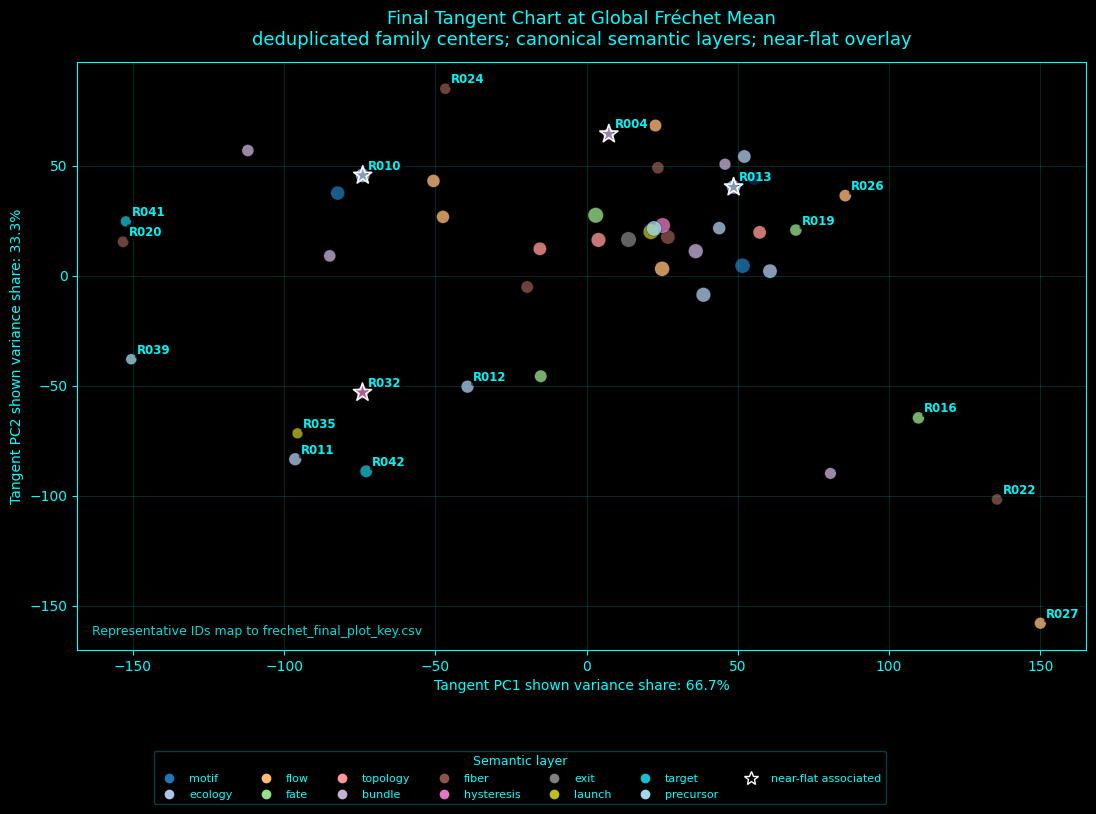

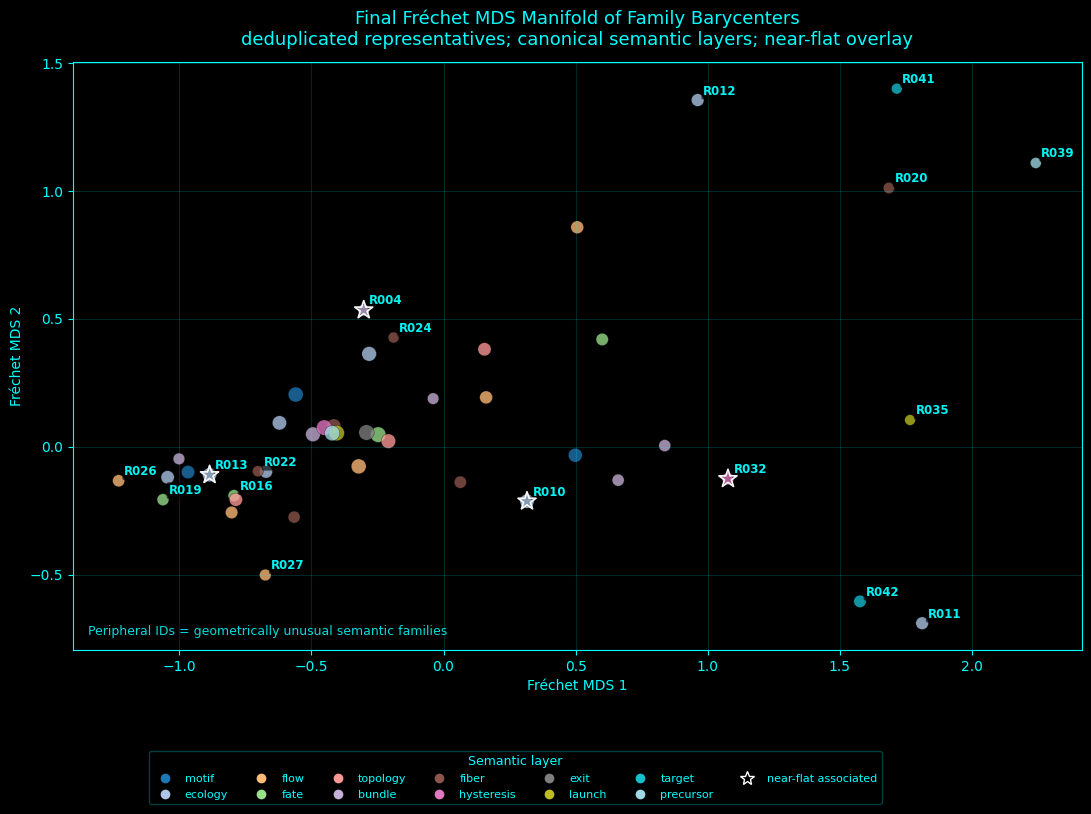

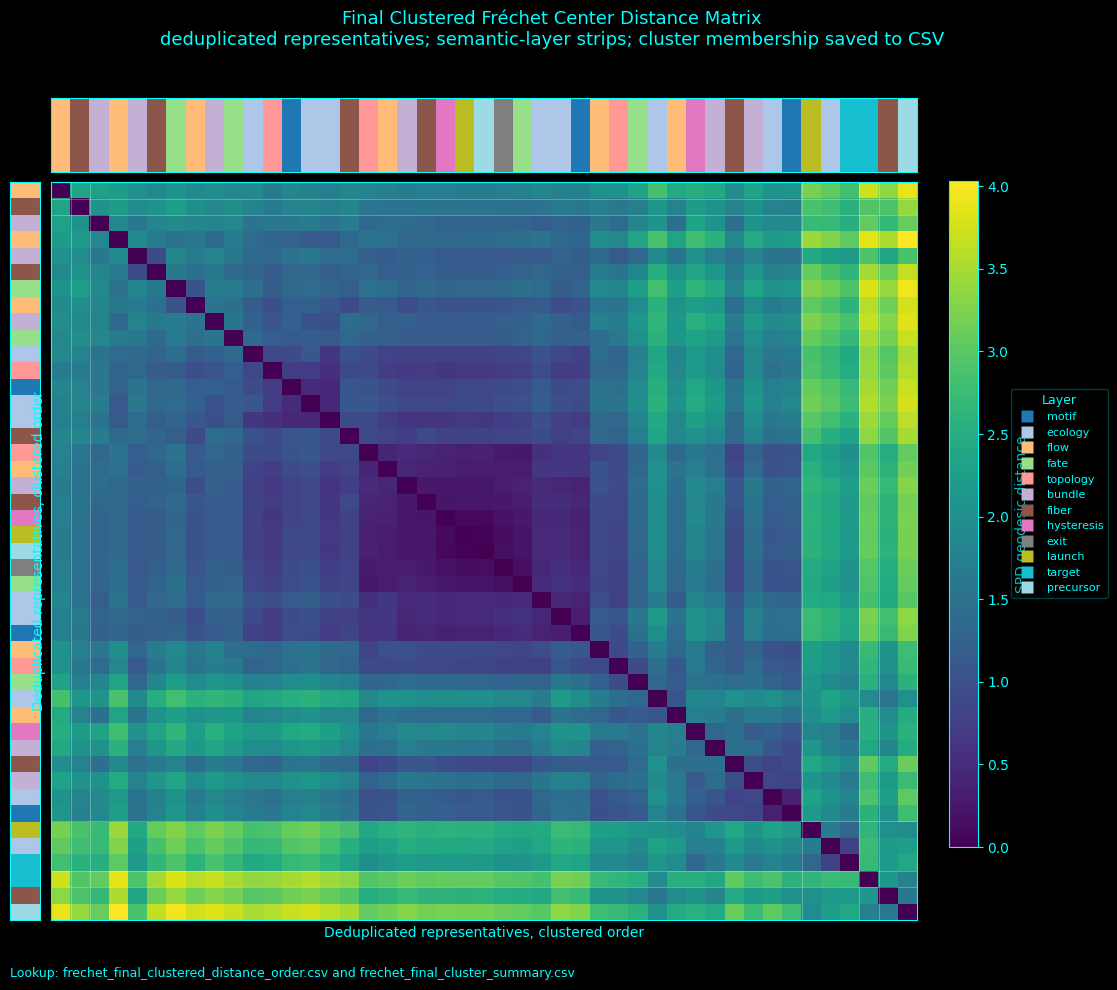

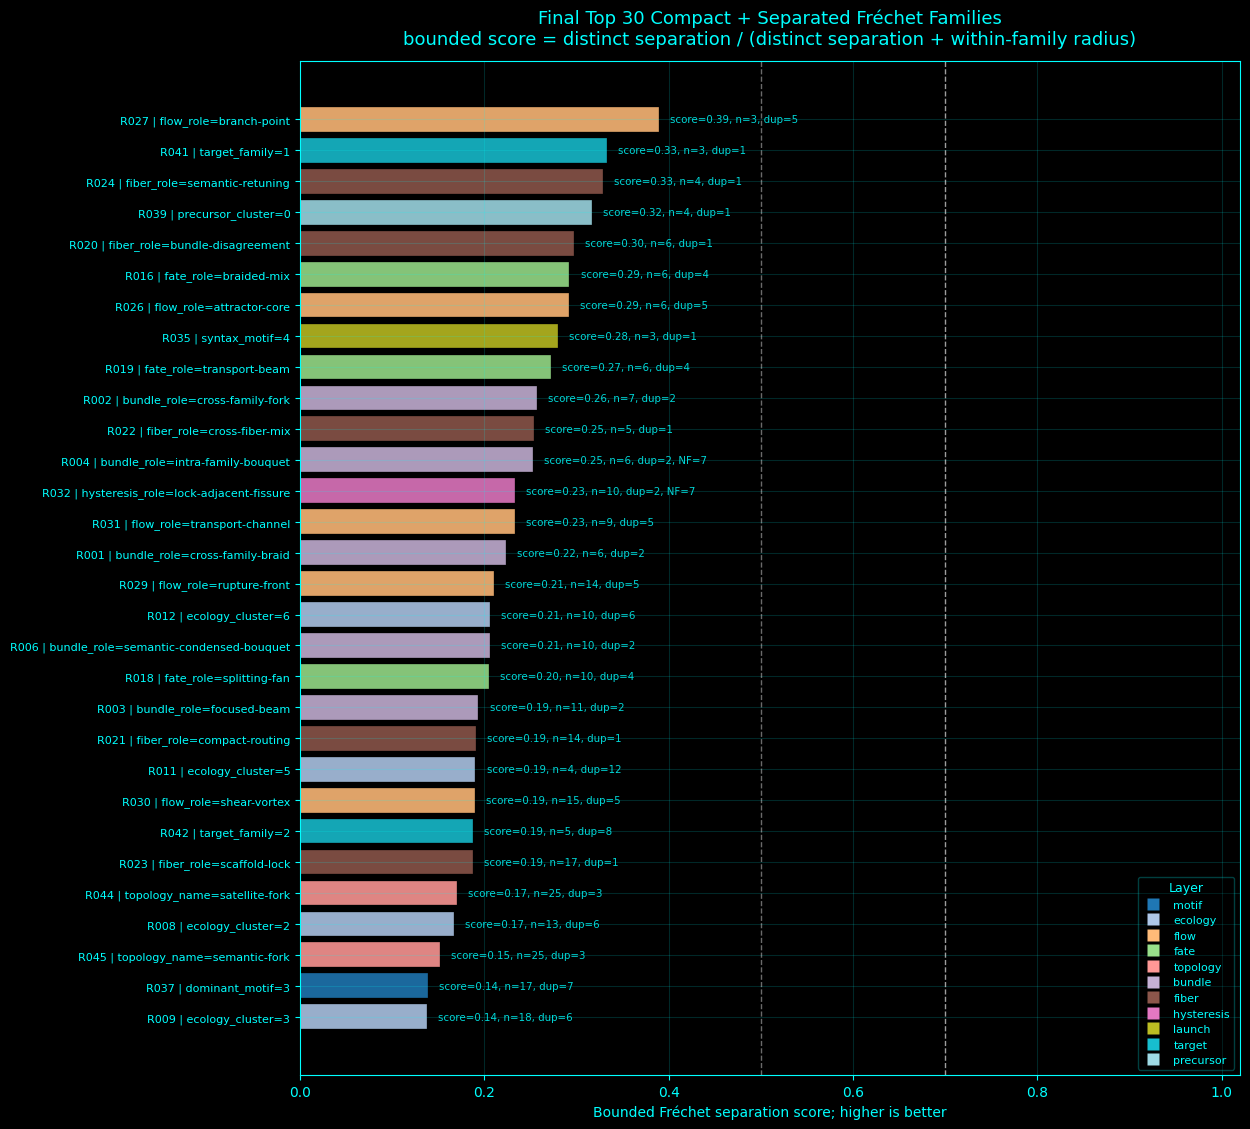

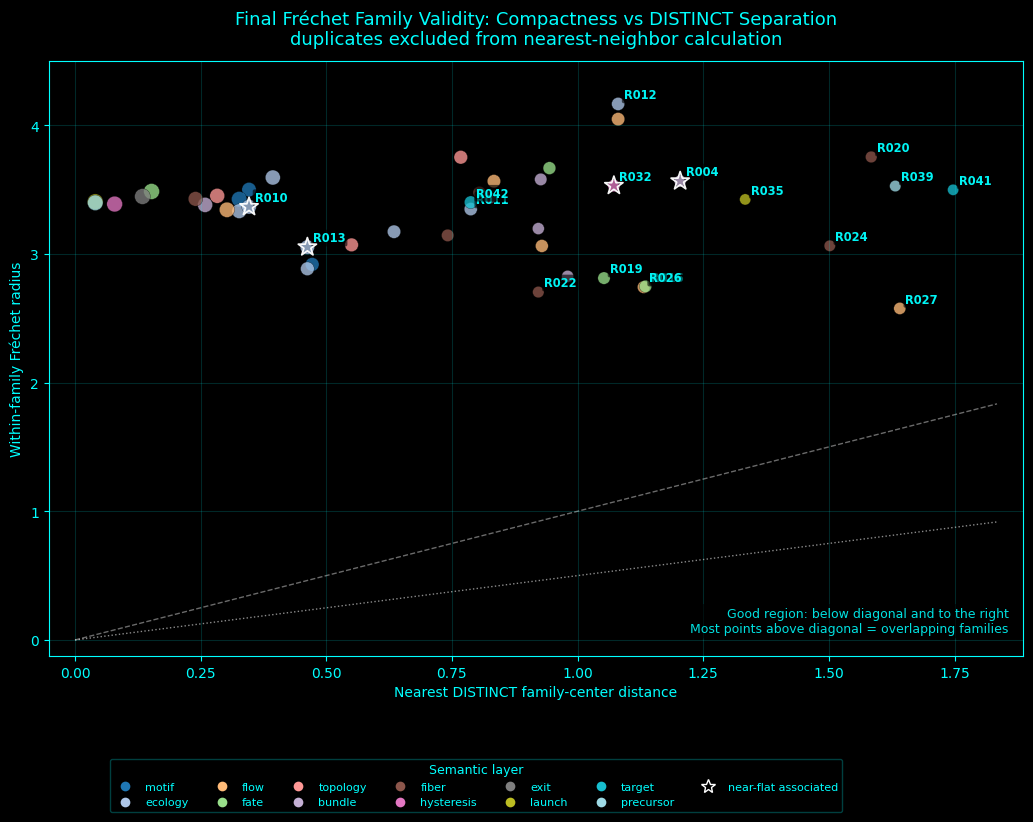

Final plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/frechet_manifold_atlas_v1/plots/final_five_frechet_plots
Final plot key saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/frechet_manifold_atlas_v1/frechet_final_plot_key.csv
Final quality table saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/frechet_manifold_atlas_v1/frechet_final_family_quality_table.csv
Final layer summary saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/frechet_manifold_atlas_v1/frechet_final_layer_summary.csv
Final cluster summary saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/frechet_manifold_atlas_v1/frechet_final_cluster_summary.csv
Final summary saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/frechet_manifold_atlas_v1/frechet_final_five_plot_summary.txt

DONE: final corrected Fréchet plotting suite complete.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

if "base_dir" not in globals():
    base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

if "out_dir" not in globals():
    out_dir = os.path.join(base_dir, "results", "frechet_manifold_atlas_v1")

if "plots_dir" not in globals():
    plots_dir = os.path.join(out_dir, "plots")

final_plot_dir = os.path.join(plots_dir, "final_five_frechet_plots")
os.makedirs(final_plot_dir, exist_ok=True)

if "chart_df" not in globals():
    chart_path = os.path.join(out_dir, "empirical_frechet_manifold_chart.csv")
    if not os.path.exists(chart_path):
        raise FileNotFoundError(f"Missing chart file: {chart_path}")
    chart_df = pd.read_csv(chart_path)

if "family_summary_df" not in globals():
    summary_path = os.path.join(out_dir, "family_frechet_summary.csv")
    if not os.path.exists(summary_path):
        raise FileNotFoundError(f"Missing family summary file: {summary_path}")
    family_summary_df = pd.read_csv(summary_path)

if "D" not in globals() or "center_keys" not in globals():
    dist_path = os.path.join(out_dir, "family_frechet_center_distance_matrix.csv")
    if not os.path.exists(dist_path):
        raise FileNotFoundError(f"Missing distance matrix file: {dist_path}")
    D_df = pd.read_csv(dist_path, index_col=0)
    center_keys = D_df.index.astype(str).tolist()
    D = D_df.values.astype(float)

near_frechet_path = os.path.join(out_dir, "near_flat_frechet_context.csv")
if "near_frechet_df" not in globals():
    if os.path.exists(near_frechet_path):
        near_frechet_df = pd.read_csv(near_frechet_path)
    else:
        near_frechet_df = pd.DataFrame()

BG = globals().get("BG", "black")
ACCENT = globals().get("ACCENT", "cyan")

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, grid=True):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    if grid:
        ax.grid(True, alpha=0.16, color=ACCENT)
    else:
        ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def short_str(x, max_len=44):
    s = str(x)
    return s if len(s) <= max_len else s[:max_len - 3] + "..."

def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    good = np.isfinite(x)
    out = np.zeros_like(x, dtype=float)
    if not np.any(good):
        return out
    sd = np.nanstd(x[good])
    if not np.isfinite(sd) or sd < 1e-12:
        return out
    out[good] = (x[good] - np.nanmean(x[good])) / sd
    return out

def canonical_family_column(col):
    s = str(col)

    ordered_prefixes = [
        "dominant_motif",
        "soft_motif",
        "motif_label",
        "syntax_motif",
        "launch_syntax",
        "ecology_cluster",
        "ecology_name",
        "flow_role",
        "fate_role",
        "topology_name",
        "global_bundle",
        "bundle_role",
        "fiber_role",
        "relabel_stage",
        "fracture_role",
        "hysteresis_role",
        "exit_family",
        "target_family",
        "precursor_cluster",
    ]

    for p in ordered_prefixes:
        if s.startswith(p):
            return p

    if "__" in s:
        left = s.split("__")[0]
        for p in ordered_prefixes:
            if left.startswith(p):
                return p
        return left

    return s

def super_layer_from_column(col):
    c = canonical_family_column(col).lower()

    if c in ["syntax_motif", "launch_syntax"]:
        return "launch"
    if c == "target_family":
        return "target"
    if c == "precursor_cluster":
        return "precursor"
    if c == "fiber_role":
        return "fiber"
    if c in ["relabel_stage", "fracture_role"]:
        return "fracture/relabel"
    if c == "hysteresis_role":
        return "hysteresis"
    if c == "exit_family":
        return "exit"
    if c == "topology_name":
        return "topology"
    if c == "fate_role":
        return "fate"
    if c == "flow_role":
        return "flow"
    if c in ["global_bundle", "bundle_role"]:
        return "bundle"
    if c in ["ecology_cluster", "ecology_name"]:
        return "ecology"
    if c in ["dominant_motif", "soft_motif", "motif_label"]:
        return "motif"

    s = str(col).lower()
    if "syntax" in s or "launch" in s:
        return "launch"
    if "target" in s:
        return "target"
    if "precursor" in s:
        return "precursor"
    if "fiber" in s:
        return "fiber"
    if "hysteresis" in s:
        return "hysteresis"
    if "exit" in s:
        return "exit"
    if "topology" in s or "lobe" in s:
        return "topology"
    if "fate" in s:
        return "fate"
    if "flow" in s:
        return "flow"
    if "bundle" in s:
        return "bundle"
    if "ecology" in s:
        return "ecology"
    if "motif" in s:
        return "motif"

    return "other"

chart = chart_df.copy()
summary = family_summary_df.copy()

chart["center_key"] = chart["center_key"].astype(str)
summary["center_key"] = summary["center_key"].astype(str)

summary_metric_cols = [
    "center_key",
    "family_column",
    "family_value",
    "n_epochs",
    "frechet_variance",
    "frechet_radius_mean",
    "frechet_radius_median",
    "frechet_radius_q90",
    "distance_to_global_frechet_mean",
    "trace_frechet_mean",
    "logdet_frechet_mean",
]

summary_metric_cols = [c for c in summary_metric_cols if c in summary.columns]

missing_cols = [
    c for c in summary_metric_cols
    if c != "center_key" and c not in chart.columns
]

if missing_cols:
    chart = chart.merge(
        summary[["center_key"] + missing_cols],
        on="center_key",
        how="left",
    )

if "family_column" not in chart.columns:
    chart["family_column"] = chart["center_key"].astype(str).str.split("__").str[0]

if "family_value" not in chart.columns:
    chart["family_value"] = chart["center_key"].astype(str)

if "n_epochs" not in chart.columns:
    chart["n_epochs"] = 1

if "frechet_radius_mean" not in chart.columns:
    if "frechet_variance" in chart.columns:
        chart["frechet_radius_mean"] = np.sqrt(np.maximum(pd.to_numeric(chart["frechet_variance"], errors="coerce"), 0))
    else:
        chart["frechet_radius_mean"] = np.nan

if "distance_to_global_frechet_mean" not in chart.columns:
    chart["distance_to_global_frechet_mean"] = np.nan

for c in ["n_epochs", "frechet_radius_mean", "distance_to_global_frechet_mean"]:
    chart[c] = pd.to_numeric(chart[c], errors="coerce")

chart["n_epochs"] = chart["n_epochs"].fillna(1).clip(lower=1)

if chart["frechet_radius_mean"].notna().any():
    chart["frechet_radius_mean"] = chart["frechet_radius_mean"].fillna(chart["frechet_radius_mean"].median())
else:
    chart["frechet_radius_mean"] = 1.0

if chart["distance_to_global_frechet_mean"].notna().any():
    chart["distance_to_global_frechet_mean"] = chart["distance_to_global_frechet_mean"].fillna(chart["distance_to_global_frechet_mean"].median())
else:
    chart["distance_to_global_frechet_mean"] = 0.0

chart["canonical_family_column"] = chart["family_column"].map(canonical_family_column)
chart["super_layer"] = chart["family_column"].map(super_layer_from_column)
chart["full_label"] = (
    chart["canonical_family_column"].astype(str)
    + "="
    + chart["family_value"].astype(str)
)

center_keys = [str(k) for k in center_keys]
D = np.asarray(D, dtype=float)

if D.shape[0] != D.shape[1]:
    raise ValueError(f"Distance matrix must be square, got {D.shape}")

if D.shape[0] != len(center_keys):
    raise ValueError(
        f"Distance matrix size {D.shape[0]} does not match center_keys length {len(center_keys)}"
    )

D = 0.5 * (D + D.T)
finite_D = D[np.isfinite(D)]
if len(finite_D) == 0:
    raise ValueError("Distance matrix contains no finite values.")
D[~np.isfinite(D)] = np.nanmax(finite_D)
np.fill_diagonal(D, 0.0)

key_to_matrix_idx = {k: i for i, k in enumerate(center_keys)}
chart = chart[chart["center_key"].isin(key_to_matrix_idx)].copy()
chart["matrix_idx"] = chart["center_key"].map(key_to_matrix_idx).astype(int)

chart = chart.sort_values(
    ["super_layer", "canonical_family_column", "family_value", "center_key"]
).reset_index(drop=True)

chart["original_plot_id"] = [f"F{i+1:03d}" for i in range(len(chart))]

positive_distances = D[np.triu_indices_from(D, k=1)]
positive_distances = positive_distances[np.isfinite(positive_distances)]
positive_distances = positive_distances[positive_distances > 0]

if len(positive_distances):
    auto_duplicate_eps = max(1e-7, 1e-6 * float(np.nanmedian(positive_distances)))
else:
    auto_duplicate_eps = 1e-7

DUPLICATE_DISTANCE_EPS = globals().get("DUPLICATE_DISTANCE_EPS", auto_duplicate_eps)

parent = np.arange(len(center_keys))

def find_parent(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union_parent(a, b):
    ra, rb = find_parent(a), find_parent(b)
    if ra != rb:
        parent[rb] = ra

for i in range(len(center_keys)):
    close_js = np.where(D[i, i + 1:] <= DUPLICATE_DISTANCE_EPS)[0] + i + 1
    for j in close_js:
        union_parent(i, j)

roots = np.array([find_parent(i) for i in range(len(center_keys))])
unique_roots = {r: k for k, r in enumerate(sorted(np.unique(roots)))}
component_by_matrix_idx = np.array([unique_roots[r] for r in roots])

chart["duplicate_component"] = chart["matrix_idx"].map(lambda i: int(component_by_matrix_idx[i]))

component_members = {}
for k, idx in key_to_matrix_idx.items():
    comp = int(component_by_matrix_idx[idx])
    component_members.setdefault(comp, []).append(k)

component_size = {comp: len(keys) for comp, keys in component_members.items()}
chart["duplicate_group_size"] = chart["duplicate_component"].map(component_size).astype(int)

nearest_distinct = np.full(len(center_keys), np.nan)
nearest_distinct_key = np.array([None] * len(center_keys), dtype=object)

for i in range(len(center_keys)):
    comp_i = component_by_matrix_idx[i]
    mask = component_by_matrix_idx != comp_i

    if not np.any(mask):
        continue

    drow = D[i].copy()
    drow[~mask] = np.inf

    j = int(np.argmin(drow))
    nearest_distinct[i] = float(drow[j])
    nearest_distinct_key[i] = center_keys[j]

chart["nearest_distinct_center_distance"] = chart["matrix_idx"].map(
    lambda i: nearest_distinct[i]
)

chart["nearest_distinct_center_key"] = chart["matrix_idx"].map(
    lambda i: nearest_distinct_key[i]
)

chart["nearest_distinct_center_distance"] = pd.to_numeric(
    chart["nearest_distinct_center_distance"],
    errors="coerce",
)

eps = 1e-12

chart["frechet_separation_score"] = (
    chart["nearest_distinct_center_distance"]
    / (
        chart["nearest_distinct_center_distance"]
        + chart["frechet_radius_mean"]
        + eps
    )
)

chart["frechet_radius_to_distinct_separation"] = (
    chart["frechet_radius_mean"]
    / (chart["nearest_distinct_center_distance"] + eps)
)

chart["frechet_geometry_quality"] = np.where(
    chart["frechet_separation_score"] >= 0.70,
    "compact_and_separated",
    np.where(
        chart["frechet_separation_score"] >= 0.50,
        "moderately_distinct",
        "diffuse_or_overlapping",
    )
)

near_component_counts = {}

if isinstance(near_frechet_df, pd.DataFrame) and len(near_frechet_df):
    if "nearest_family_center" in near_frechet_df.columns:
        for key in near_frechet_df["nearest_family_center"].dropna().astype(str):
            if key in key_to_matrix_idx:
                comp = int(component_by_matrix_idx[key_to_matrix_idx[key]])
                near_component_counts[comp] = near_component_counts.get(comp, 0) + 1

chart["near_flat_count"] = chart["duplicate_component"].map(
    lambda c: near_component_counts.get(int(c), 0)
).astype(int)

chart["near_flat_associated"] = chart["near_flat_count"] > 0

chart["_rep_rank_1"] = chart["near_flat_count"]
chart["_rep_rank_2"] = chart["n_epochs"]
chart["_rep_rank_3"] = chart["frechet_separation_score"].fillna(-np.inf)
chart["_rep_rank_4"] = -chart["full_label"].astype(str).str.len()

rep_rows = []

for comp, sub in chart.groupby("duplicate_component"):
    sub_sorted = sub.sort_values(
        ["_rep_rank_1", "_rep_rank_2", "_rep_rank_3", "_rep_rank_4"],
        ascending=[False, False, False, False],
    )
    rep_rows.append(sub_sorted.iloc[0])

rep_df = pd.DataFrame(rep_rows).reset_index(drop=True)
rep_df = rep_df.sort_values(
    ["super_layer", "canonical_family_column", "family_value", "center_key"]
).reset_index(drop=True)

rep_df["rep_id"] = [f"R{i+1:03d}" for i in range(len(rep_df))]

comp_to_rep_id = dict(zip(rep_df["duplicate_component"], rep_df["rep_id"]))
comp_to_rep_key = dict(zip(rep_df["duplicate_component"], rep_df["center_key"]))

chart["rep_id"] = chart["duplicate_component"].map(comp_to_rep_id)
chart["rep_center_key"] = chart["duplicate_component"].map(comp_to_rep_key)

member_info_rows = []

for comp, sub in chart.groupby("duplicate_component"):
    labels = (
        sub["original_plot_id"].astype(str)
        + " | "
        + sub["canonical_family_column"].astype(str)
        + "="
        + sub["family_value"].astype(str)
        + " | source_col="
        + sub["family_column"].astype(str)
    )

    member_info_rows.append({
        "duplicate_component": int(comp),
        "duplicate_group_size_check": int(len(sub)),
        "member_center_keys": " ; ".join(sub["center_key"].astype(str).tolist()),
        "member_original_plot_ids": " ; ".join(sub["original_plot_id"].astype(str).tolist()),
        "member_labels": " ; ".join(labels.tolist()),
        "member_super_layers": " ; ".join(sorted(sub["super_layer"].astype(str).unique())),
    })

member_info_df = pd.DataFrame(member_info_rows)
rep_df = rep_df.merge(member_info_df, on="duplicate_component", how="left")

rep_matrix_indices = rep_df["matrix_idx"].astype(int).values
D_rep = D[np.ix_(rep_matrix_indices, rep_matrix_indices)]
rep_df["rep_matrix_idx"] = np.arange(len(rep_df))

preferred_layer_order = [
    "motif",
    "ecology",
    "flow",
    "fate",
    "topology",
    "bundle",
    "fiber",
    "fracture/relabel",
    "hysteresis",
    "exit",
    "launch",
    "target",
    "precursor",
    "other",
]

actual_layers = rep_df["super_layer"].dropna().astype(str).unique().tolist()
layers = [x for x in preferred_layer_order if x in actual_layers]
layers += [x for x in actual_layers if x not in layers]

cmap = plt.cm.get_cmap("tab20", max(len(layers), 1))
layer_color = {layer: cmap(i) for i, layer in enumerate(layers)}

rep_df["annotation_score"] = (
    1.25 * zscore_safe(rep_df["distance_to_global_frechet_mean"].values)
    + 1.15 * zscore_safe(rep_df["frechet_separation_score"].values)
    + 0.70 * zscore_safe(np.log1p(rep_df["duplicate_group_size"].values))
    + 0.55 * zscore_safe(np.log1p(rep_df["n_epochs"].values))
    + 1.35 * zscore_safe(rep_df["near_flat_count"].values)
)

coordinate_spread = np.sqrt(
    zscore_safe(rep_df["frechet_mds_x"].values) ** 2
    + zscore_safe(rep_df["frechet_mds_y"].values) ** 2
    + zscore_safe(rep_df["global_tangent_pc1"].values) ** 2
    + zscore_safe(rep_df["global_tangent_pc2"].values) ** 2
)

rep_df["coordinate_outlier_score"] = coordinate_spread

candidate_ids = []

candidate_ids += rep_df.sort_values("annotation_score", ascending=False).head(14)["rep_id"].tolist()
candidate_ids += rep_df.sort_values("distance_to_global_frechet_mean", ascending=False).head(8)["rep_id"].tolist()
candidate_ids += rep_df.sort_values("frechet_separation_score", ascending=False).head(8)["rep_id"].tolist()
candidate_ids += rep_df.sort_values("coordinate_outlier_score", ascending=False).head(8)["rep_id"].tolist()
candidate_ids += rep_df[rep_df["near_flat_associated"]].sort_values("near_flat_count", ascending=False).head(10)["rep_id"].tolist()

seen = set()
annotate_ids = []
for rid in candidate_ids:
    if rid not in seen:
        annotate_ids.append(rid)
        seen.add(rid)

MAX_ANNOTATIONS = 18
annotate_ids = annotate_ids[:MAX_ANNOTATIONS]

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=layer_color[layer],
        markeredgecolor="none",
        label=layer,
        markersize=7,
    )
    for layer in layers
]

nearflat_handle = Line2D(
    [0],
    [0],
    marker="*",
    color="white",
    markerfacecolor="none",
    label="near-flat associated",
    markersize=10,
    linestyle="None",
)

def annotate_rep_points(ax, df, x_col, y_col, ids, fontsize=8.5):
    label_df = df[df["rep_id"].isin(ids)].copy()

    for _, row in label_df.iterrows():
        ax.annotate(
            row["rep_id"],
            xy=(row[x_col], row[y_col]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=fontsize,
            weight="bold",
            color=ACCENT,
            alpha=0.96,
            bbox=dict(
                facecolor=BG,
                edgecolor="none",
                alpha=0.62,
                boxstyle="round,pad=0.16",
            ),
            clip_on=True,
        )

def add_bottom_layer_legend(fig, include_nearflat=True):
    handles = legend_handles.copy()
    if include_nearflat:
        handles.append(nearflat_handle)

    ncol = min(7, max(1, len(handles)))
    leg = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=ncol,
        fontsize=8,
        framealpha=0.25,
        title="Semantic layer",
        title_fontsize=9,
    )
    for text in leg.get_texts():
        text.set_color(ACCENT)
    leg.get_title().set_color(ACCENT)

def scatter_representatives(ax, x_col, y_col, annotate=True):
    for layer in layers:
        sub = rep_df[rep_df["super_layer"] == layer]
        if len(sub) == 0:
            continue

        sizes = (
            38
            + 7.5 * np.sqrt(sub["n_epochs"].astype(float).values)
            + 8.5 * np.sqrt(sub["duplicate_group_size"].astype(float).values)
        )

        ax.scatter(
            sub[x_col],
            sub[y_col],
            s=sizes,
            alpha=0.78,
            color=layer_color[layer],
            edgecolors="black",
            linewidths=0.25,
        )

    nf = rep_df[rep_df["near_flat_associated"]]
    if len(nf):
        ax.scatter(
            nf[x_col],
            nf[y_col],
            s=185,
            marker="*",
            facecolors="none",
            edgecolors="white",
            linewidths=1.25,
            alpha=0.96,
            zorder=5,
        )

    if annotate:
        annotate_rep_points(ax, rep_df, x_col, y_col, annotate_ids)

    style_ax(ax, grid=True)

fixed_key_csv = os.path.join(out_dir, "frechet_final_plot_key.csv")
fixed_quality_csv = os.path.join(out_dir, "frechet_final_family_quality_table.csv")
duplicate_groups_csv = os.path.join(out_dir, "frechet_final_duplicate_center_groups.csv")
annotation_key_csv = os.path.join(out_dir, "frechet_final_annotation_key.csv")

chart_cols = [
    "rep_id",
    "original_plot_id",
    "center_key",
    "rep_center_key",
    "duplicate_component",
    "duplicate_group_size",
    "canonical_family_column",
    "family_column",
    "family_value",
    "super_layer",
    "n_epochs",
    "frechet_radius_mean",
    "nearest_distinct_center_distance",
    "frechet_separation_score",
    "frechet_radius_to_distinct_separation",
    "distance_to_global_frechet_mean",
    "near_flat_count",
    "near_flat_associated",
    "frechet_geometry_quality",
]

chart[[c for c in chart_cols if c in chart.columns]].to_csv(fixed_quality_csv, index=False)

rep_key_cols = [
    "rep_id",
    "center_key",
    "duplicate_component",
    "duplicate_group_size",
    "canonical_family_column",
    "family_column",
    "family_value",
    "super_layer",
    "n_epochs",
    "frechet_radius_mean",
    "nearest_distinct_center_distance",
    "frechet_separation_score",
    "frechet_radius_to_distinct_separation",
    "distance_to_global_frechet_mean",
    "near_flat_count",
    "near_flat_associated",
    "frechet_geometry_quality",
    "member_original_plot_ids",
    "member_labels",
]

rep_df[[c for c in rep_key_cols if c in rep_df.columns]].to_csv(fixed_key_csv, index=False)
member_info_df.to_csv(duplicate_groups_csv, index=False)

rep_df[rep_df["rep_id"].isin(annotate_ids)][
    [
        "rep_id",
        "center_key",
        "canonical_family_column",
        "family_value",
        "super_layer",
        "n_epochs",
        "duplicate_group_size",
        "frechet_radius_mean",
        "nearest_distinct_center_distance",
        "frechet_separation_score",
        "distance_to_global_frechet_mean",
        "near_flat_count",
        "member_labels",
    ]
].to_csv(annotation_key_csv, index=False)

layer_summary = (
    rep_df
    .groupby("super_layer")
    .agg(
        n_representatives=("rep_id", "count"),
        n_near_flat=("near_flat_associated", "sum"),
        median_radius=("frechet_radius_mean", "median"),
        median_distinct_separation=("nearest_distinct_center_distance", "median"),
        median_separation_score=("frechet_separation_score", "median"),
        max_separation_score=("frechet_separation_score", "max"),
        median_global_distance=("distance_to_global_frechet_mean", "median"),
        max_global_distance=("distance_to_global_frechet_mean", "max"),
    )
    .reset_index()
    .sort_values("median_separation_score", ascending=False)
)

layer_summary_csv = os.path.join(out_dir, "frechet_final_layer_summary.csv")
layer_summary.to_csv(layer_summary_csv, index=False)

quality_counts = (
    rep_df
    .groupby(["super_layer", "frechet_geometry_quality"])
    .size()
    .reset_index(name="count")
)

quality_counts_csv = os.path.join(out_dir, "frechet_final_quality_counts.csv")
quality_counts.to_csv(quality_counts_csv, index=False)

if "global_tangent_pc1" in rep_df.columns and "global_tangent_pc2" in rep_df.columns:
    tangent_var_total = float(
        np.nanvar(rep_df["global_tangent_pc1"].values)
        + np.nanvar(rep_df["global_tangent_pc2"].values)
    )
    if tangent_var_total > 0:
        tangent_pc1_shown = float(np.nanvar(rep_df["global_tangent_pc1"].values) / tangent_var_total)
        tangent_pc2_shown = float(np.nanvar(rep_df["global_tangent_pc2"].values) / tangent_var_total)
    else:
        tangent_pc1_shown = np.nan
        tangent_pc2_shown = np.nan
else:
    tangent_pc1_shown = np.nan
    tangent_pc2_shown = np.nan

fig, ax = plt.subplots(figsize=(11.8, 8.4))
scatter_representatives(ax, "global_tangent_pc1", "global_tangent_pc2", annotate=True)

ax.set_title(
    "Final Tangent Chart at Global Fréchet Mean\n"
    "deduplicated family centers; canonical semantic layers; near-flat overlay",
    fontsize=13,
    pad=12,
)

if np.isfinite(tangent_pc1_shown) and np.isfinite(tangent_pc2_shown):
    ax.set_xlabel(f"Tangent PC1 shown variance share: {100 * tangent_pc1_shown:.1f}%")
    ax.set_ylabel(f"Tangent PC2 shown variance share: {100 * tangent_pc2_shown:.1f}%")
else:
    ax.set_xlabel("Tangent PC1")
    ax.set_ylabel("Tangent PC2")

ax.text(
    0.015,
    0.025,
    "Representative IDs map to frechet_final_plot_key.csv",
    transform=ax.transAxes,
    fontsize=9,
    alpha=0.86,
)

add_bottom_layer_legend(fig, include_nearflat=True)
fig.subplots_adjust(bottom=0.18, top=0.88, right=0.98)

plt.savefig(
    os.path.join(final_plot_dir, "01_final_tangent_chart.png"),
    dpi=280,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(11.8, 8.4))
scatter_representatives(ax, "frechet_mds_x", "frechet_mds_y", annotate=True)

ax.set_title(
    "Final Fréchet MDS Manifold of Family Barycenters\n"
    "deduplicated representatives; canonical semantic layers; near-flat overlay",
    fontsize=13,
    pad=12,
)

ax.set_xlabel("Fréchet MDS 1")
ax.set_ylabel("Fréchet MDS 2")

ax.text(
    0.015,
    0.025,
    "Peripheral IDs = geometrically unusual semantic families",
    transform=ax.transAxes,
    fontsize=9,
    alpha=0.86,
)

add_bottom_layer_legend(fig, include_nearflat=True)
fig.subplots_adjust(bottom=0.18, top=0.88, right=0.98)

plt.savefig(
    os.path.join(final_plot_dir, "02_final_frechet_mds_manifold.png"),
    dpi=280,
    bbox_inches="tight",
)
plt.show()

try:
    from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
    from scipy.spatial.distance import squareform

    if len(rep_df) > 2:
        condensed = squareform(D_rep, checks=False)
        Z = linkage(condensed, method="average")
        order = leaves_list(Z)
        flat_clusters = fcluster(
            Z,
            t=min(8, max(2, int(np.sqrt(len(rep_df))))),
            criterion="maxclust",
        )
    else:
        order = np.arange(len(rep_df))
        flat_clusters = np.arange(len(rep_df)) + 1

except Exception as e:
    print(f"Scipy clustering unavailable or failed; using semantic-layer order. Reason: {e}")
    order = (
        rep_df
        .sort_values(["super_layer", "canonical_family_column", "family_value"])
        .index
        .values
    )
    flat_clusters = rep_df["super_layer"].astype("category").cat.codes.values + 1

D_ordered = D_rep[np.ix_(order, order)]
rep_ordered = rep_df.iloc[order].reset_index(drop=True)
rep_ordered["cluster_order"] = np.arange(len(rep_ordered))
rep_ordered["flat_cluster"] = np.asarray(flat_clusters)[order] if len(flat_clusters) == len(rep_df) else np.nan

cluster_order_csv = os.path.join(out_dir, "frechet_final_clustered_distance_order.csv")
rep_ordered[
    [
        "cluster_order",
        "rep_id",
        "center_key",
        "canonical_family_column",
        "family_value",
        "super_layer",
        "duplicate_group_size",
        "frechet_separation_score",
        "near_flat_count",
        "member_labels",
    ]
].to_csv(cluster_order_csv, index=False)

cluster_summary_rows = []

if rep_ordered["flat_cluster"].notna().any():
    for cl, sub in rep_ordered.groupby("flat_cluster"):
        idx = sub["cluster_order"].values.astype(int)
        if len(idx) > 1:
            within = D_ordered[np.ix_(idx, idx)]
            within_vals = within[np.triu_indices_from(within, k=1)]
            mean_within = float(np.nanmean(within_vals)) if len(within_vals) else 0.0
        else:
            mean_within = 0.0

        outside_idx = np.array([i for i in range(len(rep_ordered)) if i not in set(idx)])
        if len(outside_idx):
            between = D_ordered[np.ix_(idx, outside_idx)]
            mean_between = float(np.nanmean(between))
        else:
            mean_between = np.nan

        layer_counts = sub["super_layer"].value_counts()
        top_layers = "; ".join([f"{k}:{v}" for k, v in layer_counts.head(5).items()])

        reps = "; ".join(
            (
                sub["rep_id"].astype(str)
                + "|"
                + sub["canonical_family_column"].astype(str)
                + "="
                + sub["family_value"].astype(str).map(lambda x: short_str(x, 24))
            ).head(12).tolist()
        )

        cluster_summary_rows.append({
            "flat_cluster": cl,
            "cluster_order_start": int(np.min(idx)),
            "cluster_order_end": int(np.max(idx)),
            "n_representatives": int(len(sub)),
            "mean_within_cluster_distance": mean_within,
            "mean_between_cluster_distance": mean_between,
            "near_flat_count": int(sub["near_flat_count"].sum()),
            "dominant_layers": top_layers,
            "top_representatives": reps,
        })

cluster_summary_df = pd.DataFrame(cluster_summary_rows)
cluster_summary_csv = os.path.join(out_dir, "frechet_final_cluster_summary.csv")
cluster_summary_df.to_csv(cluster_summary_csv, index=False)

layer_to_int = {layer: i for i, layer in enumerate(layers)}
ordered_layer_ints = rep_ordered["super_layer"].map(layer_to_int).fillna(0).astype(int).values

strip_cmap = ListedColormap([layer_color[layer] for layer in layers])
strip_norm = BoundaryNorm(np.arange(len(layers) + 1) - 0.5, len(layers))

fig = plt.figure(figsize=(12.6, 10.4))
fig.suptitle(
    "Final Clustered Fréchet Center Distance Matrix\n"
    "deduplicated representatives; semantic-layer strips; cluster membership saved to CSV",
    color=ACCENT,
    fontsize=13,
    y=0.965,
)

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[0.10, 1.0],
    width_ratios=[0.035, 1.0],
    left=0.07,
    right=0.79,
    bottom=0.09,
    top=0.88,
    hspace=0.025,
    wspace=0.025,
)

ax_top = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[1, 0])
ax_mat = fig.add_subplot(gs[1, 1])

ax_top.imshow(
    ordered_layer_ints[np.newaxis, :],
    aspect="auto",
    cmap=strip_cmap,
    norm=strip_norm,
)

ax_left.imshow(
    ordered_layer_ints[:, np.newaxis],
    aspect="auto",
    cmap=strip_cmap,
    norm=strip_norm,
)

im = ax_mat.imshow(D_ordered, aspect="auto")

if "flat_cluster" in rep_ordered.columns and rep_ordered["flat_cluster"].notna().any():
    vals = rep_ordered["flat_cluster"].values
    boundaries = []
    for i in range(1, len(vals)):
        if vals[i] != vals[i - 1]:
            boundaries.append(i - 0.5)

    for b in boundaries:
        ax_mat.axhline(b, color="white", linewidth=0.45, alpha=0.45)
        ax_mat.axvline(b, color="white", linewidth=0.45, alpha=0.45)

for a in [ax_top, ax_left]:
    a.set_xticks([])
    a.set_yticks([])
    style_ax(a, grid=False)

style_ax(ax_mat, grid=False)
ax_mat.set_xlabel("Deduplicated representatives, clustered order")
ax_mat.set_ylabel("Deduplicated representatives, clustered order")
ax_mat.set_xticks([])
ax_mat.set_yticks([])

cax = fig.add_axes([0.815, 0.16, 0.023, 0.64])
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(colors=ACCENT)
cbar.set_label("SPD geodesic distance", color=ACCENT)

matrix_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=layer_color[layer],
        markeredgecolor="none",
        label=layer,
        markersize=8,
    )
    for layer in layers
]

leg = fig.legend(
    handles=matrix_legend_handles,
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(0.86, 0.5),
    framealpha=0.25,
    title="Layer",
    title_fontsize=9,
)

for text in leg.get_texts():
    text.set_color(ACCENT)
leg.get_title().set_color(ACCENT)

fig.text(
    0.07,
    0.035,
    "Lookup: frechet_final_clustered_distance_order.csv and frechet_final_cluster_summary.csv",
    color=ACCENT,
    fontsize=9,
)

plt.savefig(
    os.path.join(final_plot_dir, "03_final_clustered_distance_matrix.png"),
    dpi=280,
    bbox_inches="tight",
)
plt.show()

top_n = min(30, len(rep_df))

top_df = (
    rep_df
    .dropna(subset=["frechet_separation_score", "nearest_distinct_center_distance", "frechet_radius_mean"])
    .sort_values(
        ["frechet_separation_score", "nearest_distinct_center_distance", "n_epochs"],
        ascending=[False, False, False],
    )
    .head(top_n)
    .copy()
)

top_df["readable_label"] = (
    top_df["rep_id"].astype(str)
    + " | "
    + top_df["canonical_family_column"].astype(str)
    + "="
    + top_df["family_value"].astype(str).map(lambda x: short_str(x, 36))
)

fig, ax = plt.subplots(figsize=(12.6, max(7.8, 0.38 * len(top_df))))

bar_colors = [layer_color.get(layer, (0.6, 0.6, 0.6, 1.0)) for layer in top_df["super_layer"]]

ax.barh(
    np.arange(len(top_df)),
    top_df["frechet_separation_score"].values,
    alpha=0.88,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.25,
)

ax.axvline(0.50, linestyle="--", color="white", alpha=0.42, linewidth=1.0)
ax.axvline(0.70, linestyle="--", color="white", alpha=0.62, linewidth=1.0)

ax.set_yticks(np.arange(len(top_df)))
ax.set_yticklabels(top_df["readable_label"].values, fontsize=8)
ax.invert_yaxis()

for i, (_, row) in enumerate(top_df.iterrows()):
    txt = f"score={row['frechet_separation_score']:.2f}, n={int(row['n_epochs'])}, dup={int(row['duplicate_group_size'])}"
    if int(row["near_flat_count"]) > 0:
        txt += f", NF={int(row['near_flat_count'])}"

    ax.text(
        min(row["frechet_separation_score"] + 0.012, 0.985),
        i,
        txt,
        va="center",
        fontsize=7.4,
        alpha=0.84,
        color=ACCENT,
    )

style_ax(ax, grid=True)
ax.set_xlim(0, 1.02)
ax.set_title(
    f"Final Top {top_n} Compact + Separated Fréchet Families\n"
    "bounded score = distinct separation / (distinct separation + within-family radius)",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Bounded Fréchet separation score; higher is better")

handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=layer_color[layer],
        markeredgecolor="none",
        label=layer,
        markersize=8,
    )
    for layer in layers
    if layer in set(top_df["super_layer"])
]

leg = ax.legend(
    handles=handles,
    fontsize=8,
    loc="lower right",
    framealpha=0.25,
    title="Layer",
    title_fontsize=9,
)

for text in leg.get_texts():
    text.set_color(ACCENT)
leg.get_title().set_color(ACCENT)

plt.tight_layout()
plt.savefig(
    os.path.join(final_plot_dir, "04_final_top_compact_separated_families.png"),
    dpi=280,
    bbox_inches="tight",
)
plt.show()

top_csv = os.path.join(out_dir, "frechet_final_top_compact_separated.csv")
top_df[
    [
        "rep_id",
        "center_key",
        "canonical_family_column",
        "family_value",
        "super_layer",
        "n_epochs",
        "duplicate_group_size",
        "frechet_radius_mean",
        "nearest_distinct_center_distance",
        "frechet_separation_score",
        "near_flat_count",
        "member_labels",
    ]
].to_csv(top_csv, index=False)

fig, ax = plt.subplots(figsize=(11.4, 8.5))

for layer in layers:
    sub = rep_df[rep_df["super_layer"] == layer]
    if len(sub) == 0:
        continue

    sizes = (
        42
        + 7.5 * np.sqrt(sub["n_epochs"].astype(float).values)
        + 9.0 * np.sqrt(sub["duplicate_group_size"].astype(float).values)
    )

    ax.scatter(
        sub["nearest_distinct_center_distance"],
        sub["frechet_radius_mean"],
        s=sizes,
        alpha=0.78,
        color=layer_color[layer],
        edgecolors="black",
        linewidths=0.25,
    )

nf = rep_df[rep_df["near_flat_associated"]]
if len(nf):
    ax.scatter(
        nf["nearest_distinct_center_distance"],
        nf["frechet_radius_mean"],
        s=190,
        marker="*",
        facecolors="none",
        edgecolors="white",
        linewidths=1.25,
        alpha=0.96,
        zorder=5,
    )

annotate_rep_points(
    ax,
    rep_df,
    "nearest_distinct_center_distance",
    "frechet_radius_mean",
    annotate_ids,
    fontsize=8.3,
)

max_x = np.nanmax(rep_df["nearest_distinct_center_distance"].values)
max_y = np.nanmax(rep_df["frechet_radius_mean"].values)
lim_max = max(max_x, max_y)

if np.isfinite(lim_max) and lim_max > 0:
    line_x = np.linspace(0, max_x * 1.05 if max_x > 0 else lim_max, 200)
    ax.plot(
        line_x,
        line_x,
        linestyle="--",
        color="white",
        alpha=0.42,
        linewidth=1.0,
    )
    ax.plot(
        line_x,
        0.5 * line_x,
        linestyle=":",
        color="white",
        alpha=0.55,
        linewidth=1.0,
    )

    ax.set_xlim(left=-0.03 * max_x, right=1.08 * max_x if max_x > 0 else lim_max)
    ax.set_ylim(bottom=-0.03 * max_y, top=1.08 * max_y if max_y > 0 else lim_max)

style_ax(ax, grid=True)

ax.set_title(
    "Final Fréchet Family Validity: Compactness vs DISTINCT Separation\n"
    "duplicates excluded from nearest-neighbor calculation",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Nearest DISTINCT family-center distance")
ax.set_ylabel("Within-family Fréchet radius")

ax.text(
    0.985,
    0.035,
    "Good region: below diagonal and to the right\nMost points above diagonal = overlapping families",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    alpha=0.88,
    bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.25"),
)

fig.subplots_adjust(bottom=0.18, top=0.88, right=0.98)
add_bottom_layer_legend(fig, include_nearflat=True)

plt.savefig(
    os.path.join(final_plot_dir, "05_final_compactness_vs_distinct_separation.png"),
    dpi=280,
    bbox_inches="tight",
)
plt.show()

overlap_fraction = float(np.mean(rep_df["frechet_geometry_quality"] == "diffuse_or_overlapping"))
moderate_fraction = float(np.mean(rep_df["frechet_geometry_quality"] == "moderately_distinct"))
compact_fraction = float(np.mean(rep_df["frechet_geometry_quality"] == "compact_and_separated"))

summary_path = os.path.join(out_dir, "frechet_final_five_plot_summary.txt")

with open(summary_path, "w") as f:
    f.write("Final Five Fréchet Plot Summary\n")
    f.write("===============================\n\n")

    f.write(f"Duplicate distance EPS used: {DUPLICATE_DISTANCE_EPS:.8e}\n")
    f.write(f"Original family centers after valid center-key filtering: {len(chart)}\n")
    f.write(f"Deduplicated representative centers: {len(rep_df)}\n")
    f.write(f"Duplicate components with more than one center: {int((rep_df['duplicate_group_size'] > 1).sum())}\n")
    f.write(f"Near-flat-associated representative centers: {int(rep_df['near_flat_associated'].sum())}\n\n")

    f.write("Geometry quality fractions:\n")
    f.write(f"  compact_and_separated: {compact_fraction:.3f}\n")
    f.write(f"  moderately_distinct: {moderate_fraction:.3f}\n")
    f.write(f"  diffuse_or_overlapping: {overlap_fraction:.3f}\n\n")

    f.write("Interpretation:\n")
    f.write("  frechet_separation_score = nearest_distinct_center_distance / ")
    f.write("(nearest_distinct_center_distance + frechet_radius_mean)\n")
    f.write("  Higher values mean the family is compact internally and separated externally.\n")
    f.write("  The compactness-vs-separation plot should be read as a validity diagnostic, not merely a pretty manifold picture.\n\n")

    f.write("Key output files:\n")
    f.write(f"  {fixed_key_csv}\n")
    f.write(f"  {fixed_quality_csv}\n")
    f.write(f"  {duplicate_groups_csv}\n")
    f.write(f"  {annotation_key_csv}\n")
    f.write(f"  {layer_summary_csv}\n")
    f.write(f"  {quality_counts_csv}\n")
    f.write(f"  {cluster_order_csv}\n")
    f.write(f"  {cluster_summary_csv}\n")
    f.write(f"  {top_csv}\n\n")

    f.write("Final plot files:\n")
    f.write("  01_final_tangent_chart.png\n")
    f.write("  02_final_frechet_mds_manifold.png\n")
    f.write("  03_final_clustered_distance_matrix.png\n")
    f.write("  04_final_top_compact_separated_families.png\n")
    f.write("  05_final_compactness_vs_distinct_separation.png\n\n")

    f.write("Top compact + separated representatives:\n")
    for _, row in top_df.head(20).iterrows():
        f.write(
            f"  {row['rep_id']} | "
            f"{row['canonical_family_column']}={row['family_value']} | "
            f"layer={row['super_layer']} | "
            f"score={row['frechet_separation_score']:.4f} | "
            f"radius={row['frechet_radius_mean']:.4f} | "
            f"sep={row['nearest_distinct_center_distance']:.4f} | "
            f"dup={int(row['duplicate_group_size'])} | "
            f"NF={int(row['near_flat_count'])}\n"
        )

print(f"Final plots saved to: {final_plot_dir}")
print(f"Final plot key saved: {fixed_key_csv}")
print(f"Final quality table saved: {fixed_quality_csv}")
print(f"Final layer summary saved: {layer_summary_csv}")
print(f"Final cluster summary saved: {cluster_summary_csv}")
print(f"Final summary saved: {summary_path}")
print("\nDONE: final corrected Fréchet plotting suite complete.")

Loaded 106 covariance states on SPD(32).
Merged atlas table saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/ehresmann_epoch_label_table.csv
Loaded 13 source CSV files.
Column construction used pd.concat to avoid DataFrame fragmentation.
Base semantic manifold built.
Base explained ratio: [0.3132 0.1822 0.0957]
Fiber covariance tangent space built.
Fiber explained ratio: [0.5657 0.0731 0.0487 0.0425 0.031  0.0279 0.0258 0.022 ]


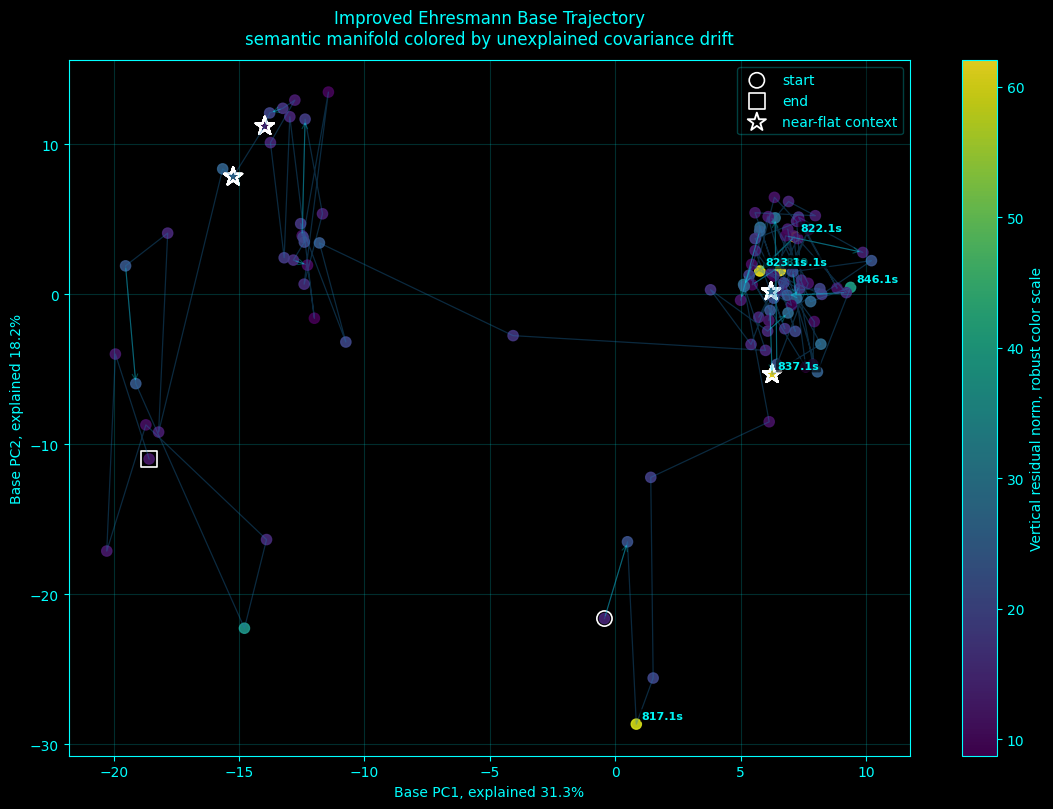

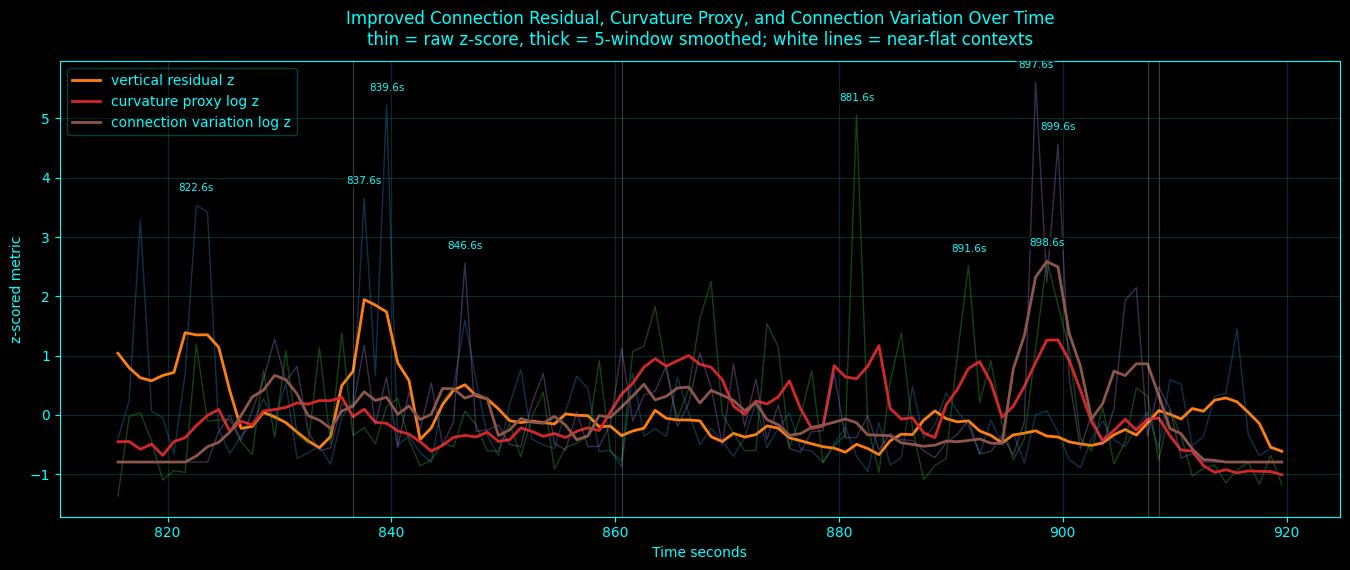

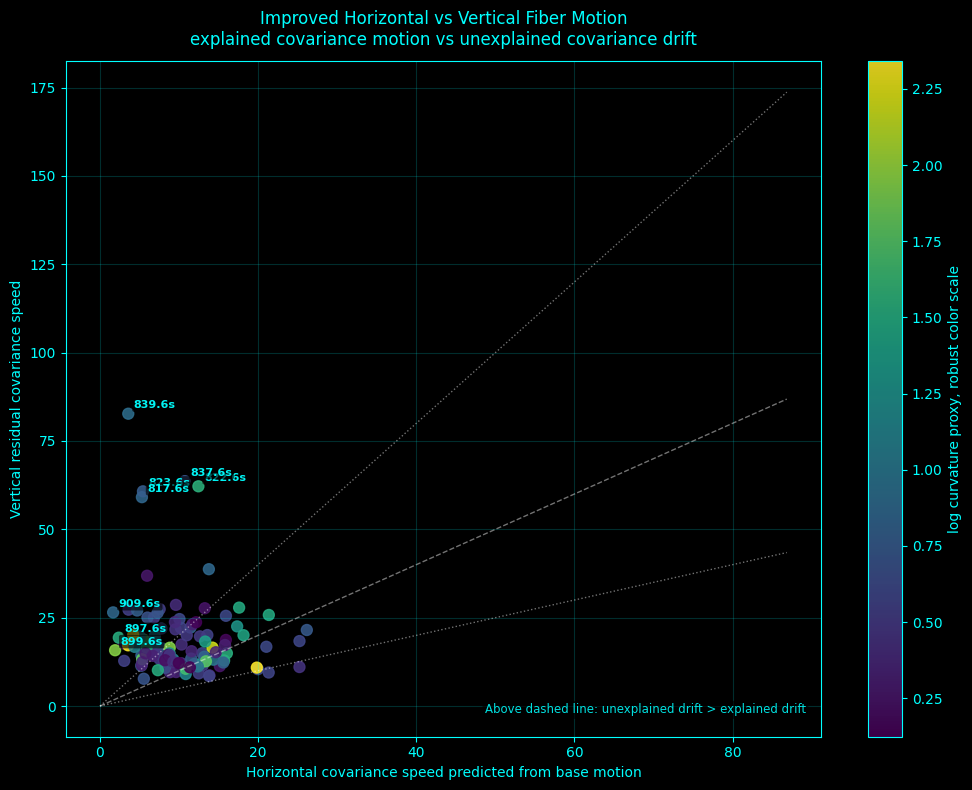

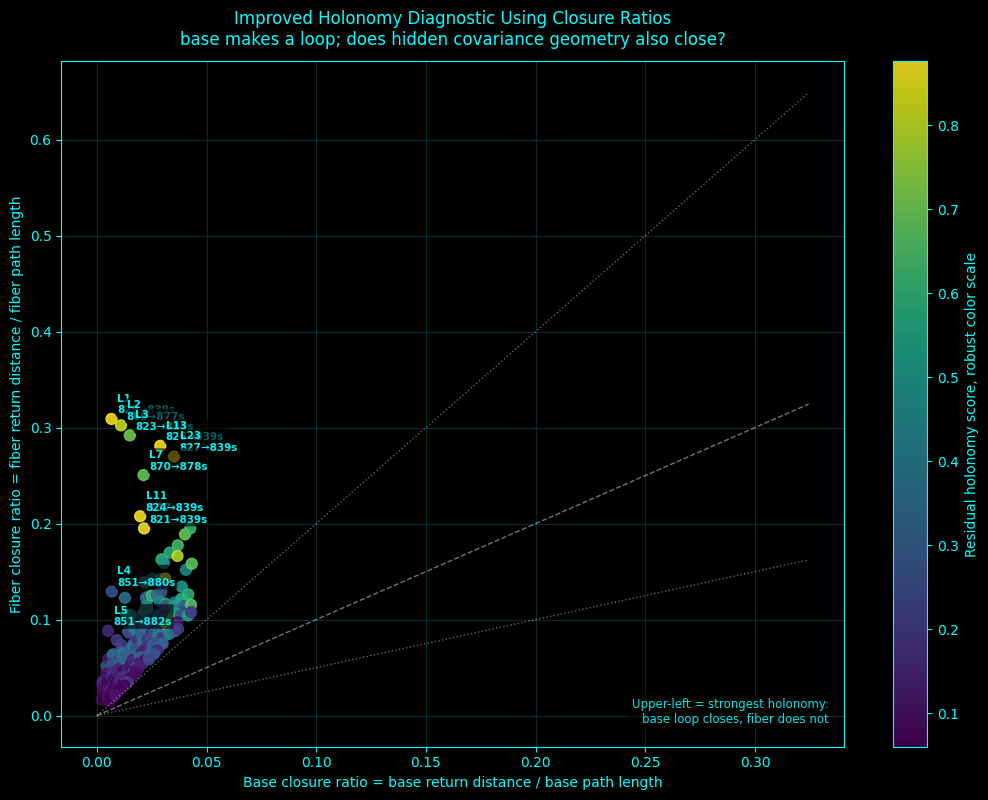

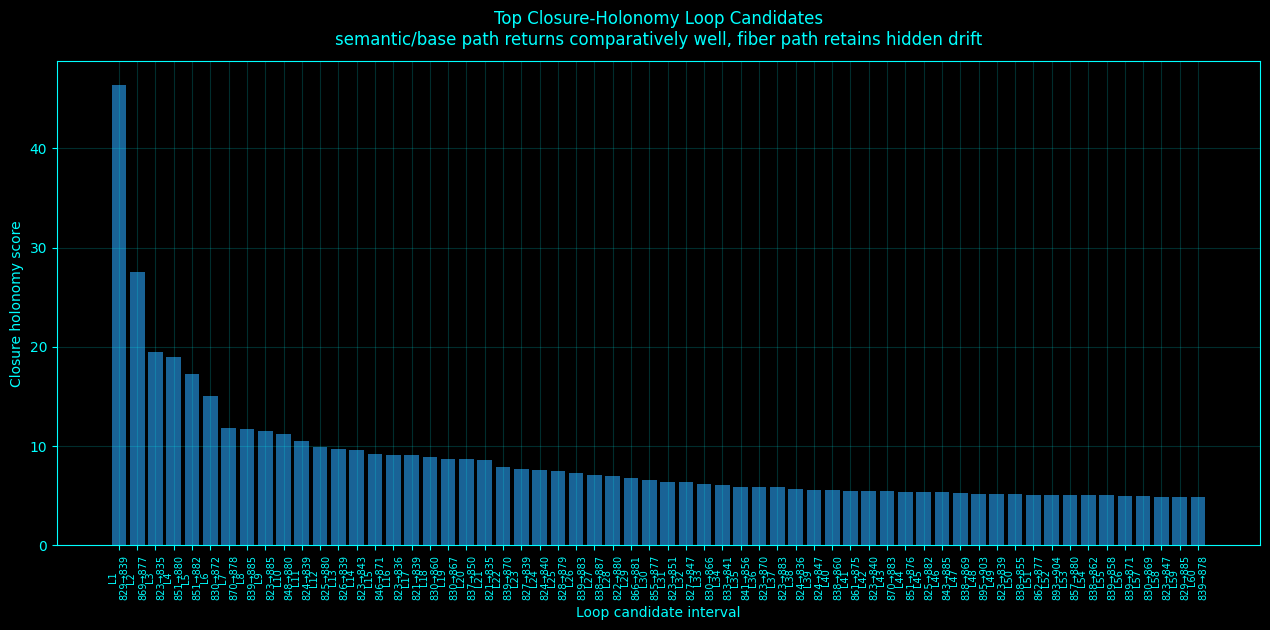

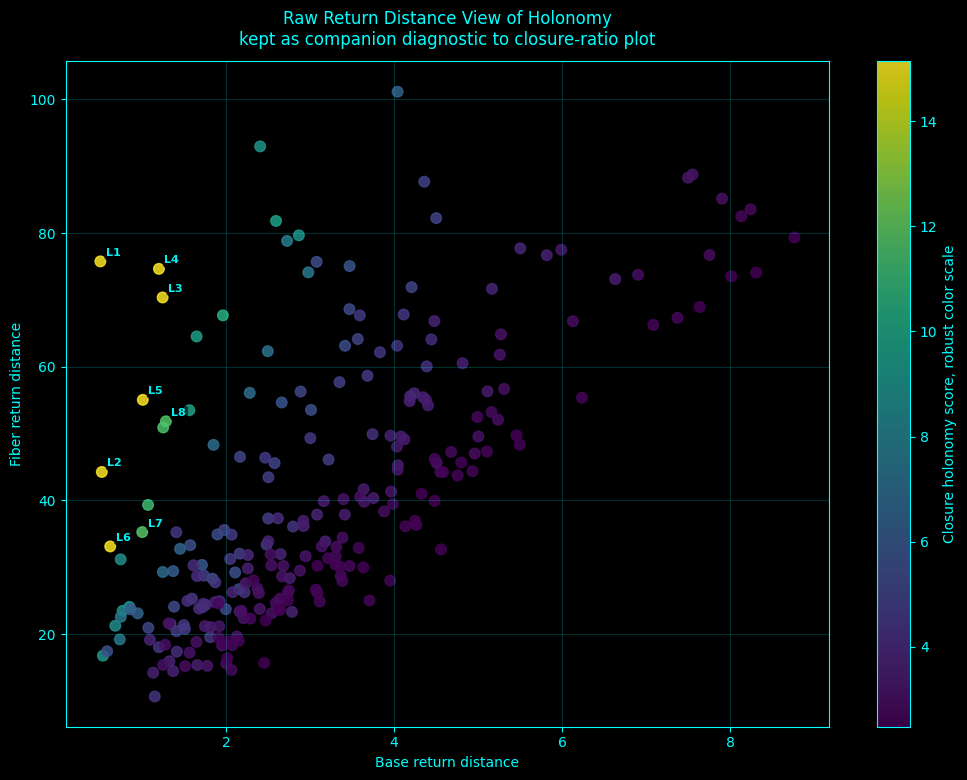

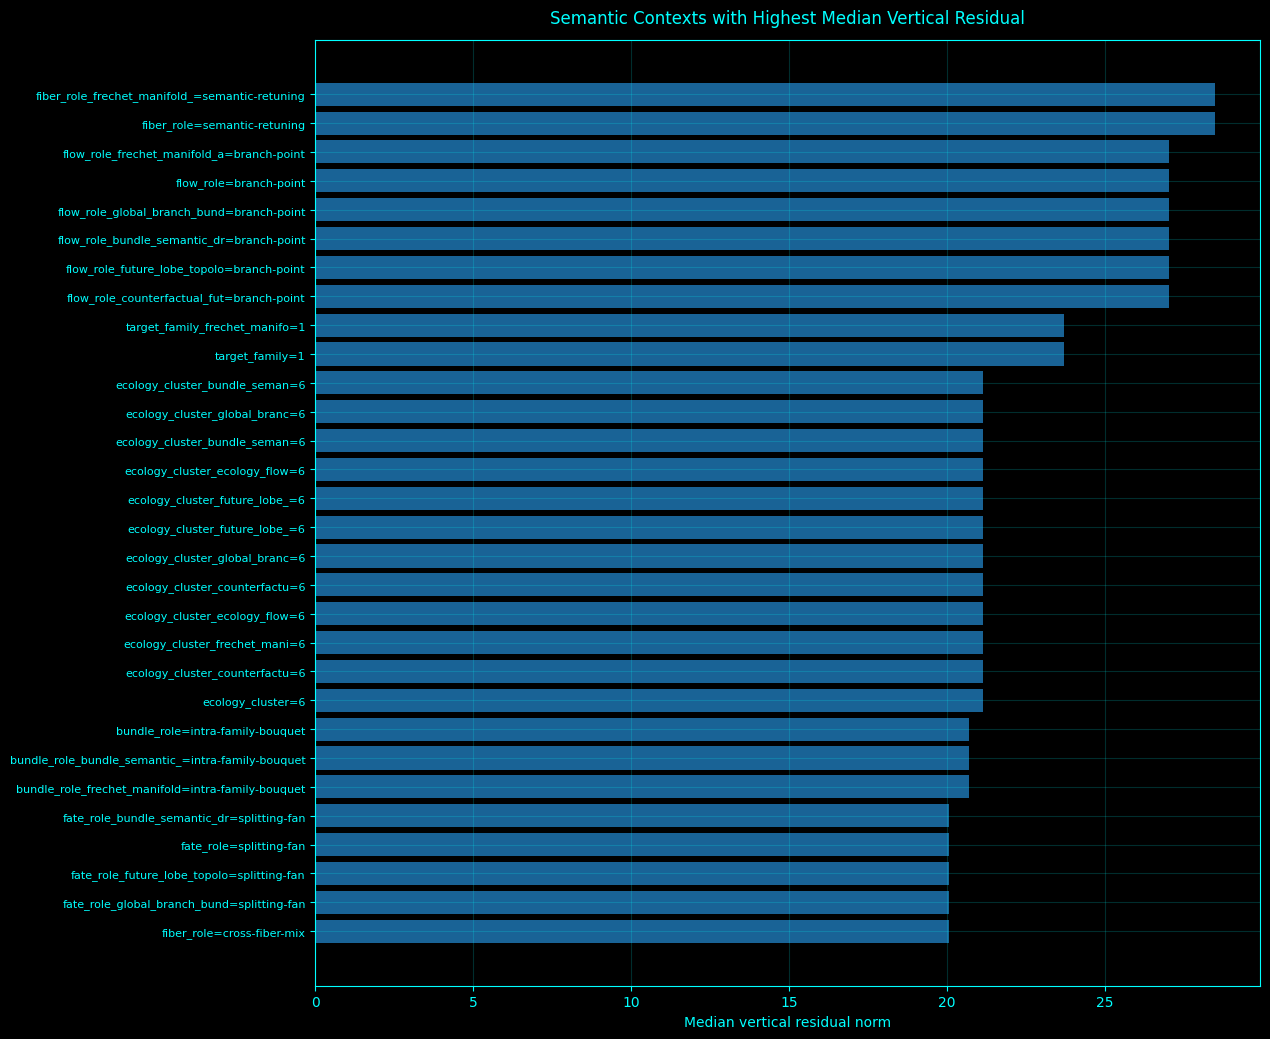

Source registry saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/ehresmann_source_registry.csv
Merged label table saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/ehresmann_epoch_label_table.csv
Connection metrics saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/connection_metrics_over_time.csv
Transport edges saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/connection_transport_edges.csv
Holonomy candidates saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/holonomy_loop_candidates.csv
Near-flat connection context saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/near_flat_connection_context.csv
Top event summary saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/top_connection_ev

In [1]:
import os
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

base_dir = globals().get("base_dir", "/home/a/projects/Complete-Neural-Signal-Analysis")
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "ehresmann_connection_atlas_v2")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

window_size_sec = 1.0
samples_per_window = int(window_size_sec * sampling_rate)

cov_reg = 1e-6
eps = 1e-12

base_dim = 3
fiber_dim = 8

ridge_lambda = 1e-3
local_window = 17
min_local_rows = 8

min_loop_gap = 8
max_loop_candidates = 250
top_loop_count = 60

BG = "black"
ACCENT = "cyan"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, grid=True):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    if grid:
        ax.grid(True, alpha=0.18, color=ACCENT)
    else:
        ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def sanitize_key(s):
    s = str(s)
    s = re.sub(r"[^A-Za-z0-9_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:96] if len(s) else "unnamed"

def short_str(x, max_len=40):
    s = str(x)
    return s if len(s) <= max_len else s[:max_len - 3] + "..."

def nearest_index(source_times, target_times):
    source_times = np.asarray(source_times, dtype=float)
    target_times = np.asarray(target_times, dtype=float)

    if len(source_times) == 0:
        raise ValueError("source_times is empty.")

    if len(source_times) == 1:
        return np.zeros(len(target_times), dtype=int)

    idx = np.searchsorted(source_times, target_times)
    idx = np.clip(idx, 1, len(source_times) - 1)

    left = idx - 1
    right = idx

    choose_right = np.abs(source_times[right] - target_times) < np.abs(source_times[left] - target_times)
    return np.where(choose_right, right, left)

def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    good = np.isfinite(x)
    if not np.any(good):
        return out
    sd = np.nanstd(x[good])
    if not np.isfinite(sd) or sd < 1e-12:
        return out
    out[good] = (x[good] - np.nanmean(x[good])) / sd
    return out

def robust_fill_numeric_frame(df):
    df = df.copy()
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        if df[c].notna().any():
            df[c] = df[c].fillna(df[c].median())
        else:
            df[c] = 0.0
    return df

def standardize_matrix(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[~np.isfinite(sd)] = 1.0
    sd[sd < 1e-12] = 1.0
    Xs = (X - mu) / sd
    Xs[~np.isfinite(Xs)] = 0.0
    return Xs, mu.ravel(), sd.ravel()

def pca_svd(X, n_components=2):
    X = np.asarray(X, dtype=float)
    Xs, mu, sd = standardize_matrix(X)

    U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
    k = min(n_components, Vt.shape[0])

    scores = U[:, :k] * S[:k]
    components = Vt[:k, :]
    explained = (S ** 2) / max(Xs.shape[0] - 1, 1)

    total = float(np.sum(explained))
    if total > 0:
        explained_ratio = explained[:k] / total
    else:
        explained_ratio = np.zeros(k)

    if k < n_components:
        scores = np.column_stack([scores, np.zeros((scores.shape[0], n_components - k))])
        components = np.vstack([components, np.zeros((n_components - k, Xs.shape[1]))])
        explained_ratio = np.concatenate([explained_ratio, np.zeros(n_components - k)])

    return scores, components, explained_ratio, mu, sd

def ridge_solve(X, Y, lam=1e-3):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ Y)

def moving_window_indices(i, n, width):
    half = width // 2
    a = max(0, i - half)
    b = min(n, i + half + 1)

    if b - a < width:
        if a == 0:
            b = min(n, width)
        elif b == n:
            a = max(0, n - width)

    return np.arange(a, b)

def annotate_top_points(ax, x, y, labels, scores, top_n=8, dx=4, dy=4, fontsize=8):
    x = np.asarray(x)
    y = np.asarray(y)
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(str)

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(scores)
    if not np.any(good):
        return

    idx_good = np.where(good)[0]
    order = idx_good[np.argsort(scores[good])[::-1]][:top_n]

    for i in order:
        ax.annotate(
            labels[i],
            xy=(x[i], y[i]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=fontsize,
            weight="bold",
            color=ACCENT,
            alpha=0.96,
            bbox=dict(
                facecolor=BG,
                edgecolor="none",
                alpha=0.62,
                boxstyle="round,pad=0.15",
            ),
            clip_on=True,
        )

def robust_scatter_limits(values, q_low=0.02, q_high=0.98):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return None, None
    lo = float(np.quantile(v, q_low))
    hi = float(np.quantile(v, q_high))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None, None
    return lo, hi

def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, floor=eps):
    vals = np.asarray(vals, dtype=float)
    vals[vals < floor] = floor
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.log(w)) @ V.T

def expm_sym(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    return (V * np.exp(w)) @ V.T

def riemannian_frechet_mean(covs, max_iter=64, tol=1e-8):
    covs = np.asarray(covs, dtype=float)
    n_mats, n, _ = covs.shape

    if n_mats == 1:
        return symmetrize(covs[0])

    G = symmetrize(np.mean(covs, axis=0))

    for _ in range(max_iter):
        G_sqrt = sqrtm_spd(G)
        G_invsqrt = invsqrtm_spd(G)

        tangent_sum = np.zeros((n, n), dtype=float)
        for C in covs:
            tangent_sum += logm_spd(G_invsqrt @ C @ G_invsqrt)

        tangent_mean = tangent_sum / n_mats
        update_norm = float(np.linalg.norm(tangent_mean, ord="fro"))

        if update_norm < tol:
            break

        G = symmetrize(G_sqrt @ expm_sym(tangent_mean) @ G_sqrt)

    return G

def log_map_spd(P, C):
    P_sqrt = sqrtm_spd(P)
    P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    return symmetrize(P_sqrt @ logm_spd(inner) @ P_sqrt)

def affine_invariant_distance(A, B):
    Binv = invsqrtm_spd(B)
    L = logm_spd(Binv @ A @ Binv)
    return float(np.linalg.norm(L, ord="fro"))

def vectorize_symmetric(A):
    idx = np.triu_indices(A.shape[0])
    return symmetrize(A)[idx]

def ensure_time_channel_layout(EEG_data, n_channels_expected=32):
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got {EEG_data.shape}")

    if EEG_data.shape[1] == n_channels_expected:
        return EEG_data
    if EEG_data.shape[0] == n_channels_expected:
        return EEG_data.T

    if EEG_data.shape[0] > EEG_data.shape[1]:
        return EEG_data

    return EEG_data.T

def segment_data(EEG_data_tc, samples_per_window):
    total_samples, n_channels = EEG_data_tc.shape
    n_windows = total_samples // samples_per_window
    trimmed = EEG_data_tc[:n_windows * samples_per_window]
    segmented = trimmed.reshape(n_windows, samples_per_window, n_channels)
    return np.transpose(segmented, (0, 2, 1))

def compute_cov_matrices(segmented_data, reg=cov_reg):
    epochs, n_channels, n_time = segmented_data.shape
    X = segmented_data - np.mean(segmented_data, axis=2, keepdims=True)
    covs = np.matmul(X, np.transpose(X, (0, 2, 1))) / max(n_time - 1, 1)
    covs += reg * np.eye(n_channels)[None, :, :]
    return 0.5 * (covs + np.transpose(covs, (0, 2, 1)))

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, n_channels_expected=32)
EEG_data = EEG_data[start_index:end_index, :]

segmented_EEG = segment_data(EEG_data, samples_per_window=samples_per_window)
covs = compute_cov_matrices(segmented_EEG, reg=cov_reg)

n_epochs = covs.shape[0]
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

epoch_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "center_time_sec": epoch_center_time,
})

print(f"Loaded {n_epochs} covariance states on SPD({covs.shape[1]}).")

candidate_label_csvs = [
    os.path.join(base_dir, "results", "continuous_motif_field_v1", "continuous_motif_field.csv"),
    os.path.join(base_dir, "results", "motif_field_ecology_atlas_v1", "motif_field_with_ecology_labels.csv"),
    os.path.join(base_dir, "results", "ecology_flow_cartography_v1", "motif_field_with_flow_roles.csv"),
    os.path.join(base_dir, "results", "counterfactual_future_cones_v1", "motif_field_with_future_cones.csv"),
    os.path.join(base_dir, "results", "future_lobe_topology_atlas_v1", "motif_field_with_lobe_topology.csv"),
    os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1", "motif_field_with_global_bundles.csv"),
    os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1", "motif_field_with_bundle_semantic_fibers.csv"),
    os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1", "bundle_relabel_phase_index.csv"),
    os.path.join(base_dir, "results", "lock_fracture_atlas_v1", "time_resolved_fracture_pressure.csv"),
    os.path.join(base_dir, "results", "semantic_hysteresis_atlas_v1", "window_hysteresis_metrics.csv"),
    os.path.join(base_dir, "results", "exit_family_atlas_v1", "late_exit_family_per_window.csv"),
    os.path.join(base_dir, "results", "launch_syntax_atlas_v2", "launch_syntax_per_event.csv"),
    os.path.join(base_dir, "results", "frechet_manifold_atlas_v1", "frechet_epoch_label_table.csv"),
]

near_flat_csvs = [
    os.path.join(base_dir, "results", "stable_episode_corridor_atlas_v1", "near_flat_episode_context.csv"),
    os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1", "near_flat_global_bundle_context.csv"),
    os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1", "near_flat_relabel_stage_context.csv"),
    os.path.join(base_dir, "results", "lock_fracture_atlas_v1", "near_flat_defect_context.csv"),
    os.path.join(base_dir, "results", "semantic_hysteresis_atlas_v1", "near_flat_hysteresis_context.csv"),
    os.path.join(base_dir, "results", "exit_family_atlas_v1", "near_flat_exit_family_context.csv"),
    os.path.join(base_dir, "results", "launch_syntax_atlas_v2", "near_flat_launch_syntax_context.csv"),
    os.path.join(base_dir, "results", "frechet_manifold_atlas_v1", "near_flat_frechet_context.csv"),
]

preferred_label_columns = [
    "motif_label",
    "dominant_motif",
    "soft_motif",
    "ecology_cluster",
    "ecology_name",
    "flow_role",
    "fate_role",
    "topology_name",
    "global_bundle",
    "bundle_role",
    "fiber_role",
    "relabel_stage",
    "fracture_role",
    "hysteresis_role",
    "exit_family",
    "target_family",
    "precursor_cluster",
    "syntax_motif",
    "launch_syntax",
]

semantic_numeric_name_hints = [
    "motif",
    "ecology",
    "flow",
    "fate",
    "topology",
    "bundle",
    "fiber",
    "future",
    "lobe",
    "branch",
    "hysteresis",
    "exit",
    "syntax",
    "launch",
    "relabel",
    "fracture",
    "drift",
    "entropy",
    "purity",
    "consensus",
    "dispersion",
    "speed",
    "pressure",
    "score",
    "radius",
    "density",
    "umap",
    "tsne",
    "mds",
    "pc",
    "coord",
    "x",
    "y",
]

merged = epoch_df.copy()
add_frames = []
source_registry = []
used_column_names = set(merged.columns)

for path in candidate_label_csvs:
    if not os.path.exists(path):
        continue

    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"Skipping unreadable CSV: {path} | {e}")
        continue

    time_col = None
    for c in ["center_time_sec", "time_sec", "event_time_sec", "fissure_time_sec", "near_flat_time_sec"]:
        if c in df.columns:
            time_col = c
            break

    if time_col is None:
        continue

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    if len(df) == 0:
        continue

    idx = nearest_index(df[time_col].values, merged["center_time_sec"].values)

    used_cols = []

    for c in df.columns:
        if c == time_col:
            continue

        is_preferred_label = c in preferred_label_columns
        is_numeric = pd.api.types.is_numeric_dtype(df[c])
        hint_match = any(h in c.lower() for h in semantic_numeric_name_hints)

        if is_preferred_label or (is_numeric and hint_match):
            used_cols.append(c)

    used_cols = sorted(set(used_cols))

    if len(used_cols) == 0:
        continue

    stem = sanitize_key(os.path.basename(os.path.dirname(path)))
    frame_dict = {}

    for c in used_cols:
        new_c = c
        if new_c in used_column_names or new_c in frame_dict:
            new_c = f"{c}__{stem}"

        counter = 2
        base_new_c = new_c
        while new_c in used_column_names or new_c in frame_dict:
            new_c = f"{base_new_c}_{counter}"
            counter += 1

        frame_dict[new_c] = df[c].values[idx]

    if frame_dict:
        add_frames.append(pd.DataFrame(frame_dict, index=merged.index))
        used_column_names.update(frame_dict.keys())

    source_registry.append({
        "csv": path,
        "time_col": time_col,
        "n_rows": len(df),
        "used_columns": ",".join(used_cols),
        "added_columns": ",".join(frame_dict.keys()),
    })

if add_frames:
    merged = pd.concat([merged] + add_frames, axis=1).copy()
else:
    merged = merged.copy()

source_registry_df = pd.DataFrame(source_registry)
source_registry_csv = os.path.join(out_dir, "ehresmann_source_registry.csv")
source_registry_df.to_csv(source_registry_csv, index=False)

merged_csv = os.path.join(out_dir, "ehresmann_epoch_label_table.csv")
merged.to_csv(merged_csv, index=False)

print(f"Merged atlas table saved: {merged_csv}")
print(f"Loaded {len(source_registry_df)} source CSV files.")
print("Column construction used pd.concat to avoid DataFrame fragmentation.")

exclude_numeric_cols = {
    "epoch_index",
    "center_time_sec",
    "time_sec",
    "event_time_sec",
    "fissure_time_sec",
    "near_flat_time_sec",
}

numeric_candidates = []

for c in merged.columns:
    if c in exclude_numeric_cols:
        continue

    s = merged[c]

    if pd.api.types.is_numeric_dtype(s):
        nunique = s.dropna().nunique()
        if nunique >= 3:
            numeric_candidates.append(c)

if len(numeric_candidates) < 2:
    cat_cols = []

    for c in merged.columns:
        if c in exclude_numeric_cols:
            continue

        nunique = merged[c].dropna().nunique()
        if 2 <= nunique <= 20:
            cat_cols.append(c)

    if cat_cols:
        dummy_frames = []
        for c in cat_cols:
            dummy_frames.append(pd.get_dummies(merged[c].astype(str), prefix=sanitize_key(c), dummy_na=False))

        dummy_df = pd.concat(dummy_frames, axis=1).copy()
        merged = pd.concat([merged, dummy_df], axis=1).copy()
        numeric_candidates.extend(dummy_df.columns.tolist())

if len(numeric_candidates) < 2:
    time_feature_df = pd.DataFrame({
        "time_base_0": zscore_safe(merged["center_time_sec"].values),
        "time_base_1": np.sin(2 * np.pi * zscore_safe(merged["center_time_sec"].values)),
        "time_base_2": np.cos(2 * np.pi * zscore_safe(merged["center_time_sec"].values)),
    }, index=merged.index)

    merged = pd.concat([merged, time_feature_df], axis=1).copy()
    numeric_candidates = ["time_base_0", "time_base_1", "time_base_2"]

base_feature_df = robust_fill_numeric_frame(merged[numeric_candidates])
base_raw = base_feature_df.values.astype(float)

B, base_components, base_explained, base_mu, base_sd = pca_svd(base_raw, n_components=base_dim)

base_coord_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "center_time_sec": epoch_center_time,
})

for k in range(base_dim):
    base_coord_df[f"base_pc{k+1}"] = B[:, k]

base_coord_csv = os.path.join(out_dir, "base_semantic_coordinates.csv")
base_coord_df.to_csv(base_coord_csv, index=False)

base_feature_importance_rows = []

for k in range(base_dim):
    load = base_components[k]
    order = np.argsort(np.abs(load))[::-1][:25]

    for rank, j in enumerate(order, start=1):
        base_feature_importance_rows.append({
            "base_pc": k + 1,
            "rank": rank,
            "feature": numeric_candidates[j],
            "loading": float(load[j]),
            "abs_loading": float(abs(load[j])),
        })

base_feature_importance_df = pd.DataFrame(base_feature_importance_rows)
base_feature_importance_csv = os.path.join(out_dir, "base_feature_loadings_top.csv")
base_feature_importance_df.to_csv(base_feature_importance_csv, index=False)

print("Base semantic manifold built.")
print("Base explained ratio:", np.round(base_explained, 4))

global_mean_cov = riemannian_frechet_mean(covs)

tangent_vecs = []
dist_to_global = []

for C in covs:
    T = log_map_spd(global_mean_cov, C)
    tangent_vecs.append(vectorize_symmetric(T))
    dist_to_global.append(affine_invariant_distance(C, global_mean_cov))

tangent_vecs = np.asarray(tangent_vecs, dtype=float)
dist_to_global = np.asarray(dist_to_global, dtype=float)

F, fiber_components, fiber_explained, fiber_mu, fiber_sd = pca_svd(tangent_vecs, n_components=fiber_dim)

fiber_coord_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "center_time_sec": epoch_center_time,
    "distance_to_global_cov_frechet_mean": dist_to_global,
})

for k in range(fiber_dim):
    fiber_coord_df[f"fiber_pc{k+1}"] = F[:, k]

fiber_coord_csv = os.path.join(out_dir, "fiber_covariance_tangent_coordinates.csv")
fiber_coord_df.to_csv(fiber_coord_csv, index=False)

print("Fiber covariance tangent space built.")
print("Fiber explained ratio:", np.round(fiber_explained, 4))

dt = window_size_sec

dB = np.diff(B, axis=0) / dt
dF = np.diff(F, axis=0) / dt

velocity_time = 0.5 * (epoch_center_time[:-1] + epoch_center_time[1:])
n_vel = dB.shape[0]

A_global = ridge_solve(dB, dF, lam=ridge_lambda)
dF_horizontal_global = dB @ A_global
dF_vertical_global = dF - dF_horizontal_global

A_local = np.zeros((n_vel, base_dim, fiber_dim), dtype=float)
dF_horizontal = np.zeros_like(dF)
dF_vertical = np.zeros_like(dF)

for i in range(n_vel):
    idx = moving_window_indices(i, n_vel, local_window)

    if len(idx) >= min_local_rows:
        try:
            A_i = ridge_solve(dB[idx], dF[idx], lam=ridge_lambda)
        except Exception:
            A_i = A_global.copy()
    else:
        A_i = A_global.copy()

    A_local[i] = A_i
    dF_horizontal[i] = dB[i] @ A_i
    dF_vertical[i] = dF[i] - dF_horizontal[i]

base_speed = np.linalg.norm(dB, axis=1)
fiber_speed = np.linalg.norm(dF, axis=1)
horizontal_speed = np.linalg.norm(dF_horizontal, axis=1)
vertical_residual_norm = np.linalg.norm(dF_vertical, axis=1)

parallel_transport_error = vertical_residual_norm / (fiber_speed + eps)
horizontal_fraction = horizontal_speed / (fiber_speed + horizontal_speed + eps)
vertical_fraction = vertical_residual_norm / (fiber_speed + horizontal_speed + vertical_residual_norm + eps)
vertical_to_horizontal_ratio = vertical_residual_norm / (horizontal_speed + eps)

connection_norm = np.linalg.norm(A_local.reshape(n_vel, -1), axis=1)

connection_variation = np.zeros(n_vel, dtype=float)
curvature_proxy = np.zeros(n_vel, dtype=float)
base_turn_area = np.zeros(n_vel, dtype=float)
horizontal_turn_norm = np.zeros(n_vel, dtype=float)

for i in range(1, n_vel):
    connection_variation[i] = np.linalg.norm(A_local[i] - A_local[i - 1], ord="fro") / (np.linalg.norm(dB[i]) + eps)

    u = dB[i - 1]
    v = dB[i]

    wedge_sq = max(float(np.dot(u, u) * np.dot(v, v) - np.dot(u, v) ** 2), 0.0)
    base_turn_area[i] = math.sqrt(wedge_sq)

    horizontal_turn_norm[i] = np.linalg.norm(dF_horizontal[i] - dF_horizontal[i - 1])
    curvature_proxy[i] = horizontal_turn_norm[i] / (base_turn_area[i] + eps)

curvature_proxy_log = np.log1p(curvature_proxy)
connection_variation_log = np.log1p(connection_variation)

connection_df = pd.DataFrame({
    "edge_index": np.arange(n_vel),
    "start_epoch_index": np.arange(n_vel),
    "end_epoch_index": np.arange(1, n_epochs),
    "center_time_sec": velocity_time,
    "start_time_sec": epoch_center_time[:-1],
    "end_time_sec": epoch_center_time[1:],
    "base_speed": base_speed,
    "fiber_speed": fiber_speed,
    "horizontal_speed": horizontal_speed,
    "vertical_residual_norm": vertical_residual_norm,
    "parallel_transport_error": parallel_transport_error,
    "horizontal_fraction": horizontal_fraction,
    "vertical_fraction": vertical_fraction,
    "vertical_to_horizontal_ratio": vertical_to_horizontal_ratio,
    "connection_norm": connection_norm,
    "connection_variation": connection_variation,
    "connection_variation_log": connection_variation_log,
    "base_turn_area": base_turn_area,
    "horizontal_turn_norm": horizontal_turn_norm,
    "curvature_proxy": curvature_proxy,
    "curvature_proxy_log": curvature_proxy_log,
})

base_vel_cols = pd.DataFrame(
    {f"base_velocity_pc{k+1}": dB[:, k] for k in range(base_dim)},
    index=connection_df.index,
)

fiber_vel_cols = pd.DataFrame(
    {
        **{f"fiber_velocity_pc{k+1}": dF[:, k] for k in range(fiber_dim)},
        **{f"horizontal_fiber_velocity_pc{k+1}": dF_horizontal[:, k] for k in range(fiber_dim)},
        **{f"vertical_residual_pc{k+1}": dF_vertical[:, k] for k in range(fiber_dim)},
    },
    index=connection_df.index,
)

connection_df = pd.concat([connection_df, base_vel_cols, fiber_vel_cols], axis=1).copy()

label_context_cols = [
    c for c in merged.columns
    if c not in exclude_numeric_cols
    and (
        c in preferred_label_columns
        or any(c.startswith(prefix + "__") for prefix in preferred_label_columns)
    )
]

if label_context_cols:
    idx = nearest_index(merged["center_time_sec"].values, connection_df["center_time_sec"].values)
    label_context_df = merged[label_context_cols].iloc[idx].reset_index(drop=True)
    connection_df = pd.concat([connection_df.reset_index(drop=True), label_context_df], axis=1).copy()

connection_metrics_csv = os.path.join(out_dir, "connection_metrics_over_time.csv")
connection_df.to_csv(connection_metrics_csv, index=False)

transport_edges_df = connection_df[
    [
        "edge_index",
        "start_epoch_index",
        "end_epoch_index",
        "start_time_sec",
        "end_time_sec",
        "base_speed",
        "fiber_speed",
        "horizontal_speed",
        "vertical_residual_norm",
        "parallel_transport_error",
        "vertical_to_horizontal_ratio",
        "connection_norm",
        "connection_variation_log",
        "curvature_proxy_log",
    ]
].copy()

transport_edges_csv = os.path.join(out_dir, "connection_transport_edges.csv")
transport_edges_df.to_csv(transport_edges_csv, index=False)

np.savez_compressed(
    os.path.join(out_dir, "local_connection_matrices.npz"),
    A_global=A_global,
    A_local=A_local,
    base_components=base_components,
    base_explained=base_explained,
    base_mu=base_mu,
    base_sd=base_sd,
    fiber_components=fiber_components,
    fiber_explained=fiber_explained,
    fiber_mu=fiber_mu,
    fiber_sd=fiber_sd,
    global_mean_cov=global_mean_cov,
)

pair_rows = []

for i in range(n_epochs):
    for j in range(i + min_loop_gap, n_epochs):
        base_return_distance = float(np.linalg.norm(B[j] - B[i]))
        fiber_return_distance = float(np.linalg.norm(F[j] - F[i]))

        base_steps = np.linalg.norm(np.diff(B[i:j + 1], axis=0), axis=1)
        fiber_steps = np.linalg.norm(np.diff(F[i:j + 1], axis=0), axis=1)

        path_base_length = float(np.sum(base_steps))
        path_fiber_length = float(np.sum(fiber_steps))

        residual_segment = dF_vertical[i:j]
        horizontal_segment = dF_horizontal[i:j]

        vertical_integral_vec = np.sum(residual_segment, axis=0) * dt
        horizontal_integral_vec = np.sum(horizontal_segment, axis=0) * dt

        vertical_integral_norm = float(np.linalg.norm(vertical_integral_vec))
        horizontal_integral_norm = float(np.linalg.norm(horizontal_integral_vec))

        mean_curvature_log = float(np.nanmean(curvature_proxy_log[i:j])) if j > i else np.nan
        mean_connection_error = float(np.nanmean(parallel_transport_error[i:j])) if j > i else np.nan

        base_closure_ratio = base_return_distance / (path_base_length + eps)
        fiber_closure_ratio = fiber_return_distance / (path_fiber_length + eps)

        holonomy_score = fiber_return_distance / (base_return_distance + 0.10 * path_base_length + eps)
        residual_holonomy_score = vertical_integral_norm / (path_base_length + eps)
        closure_holonomy_score = fiber_closure_ratio / (base_closure_ratio + eps)

        pair_rows.append({
            "start_epoch_index": i,
            "end_epoch_index": j,
            "start_time_sec": float(epoch_center_time[i]),
            "end_time_sec": float(epoch_center_time[j]),
            "duration_sec": float(epoch_center_time[j] - epoch_center_time[i]),
            "base_return_distance": base_return_distance,
            "fiber_return_distance": fiber_return_distance,
            "base_path_length": path_base_length,
            "fiber_path_length": path_fiber_length,
            "base_closure_ratio": base_closure_ratio,
            "fiber_closure_ratio": fiber_closure_ratio,
            "vertical_integral_norm": vertical_integral_norm,
            "horizontal_integral_norm": horizontal_integral_norm,
            "mean_curvature_proxy_log": mean_curvature_log,
            "mean_parallel_transport_error": mean_connection_error,
            "holonomy_score": holonomy_score,
            "residual_holonomy_score": residual_holonomy_score,
            "closure_holonomy_score": closure_holonomy_score,
        })

loop_df_all = pd.DataFrame(pair_rows)

if len(loop_df_all):
    close_threshold = loop_df_all["base_closure_ratio"].quantile(0.25)

    loop_df = (
        loop_df_all[loop_df_all["base_closure_ratio"] <= close_threshold]
        .sort_values(
            ["closure_holonomy_score", "residual_holonomy_score", "fiber_return_distance"],
            ascending=[False, False, False],
        )
        .head(max_loop_candidates)
        .reset_index(drop=True)
    )

    loop_df["loop_rank"] = np.arange(1, len(loop_df) + 1)
else:
    loop_df = pd.DataFrame()

holonomy_csv = os.path.join(out_dir, "holonomy_loop_candidates.csv")
loop_df.to_csv(holonomy_csv, index=False)

near_rows = []

for path in near_flat_csvs:
    if not os.path.exists(path):
        continue

    try:
        nf = pd.read_csv(path)
    except Exception:
        continue

    time_col = None
    for c in ["center_time_sec", "time_sec", "event_time_sec", "near_flat_time_sec"]:
        if c in nf.columns:
            time_col = c
            break

    if time_col is None:
        continue

    nf = nf.dropna(subset=[time_col]).copy()

    if len(nf) == 0:
        continue

    idxs = nearest_index(connection_df["center_time_sec"].values, nf[time_col].values)

    for row_i, edge_i in enumerate(idxs):
        src_time = float(nf[time_col].values[row_i])
        r = connection_df.iloc[int(edge_i)]

        near_rows.append({
            "source_csv": path,
            "source_row": int(row_i),
            "event_time_sec": src_time,
            "nearest_edge_index": int(r["edge_index"]),
            "nearest_connection_time_sec": float(r["center_time_sec"]),
            "base_speed": float(r["base_speed"]),
            "fiber_speed": float(r["fiber_speed"]),
            "horizontal_speed": float(r["horizontal_speed"]),
            "vertical_residual_norm": float(r["vertical_residual_norm"]),
            "vertical_to_horizontal_ratio": float(r["vertical_to_horizontal_ratio"]),
            "parallel_transport_error": float(r["parallel_transport_error"]),
            "connection_norm": float(r["connection_norm"]),
            "connection_variation_log": float(r["connection_variation_log"]),
            "curvature_proxy_log": float(r["curvature_proxy_log"]),
        })

near_connection_df = pd.DataFrame(near_rows)
near_connection_csv = os.path.join(out_dir, "near_flat_connection_context.csv")
near_connection_df.to_csv(near_connection_csv, index=False)

event_rows = []

top_event_specs = [
    ("vertical_residual", "vertical_residual_norm"),
    ("curvature_proxy", "curvature_proxy_log"),
    ("connection_variation", "connection_variation_log"),
    ("vertical_to_horizontal", "vertical_to_horizontal_ratio"),
    ("parallel_transport_error", "parallel_transport_error"),
]

for event_type, col in top_event_specs:
    top = connection_df.sort_values(col, ascending=False).head(12)
    for rank, (_, r) in enumerate(top.iterrows(), start=1):
        event_rows.append({
            "event_type": event_type,
            "rank": rank,
            "edge_index": int(r["edge_index"]),
            "center_time_sec": float(r["center_time_sec"]),
            "metric_column": col,
            "metric_value": float(r[col]),
            "base_speed": float(r["base_speed"]),
            "fiber_speed": float(r["fiber_speed"]),
            "horizontal_speed": float(r["horizontal_speed"]),
            "vertical_residual_norm": float(r["vertical_residual_norm"]),
            "curvature_proxy_log": float(r["curvature_proxy_log"]),
            "connection_variation_log": float(r["connection_variation_log"]),
            "vertical_to_horizontal_ratio": float(r["vertical_to_horizontal_ratio"]),
        })

event_summary_df = pd.DataFrame(event_rows)
event_summary_csv = os.path.join(out_dir, "top_connection_event_summary.csv")
event_summary_df.to_csv(event_summary_csv, index=False)

near_times = []
if len(near_connection_df):
    near_times = near_connection_df["nearest_connection_time_sec"].dropna().unique().tolist()

top_resid_idx = np.argsort(vertical_residual_norm)[::-1][:8]
top_curv_idx = np.argsort(curvature_proxy_log)[::-1][:8]
top_var_idx = np.argsort(connection_variation_log)[::-1][:8]
top_ratio_idx = np.argsort(vertical_to_horizontal_ratio)[::-1][:8]

fig, ax = plt.subplots(figsize=(11.4, 8.2))

color_values = np.r_[vertical_residual_norm, vertical_residual_norm[-1] if len(vertical_residual_norm) else 0]
vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

sc = ax.scatter(
    B[:, 0],
    B[:, 1],
    c=color_values,
    s=54,
    alpha=0.88,
    vmin=vmin,
    vmax=vmax,
)

ax.plot(B[:, 0], B[:, 1], linewidth=0.9, alpha=0.35)

if n_epochs >= 2:
    ax.scatter(B[0, 0], B[0, 1], s=120, marker="o", facecolors="none", edgecolors="white", linewidths=1.2, label="start")
    ax.scatter(B[-1, 0], B[-1, 1], s=140, marker="s", facecolors="none", edgecolors="white", linewidths=1.2, label="end")

    step = max(1, n_epochs // 14)
    for i in range(0, n_epochs - 1, step):
        ax.annotate(
            "",
            xy=(B[i + 1, 0], B[i + 1, 1]),
            xytext=(B[i, 0], B[i, 1]),
            arrowprops=dict(arrowstyle="->", color=ACCENT, alpha=0.28, lw=0.8),
        )

if len(near_connection_df):
    near_epoch_idx = nearest_index(epoch_center_time, near_connection_df["event_time_sec"].values)
    ax.scatter(
        B[near_epoch_idx, 0],
        B[near_epoch_idx, 1],
        s=190,
        marker="*",
        facecolors="none",
        edgecolors="white",
        linewidths=1.35,
        label="near-flat context",
    )

point_labels = np.array([f"{t:.1f}s" for t in epoch_center_time])
annotate_scores = np.r_[vertical_residual_norm, vertical_residual_norm[-1] if len(vertical_residual_norm) else 0]
annotate_top_points(ax, B[:, 0], B[:, 1], point_labels, annotate_scores, top_n=6, fontsize=8)

style_ax(ax)
ax.set_title(
    "Improved Ehresmann Base Trajectory\nsemantic manifold colored by unexplained covariance drift",
    pad=12,
)
ax.set_xlabel(f"Base PC1, explained {100 * base_explained[0]:.1f}%")
ax.set_ylabel(f"Base PC2, explained {100 * base_explained[1]:.1f}%")

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(colors=ACCENT)
cbar.set_label("Vertical residual norm, robust color scale", color=ACCENT)

ax.legend(framealpha=0.25, loc="best")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "improved_base_trajectory_vertical_residual.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(13.6, 5.8))

series_specs = [
    ("vertical residual z", "vertical_residual_norm"),
    ("curvature proxy log z", "curvature_proxy_log"),
    ("connection variation log z", "connection_variation_log"),
]

for label, col in series_specs:
    y = zscore_safe(connection_df[col].values)
    smooth = pd.Series(y).rolling(5, center=True, min_periods=1).mean().values

    ax.plot(connection_df["center_time_sec"], y, linewidth=1.0, alpha=0.42)
    ax.plot(connection_df["center_time_sec"], smooth, label=label, linewidth=2.0)

for t in near_times:
    ax.axvline(t, color="white", alpha=0.23, linewidth=0.85)

def annotate_series_peaks(col, color_label, top_n=4, y_offset=0.18):
    y = zscore_safe(connection_df[col].values)
    order = np.argsort(y)[::-1][:top_n]
    for i in order:
        ax.annotate(
            f"{connection_df['center_time_sec'].iloc[i]:.1f}s",
            xy=(connection_df["center_time_sec"].iloc[i], y[i]),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=7.5,
            color=ACCENT,
            bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.14"),
            clip_on=True,
        )

annotate_series_peaks("vertical_residual_norm", "vertical", top_n=3)
annotate_series_peaks("curvature_proxy_log", "curvature", top_n=3)
annotate_series_peaks("connection_variation_log", "variation", top_n=3)

style_ax(ax)
ax.set_title(
    "Improved Connection Residual, Curvature Proxy, and Connection Variation Over Time\n"
    "thin = raw z-score, thick = 5-window smoothed; white lines = near-flat contexts",
    pad=12,
)
ax.set_xlabel("Time seconds")
ax.set_ylabel("z-scored metric")
ax.legend(framealpha=0.25, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "improved_connection_metrics_over_time.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10.3, 8.0))

color_values = connection_df["curvature_proxy_log"].values
vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

sc = ax.scatter(
    horizontal_speed,
    vertical_residual_norm,
    c=color_values,
    s=62,
    alpha=0.86,
    vmin=vmin,
    vmax=vmax,
)

max_axis = float(np.nanmax([np.nanmax(horizontal_speed), np.nanmax(vertical_residual_norm)]))
if np.isfinite(max_axis) and max_axis > 0:
    xs = np.linspace(0, max_axis * 1.05, 200)

    ax.plot(xs, xs, linestyle="--", color="white", alpha=0.45, linewidth=1.0)
    ax.plot(xs, 2.0 * xs, linestyle=":", color="white", alpha=0.45, linewidth=1.0)
    ax.plot(xs, 0.5 * xs, linestyle=":", color="white", alpha=0.45, linewidth=1.0)

    ax.text(
        0.98,
        0.03,
        "Above dashed line: unexplained drift > explained drift",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8.5,
        alpha=0.88,
        bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.20"),
    )

labels = np.array([f"{t:.1f}s" for t in connection_df["center_time_sec"].values])
score = zscore_safe(vertical_residual_norm) + zscore_safe(vertical_to_horizontal_ratio) + 0.5 * zscore_safe(curvature_proxy_log)
annotate_top_points(ax, horizontal_speed, vertical_residual_norm, labels, score, top_n=8, fontsize=8)

style_ax(ax)
ax.set_title(
    "Improved Horizontal vs Vertical Fiber Motion\nexplained covariance motion vs unexplained covariance drift",
    pad=12,
)
ax.set_xlabel("Horizontal covariance speed predicted from base motion")
ax.set_ylabel("Vertical residual covariance speed")

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(colors=ACCENT)
cbar.set_label("log curvature proxy, robust color scale", color=ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "improved_horizontal_vs_vertical_fiber_motion.png"), dpi=260, bbox_inches="tight")
plt.show()

if len(loop_df):
    plot_loop_df = loop_df.copy()

    fig, ax = plt.subplots(figsize=(10.6, 8.1))

    color_values = plot_loop_df["residual_holonomy_score"].values
    vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

    sc = ax.scatter(
        plot_loop_df["base_closure_ratio"],
        plot_loop_df["fiber_closure_ratio"],
        c=color_values,
        s=62,
        alpha=0.86,
        vmin=vmin,
        vmax=vmax,
    )

    max_axis = float(np.nanmax([plot_loop_df["base_closure_ratio"].max(), plot_loop_df["fiber_closure_ratio"].max()]))
    if np.isfinite(max_axis) and max_axis > 0:
        xs = np.linspace(0, max_axis * 1.05, 200)
        ax.plot(xs, xs, linestyle="--", color="white", alpha=0.45, linewidth=1.0)
        ax.plot(xs, 2.0 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)
        ax.plot(xs, 0.5 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)

    labels = np.array([
        f"L{int(r.loop_rank)}\n{r.start_time_sec:.0f}→{r.end_time_sec:.0f}s"
        for _, r in plot_loop_df.iterrows()
    ])

    score = (
        zscore_safe(plot_loop_df["closure_holonomy_score"].values)
        + zscore_safe(plot_loop_df["residual_holonomy_score"].values)
        - 0.5 * zscore_safe(plot_loop_df["base_closure_ratio"].values)
    )

    annotate_top_points(
        ax,
        plot_loop_df["base_closure_ratio"].values,
        plot_loop_df["fiber_closure_ratio"].values,
        labels,
        score,
        top_n=10,
        fontsize=7.5,
    )

    style_ax(ax)
    ax.set_title(
        "Improved Holonomy Diagnostic Using Closure Ratios\n"
        "base makes a loop; does hidden covariance geometry also close?",
        pad=12,
    )
    ax.set_xlabel("Base closure ratio = base return distance / base path length")
    ax.set_ylabel("Fiber closure ratio = fiber return distance / fiber path length")

    ax.text(
        0.98,
        0.03,
        "Upper-left = strongest holonomy:\nbase loop closes, fiber does not",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8.5,
        alpha=0.90,
        bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.20"),
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(colors=ACCENT)
    cbar.set_label("Residual holonomy score, robust color scale", color=ACCENT)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_holonomy_closure_ratio_diagnostic.png"), dpi=260, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(12.8, 6.4))

    top_loop_df = loop_df.head(min(top_loop_count, len(loop_df))).copy()

    labels = [
        f"L{int(r.loop_rank)}\n{int(r.start_time_sec)}→{int(r.end_time_sec)}"
        for _, r in top_loop_df.iterrows()
    ]

    ax.bar(
        np.arange(len(top_loop_df)),
        top_loop_df["closure_holonomy_score"].values,
        alpha=0.84,
    )

    ax.set_xticks(np.arange(len(top_loop_df)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)

    style_ax(ax)
    ax.set_title(
        "Top Closure-Holonomy Loop Candidates\n"
        "semantic/base path returns comparatively well, fiber path retains hidden drift",
        pad=12,
    )
    ax.set_xlabel("Loop candidate interval")
    ax.set_ylabel("Closure holonomy score")

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_top_closure_holonomy_loop_candidates.png"), dpi=260, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10.4, 7.9))

    color_values = plot_loop_df["closure_holonomy_score"].values
    vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

    sc = ax.scatter(
        plot_loop_df["base_return_distance"],
        plot_loop_df["fiber_return_distance"],
        c=color_values,
        s=58,
        alpha=0.84,
        vmin=vmin,
        vmax=vmax,
    )

    labels = np.array([
        f"L{int(r.loop_rank)}"
        for _, r in plot_loop_df.iterrows()
    ])

    score = zscore_safe(plot_loop_df["closure_holonomy_score"].values)
    annotate_top_points(
        ax,
        plot_loop_df["base_return_distance"].values,
        plot_loop_df["fiber_return_distance"].values,
        labels,
        score,
        top_n=8,
        fontsize=8,
    )

    style_ax(ax)
    ax.set_title(
        "Raw Return Distance View of Holonomy\n"
        "kept as companion diagnostic to closure-ratio plot",
        pad=12,
    )
    ax.set_xlabel("Base return distance")
    ax.set_ylabel("Fiber return distance")

    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(colors=ACCENT)
    cbar.set_label("Closure holonomy score, robust color scale", color=ACCENT)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_holonomy_raw_return_distance_companion.png"), dpi=260, bbox_inches="tight")
    plt.show()

summary_metric_cols = [
    "base_speed",
    "fiber_speed",
    "horizontal_speed",
    "vertical_residual_norm",
    "vertical_to_horizontal_ratio",
    "parallel_transport_error",
    "curvature_proxy_log",
    "connection_variation_log",
]

possible_context_cols = [
    c for c in label_context_cols
    if c in connection_df.columns
    and connection_df[c].dropna().nunique() >= 2
    and connection_df[c].dropna().nunique() <= 20
]

context_summary_rows = []

for c in possible_context_cols:
    for value, sub in connection_df.groupby(c):
        if len(sub) < 3:
            continue

        row = {
            "context_column": c,
            "context_value": value,
            "n_edges": int(len(sub)),
        }

        for m in summary_metric_cols:
            row[f"median_{m}"] = float(np.nanmedian(sub[m].values))
            row[f"mean_{m}"] = float(np.nanmean(sub[m].values))

        context_summary_rows.append(row)

context_summary_df = pd.DataFrame(context_summary_rows)
context_summary_csv = os.path.join(out_dir, "connection_context_summary.csv")
context_summary_df.to_csv(context_summary_csv, index=False)

if len(context_summary_df):
    plot_df = (
        context_summary_df
        .sort_values("median_vertical_residual_norm", ascending=False)
        .head(30)
        .copy()
    )

    plot_df["label"] = (
        plot_df["context_column"].astype(str).map(lambda x: sanitize_key(x)[:28])
        + "="
        + plot_df["context_value"].astype(str).map(lambda x: str(x)[:24])
    )

    fig, ax = plt.subplots(figsize=(12.8, max(6.0, 0.35 * len(plot_df))))

    ax.barh(
        np.arange(len(plot_df)),
        plot_df["median_vertical_residual_norm"].values,
        alpha=0.84,
    )

    ax.set_yticks(np.arange(len(plot_df)))
    ax.set_yticklabels(plot_df["label"].values, fontsize=8)
    ax.invert_yaxis()

    style_ax(ax)
    ax.set_title("Semantic Contexts with Highest Median Vertical Residual", pad=12)
    ax.set_xlabel("Median vertical residual norm")

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_context_high_vertical_residual.png"), dpi=260, bbox_inches="tight")
    plt.show()

near_stats = {}

if len(near_connection_df):
    near_stats = {
        "n_near_flat_contexts": int(len(near_connection_df)),
        "median_near_flat_vertical_residual": float(near_connection_df["vertical_residual_norm"].median()),
        "median_near_flat_vertical_to_horizontal_ratio": float(near_connection_df["vertical_to_horizontal_ratio"].median()),
        "median_near_flat_parallel_transport_error": float(near_connection_df["parallel_transport_error"].median()),
        "median_near_flat_curvature_proxy_log": float(near_connection_df["curvature_proxy_log"].median()),
    }

summary_txt = os.path.join(out_dir, "ehresmann_summary.txt")

top_resid = connection_df.sort_values("vertical_residual_norm", ascending=False).head(12)
top_curv = connection_df.sort_values("curvature_proxy_log", ascending=False).head(12)
top_conn_var = connection_df.sort_values("connection_variation_log", ascending=False).head(12)
top_ratio = connection_df.sort_values("vertical_to_horizontal_ratio", ascending=False).head(12)

with open(summary_txt, "w") as f:
    f.write("Empirical Ehresmann Connection Atlas v2\n")
    f.write("======================================\n\n")

    f.write("Conceptual mapping:\n")
    f.write("  Base space  = semantic / motif / ecology manifold built from existing atlas features.\n")
    f.write("  Fiber space = covariance tangent geometry around the global SPD Frechet mean.\n")
    f.write("  Connection  = local ridge map predicting fiber velocity from base velocity.\n")
    f.write("  Vertical residual = covariance motion not explained by base motion.\n")
    f.write("  Curvature proxy = sharp change in horizontal lift when the base trajectory bends.\n")
    f.write("  Holonomy proxy = hidden covariance drift when the base path approximately closes.\n\n")

    f.write(f"n_epochs = {n_epochs}\n")
    f.write(f"n_connection_edges = {n_vel}\n")
    f.write(f"base_dim = {base_dim}\n")
    f.write(f"fiber_dim = {fiber_dim}\n")
    f.write(f"ridge_lambda = {ridge_lambda}\n")
    f.write(f"local_window = {local_window}\n")
    f.write("Column building fix: merged atlas columns were collected into DataFrames and joined with pd.concat, avoiding frame fragmentation.\n\n")

    f.write("Base explained ratios:\n")
    for i, val in enumerate(base_explained, start=1):
        f.write(f"  base_pc{i}: {val:.6f}\n")

    f.write("\nFiber explained ratios:\n")
    for i, val in enumerate(fiber_explained, start=1):
        f.write(f"  fiber_pc{i}: {val:.6f}\n")

    f.write("\nGlobal connection summary:\n")
    f.write(f"  median_base_speed = {np.nanmedian(base_speed):.6f}\n")
    f.write(f"  median_fiber_speed = {np.nanmedian(fiber_speed):.6f}\n")
    f.write(f"  median_horizontal_speed = {np.nanmedian(horizontal_speed):.6f}\n")
    f.write(f"  median_vertical_residual_norm = {np.nanmedian(vertical_residual_norm):.6f}\n")
    f.write(f"  median_vertical_to_horizontal_ratio = {np.nanmedian(vertical_to_horizontal_ratio):.6f}\n")
    f.write(f"  median_parallel_transport_error = {np.nanmedian(parallel_transport_error):.6f}\n")
    f.write(f"  median_curvature_proxy_log = {np.nanmedian(curvature_proxy_log):.6f}\n")
    f.write(f"  median_connection_variation_log = {np.nanmedian(connection_variation_log):.6f}\n\n")

    if near_stats:
        f.write("Near-flat connection context summary:\n")
        for k, v in near_stats.items():
            f.write(f"  {k} = {v}\n")
        f.write("\n")

    f.write("Top vertical residual moments:\n")
    for _, r in top_resid.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"ratio={r['vertical_to_horizontal_ratio']:.6f} | "
            f"parallel_error={r['parallel_transport_error']:.6f} | "
            f"curv_log={r['curvature_proxy_log']:.6f}\n"
        )

    f.write("\nTop curvature proxy moments:\n")
    for _, r in top_curv.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"curv_log={r['curvature_proxy_log']:.6f} | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"base_turn_area={r['base_turn_area']:.6f}\n"
        )

    f.write("\nTop connection variation moments:\n")
    for _, r in top_conn_var.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"conn_var_log={r['connection_variation_log']:.6f} | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"curv_log={r['curvature_proxy_log']:.6f}\n"
        )

    f.write("\nTop vertical/horizontal ratio moments:\n")
    for _, r in top_ratio.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"ratio={r['vertical_to_horizontal_ratio']:.6f} | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"horizontal={r['horizontal_speed']:.6f}\n"
        )

    if len(loop_df):
        f.write("\nTop closure holonomy loop candidates:\n")
        for _, r in loop_df.head(20).iterrows():
            f.write(
                f"  rank={int(r['loop_rank'])} | "
                f"{r['start_time_sec']:.3f}s->{r['end_time_sec']:.3f}s | "
                f"base_closure={r['base_closure_ratio']:.6f} | "
                f"fiber_closure={r['fiber_closure_ratio']:.6f} | "
                f"closure_holonomy={r['closure_holonomy_score']:.6f} | "
                f"residual_holonomy={r['residual_holonomy_score']:.6f}\n"
            )

    f.write("\nInterpretation note:\n")
    f.write("  High vertical residual means the EEG covariance fiber changed in a way not predicted by semantic-base motion.\n")
    f.write("  High curvature proxy means the rule connecting semantic motion to covariance motion changed sharply.\n")
    f.write("  High connection variation means the empirical connection itself changed rapidly.\n")
    f.write("  High closure holonomy means the semantic/base path approximately closed but the covariance fiber retained hidden drift.\n")

print(f"Source registry saved: {source_registry_csv}")
print(f"Merged label table saved: {merged_csv}")
print(f"Connection metrics saved: {connection_metrics_csv}")
print(f"Transport edges saved: {transport_edges_csv}")
print(f"Holonomy candidates saved: {holonomy_csv}")
print(f"Near-flat connection context saved: {near_connection_csv}")
print(f"Top event summary saved: {event_summary_csv}")
print(f"Context summary saved: {context_summary_csv}")
print(f"Summary saved: {summary_txt}")
print(f"Plots saved to: {plots_dir}")
print("\nDONE: improved empirical Ehresmann connection atlas v2 complete.")